# 27 — Failure Taxonomy and Trustworthiness Flags

**Origin:** New Notebook\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/27_failure_taxonomy_and_trustworthiness_flags/`\
**Depends on:** Notebook 08 for case identity, Notebooks 09–12 for candidate identity, and Notebooks 13–26 for analytical evidence

## Purpose

Convert validated restoration evidence into a transparent failure taxonomy, independent trustworthiness flags, and preliminary review recommendations.

The notebook does not run restoration inference, recompute image metrics, or create a combined trust score. It reads validated evidence from upstream notebooks and applies explicit operational screening rules.

## Approved candidate population

The complete analysis population contains 1,785 unique candidates:

- 1,230 primary core candidates:
  - 410 OpenCV Telea;
  - 410 LaMa;
  - 410 primary Stable Diffusion candidates;
- 10 bounded SDXL candidates;
- 660 candidates belonging to complete repeated-seed groups:
  - 520 candidates from 130 canonical uncertainty groups;
  - 140 candidates from 35 damage-size uncertainty groups;
- 115 candidates shared by the primary and repeated-seed populations;
- 545 uncertainty-only candidates.

Every candidate retains one explicit population role:

- `primary_comparison`;
- `primary_and_uncertainty`;
- `uncertainty_only`;
- `bounded_sdxl`.

Uncertainty-only seeds and prompt variants do not enter ordinary model comparison. The bounded SDXL subset does not support a full SDXL comparison.

## Failure taxonomy

The notebook evaluates 14 transparent diagnostic categories:

- residual masked-region error;
- excessive blur;
- structural-collapse proxy;
- semantic-inconsistency proxy;
- repeated-texture proxy;
- texture smoothing;
- texture discontinuity;
- colour-bleeding proxy;
- colour drift;
- boundary seam;
- mask spillover;
- outside-mask alteration;
- composition-change proxy;
- unstable multi-seed completion.

Every category records its definition, indicators, affected regions, threshold policy, evidence coverage, explanation, and recommended action.

## Trustworthiness flags

The notebook derives 11 independent flags:

- high generative uncertainty;
- semantic inconsistency;
- structural inconsistency;
- texture inconsistency;
- colour inconsistency;
- visible boundary-artifact proxy;
- outside-mask alteration;
- restoration instability;
- metric disagreement;
- insufficient evidence;
- manual review required.

Flags remain separate. They are never combined into a universal quality, confidence, or trust score.

## Threshold policy

Initial operational screening thresholds use:

- the 90th adverse-tail percentile for a warning;
- the 97.5th adverse-tail percentile for a critical result;
- the corresponding lower-tail percentiles for metrics where lower values are worse;
- strict numerical tolerances for outside-mask alteration.

Threshold fitting excludes:

- the 150 canonical zero-control candidates;
- the bounded SDXL subset;
- uncertainty-only candidates from ordinary quality-threshold fitting.

Uncertainty thresholds preserve experiment and prompt-arm separation. Generic and scratch-aware prompts are never pooled.

These thresholds identify relative outliers. Warning and critical labels describe rule strength and review priority, not conservation severity. Notebook 28 owns threshold and aggregation sensitivity analysis.

## Complete ledgers

The notebook persists complete rectangular ledgers:

- 1,785 candidates × 14 categories = 24,990 failure-assignment rows;
- 1,785 candidates × 11 flags = 19,635 trustworthiness-flag rows.

Allowed states are:

- `triggered`;
- `not_triggered`;
- `insufficient_evidence`;
- `not_applicable`.

Missing evidence is never treated as passing evidence.

## Recommendation categories

Each candidate receives one preliminary action:

1. `do_not_rely_automatically`;
2. `unstable_candidate`;
3. `specialist_review_required`;
4. `suitable_for_preliminary_inspection`.

These categories support review prioritization. They are not conservation approvals.

## Interpretation limits

- Computational failure categories are operational screening rules, not human-labelled ground truth.
- Semantic, structural, repeated-texture, colour-bleeding, composition-change, and visible-boundary categories remain proxies.
- Low uncertainty means repeated outputs agree with one another; it does not establish correctness.
- Telea and LaMa are deterministic, so stochastic uncertainty is `not_applicable`, not zero.
- SDXL has only one seed per selected case, so its uncertainty evidence is `insufficient_evidence`.
- Metric disagreement remains visible rather than being averaged away.
- No result establishes historical authenticity, conservation suitability, or museum approval.

## Thesis-question alignment

- **RQ1:** combine complementary visual, perceptual, spatial, semantic, texture, colour, seam, and uncertainty evidence into an interpretable evaluation framework;
- **RQ2:** show why a multi-metric framework identifies failures that a single metric or model ranking can hide;
- **RQ3:** use complete repeated-seed evidence to identify variable and potentially unreliable generative restorations.

## Canonical outputs

- `data/failure_taxonomy.csv`
- `metrics/failure_assignments.csv`
- `metrics/trustworthiness_flags.csv`
- `figures/failure_taxonomy.png`
- `reports/flag_definitions.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

The HTML report is self-contained and retains the approved fifteen-section mock structure, embedded diagnostic evidence, section-level conclusions, and nearby limitations.

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads and validates the approved Notebook 27 configuration;
- defines the exact input and output contracts;
- creates only Notebook 27-owned output directories;
- checks the refreshed inventory and project-path registry;
- confirms removal of obsolete global output trees;
- verifies the roadmap, implementation guidelines, and evidence-coverage contract;
- validates completion gates for Notebooks 13–26;
- locks the 1,785-candidate population arithmetic;
- locks the 14-category and 11-flag schemas;
- confirms that missing evidence cannot count as passing;
- prohibits a combined trust score and calibrated-confidence claims;
- locks the approved self-contained fifteen-section HTML report.

This batch does not load the large metric tables, calculate thresholds, assign failures, generate figures, or write canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.failure_taxonomy import (
    ASSIGNMENT_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    EVIDENCE_COLUMNS,
    FAILURE_ASSIGNMENT_COLUMNS,
    FLAG_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    RECOMMENDATIONS,
    TAXONOMY_COLUMNS,
    TAXONOMY_SCHEMA_VERSION,
    THRESHOLD_COLUMNS,
    TRUSTWORTHINESS_FLAG_COLUMNS,
    build_failure_assignments,
    build_failure_candidate_population,
    build_failure_taxonomy,
    build_trustworthiness_flags,
    calibrate_operational_thresholds,
    classify_evidence_against_thresholds,
    load_failure_taxonomy_config,
    normalise_failure_evidence,
    resolve_failure_taxonomy_inputs,
    uncertainty_candidate_ids,
    uncertainty_group_memberships,
    validate_failure_assignments,
    validate_failure_taxonomy,
    validate_flag_report_html,
    validate_trustworthiness_flags,
    validate_upstream_completion,
)
from restoration_eval.grouped_statistical_analysis import (
    load_grouped_statistical_analysis_config,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one stage so its validation cell can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


print("Notebook 27 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 27 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.failure_taxonomy 1.0.1


In [2]:
BATCH_1_STAGE = "batch_1_preflight"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "failure_taxonomy.yaml"
)

ANALYSIS_CONFIG = load_failure_taxonomy_config(
    CONFIG_PATH
)
SETTINGS = ANALYSIS_CONFIG["failure_taxonomy"]

INPUT_PATHS = resolve_failure_taxonomy_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

OUTPUT_PATHS = {
    "failure_taxonomy": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["taxonomy_path"]
    ),
    "failure_assignments": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["assignments_path"]
    ),
    "trustworthiness_flags": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["flags_path"]
    ),
    "failure_taxonomy_figure": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["figure_path"]
    ),
    "flag_definitions_report": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["report_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

CANONICAL_OUTPUT_PATHS = tuple(
    OUTPUT_PATHS.values()
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_OUTPUT_PATHS:
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in CANONICAL_OUTPUT_PATHS
)

configured_schema_versions = {
    "configuration": (
        ANALYSIS_CONFIG[
            "config_schema_version"
        ]
    ),
    "taxonomy": (
        SETTINGS[
            "taxonomy_schema_version"
        ]
    ),
    "assignments": (
        SETTINGS[
            "assignment_schema_version"
        ]
    ),
    "flags": (
        SETTINGS[
            "flag_schema_version"
        ]
    ),
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "taxonomy": TAXONOMY_SCHEMA_VERSION,
    "assignments": ASSIGNMENT_SCHEMA_VERSION,
    "flags": FLAG_SCHEMA_VERSION,
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description=(
        "Python uses an approved major and minor version."
    ),
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical table schemas "
        "match the helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 27 "
        "input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every declared output remains inside "
        "the exact Notebook 27 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_output_count",
    description=(
        "The output contract declares exactly "
        "eight canonical files."
    ),
    expected=8,
    observed=len(CANONICAL_OUTPUT_PATHS),
    passed=(
        len(CANONICAL_OUTPUT_PATHS)
        == SETTINGS["expected_counts"][
            "canonical_output_files"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 27 begins without pre-existing "
        "output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": (
                path.relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "exists_before_analysis": (
                path in preexisting_output_files
            ),
        }
        for artifact, path
        in OUTPUT_PATHS.items()
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(f"Canonical outputs: {len(OUTPUT_PATHS):,}")
print(f"Output root: {OUTPUT_ROOT}")

,artifact,relative_path,exists_before_analysis
0,failure_taxonomy,outputs/27_failure_taxonomy_and_trustworthiness_flags/data/failure_taxonomy.csv,False
1,failure_assignments,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/failure_assignments.csv,False
2,trustworthiness_flags,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/trustworthiness_flags.csv,False
3,failure_taxonomy_figure,outputs/27_failure_taxonomy_and_trustworthiness_flags/figures/failure_taxonomy.png,False
4,flag_definitions_report,outputs/27_failure_taxonomy_and_trustworthiness_flags/reports/flag_definitions.html,False
5,run_manifest,outputs/27_failure_taxonomy_and_trustworthiness_flags/manifests/run_manifest.json,False
6,artifacts,outputs/27_failure_taxonomy_and_trustworthiness_flags/manifests/artifacts.csv,False
7,validation,outputs/27_failure_taxonomy_and_trustworthiness_flags/validation/checks.csv,False


Configuration and output contract validated.
Declared inputs: 54
Canonical outputs: 8
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\27_failure_taxonomy_and_trustworthiness_flags


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(
        handle
    )

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(
        handle
    )

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_audit_path"
].read_text(encoding="utf-8-sig")

ROADMAP_TEXT = INPUT_PATHS[
    "roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    (
        "config/evaluation/"
        "failure_taxonomy.yaml"
    ),
    (
        "src/restoration_eval/"
        "failure_taxonomy.py"
    ),
    "tests/test_failure_taxonomy.py",
    (
        "notebooks/"
        "27_failure_taxonomy_and_"
        "trustworthiness_flags.ipynb"
    ),
    "docs/final_notebook_roadmap.md",
    "docs/evidence_dependency_audit.md",
    (
        "docs/refactoring_"
        "implementation_guidelines.md"
    ),
    (
        "config/evaluation/"
        "evidence_coverage.yaml"
    ),
}

registered_artifacts = {
    str(record["artifact_key"]): record
    for record
    in PROJECT_PATHS_REGISTRY.get(
        "artifacts",
        [],
    )
}

required_registry_keys = {
    "classical_metrics.metrics",
    "lpips_metrics.metrics",
    "feature_similarity.metrics",
    "spatial_diagnostics.metrics",
    "spatial_diagnostics.map_manifest",
    "local_consistency.metrics",
    "local_consistency.map_manifest",
    "diffusion_uncertainty.metrics",
    (
        "diffusion_uncertainty."
        "calibration_inputs"
    ),
    "spatial_explanations.metrics",
    "spatial_explanations.map_manifest",
    "semantic_structural.metrics",
    "semantic_structural.map_manifest",
    "multi_model_comparison.metrics",
    "multi_model_comparison.disagreement",
    "multi_model_comparison.representatives",
    (
        "damage_size_diffusion_"
        "uncertainty.candidates"
    ),
    (
        "damage_size_diffusion_"
        "uncertainty.metrics"
    ),
    (
        "damage_size_diffusion_"
        "uncertainty.map_manifest"
    ),
    "damage_size_analysis.metrics",
    "mask_robustness_analysis.metrics",
    "synthetic_degradation_analysis.metrics",
    "grouped_statistics.statistical_results",
    "grouped_statistics.metric_correlations",
    "grouped_statistics.ranking_stability",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record
    in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N27_COVERAGE = planned_notebooks.get(
    "27",
    {},
)

inventory_status_ok = (
    INVENTORY_RUN.get("status")
    == "completed"
    and int(
        INVENTORY_RUN.get(
            "summary",
            {},
        ).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

legacy_global_prefixes = (
    "outputs/figures/",
    "outputs/manifests/",
    "outputs/metrics/",
    "outputs/reports/",
    "outputs/validation/",
)

legacy_global_inventory_rows = sorted(
    path
    for path in inventory_relative_paths
    if path.startswith(
        legacy_global_prefixes
    )
)

coverage_population = (
    N27_COVERAGE.get(
        "candidate_population",
        {},
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed "
        "without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get(
            "status"
        ),
        "read_error_count": (
            INVENTORY_RUN.get(
                "summary",
                {},
            ).get(
                "read_error_count"
            )
        ),
    },
    passed=inventory_status_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains every "
        "Notebook 27 preparation file."
    ),
    expected=sorted(
        required_preparation_paths
    ),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=(
        required_preparation_paths
        <= inventory_relative_paths
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="legacy_global_outputs_removed",
    description=(
        "No obsolete global output file remains "
        "outside outputs/inventory."
    ),
    expected=0,
    observed=len(
        legacy_global_inventory_rows
    ),
    passed=not legacy_global_inventory_rows,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="required_registry_artifacts",
    description=(
        "The project-path registry contains the "
        "required validated upstream artifacts."
    ),
    expected=len(
        required_registry_keys
    ),
    observed=len(
        required_registry_keys
        & set(registered_artifacts)
    ),
    passed=(
        required_registry_keys
        <= set(registered_artifacts)
        and all(
            registered_artifacts[key].get(
                "validation_status"
            )
            == "passed"
            for key
            in required_registry_keys
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="evidence_coverage_contract",
    description=(
        "Notebook 27 is preparation-complete "
        "with the exact union population."
    ),
    expected={
        "status": "preparation_complete",
        "union_candidates": 1785,
        "repeated_seed_candidates": 660,
    },
    observed={
        "status": N27_COVERAGE.get(
            "status"
        ),
        "union_candidates": (
            coverage_population.get(
                "union_candidates"
            )
        ),
        "repeated_seed_candidates": (
            coverage_population.get(
                "repeated_seed_candidates"
            )
        ),
    },
    passed=(
        N27_COVERAGE.get("status")
        == "preparation_complete"
        and coverage_population.get(
            "union_candidates"
        )
        == 1785
        and coverage_population.get(
            "repeated_seed_candidates"
        )
        == 660
    ),
)

roadmap_contract_present = all(
    phrase in ROADMAP_TEXT
    for phrase in (
        (
            "## 27 — Failure Taxonomy "
            "and Trustworthiness Flags"
        ),
        "1,785 unique candidates",
        "structural-collapse proxy",
        "reports/flag_definitions.html",
        (
            "Notebook 28 owns threshold "
            "and aggregation sensitivity"
        ),
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="roadmap_contract_present",
    description=(
        "The roadmap contains the approved "
        "Notebook 27 population, proxy, threshold, "
        "and HTML-report contracts."
    ),
    expected=True,
    observed=roadmap_contract_present,
    passed=roadmap_contract_present,
)

guidelines_contract_present = all(
    phrase
    in IMPLEMENTATION_GUIDELINES_TEXT
    for phrase in (
        (
            "The assistant must not create, "
            "replace, patch, or otherwise edit "
            "an `.ipynb`"
        ),
        (
            "The assistant must not insert "
            "Batch 1 or any later cells"
        ),
        (
            "Approved mock-to-final "
            "fidelity contract"
        ),
        (
            "Post-generation output "
            "closure audit"
        ),
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="implementation_guidelines_contract",
    description=(
        "The manual notebook policy, approved "
        "mock fidelity, and post-generation "
        "cleanup rules remain documented."
    ),
    expected=True,
    observed=guidelines_contract_present,
    passed=guidelines_contract_present,
)

audit_cleanup_closed = all(
    phrase in EVIDENCE_AUDIT_TEXT
    for phrase in (
        "commit `bbb2c6fc`",
        (
            "`outputs/inventory/` remains "
            "the sole global output exception"
        ),
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="cleanup_audit_closed",
    description=(
        "The evidence audit records completion "
        "of the legacy-output cleanup."
    ),
    expected=True,
    observed=audit_cleanup_closed,
    passed=audit_cleanup_closed,
)

inventory_contract = pd.DataFrame(
    [
        {
            "contract_item": (
                "Inventory status"
            ),
            "observed": (
                INVENTORY_RUN.get(
                    "status"
                )
            ),
        },
        {
            "contract_item": (
                "Files indexed"
            ),
            "observed": (
                INVENTORY_RUN.get(
                    "summary",
                    {},
                ).get(
                    "file_count"
                )
            ),
        },
        {
            "contract_item": (
                "Read errors"
            ),
            "observed": (
                INVENTORY_RUN.get(
                    "summary",
                    {},
                ).get(
                    "read_error_count"
                )
            ),
        },
        {
            "contract_item": (
                "Legacy global output rows"
            ),
            "observed": len(
                legacy_global_inventory_rows
            ),
        },
        {
            "contract_item": (
                "Required registry artifacts"
            ),
            "observed": (
                f"{len(required_registry_keys & set(registered_artifacts))}/"
                f"{len(required_registry_keys)}"
            ),
        },
    ]
)

display(inventory_contract)

print("Inventory and governing documents validated.")
print(
    "Legacy global output rows: "
    f"{len(legacy_global_inventory_rows):,}"
)
print(
    "Registered upstream artifacts: "
    f"{len(required_registry_keys):,}"
)

,contract_item,observed
0,Inventory status,completed
1,Files indexed,18707
2,Read errors,0
3,Legacy global output rows,0
4,Required registry artifacts,25/25


Inventory and governing documents validated.
Legacy global output rows: 0
Registered upstream artifacts: 25


In [4]:
UPSTREAM_MANIFEST_INPUTS = {
    f"{number:02d}": (
        f"manifest_{number:02d}_path"
    )
    for number in range(13, 27)
}

UPSTREAM_MANIFESTS = {}

for (
    notebook_id,
    input_key,
) in UPSTREAM_MANIFEST_INPUTS.items():
    with INPUT_PATHS[input_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        UPSTREAM_MANIFESTS[
            notebook_id
        ] = json.load(handle)

UPSTREAM_MANIFEST_STATUS = (
    validate_upstream_completion(
        UPSTREAM_MANIFESTS
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="upstream_manifest_count",
    description=(
        "All fourteen analytical dependency "
        "manifests were loaded."
    ),
    expected=14,
    observed=len(
        UPSTREAM_MANIFEST_STATUS
    ),
    passed=(
        len(UPSTREAM_MANIFEST_STATUS)
        == 14
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="upstream_completion_gates",
    description=(
        "Every Notebook 13–26 producer is "
        "completed, validated, and completion-gated."
    ),
    expected=14,
    observed=int(
        UPSTREAM_MANIFEST_STATUS[
            "passed"
        ].sum()
    ),
    passed=bool(
        UPSTREAM_MANIFEST_STATUS[
            "passed"
        ].all()
    ),
)

display(UPSTREAM_MANIFEST_STATUS)

print("Upstream completion gates validated.")
print(
    "Passed completion gates: "
    f"{int(UPSTREAM_MANIFEST_STATUS['passed'].sum())}/"
    f"{len(UPSTREAM_MANIFEST_STATUS)}"
)

,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed
0,13,True,completed,passed,True,True
1,14,True,completed,passed,True,True
2,15,True,completed,passed,True,True
3,16,True,completed,passed,True,True
4,17,True,completed,passed,True,True
5,18,True,completed,passed,True,True
6,19,True,completed,passed,True,True
7,20,True,completed,passed,True,True
8,21,True,completed,passed,True,True
9,22,True,completed,passed,True,True


Upstream completion gates validated.
Passed completion gates: 14/14


In [5]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
THRESHOLD_POLICY = SETTINGS[
    "threshold_policy"
]
EVIDENCE_POLICY = SETTINGS[
    "evidence_policy"
]
REPORT_POLICY = SETTINGS["report"]

FAILURE_TAXONOMY_CONTRACT = (
    build_failure_taxonomy(
        ANALYSIS_CONFIG
    )
)

TAXONOMY_CONTRACT_CHECKS = (
    validate_failure_taxonomy(
        FAILURE_TAXONOMY_CONTRACT,
        config=ANALYSIS_CONFIG,
    )
)

population_contract = pd.DataFrame(
    [
        (
            "Primary core candidates",
            EXPECTED[
                "primary_core_candidates"
            ],
        ),
        (
            "Bounded SDXL candidates",
            EXPECTED[
                "bounded_sdxl_candidates"
            ],
        ),
        (
            "Primary candidates",
            EXPECTED[
                "primary_candidates"
            ],
        ),
        (
            "Canonical uncertainty groups",
            EXPECTED[
                "canonical_uncertainty_groups"
            ],
        ),
        (
            "Canonical uncertainty candidates",
            EXPECTED[
                "canonical_uncertainty_candidates"
            ],
        ),
        (
            "Damage-size uncertainty groups",
            EXPECTED[
                "damage_size_uncertainty_groups"
            ],
        ),
        (
            "Damage-size uncertainty candidates",
            EXPECTED[
                "damage_size_uncertainty_candidates"
            ],
        ),
        (
            "Complete repeated-seed candidates",
            EXPECTED[
                "repeated_seed_candidates"
            ],
        ),
        (
            "Primary/repeated-seed overlap",
            EXPECTED[
                "primary_repeated_overlap"
            ],
        ),
        (
            "Uncertainty-only candidates",
            EXPECTED[
                "uncertainty_only_candidates"
            ],
        ),
        (
            "Final union candidates",
            EXPECTED[
                "union_candidates"
            ],
        ),
        (
            "Failure categories",
            EXPECTED[
                "failure_categories"
            ],
        ),
        (
            "Trustworthiness flags",
            EXPECTED[
                "trust_flags"
            ],
        ),
        (
            "Failure-assignment rows",
            EXPECTED[
                "failure_assignment_rows"
            ],
        ),
        (
            "Trustworthiness-flag rows",
            EXPECTED[
                "trustworthiness_flag_rows"
            ],
        ),
    ],
    columns=[
        "contract_item",
        "expected_count",
    ],
)

threshold_contract = pd.DataFrame(
    [
        {
            "rule": (
                "Higher-is-worse warning"
            ),
            "value": THRESHOLD_POLICY[
                "warning_quantile"
            ],
            "interpretation": (
                "90th adverse-tail percentile"
            ),
        },
        {
            "rule": (
                "Higher-is-worse critical"
            ),
            "value": THRESHOLD_POLICY[
                "critical_quantile"
            ],
            "interpretation": (
                "97.5th adverse-tail percentile"
            ),
        },
        {
            "rule": (
                "Lower-is-worse warning"
            ),
            "value": THRESHOLD_POLICY[
                "lower_is_worse_warning_quantile"
            ],
            "interpretation": (
                "10th adverse-tail percentile"
            ),
        },
        {
            "rule": (
                "Lower-is-worse critical"
            ),
            "value": THRESHOLD_POLICY[
                "lower_is_worse_critical_quantile"
            ],
            "interpretation": (
                "2.5th adverse-tail percentile"
            ),
        },
        {
            "rule": (
                "Distinct warning components"
            ),
            "value": THRESHOLD_POLICY[
                "distinct_warning_components_required"
            ],
            "interpretation": (
                "Two warnings trigger a category"
            ),
        },
        {
            "rule": (
                "Critical indicators required"
            ),
            "value": 1,
            "interpretation": (
                "One critical result triggers a category"
            ),
        },
    ]
)

report_contract = pd.DataFrame(
    [
        {
            "report_item": (
                "Required sections"
            ),
            "approved_value": len(
                REPORT_POLICY[
                    "required_section_ids"
                ]
            ),
        },
        {
            "report_item": (
                "Canonical figures"
            ),
            "approved_value": (
                REPORT_POLICY[
                    "separately_persisted_"
                    "canonical_figures"
                ]
            ),
        },
        {
            "report_item": (
                "Minimum analytical views"
            ),
            "approved_value": (
                REPORT_POLICY[
                    "minimum_embedded_"
                    "analytical_views"
                ]
            ),
        },
        {
            "report_item": (
                "Minimum diagnostic panels"
            ),
            "approved_value": (
                REPORT_POLICY[
                    "minimum_embedded_"
                    "diagnostic_panels"
                ]
            ),
        },
        {
            "report_item": (
                "Minimum embedded images"
            ),
            "approved_value": (
                REPORT_POLICY[
                    "minimum_embedded_images"
                ]
            ),
        },
        {
            "report_item": (
                "Target embedded tile count"
            ),
            "approved_value": (
                REPORT_POLICY[
                    "target_embedded_tile_count"
                ]
            ),
        },
        {
            "report_item": (
                "Self-contained HTML"
            ),
            "approved_value": (
                REPORT_POLICY[
                    "self_contained_html"
                ]
            ),
        },
    ]
)

computed_primary = (
    int(
        EXPECTED[
            "primary_core_candidates"
        ]
    )
    + int(
        EXPECTED[
            "bounded_sdxl_candidates"
        ]
    )
)

computed_repeated = (
    int(
        EXPECTED[
            "canonical_uncertainty_candidates"
        ]
    )
    + int(
        EXPECTED[
            "damage_size_uncertainty_candidates"
        ]
    )
)

computed_uncertainty_only = (
    computed_repeated
    - int(
        EXPECTED[
            "primary_repeated_overlap"
        ]
    )
)

computed_union = (
    computed_primary
    + computed_uncertainty_only
)

computed_assignment_rows = (
    computed_union
    * int(
        EXPECTED[
            "failure_categories"
        ]
    )
)

computed_flag_rows = (
    computed_union
    * int(
        EXPECTED[
            "trust_flags"
        ]
    )
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="candidate_population_arithmetic",
    description=(
        "Primary, uncertainty, overlap, and union "
        "candidate arithmetic is exact."
    ),
    expected={
        "primary": 1240,
        "repeated_seed": 660,
        "uncertainty_only": 545,
        "union": 1785,
    },
    observed={
        "primary": computed_primary,
        "repeated_seed": computed_repeated,
        "uncertainty_only": (
            computed_uncertainty_only
        ),
        "union": computed_union,
    },
    passed=(
        computed_primary == 1240
        and computed_repeated == 660
        and computed_uncertainty_only == 545
        and computed_union == 1785
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="complete_ledger_arithmetic",
    description=(
        "The candidate-by-category and "
        "candidate-by-flag ledgers are exact."
    ),
    expected={
        "failure_assignments": 24990,
        "trustworthiness_flags": 19635,
    },
    observed={
        "failure_assignments": (
            computed_assignment_rows
        ),
        "trustworthiness_flags": (
            computed_flag_rows
        ),
    },
    passed=(
        computed_assignment_rows
        == 24990
        and computed_flag_rows
        == 19635
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="taxonomy_contract",
    description=(
        "The helper produces the exact fourteen-row "
        "auditable taxonomy."
    ),
    expected={
        "rows": 14,
        "blocking_failures": 0,
    },
    observed={
        "rows": len(
            FAILURE_TAXONOMY_CONTRACT
        ),
        "blocking_failures": int(
            (
                ~TAXONOMY_CONTRACT_CHECKS[
                    "passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(FAILURE_TAXONOMY_CONTRACT)
        == 14
        and TAXONOMY_CONTRACT_CHECKS[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_schema_widths",
    description=(
        "Canonical taxonomy, assignment, and flag "
        "schemas are fixed and non-empty."
    ),
    expected={
        "taxonomy_columns": 16,
        "assignment_columns": 32,
        "flag_columns": 27,
    },
    observed={
        "taxonomy_columns": len(
            TAXONOMY_COLUMNS
        ),
        "assignment_columns": len(
            FAILURE_ASSIGNMENT_COLUMNS
        ),
        "flag_columns": len(
            TRUSTWORTHINESS_FLAG_COLUMNS
        ),
    },
    passed=(
        len(TAXONOMY_COLUMNS) == 16
        and len(
            FAILURE_ASSIGNMENT_COLUMNS
        )
        == 32
        and len(
            TRUSTWORTHINESS_FLAG_COLUMNS
        )
        == 27
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="threshold_policy_locked",
    description=(
        "The initial operational thresholds and "
        "two-warning trigger are fixed."
    ),
    expected={
        "warning_quantile": 0.90,
        "critical_quantile": 0.975,
        "warning_components": 2,
    },
    observed={
        "warning_quantile": (
            THRESHOLD_POLICY[
                "warning_quantile"
            ]
        ),
        "critical_quantile": (
            THRESHOLD_POLICY[
                "critical_quantile"
            ]
        ),
        "warning_components": (
            THRESHOLD_POLICY[
                "distinct_warning_"
                "components_required"
            ]
        ),
    },
    passed=(
        float(
            THRESHOLD_POLICY[
                "warning_quantile"
            ]
        )
        == 0.90
        and float(
            THRESHOLD_POLICY[
                "critical_quantile"
            ]
        )
        == 0.975
        and int(
            THRESHOLD_POLICY[
                "distinct_warning_"
                "components_required"
            ]
        )
        == 2
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="unsupported_scores_and_claims_prohibited",
    description=(
        "Combined trust scores, missing-as-pass, "
        "calibrated confidence, and conservation "
        "approval remain prohibited."
    ),
    expected=True,
    observed={
        "combined_trust_score_retained": (
            EVIDENCE_POLICY[
                "combined_trust_score_retained"
            ]
        ),
        "missing_evidence_may_count_as_pass": (
            EVIDENCE_POLICY[
                "missing_evidence_may_count_as_pass"
            ]
        ),
        "calibrated_confidence_permitted": (
            EVIDENCE_POLICY[
                "calibrated_confidence_claim_"
                "permitted"
            ]
        ),
        "conservation_approval_permitted": (
            EVIDENCE_POLICY[
                "conservation_approval_claim_"
                "permitted"
            ]
        ),
    },
    passed=(
        not EVIDENCE_POLICY[
            "combined_trust_score_retained"
        ]
        and not EVIDENCE_POLICY[
            "missing_evidence_may_count_as_pass"
        ]
        and not EVIDENCE_POLICY[
            "calibrated_confidence_claim_permitted"
        ]
        and not EVIDENCE_POLICY[
            "conservation_approval_claim_permitted"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="report_contract_locked",
    description=(
        "The approved self-contained fifteen-section "
        "report and visual-density contract is locked."
    ),
    expected={
        "sections": 15,
        "minimum_images": 42,
        "self_contained": True,
        "mock_locked": True,
    },
    observed={
        "sections": len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        ),
        "minimum_images": (
            REPORT_POLICY[
                "minimum_embedded_images"
            ]
        ),
        "self_contained": (
            REPORT_POLICY[
                "self_contained_html"
            ]
        ),
        "mock_locked": (
            REPORT_POLICY[
                "approved_mock_structure_locked"
            ]
        ),
    },
    passed=(
        len(
            REPORT_POLICY[
                "required_section_ids"
            ]
        )
        == 15
        and int(
            REPORT_POLICY[
                "minimum_embedded_images"
            ]
        )
        >= 42
        and REPORT_POLICY[
            "self_contained_html"
        ]
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

display(population_contract)
display(threshold_contract)
display(
    FAILURE_TAXONOMY_CONTRACT[
        [
            "category_id",
            "display_name",
            "is_proxy",
            "applicable_to",
            "affected_regions_json",
        ]
    ]
)
display(report_contract)
display(TAXONOMY_CONTRACT_CHECKS)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].eq(BATCH_1_STAGE)
    ]
)

BATCH_1_SUMMARY = VALIDATION.summary()

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{BATCH_1_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_1_SUMMARY['blocking_failure_count']:,}"
)
print(
    "Approved candidate union: "
    f"{EXPECTED['union_candidates']:,}"
)
print(
    "Failure-assignment rows: "
    f"{EXPECTED['failure_assignment_rows']:,}"
)
print(
    "Trustworthiness-flag rows: "
    f"{EXPECTED['trustworthiness_flag_rows']:,}"
)

VALIDATION.raise_for_blocking()

,contract_item,expected_count
0,Primary core candidates,1230
1,Bounded SDXL candidates,10
2,Primary candidates,1240
3,Canonical uncertainty groups,130
4,Canonical uncertainty candidates,520
5,Damage-size uncertainty groups,35
6,Damage-size uncertainty candidates,140
7,Complete repeated-seed candidates,660
8,Primary/repeated-seed overlap,115
9,Uncertainty-only candidates,545


,rule,value,interpretation
0,Higher-is-worse warning,0.900,90th adverse-tail percentile
1,Higher-is-worse critical,0.975,97.5th adverse-tail percentile
2,Lower-is-worse warning,0.100,10th adverse-tail percentile
3,Lower-is-worse critical,0.025,2.5th adverse-tail percentile
4,Distinct warning components,2.000,Two warnings trigger a category
5,Critical indicators required,1.000,One critical result triggers a category


,category_id,display_name,is_proxy,applicable_to,affected_regions_json
0,residual_masked_error,Residual masked-region error,False,all_candidates,"[""masked_region""]"
1,excessive_blur,Excessive blur,False,all_candidates,"[""mask_bbox_crop""]"
2,structural_collapse_proxy,Structural-collapse proxy,True,semantic_evidence_candidates,"[""content_region""]"
3,semantic_inconsistency_proxy,Semantic-inconsistency proxy,True,semantic_evidence_candidates,"[""mask_bbox_crop""]"
4,repeated_texture_proxy,Repeated-texture proxy,True,local_evidence_candidates,"[""mask_bbox_crop"",""masked_region""]"
5,texture_smoothing,Texture smoothing,False,local_evidence_candidates,"[""mask_bbox_crop""]"
6,texture_discontinuity,Texture discontinuity,False,local_evidence_candidates,"[""boundary_ring"",""inner_boundary_band"",""mask_bbox_crop""]"
7,colour_bleeding_proxy,Colour-bleeding proxy,True,local_evidence_candidates,"[""boundary_ring"",""outside_boundary_ring""]"
8,colour_drift,Colour drift,False,local_evidence_candidates,"[""masked_region""]"
9,boundary_seam,Boundary seam,False,local_evidence_candidates,"[""boundary_ring""]"


,report_item,approved_value
0,Required sections,15
1,Canonical figures,1
2,Minimum analytical views,7
3,Minimum diagnostic panels,5
4,Minimum embedded images,42
5,Target embedded tile count,49
6,Self-contained HTML,True


,check_id,passed,severity,detail
0,taxonomy_columns,True,blocking,Canonical column order
1,taxonomy_rows,True,blocking,Exactly fourteen categories
2,taxonomy_ids_unique,True,blocking,Category IDs are unique
3,taxonomy_schema,True,blocking,Schema version is exact
4,taxonomy_no_trust_score,True,blocking,No combined trust score


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_and_schema_versions,Configuration and canonical table schemas match the helper.,blocking,"{""assignments"": ""failure_assignments.v1"", ""configuration"": ""failure_taxonomy_config.v1"", ""flags"": ""trustworthiness_flags.v1"", ""taxonomy"": ""failure_taxonomy.v1""}","{""assignments"": ""failure_assignments.v1"", ""configuration"": ""failure_taxonomy_config.v1"", ""flags"": ""trustworthiness_flags.v1"", ""taxonomy"": ""failure_taxonomy.v1""}",True,
2,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 27 input exists.,blocking,54,54,True,
3,batch_1_preflight,output_root_is_notebook_owned,Every declared output remains inside the exact Notebook 27 output root.,blocking,True,True,True,
4,batch_1_preflight,canonical_output_count,The output contract declares exactly eight canonical files.,blocking,8,8,True,
5,batch_1_preflight,fresh_output_root,Notebook 27 begins without pre-existing output files.,blocking,0,0,True,
6,batch_1_preflight,inventory_run_completed,The refreshed inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""read_error_count"": 0, ""status"": ""completed""}",True,
7,batch_1_preflight,preparation_files_in_inventory,The refreshed inventory contains every Notebook 27 preparation file.,blocking,"[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/failure_taxonomy.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/refactoring...","[""config/evaluation/evidence_coverage.yaml"", ""config/evaluation/failure_taxonomy.yaml"", ""docs/evidence_dependency_audit.md"", ""docs/final_notebook_roadmap.md"", ""docs/refactoring...",True,
8,batch_1_preflight,legacy_global_outputs_removed,No obsolete global output file remains outside outputs/inventory.,blocking,0,0,True,
9,batch_1_preflight,required_registry_artifacts,The project-path registry contains the required validated upstream artifacts.,blocking,25,25,True,


Batch 1 contract and preflight complete.
Validation checks: 23
Blocking failures: 0
Approved candidate union: 1,785
Failure-assignment rows: 24,990
Trustworthiness-flag rows: 19,635


## Batch 2 — Candidate population and uncertainty-group loading

This batch loads only the identity and population sources needed to construct the approved candidate union.

It establishes:

- the 1,240-candidate primary population without inspecting metric values;
- the 660 candidates belonging to complete repeated-seed groups;
- the 115-candidate overlap between those populations;
- the 545 uncertainty-only candidates;
- the final 1,785-candidate union;
- explicit primary, uncertainty-only, overlapping, and bounded-SDXL roles;
- the 130 canonical and 35 damage-size uncertainty groups;
- exact four-seed membership for every supported uncertainty group;
- separation of generic and scratch-aware prompt arms;
- normalized case, artwork, experiment, and file-path context;
- availability of every clean, damaged, mask, and restored image required by later diagnostic panels.

This batch does not load metric evidence, fit thresholds, assign failures, generate figures, or write canonical outputs.

In [6]:
GROUPED_CONFIG = (
    load_grouped_statistical_analysis_config(
        INPUT_PATHS[
            "grouped_analysis_config_path"
        ]
    )
)

ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)

CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)

OPENCV_CANDIDATES = pd.read_csv(
    INPUT_PATHS["opencv_candidates_path"],
    low_memory=False,
)

LAMA_CANDIDATES = pd.read_csv(
    INPUT_PATHS["lama_candidates_path"],
    low_memory=False,
)

STABLE_DIFFUSION_CANDIDATES = pd.read_csv(
    INPUT_PATHS[
        "stable_diffusion_candidates_path"
    ],
    low_memory=False,
)

SDXL_CANDIDATES = pd.read_csv(
    INPUT_PATHS["sdxl_candidates_path"],
    low_memory=False,
)

DAMAGE_SIZE_EXTENSION_CANDIDATES = (
    pd.read_csv(
        INPUT_PATHS[
            "damage_size_extension_"
            "candidates_path"
        ],
        low_memory=False,
    )
)

CANONICAL_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS[
        "canonical_uncertainty_metrics_path"
    ],
    low_memory=False,
)

DAMAGE_SIZE_UNCERTAINTY = pd.read_csv(
    INPUT_PATHS[
        "damage_size_uncertainty_"
        "metrics_path"
    ],
    low_memory=False,
)

source_loading_summary = pd.DataFrame(
    [
        {
            "source": "Notebook 01 artworks",
            "rows": len(ARTWORKS),
            "unique_identity": (
                ARTWORKS[
                    "painting_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 08 case registry"
            ),
            "rows": len(CASE_REGISTRY),
            "unique_identity": (
                CASE_REGISTRY[
                    "case_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 09 Telea candidates"
            ),
            "rows": len(
                OPENCV_CANDIDATES
            ),
            "unique_identity": (
                OPENCV_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 10 LaMa candidates"
            ),
            "rows": len(
                LAMA_CANDIDATES
            ),
            "unique_identity": (
                LAMA_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 11 Stable "
                "Diffusion candidates"
            ),
            "rows": len(
                STABLE_DIFFUSION_CANDIDATES
            ),
            "unique_identity": (
                STABLE_DIFFUSION_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 12 SDXL candidates"
            ),
            "rows": len(
                SDXL_CANDIDATES
            ),
            "unique_identity": (
                SDXL_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 22 extension "
                "candidate records"
            ),
            "rows": len(
                DAMAGE_SIZE_EXTENSION_CANDIDATES
            ),
            "unique_identity": (
                DAMAGE_SIZE_EXTENSION_CANDIDATES[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 18 uncertainty metrics"
            ),
            "rows": len(
                CANONICAL_UNCERTAINTY
            ),
            "unique_identity": (
                CANONICAL_UNCERTAINTY[
                    "uncertainty_group_id"
                ].nunique()
            ),
        },
        {
            "source": (
                "Notebook 22 uncertainty metrics"
            ),
            "rows": len(
                DAMAGE_SIZE_UNCERTAINTY
            ),
            "unique_identity": (
                DAMAGE_SIZE_UNCERTAINTY[
                    "uncertainty_group_id"
                ].nunique()
            ),
        },
    ]
)

display(source_loading_summary)

print("Candidate and uncertainty sources loaded.")
print(
    "Restoration candidate records loaded: "
    f"{len(OPENCV_CANDIDATES) + len(LAMA_CANDIDATES) + len(STABLE_DIFFUSION_CANDIDATES) + len(SDXL_CANDIDATES) + len(DAMAGE_SIZE_EXTENSION_CANDIDATES):,}"
)
print(
    "Uncertainty metric rows loaded: "
    f"{len(CANONICAL_UNCERTAINTY) + len(DAMAGE_SIZE_UNCERTAINTY):,}"
)

,source,rows,unique_identity
0,Notebook 01 artworks,50,50
1,Notebook 08 case registry,525,525
2,Notebook 09 Telea candidates,410,410
3,Notebook 10 LaMa candidates,410,410
4,Notebook 11 Stable Diffusion candidates,1330,1330
5,Notebook 12 SDXL candidates,10,10
6,Notebook 22 extension candidate records,105,105
7,Notebook 18 uncertainty metrics,20800,130
8,Notebook 22 uncertainty metrics,4760,35


Candidate and uncertainty sources loaded.
Restoration candidate records loaded: 2,265
Uncertainty metric rows loaded: 25,560


In [7]:
CANDIDATE_POPULATION = (
    build_failure_candidate_population(
        CASE_REGISTRY,
        ARTWORKS,
        OPENCV_CANDIDATES,
        LAMA_CANDIDATES,
        STABLE_DIFFUSION_CANDIDATES,
        SDXL_CANDIDATES,
        DAMAGE_SIZE_EXTENSION_CANDIDATES,
        CANONICAL_UNCERTAINTY,
        DAMAGE_SIZE_UNCERTAINTY,
        grouped_config=GROUPED_CONFIG,
        config=ANALYSIS_CONFIG,
    )
)


def fill_context_from_lookup(
    frame: pd.DataFrame,
    lookup: pd.DataFrame,
    *,
    key: str,
    columns: list[str],
    lookup_label: str,
) -> pd.DataFrame:
    """Fill missing context without replacing validated existing values."""
    available_columns = [
        column
        for column in columns
        if column in lookup.columns
    ]

    context = (
        lookup[
            [
                key,
                *available_columns,
            ]
        ]
        .drop_duplicates(key)
        .rename(
            columns={
                column: (
                    f"__{lookup_label}_{column}"
                )
                for column
                in available_columns
            }
        )
    )

    result = frame.merge(
        context,
        on=key,
        how="left",
        validate="many_to_one",
    )

    for column in available_columns:
        source_column = (
            f"__{lookup_label}_{column}"
        )

        if column not in result.columns:
            result[column] = result[
                source_column
            ]
        else:
            missing = (
                result[column].isna()
                | result[column]
                .astype(str)
                .str.strip()
                .isin(
                    {
                        "",
                        "nan",
                        "None",
                        "<NA>",
                    }
                )
            )

            result.loc[
                missing,
                column,
            ] = result.loc[
                missing,
                source_column,
            ]

        result = result.drop(
            columns=[source_column]
        )

    return result


case_context_columns = [
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "painting_id",
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_id",
    "mask_or_effect_path",
    "damage_or_degradation_type",
    "target_damage_fraction",
    "realized_damage_fraction",
]

artwork_context_columns = [
    "category",
    "style_or_period",
    "title",
    "artist",
    "date_or_period",
    "medium",
]

CANDIDATE_POPULATION = (
    fill_context_from_lookup(
        CANDIDATE_POPULATION,
        CASE_REGISTRY,
        key="case_id",
        columns=case_context_columns,
        lookup_label="case",
    )
)

CANDIDATE_POPULATION = (
    fill_context_from_lookup(
        CANDIDATE_POPULATION,
        ARTWORKS,
        key="painting_id",
        columns=artwork_context_columns,
        lookup_label="artwork",
    )
)

extension_candidate_ids = set(
    DAMAGE_SIZE_EXTENSION_CANDIDATES[
        "candidate_id"
    ].astype(str)
)


def normalize_restored_path(
    candidate_id: str,
    value,
) -> str:
    """Expand notebook-relative restoration paths to repository-relative paths."""
    text = (
        ""
        if value is None or pd.isna(value)
        else str(value).strip()
    ).replace("\\", "/")

    if not text.startswith("images/"):
        return text

    if str(candidate_id) in extension_candidate_ids:
        owner_root = (
            "outputs/"
            "22_damage_size_diffusion_"
            "uncertainty_extension"
        )
    else:
        owner_root = (
            "outputs/"
            "11_stable_diffusion_restoration"
        )

    return f"{owner_root}/{text}"


CANDIDATE_POPULATION[
    "restored_path"
] = [
    normalize_restored_path(
        candidate_id,
        restored_path,
    )
    for candidate_id, restored_path
    in zip(
        CANDIDATE_POPULATION[
            "candidate_id"
        ],
        CANDIDATE_POPULATION[
            "restored_path"
        ],
    )
]

for path_column in (
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "restored_path",
):
    CANDIDATE_POPULATION[
        path_column
    ] = (
        CANDIDATE_POPULATION[
            path_column
        ]
        .astype("string")
        .str.replace(
            "\\",
            "/",
            regex=False,
        )
    )

CANDIDATE_POPULATION = (
    CANDIDATE_POPULATION
    .sort_values(
        [
            "population_role",
            "model_id",
            "experiment_id",
            "case_id",
            "candidate_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

PRIMARY_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "is_primary_candidate"
        ]
    ].copy()
)

REPEATED_SEED_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "is_uncertainty_candidate"
        ]
    ].copy()
)

UNCERTAINTY_ONLY_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "population_role"
        ].eq("uncertainty_only")
    ].copy()
)

BOUNDED_SDXL_CANDIDATES = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "population_role"
        ].eq("bounded_sdxl")
    ].copy()
)

candidate_role_summary = (
    CANDIDATE_POPULATION.groupby(
        [
            "model_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
    )
    .reset_index()
)

experiment_population_summary = (
    CANDIDATE_POPULATION.groupby(
        [
            "experiment_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(candidate_role_summary)
display(experiment_population_summary)

print("Candidate population constructed and normalized.")
print(
    "Unique candidates: "
    f"{len(CANDIDATE_POPULATION):,}"
)
print(
    "Primary candidates: "
    f"{len(PRIMARY_CANDIDATES):,}"
)
print(
    "Repeated-seed candidates: "
    f"{len(REPEATED_SEED_CANDIDATES):,}"
)
print(
    "Uncertainty-only candidates: "
    f"{len(UNCERTAINTY_ONLY_CANDIDATES):,}"
)

,model_id,population_role,candidates,cases,paintings,experiments
0,lama,primary_comparison,410,410,50,4
1,opencv_telea,primary_comparison,410,410,50,4
2,sdxl_inpainting,bounded_sdxl,10,10,5,2
3,stable_diffusion_inpainting,primary_and_uncertainty,115,115,50,2
4,stable_diffusion_inpainting,primary_comparison,295,295,50,3
5,stable_diffusion_inpainting,uncertainty_only,545,115,50,2


,experiment_id,population_role,candidates,cases,paintings
0,canonical_missing_region,bounded_sdxl,4,4,4
1,canonical_missing_region,primary_and_uncertainty,80,80,50
2,canonical_missing_region,primary_comparison,670,250,50
3,canonical_missing_region,uncertainty_only,440,80,50
4,damage_size_sensitivity,primary_and_uncertainty,35,35,5
5,damage_size_sensitivity,primary_comparison,70,35,5
6,damage_size_sensitivity,uncertainty_only,105,35,5
7,mask_robustness,primary_comparison,225,75,5
8,synthetic_degradation,bounded_sdxl,6,6,5
9,synthetic_degradation,primary_comparison,150,50,5


Candidate population constructed and normalized.
Unique candidates: 1,785
Primary candidates: 1,240
Repeated-seed candidates: 660
Uncertainty-only candidates: 545


In [8]:
CANONICAL_UNCERTAINTY_MEMBERS = (
    uncertainty_group_memberships(
        CANONICAL_UNCERTAINTY
    )
    .assign(
        uncertainty_source="notebook_18"
    )
)

DAMAGE_SIZE_UNCERTAINTY_MEMBERS = (
    uncertainty_group_memberships(
        DAMAGE_SIZE_UNCERTAINTY
    )
    .assign(
        uncertainty_source="notebook_22"
    )
)

UNCERTAINTY_GROUP_MEMBERS = (
    pd.concat(
        [
            CANONICAL_UNCERTAINTY_MEMBERS,
            DAMAGE_SIZE_UNCERTAINTY_MEMBERS,
        ],
        ignore_index=True,
        sort=False,
    )
    .drop_duplicates(
        [
            "uncertainty_group_id",
            "candidate_id",
        ]
    )
)

member_context = (
    CANDIDATE_POPULATION[
        [
            "candidate_id",
            "seed",
            "population_role",
            "restored_path",
        ]
    ]
    .drop_duplicates("candidate_id")
)

UNCERTAINTY_GROUP_MEMBERS = (
    UNCERTAINTY_GROUP_MEMBERS.merge(
        member_context,
        on="candidate_id",
        how="left",
        validate="many_to_one",
    )
)

UNCERTAINTY_GROUP_MEMBERS[
    "seed"
] = pd.to_numeric(
    UNCERTAINTY_GROUP_MEMBERS["seed"],
    errors="coerce",
).astype("Int64")

UNCERTAINTY_GROUP_AUDIT = (
    UNCERTAINTY_GROUP_MEMBERS.groupby(
        [
            "uncertainty_source",
            "uncertainty_group_id",
            "experiment_id",
            "prompt_variant_id",
        ],
        dropna=False,
    )
    .agg(
        candidate_count=(
            "candidate_id",
            "nunique",
        ),
        seed_count=(
            "seed",
            "nunique",
        ),
        seeds=(
            "seed",
            lambda values: json.dumps(
                sorted(
                    int(value)
                    for value
                    in values.dropna().unique()
                )
            ),
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        models=(
            "model_id",
            "nunique",
        ),
        available_restored_paths=(
            "restored_path",
            lambda values: int(
                values.notna().sum()
            ),
        ),
    )
    .reset_index()
)

uncertainty_source_summary = (
    UNCERTAINTY_GROUP_AUDIT.groupby(
        [
            "uncertainty_source",
            "experiment_id",
            "prompt_variant_id",
        ],
        dropna=False,
    )
    .agg(
        groups=(
            "uncertainty_group_id",
            "nunique",
        ),
        candidates=(
            "candidate_count",
            "sum",
        ),
        groups_with_four_seeds=(
            "seed_count",
            lambda values: int(
                values.eq(4).sum()
            ),
        ),
    )
    .reset_index()
)

prompt_arm_candidate_summary = (
    REPEATED_SEED_CANDIDATES.groupby(
        [
            "experiment_id",
            "prompt_variant_id",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        seeds=(
            "seed",
            "nunique",
        ),
    )
    .reset_index()
)

display(uncertainty_source_summary)
display(prompt_arm_candidate_summary)

print("Repeated-seed group membership reconstructed.")
print(
    "Supported groups: "
    f"{UNCERTAINTY_GROUP_AUDIT['uncertainty_group_id'].nunique():,}"
)
print(
    "Group-member rows: "
    f"{len(UNCERTAINTY_GROUP_MEMBERS):,}"
)
print(
    "Groups with exactly four candidates and seeds: "
    f"{int((UNCERTAINTY_GROUP_AUDIT['candidate_count'].eq(4) & UNCERTAINTY_GROUP_AUDIT['seed_count'].eq(4)).sum()):,}/"
    f"{len(UNCERTAINTY_GROUP_AUDIT):,}"
)

,uncertainty_source,experiment_id,prompt_variant_id,groups,candidates,groups_with_four_seeds
0,notebook_18,canonical_missing_region,p00_generic,80,320,80
1,notebook_18,canonical_missing_region,p05_scratch_aware,50,200,50
2,notebook_22,damage_size_sensitivity,p00_generic,35,140,35


,experiment_id,prompt_variant_id,candidates,cases,seeds
0,canonical_missing_region,p00_generic,320,80,4
1,canonical_missing_region,p05_scratch_aware,200,50,4
2,damage_size_sensitivity,p00_generic,140,35,4


Repeated-seed group membership reconstructed.
Supported groups: 165
Group-member rows: 660
Groups with exactly four candidates and seeds: 165/165


In [9]:
def inspect_candidate_paths(
    frame: pd.DataFrame,
    *,
    columns: list[str],
) -> pd.DataFrame:
    """Summarize repository-relative candidate path availability."""
    records = []

    for column in columns:
        values = (
            frame[
                [
                    "candidate_id",
                    column,
                ]
            ]
            .copy()
        )

        relative_count = 0
        inside_root_count = 0
        existing_count = 0
        missing_examples = []

        for candidate_id, value in values.itertuples(
            index=False,
            name=None,
        ):
            text = (
                ""
                if value is None
                or pd.isna(value)
                else str(value).strip()
            )

            source_path = Path(text)
            is_relative = (
                bool(text)
                and not source_path.is_absolute()
            )

            resolved = (
                (
                    PROJECT_ROOT
                    / source_path
                ).resolve()
                if is_relative
                else source_path.resolve()
            )

            inside_root = (
                bool(text)
                and resolved.is_relative_to(
                    PROJECT_ROOT
                )
            )

            exists = (
                inside_root
                and resolved.is_file()
            )

            relative_count += int(
                is_relative
            )
            inside_root_count += int(
                inside_root
            )
            existing_count += int(exists)

            if (
                not exists
                and len(missing_examples) < 5
            ):
                missing_examples.append(
                    {
                        "candidate_id": (
                            str(candidate_id)
                        ),
                        "path": text,
                    }
                )

        records.append(
            {
                "path_column": column,
                "candidate_count": len(values),
                "repository_relative_count": (
                    relative_count
                ),
                "inside_project_root_count": (
                    inside_root_count
                ),
                "existing_file_count": (
                    existing_count
                ),
                "all_valid": (
                    relative_count
                    == len(values)
                    and inside_root_count
                    == len(values)
                    and existing_count
                    == len(values)
                ),
                "missing_examples": (
                    json.dumps(
                        missing_examples,
                        ensure_ascii=False,
                    )
                ),
            }
        )

    return pd.DataFrame(records)


CANDIDATE_PATH_AUDIT = (
    inspect_candidate_paths(
        CANDIDATE_POPULATION,
        columns=[
            "input_image_path",
            "clean_image_path",
            "mask_or_effect_path",
            "restored_path",
        ],
    )
)

representative_population_rows = (
    CANDIDATE_POPULATION.groupby(
        "population_role",
        dropna=False,
        group_keys=False,
    )
    .head(2)
    [
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "category",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "seed",
            "population_role",
            "restored_path",
        ]
    ]
    .reset_index(drop=True)
)

metadata_fields = [
    "candidate_id",
    "case_id",
    "painting_id",
    "category",
    "dataset_id",
    "dataset_scope",
    "experiment_id",
    "damage_or_degradation_type",
    "model_id",
    "population_role",
]

metadata_completeness = pd.DataFrame(
    [
        {
            "field": column,
            "available": int(
                CANDIDATE_POPULATION[
                    column
                ].notna().sum()
            ),
            "expected": len(
                CANDIDATE_POPULATION
            ),
            "complete": bool(
                CANDIDATE_POPULATION[
                    column
                ].notna().all()
            ),
        }
        for column in metadata_fields
    ]
)

display(CANDIDATE_PATH_AUDIT)
display(metadata_completeness)
display(representative_population_rows)

print("Candidate metadata and image paths inspected.")
print(
    "Valid path fields: "
    f"{int(CANDIDATE_PATH_AUDIT['all_valid'].sum())}/"
    f"{len(CANDIDATE_PATH_AUDIT)}"
)
print(
    "Complete required metadata fields: "
    f"{int(metadata_completeness['complete'].sum())}/"
    f"{len(metadata_completeness)}"
)

,path_column,candidate_count,repository_relative_count,inside_project_root_count,existing_file_count,all_valid,missing_examples
0,input_image_path,1785,1785,1785,1785,True,[]
1,clean_image_path,1785,1785,1785,1785,True,[]
2,mask_or_effect_path,1785,1785,1785,1785,True,[]
3,restored_path,1785,1785,1785,1785,True,[]


,field,available,expected,complete
0,candidate_id,1785,1785,True
1,case_id,1785,1785,True
2,painting_id,1785,1785,True
3,category,1785,1785,True
4,dataset_id,1785,1785,True
5,dataset_scope,1785,1785,True
6,experiment_id,1785,1785,True
7,damage_or_degradation_type,1785,1785,True
8,model_id,1785,1785,True
9,population_role,1785,1785,True


,candidate_id,case_id,painting_id,category,model_id,experiment_id,prompt_variant_id,seed,population_role,restored_path
0,sdxl__a502c0783c0a__p00_generic__seed2026,canonical__p001__loss_large,p001,portrait_figure,sdxl_inpainting,canonical_missing_region,p00_generic,2026.0,bounded_sdxl,outputs/12_sdxl_feasibility_or_restoration/images/restored/canonical_missing_region/canonical__p001__loss_large/sdxl__a502c0783c0a__p00_generic__seed2026.png
1,sdxl__5d3f1bc4bed2__p00_generic__seed2026,canonical__p018__mixed_damage,p018,landscape_natural,sdxl_inpainting,canonical_missing_region,p00_generic,2026.0,bounded_sdxl,outputs/12_sdxl_feasibility_or_restoration/images/restored/canonical_missing_region/canonical__p018__mixed_damage/sdxl__5d3f1bc4bed2__p00_generic__seed2026.png
2,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p001,portrait_figure,stable_diffusion_inpainting,canonical_missing_region,p00_generic,2026.0,primary_and_uncertainty,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p001__scratch_thin/sd15__p00__s2026__b039817c7170.png
3,sd15__p00__s2026__29ff258ff921,canonical__p002__loss_large,p002,portrait_figure,stable_diffusion_inpainting,canonical_missing_region,p00_generic,2026.0,primary_and_uncertainty,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p002__loss_large/sd15__p00__s2026__29ff258ff921.png
4,candidate__lama__canonical__p001__loss_large__c00,canonical__p001__loss_large,p001,portrait_figure,lama,canonical_missing_region,NaN,NaN,primary_comparison,outputs/10_lama_restoration/images/restored/canonical_missing_region/canonical__p001__loss_large.png
5,candidate__lama__canonical__p001__loss_small__c00,canonical__p001__loss_small,p001,portrait_figure,lama,canonical_missing_region,NaN,NaN,primary_comparison,outputs/10_lama_restoration/images/restored/canonical_missing_region/canonical__p001__loss_small.png
6,sd15__p00__s2027__0fbbd50f5ca6,canonical__p001__scratch_thin,p001,portrait_figure,stable_diffusion_inpainting,canonical_missing_region,p00_generic,2027.0,uncertainty_only,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p001__scratch_thin/sd15__p00__s2027__0fbbd50f5ca6.png
7,sd15__p00__s2028__1c93af567fe6,canonical__p001__scratch_thin,p001,portrait_figure,stable_diffusion_inpainting,canonical_missing_region,p00_generic,2028.0,uncertainty_only,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p001__scratch_thin/sd15__p00__s2028__1c93af567fe6.png


Candidate metadata and image paths inspected.
Valid path fields: 4/4
Complete required metadata fields: 10/10


In [10]:
BATCH_2_STAGE = (
    "batch_2_population_loading"
)
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

expected_source_rows = {
    "artworks": 50,
    "case_registry": 525,
    "opencv_candidates": 410,
    "lama_candidates": 410,
    "stable_diffusion_candidates": 1330,
    "sdxl_candidates": 10,
    "damage_size_extension_candidates": 105,
    "canonical_uncertainty_rows": 20800,
    "damage_size_uncertainty_rows": 4760,
}

observed_source_rows = {
    "artworks": len(ARTWORKS),
    "case_registry": len(CASE_REGISTRY),
    "opencv_candidates": len(
        OPENCV_CANDIDATES
    ),
    "lama_candidates": len(
        LAMA_CANDIDATES
    ),
    "stable_diffusion_candidates": len(
        STABLE_DIFFUSION_CANDIDATES
    ),
    "sdxl_candidates": len(
        SDXL_CANDIDATES
    ),
    "damage_size_extension_candidates": len(
        DAMAGE_SIZE_EXTENSION_CANDIDATES
    ),
    "canonical_uncertainty_rows": len(
        CANONICAL_UNCERTAINTY
    ),
    "damage_size_uncertainty_rows": len(
        DAMAGE_SIZE_UNCERTAINTY
    ),
}

expected_model_counts = {
    "opencv_telea": 410,
    "lama": 410,
    "stable_diffusion_inpainting": 955,
    "sdxl_inpainting": 10,
}

observed_model_counts = {
    str(model_id): int(count)
    for model_id, count
    in CANDIDATE_POPULATION.groupby(
        "model_id"
    ).size().to_dict().items()
}

expected_role_counts = {
    "primary_comparison": 1115,
    "primary_and_uncertainty": 115,
    "uncertainty_only": 545,
    "bounded_sdxl": 10,
}

observed_role_counts = {
    str(role): int(count)
    for role, count
    in CANDIDATE_POPULATION.groupby(
        "population_role"
    ).size().to_dict().items()
}

expected_model_role_counts = {
    (
        "opencv_telea",
        "primary_comparison",
    ): 410,
    (
        "lama",
        "primary_comparison",
    ): 410,
    (
        "stable_diffusion_inpainting",
        "primary_comparison",
    ): 295,
    (
        "stable_diffusion_inpainting",
        "primary_and_uncertainty",
    ): 115,
    (
        "stable_diffusion_inpainting",
        "uncertainty_only",
    ): 545,
    (
        "sdxl_inpainting",
        "bounded_sdxl",
    ): 10,
}

observed_model_role_counts = {
    (
        str(model_id),
        str(role),
    ): int(count)
    for (
        model_id,
        role,
    ), count
    in CANDIDATE_POPULATION.groupby(
        [
            "model_id",
            "population_role",
        ]
    ).size().to_dict().items()
}

expected_prompt_candidate_counts = {
    (
        "canonical_missing_region",
        "p00_generic",
    ): 320,
    (
        "canonical_missing_region",
        "p05_scratch_aware",
    ): 200,
    (
        "damage_size_sensitivity",
        "p00_generic",
    ): 140,
}

observed_prompt_candidate_counts = {
    (
        str(experiment_id),
        str(prompt_variant_id),
    ): int(count)
    for (
        experiment_id,
        prompt_variant_id,
    ), count
    in REPEATED_SEED_CANDIDATES.groupby(
        [
            "experiment_id",
            "prompt_variant_id",
        ]
    ).size().to_dict().items()
}

required_seed_set = {
    2026,
    2027,
    2028,
    2029,
}

observed_group_seed_sets = {
    group_id: {
        int(value)
        for value
        in group[
            "seed"
        ].dropna()
    }
    for group_id, group
    in UNCERTAINTY_GROUP_MEMBERS.groupby(
        "uncertainty_group_id"
    )
}

required_metadata_complete = bool(
    metadata_completeness[
        "complete"
    ].all()
)

all_candidate_paths_valid = bool(
    CANDIDATE_PATH_AUDIT[
        "all_valid"
    ].all()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="source_row_counts",
    description=(
        "Every candidate and uncertainty source "
        "matches its frozen row count."
    ),
    expected=expected_source_rows,
    observed=observed_source_rows,
    passed=(
        observed_source_rows
        == expected_source_rows
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_identity_unique",
    description=(
        "The union contains exactly 1,785 "
        "unique candidate IDs."
    ),
    expected={
        "rows": 1785,
        "unique_candidate_ids": 1785,
    },
    observed={
        "rows": len(
            CANDIDATE_POPULATION
        ),
        "unique_candidate_ids": (
            CANDIDATE_POPULATION[
                "candidate_id"
            ].nunique()
        ),
    },
    passed=(
        len(CANDIDATE_POPULATION)
        == EXPECTED["union_candidates"]
        and CANDIDATE_POPULATION[
            "candidate_id"
        ].nunique()
        == EXPECTED["union_candidates"]
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_counts",
    description=(
        "Candidate counts by model match the "
        "approved union."
    ),
    expected=expected_model_counts,
    observed=observed_model_counts,
    passed=(
        observed_model_counts
        == expected_model_counts
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="population_role_counts",
    description=(
        "Every candidate has the exact approved "
        "population role."
    ),
    expected=expected_role_counts,
    observed=observed_role_counts,
    passed=(
        observed_role_counts
        == expected_role_counts
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_role_crosscheck",
    description=(
        "Model and population-role combinations "
        "preserve comparison boundaries."
    ),
    expected={
        f"{model}::{role}": count
        for (
            model,
            role,
        ), count
        in expected_model_role_counts.items()
    },
    observed={
        f"{model}::{role}": count
        for (
            model,
            role,
        ), count
        in observed_model_role_counts.items()
    },
    passed=(
        observed_model_role_counts
        == expected_model_role_counts
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="primary_and_uncertainty_counts",
    description=(
        "Primary, repeated-seed, overlap, and "
        "uncertainty-only counts are exact."
    ),
    expected={
        "primary": 1240,
        "repeated_seed": 660,
        "overlap": 115,
        "uncertainty_only": 545,
    },
    observed={
        "primary": int(
            CANDIDATE_POPULATION[
                "is_primary_candidate"
            ].sum()
        ),
        "repeated_seed": int(
            CANDIDATE_POPULATION[
                "is_uncertainty_candidate"
            ].sum()
        ),
        "overlap": int(
            (
                CANDIDATE_POPULATION[
                    "is_primary_candidate"
                ]
                & CANDIDATE_POPULATION[
                    "is_uncertainty_candidate"
                ]
            ).sum()
        ),
        "uncertainty_only": len(
            UNCERTAINTY_ONLY_CANDIDATES
        ),
    },
    passed=(
        int(
            CANDIDATE_POPULATION[
                "is_primary_candidate"
            ].sum()
        )
        == 1240
        and int(
            CANDIDATE_POPULATION[
                "is_uncertainty_candidate"
            ].sum()
        )
        == 660
        and int(
            (
                CANDIDATE_POPULATION[
                    "is_primary_candidate"
                ]
                & CANDIDATE_POPULATION[
                    "is_uncertainty_candidate"
                ]
            ).sum()
        )
        == 115
        and len(
            UNCERTAINTY_ONLY_CANDIDATES
        )
        == 545
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="uncertainty_group_counts",
    description=(
        "The supported uncertainty population "
        "contains exactly 130 canonical and "
        "35 damage-size groups."
    ),
    expected={
        "notebook_18": 130,
        "notebook_22": 35,
        "total": 165,
    },
    observed={
        "notebook_18": int(
            UNCERTAINTY_GROUP_AUDIT.loc[
                UNCERTAINTY_GROUP_AUDIT[
                    "uncertainty_source"
                ].eq("notebook_18"),
                "uncertainty_group_id",
            ].nunique()
        ),
        "notebook_22": int(
            UNCERTAINTY_GROUP_AUDIT.loc[
                UNCERTAINTY_GROUP_AUDIT[
                    "uncertainty_source"
                ].eq("notebook_22"),
                "uncertainty_group_id",
            ].nunique()
        ),
        "total": int(
            UNCERTAINTY_GROUP_AUDIT[
                "uncertainty_group_id"
            ].nunique()
        ),
    },
    passed=(
        UNCERTAINTY_GROUP_AUDIT.loc[
            UNCERTAINTY_GROUP_AUDIT[
                "uncertainty_source"
            ].eq("notebook_18"),
            "uncertainty_group_id",
        ].nunique()
        == 130
        and UNCERTAINTY_GROUP_AUDIT.loc[
            UNCERTAINTY_GROUP_AUDIT[
                "uncertainty_source"
            ].eq("notebook_22"),
            "uncertainty_group_id",
        ].nunique()
        == 35
        and UNCERTAINTY_GROUP_AUDIT[
            "uncertainty_group_id"
        ].nunique()
        == 165
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="uncertainty_group_membership",
    description=(
        "Every supported uncertainty group has "
        "exactly four distinct candidates and "
        "seeds 2026–2029."
    ),
    expected={
        "groups": 165,
        "candidates_per_group": 4,
        "seeds": sorted(
            required_seed_set
        ),
    },
    observed={
        "groups": len(
            observed_group_seed_sets
        ),
        "four_candidate_groups": int(
            UNCERTAINTY_GROUP_AUDIT[
                "candidate_count"
            ].eq(4).sum()
        ),
        "correct_seed_sets": sum(
            seed_set
            == required_seed_set
            for seed_set
            in observed_group_seed_sets.values()
        ),
    },
    passed=(
        len(
            observed_group_seed_sets
        )
        == 165
        and UNCERTAINTY_GROUP_AUDIT[
            "candidate_count"
        ].eq(4).all()
        and all(
            seed_set
            == required_seed_set
            for seed_set
            in observed_group_seed_sets.values()
        )
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="prompt_arm_separation",
    description=(
        "Generic and scratch-aware uncertainty "
        "arms retain their exact candidate counts."
    ),
    expected={
        f"{experiment}::{prompt}": count
        for (
            experiment,
            prompt,
        ), count
        in expected_prompt_candidate_counts.items()
    },
    observed={
        f"{experiment}::{prompt}": count
        for (
            experiment,
            prompt,
        ), count
        in observed_prompt_candidate_counts.items()
    },
    passed=(
        observed_prompt_candidate_counts
        == expected_prompt_candidate_counts
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="deterministic_and_sdxl_uncertainty_scope",
    description=(
        "Deterministic candidates are never marked "
        "as uncertainty candidates and SDXL remains "
        "single-seed insufficient evidence."
    ),
    expected={
        "deterministic_uncertainty_candidates": 0,
        "sdxl_uncertainty_candidates": 0,
    },
    observed={
        "deterministic_uncertainty_candidates": int(
            CANDIDATE_POPULATION.loc[
                CANDIDATE_POPULATION[
                    "model_id"
                ].isin(
                    [
                        "opencv_telea",
                        "lama",
                    ]
                ),
                "is_uncertainty_candidate",
            ].sum()
        ),
        "sdxl_uncertainty_candidates": int(
            BOUNDED_SDXL_CANDIDATES[
                "is_uncertainty_candidate"
            ].sum()
        ),
    },
    passed=(
        not CANDIDATE_POPULATION.loc[
            CANDIDATE_POPULATION[
                "model_id"
            ].isin(
                [
                    "opencv_telea",
                    "lama",
                ]
            ),
            "is_uncertainty_candidate",
        ].any()
        and not BOUNDED_SDXL_CANDIDATES[
            "is_uncertainty_candidate"
        ].any()
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="required_metadata_complete",
    description=(
        "Every candidate has complete identity, "
        "experiment, model, dataset, category, "
        "and population-role context."
    ),
    expected=True,
    observed=required_metadata_complete,
    passed=required_metadata_complete,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_paths_valid",
    description=(
        "Every clean, damaged, mask, and restored "
        "candidate path is repository-relative "
        "and resolves to an existing file."
    ),
    expected=4,
    observed=int(
        CANDIDATE_PATH_AUDIT[
            "all_valid"
        ].sum()
    ),
    passed=all_candidate_paths_valid,
)

BATCH_2_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].eq(BATCH_2_STAGE)
    ]
)

BATCH_2_SUMMARY = VALIDATION.summary()

print("Batch 2 population loading complete.")
print(
    "Candidate union: "
    f"{len(CANDIDATE_POPULATION):,}"
)
print(
    "Supported uncertainty groups: "
    f"{len(UNCERTAINTY_GROUP_AUDIT):,}"
)
print(
    "Total validation checks: "
    f"{BATCH_2_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_2_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
23,batch_2_population_loading,source_row_counts,Every candidate and uncertainty source matches its frozen row count.,blocking,"{""artworks"": 50, ""canonical_uncertainty_rows"": 20800, ""case_registry"": 525, ""damage_size_extension_candidates"": 105, ""damage_size_uncertainty_rows"": 4760, ""lama_candidates"": 41...","{""artworks"": 50, ""canonical_uncertainty_rows"": 20800, ""case_registry"": 525, ""damage_size_extension_candidates"": 105, ""damage_size_uncertainty_rows"": 4760, ""lama_candidates"": 41...",True,
24,batch_2_population_loading,candidate_identity_unique,"The union contains exactly 1,785 unique candidate IDs.",blocking,"{""rows"": 1785, ""unique_candidate_ids"": 1785}","{""rows"": 1785, ""unique_candidate_ids"": 1785}",True,
25,batch_2_population_loading,model_counts,Candidate counts by model match the approved union.,blocking,"{""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpainting"": 10, ""stable_diffusion_inpainting"": 955}","{""lama"": 410, ""opencv_telea"": 410, ""sdxl_inpainting"": 10, ""stable_diffusion_inpainting"": 955}",True,
26,batch_2_population_loading,population_role_counts,Every candidate has the exact approved population role.,blocking,"{""bounded_sdxl"": 10, ""primary_and_uncertainty"": 115, ""primary_comparison"": 1115, ""uncertainty_only"": 545}","{""bounded_sdxl"": 10, ""primary_and_uncertainty"": 115, ""primary_comparison"": 1115, ""uncertainty_only"": 545}",True,
27,batch_2_population_loading,model_role_crosscheck,Model and population-role combinations preserve comparison boundaries.,blocking,"{""lama::primary_comparison"": 410, ""opencv_telea::primary_comparison"": 410, ""sdxl_inpainting::bounded_sdxl"": 10, ""stable_diffusion_inpainting::primary_and_uncertainty"": 115, ""st...","{""lama::primary_comparison"": 410, ""opencv_telea::primary_comparison"": 410, ""sdxl_inpainting::bounded_sdxl"": 10, ""stable_diffusion_inpainting::primary_and_uncertainty"": 115, ""st...",True,
28,batch_2_population_loading,primary_and_uncertainty_counts,"Primary, repeated-seed, overlap, and uncertainty-only counts are exact.",blocking,"{""overlap"": 115, ""primary"": 1240, ""repeated_seed"": 660, ""uncertainty_only"": 545}","{""overlap"": 115, ""primary"": 1240, ""repeated_seed"": 660, ""uncertainty_only"": 545}",True,
29,batch_2_population_loading,uncertainty_group_counts,The supported uncertainty population contains exactly 130 canonical and 35 damage-size groups.,blocking,"{""notebook_18"": 130, ""notebook_22"": 35, ""total"": 165}","{""notebook_18"": 130, ""notebook_22"": 35, ""total"": 165}",True,
30,batch_2_population_loading,uncertainty_group_membership,Every supported uncertainty group has exactly four distinct candidates and seeds 2026–2029.,blocking,"{""candidates_per_group"": 4, ""groups"": 165, ""seeds"": [2026, 2027, 2028, 2029]}","{""correct_seed_sets"": 165, ""four_candidate_groups"": 165, ""groups"": 165}",True,
31,batch_2_population_loading,prompt_arm_separation,Generic and scratch-aware uncertainty arms retain their exact candidate counts.,blocking,"{""canonical_missing_region::p00_generic"": 320, ""canonical_missing_region::p05_scratch_aware"": 200, ""damage_size_sensitivity::p00_generic"": 140}","{""canonical_missing_region::p00_generic"": 320, ""canonical_missing_region::p05_scratch_aware"": 200, ""damage_size_sensitivity::p00_generic"": 140}",True,
32,batch_2_population_loading,deterministic_and_sdxl_uncertainty_scope,Deterministic candidates are never marked as uncertainty candidates and SDXL remains single-seed insufficient evidence.,blocking,"{""deterministic_uncertainty_candidates"": 0, ""sdxl_uncertainty_candidates"": 0}","{""deterministic_uncertainty_candidates"": 0, ""sdxl_uncertainty_candidates"": 0}",True,


Batch 2 population loading complete.
Candidate union: 1,785
Supported uncertainty groups: 165
Total validation checks: 35
Blocking failures: 0


## Batch 3 — Evidence adapters and representative smoke test

This batch loads the six candidate-level metric tables and tests every declared evidence adapter on a small, fixed, auditable population.

The smoke population includes:

- one matched canonical loss case across Telea, LaMa, Stable Diffusion, and bounded SDXL;
- generic and scratch-aware Stable Diffusion candidates for the same thin-scratch case;
- two seeds from one damage-size case;
- one additional candidate selected only to verify conditional hue-evidence applicability.

The batch checks:

- classical MAE, SSIM, and PSNR evidence;
- LPIPS perceptual evidence;
- CLIP and DINO feature evidence;
- spatial error and outside-mask evidence;
- texture, colour, and seam evidence;
- semantic and structural proxies;
- group-level repeated-seed uncertainty evidence;
- conditional `not_applicable` behaviour for hue evidence;
- visual accessibility of clean, damaged, mask, restored, prompt-arm, and repeated-seed images.

The visual examples are technical smoke tests. They are not the final report representatives and do not determine scientific conclusions.

In [11]:
# Reload the configuration so this running kernel sees the
# five newly declared disagreement indicators.
ANALYSIS_CONFIG = (
    load_failure_taxonomy_config(
        CONFIG_PATH
    )
)
SETTINGS = ANALYSIS_CONFIG[
    "failure_taxonomy"
]
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
THRESHOLD_POLICY = SETTINGS[
    "threshold_policy"
]
EVIDENCE_POLICY = SETTINGS[
    "evidence_policy"
]
REPORT_POLICY = SETTINGS["report"]

CLASSICAL_METRICS = pd.read_csv(
    INPUT_PATHS[
        "classical_metrics_path"
    ],
    low_memory=False,
)

LPIPS_METRICS = pd.read_csv(
    INPUT_PATHS[
        "lpips_metrics_path"
    ],
    low_memory=False,
)

FEATURE_METRICS = pd.read_csv(
    INPUT_PATHS[
        "feature_metrics_path"
    ],
    low_memory=False,
)

SPATIAL_METRICS = pd.read_csv(
    INPUT_PATHS[
        "spatial_metrics_path"
    ],
    low_memory=False,
)

LOCAL_METRICS = pd.read_csv(
    INPUT_PATHS[
        "local_metrics_path"
    ],
    low_memory=False,
)

SEMANTIC_METRICS = pd.read_csv(
    INPUT_PATHS[
        "semantic_metrics_path"
    ],
    low_memory=False,
)

EVIDENCE_SOURCES = {
    "classical": CLASSICAL_METRICS,
    "perceptual": LPIPS_METRICS,
    "feature": FEATURE_METRICS,
    "spatial": SPATIAL_METRICS,
    "local": LOCAL_METRICS,
    "semantic": SEMANTIC_METRICS,
}

metric_source_summary = pd.DataFrame(
    [
        {
            "source": source_name,
            "rows": len(frame),
            "candidate_ids": (
                frame[
                    "candidate_id"
                ].nunique()
            ),
            "status_values": (
                json.dumps(
                    sorted(
                        frame["status"]
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                )
            ),
        }
        for source_name, frame
        in EVIDENCE_SOURCES.items()
    ]
)

display(metric_source_summary)

print("Candidate-level metric sources loaded.")
print(
    "Total metric rows: "
    f"{sum(len(frame) for frame in EVIDENCE_SOURCES.values()):,}"
)
print(
    "Configured evidence indicators: "
    f"{len(SETTINGS['indicators']):,}"
)

,source,rows,candidate_ids,status_values
0,classical,63018,2160,"[""ok""]"
1,perceptual,4170,2160,"[""ok""]"
2,feature,8340,2160,"[""ok""]"
3,spatial,18896,2160,"[""ok""]"
4,local,271988,2160,"[""not_applicable"", ""ok""]"
5,semantic,58980,2160,"[""ok""]"


Candidate-level metric sources loaded.
Total metric rows: 425,392
Configured evidence indicators: 36


In [12]:
CANDIDATE_POPULATION[
    "_seed_numeric"
] = pd.to_numeric(
    CANDIDATE_POPULATION["seed"],
    errors="coerce",
)


def select_smoke_candidate(
    *,
    smoke_role: str,
    case_id: str,
    model_id: str,
    prompt_variant_id: str | None = None,
    seed: int | None = None,
) -> pd.DataFrame:
    """Select one fixed candidate without inspecting metric values."""
    selected = (
        CANDIDATE_POPULATION.loc[
            CANDIDATE_POPULATION[
                "case_id"
            ].astype(str).eq(case_id)
            & CANDIDATE_POPULATION[
                "model_id"
            ].astype(str).eq(model_id)
        ]
        .copy()
    )

    if prompt_variant_id is not None:
        selected = selected.loc[
            selected[
                "prompt_variant_id"
            ]
            .astype(str)
            .eq(prompt_variant_id)
        ]

    if seed is not None:
        selected = selected.loc[
            selected[
                "_seed_numeric"
            ].eq(seed)
        ]

    if len(selected) != 1:
        raise ValueError(
            f"Smoke selector {smoke_role!r} "
            f"returned {len(selected)} candidates."
        )

    selected[
        "smoke_role"
    ] = smoke_role

    return selected


smoke_parts = [
    select_smoke_candidate(
        smoke_role="loss_large_telea",
        case_id=(
            "canonical__p001__loss_large"
        ),
        model_id="opencv_telea",
    ),
    select_smoke_candidate(
        smoke_role="loss_large_lama",
        case_id=(
            "canonical__p001__loss_large"
        ),
        model_id="lama",
    ),
    select_smoke_candidate(
        smoke_role="loss_large_sd15",
        case_id=(
            "canonical__p001__loss_large"
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        prompt_variant_id="p00_generic",
        seed=2026,
    ),
    select_smoke_candidate(
        smoke_role="loss_large_sdxl",
        case_id=(
            "canonical__p001__loss_large"
        ),
        model_id="sdxl_inpainting",
        prompt_variant_id="p00_generic",
        seed=2026,
    ),
    select_smoke_candidate(
        smoke_role="scratch_generic",
        case_id=(
            "canonical__p001__scratch_thin"
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        prompt_variant_id="p00_generic",
        seed=2026,
    ),
    select_smoke_candidate(
        smoke_role="scratch_aware",
        case_id=(
            "canonical__p001__scratch_thin"
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        prompt_variant_id=(
            "p05_scratch_aware"
        ),
        seed=2026,
    ),
    select_smoke_candidate(
        smoke_role="damage_size_seed_2026",
        case_id=(
            "damage_size__p001__"
            "loss_large__size_20pct"
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        prompt_variant_id="p00_generic",
        seed=2026,
    ),
    select_smoke_candidate(
        smoke_role="damage_size_seed_2029",
        case_id=(
            "damage_size__p001__"
            "loss_large__size_20pct"
        ),
        model_id=(
            "stable_diffusion_inpainting"
        ),
        prompt_variant_id="p00_generic",
        seed=2029,
    ),
]

SMOKE_POPULATION = pd.concat(
    smoke_parts,
    ignore_index=True,
    sort=False,
)

already_selected_ids = set(
    SMOKE_POPULATION[
        "candidate_id"
    ].astype(str)
)

hue_eligible_ids = set(
    LOCAL_METRICS.loc[
        LOCAL_METRICS[
            "metric_name"
        ].astype(str).eq(
            "hue_shift_mean_degrees"
        )
        & LOCAL_METRICS[
            "region_id"
        ].astype(str).eq(
            "masked_region"
        )
        & LOCAL_METRICS[
            "status"
        ].astype(str).eq("ok"),
        "candidate_id",
    ].astype(str)
)

hue_smoke_candidates = (
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "candidate_id"
        ].astype(str).isin(
            hue_eligible_ids
        )
        & ~CANDIDATE_POPULATION[
            "candidate_id"
        ].astype(str).isin(
            already_selected_ids
        )
    ]
    .sort_values(
        [
            "model_id",
            "case_id",
            "candidate_id",
        ],
        kind="stable",
    )
    .head(1)
    .copy()
)

if len(hue_smoke_candidates) != 1:
    raise ValueError(
        "Could not select one conditional "
        "hue-evidence smoke candidate."
    )

hue_smoke_candidates[
    "smoke_role"
] = "hue_applicability_smoke"

SMOKE_POPULATION = (
    pd.concat(
        [
            SMOKE_POPULATION,
            hue_smoke_candidates,
        ],
        ignore_index=True,
        sort=False,
    )
    .drop_duplicates("candidate_id")
    .reset_index(drop=True)
)

SMOKE_ROLE_BY_CANDIDATE = {
    str(candidate_id): str(smoke_role)
    for candidate_id, smoke_role
    in SMOKE_POPULATION[
        [
            "candidate_id",
            "smoke_role",
        ]
    ].itertuples(
        index=False,
        name=None,
    )
}

display(
    SMOKE_POPULATION[
        [
            "smoke_role",
            "candidate_id",
            "case_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "seed",
            "population_role",
        ]
    ]
)

print("Representative smoke population selected.")
print(
    "Smoke candidates: "
    f"{len(SMOKE_POPULATION):,}"
)
print(
    "Metric-value-based selections: 0"
)
print(
    "Conditional-applicability selections: 1"
)

,smoke_role,candidate_id,case_id,model_id,experiment_id,prompt_variant_id,seed,population_role
0,loss_large_telea,candidate__opencv_telea__canonical__p001__loss_large__c00,canonical__p001__loss_large,opencv_telea,canonical_missing_region,NaN,NaN,primary_comparison
1,loss_large_lama,candidate__lama__canonical__p001__loss_large__c00,canonical__p001__loss_large,lama,canonical_missing_region,NaN,NaN,primary_comparison
2,loss_large_sd15,sd15__p00__s2026__b4e721b8c5b3,canonical__p001__loss_large,stable_diffusion_inpainting,canonical_missing_region,p00_generic,2026.0,primary_comparison
3,loss_large_sdxl,sdxl__a502c0783c0a__p00_generic__seed2026,canonical__p001__loss_large,sdxl_inpainting,canonical_missing_region,p00_generic,2026.0,bounded_sdxl
4,scratch_generic,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,stable_diffusion_inpainting,canonical_missing_region,p00_generic,2026.0,primary_and_uncertainty
5,scratch_aware,sd15__p05__s2026__b0c01d8159c0,canonical__p001__scratch_thin,stable_diffusion_inpainting,canonical_missing_region,p05_scratch_aware,2026.0,uncertainty_only
6,damage_size_seed_2026,sd15__p00__s2026__60636de4d6b5,damage_size__p001__loss_large__size_20pct,stable_diffusion_inpainting,damage_size_sensitivity,p00_generic,2026.0,primary_and_uncertainty
7,damage_size_seed_2029,sd15dsu__7a1c37281df42a9a,damage_size__p001__loss_large__size_20pct,stable_diffusion_inpainting,damage_size_sensitivity,p00_generic,2029.0,uncertainty_only
8,hue_applicability_smoke,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,lama,synthetic_degradation,NaN,NaN,primary_comparison


Representative smoke population selected.
Smoke candidates: 9
Metric-value-based selections: 0
Conditional-applicability selections: 1


In [13]:
SMOKE_EVIDENCE = (
    normalise_failure_evidence(
        EVIDENCE_SOURCES,
        SMOKE_POPULATION,
        CANONICAL_UNCERTAINTY,
        DAMAGE_SIZE_UNCERTAINTY,
        config=ANALYSIS_CONFIG,
    )
)

SMOKE_EVIDENCE[
    "smoke_role"
] = (
    SMOKE_EVIDENCE[
        "candidate_id"
    ]
    .astype(str)
    .map(
        SMOKE_ROLE_BY_CANDIDATE
    )
)

configured_indicator_ids = {
    str(indicator["indicator_id"])
    for indicator
    in SETTINGS["indicators"]
}

observed_smoke_indicator_ids = set(
    SMOKE_EVIDENCE[
        "indicator_id"
    ].astype(str)
)

missing_smoke_indicator_ids = sorted(
    configured_indicator_ids
    - observed_smoke_indicator_ids
)

unexpected_smoke_indicator_ids = sorted(
    observed_smoke_indicator_ids
    - configured_indicator_ids
)

smoke_source_coverage = (
    SMOKE_EVIDENCE.groupby(
        [
            "source",
            "source_notebook_id",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        finite_values=(
            "raw_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

candidate_adapter_coverage = (
    SMOKE_EVIDENCE.groupby(
        [
            "smoke_role",
            "candidate_id",
            "model_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
        evidence_families=(
            "source",
            "nunique",
        ),
        uncertainty_indicators=(
            "source",
            lambda values: int(
                values.eq(
                    "uncertainty"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

indicator_adapter_coverage = (
    SMOKE_EVIDENCE.groupby(
        [
            "indicator_id",
            "source",
            "metric_name",
            "region_id",
            "summary_statistic",
            "direction",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        finite_values=(
            "raw_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

display(smoke_source_coverage)
display(candidate_adapter_coverage)
display(indicator_adapter_coverage)

print("Evidence adapters executed on the smoke population.")
print(
    "Normalized evidence rows: "
    f"{len(SMOKE_EVIDENCE):,}"
)
print(
    "Configured indicators observed: "
    f"{len(observed_smoke_indicator_ids):,}/"
    f"{len(configured_indicator_ids):,}"
)
print(
    "Missing configured indicators: "
    f"{missing_smoke_indicator_ids}"
)

,source,source_notebook_id,evidence_rows,indicators,candidates,finite_values
0,classical,13,24,3,8,24
1,feature,15,16,2,8,16
2,local,17,121,16,8,121
3,perceptual,14,8,1,8,8
4,semantic,20,56,7,8,56
5,spatial,16,24,3,8,24
6,uncertainty,18,8,4,2,8
7,uncertainty,22,8,4,2,8


,smoke_role,candidate_id,model_id,population_role,evidence_rows,indicators,evidence_families,uncertainty_indicators
0,damage_size_seed_2026,sd15__p00__s2026__60636de4d6b5,stable_diffusion_inpainting,primary_and_uncertainty,35,35,7,4
1,damage_size_seed_2029,sd15dsu__7a1c37281df42a9a,stable_diffusion_inpainting,uncertainty_only,4,4,1,4
2,hue_applicability_smoke,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,lama,primary_comparison,32,32,6,0
3,loss_large_lama,candidate__lama__canonical__p001__loss_large__c00,lama,primary_comparison,31,31,6,0
4,loss_large_sd15,sd15__p00__s2026__b4e721b8c5b3,stable_diffusion_inpainting,primary_comparison,31,31,6,0
5,loss_large_sdxl,sdxl__a502c0783c0a__p00_generic__seed2026,sdxl_inpainting,bounded_sdxl,31,31,6,0
6,loss_large_telea,candidate__opencv_telea__canonical__p001__loss_large__c00,opencv_telea,primary_comparison,31,31,6,0
7,scratch_aware,sd15__p05__s2026__b0c01d8159c0,stable_diffusion_inpainting,uncertainty_only,35,35,7,4
8,scratch_generic,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,primary_and_uncertainty,35,35,7,4


,indicator_id,source,metric_name,region_id,summary_statistic,direction,candidates,evidence_rows,finite_values
0,affinity_centroid_shift,semantic,reference_affinity_centroid_shift,content_region,normalized_centroid_shift,higher_is_worse,8,8,8
1,affinity_js_divergence,semantic,reference_affinity_js_divergence,content_region,jensen_shannon_divergence,higher_is_worse,8,8,8
2,affinity_map_correlation,semantic,reference_affinity_map_correlation,content_region,pearson_correlation,lower_is_worse,8,8,8
3,boundary_gradient_mismatch,local,boundary_gradient_mismatch,boundary_ring,restored_value,higher_is_worse,8,8,8
4,boundary_orientation_mismatch,local,boundary_orientation_mismatch,boundary_ring,restored_value,higher_is_worse,8,8,8
5,boundary_spillover_p95,local,boundary_spillover_change_p95,outside_boundary_ring,restored_value,higher_is_worse,8,8,8
6,boundary_ssim_error,local,boundary_local_ssim_map_error,boundary_ring,restored_value,higher_is_worse,8,8,8
7,content_psnr,classical,psnr,content_region,restored_value,lower_is_worse,8,8,8
8,crop_clip_similarity,feature,clip_cosine_similarity,mask_bbox_crop,restored_value,lower_is_worse,8,8,8
9,crop_dino_similarity,feature,dinov2_cosine_similarity,mask_bbox_crop,restored_value,lower_is_worse,8,8,8


Evidence adapters executed on the smoke population.
Normalized evidence rows: 265
Configured indicators observed: 36/36
Missing configured indicators: []


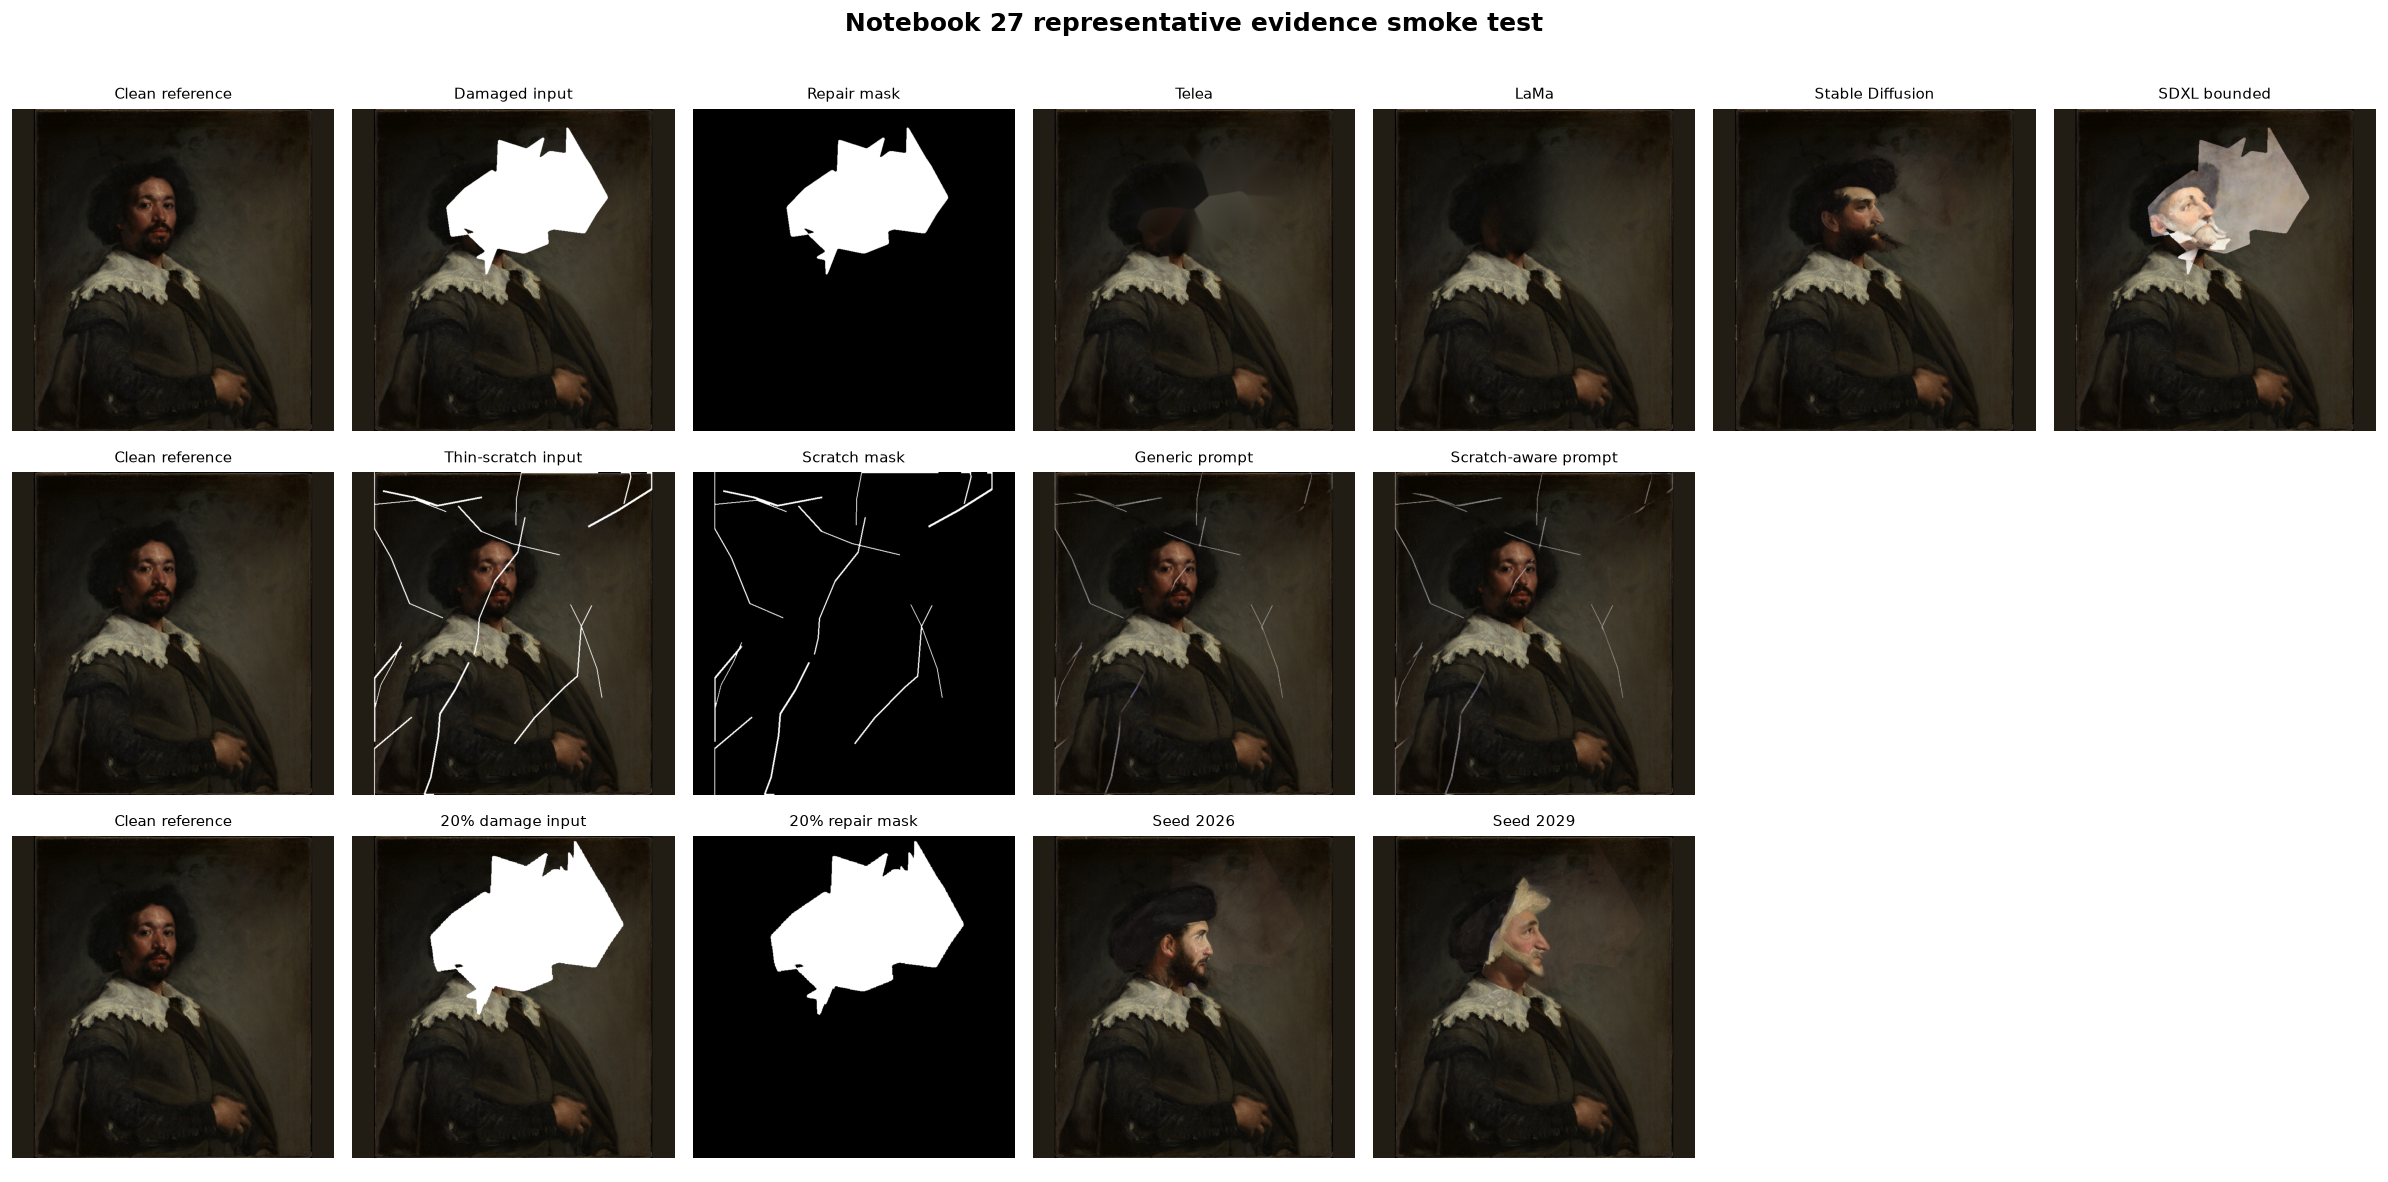

Representative visual smoke test rendered.
Visible image tiles: 17
Persistent figure files written: 0


In [14]:
from PIL import Image


SMOKE_BY_ROLE = (
    SMOKE_POPULATION
    .set_index("smoke_role")
)


def load_repo_image(
    relative_path,
    *,
    mode: str = "RGB",
) -> Image.Image:
    """Load one verified repository-relative image."""
    path = (
        PROJECT_ROOT
        / str(relative_path)
    ).resolve()

    if not path.is_relative_to(
        PROJECT_ROOT
    ):
        raise ValueError(
            f"Image escapes project root: {path}"
        )

    if not path.is_file():
        raise FileNotFoundError(path)

    with Image.open(path) as image:
        return image.convert(mode)


def render_smoke_tile(
    axis,
    relative_path,
    title: str,
    *,
    is_mask: bool = False,
) -> None:
    image = load_repo_image(
        relative_path,
        mode="L" if is_mask else "RGB",
    )

    axis.imshow(
        image,
        cmap="gray" if is_mask else None,
    )
    axis.set_title(
        title,
        fontsize=9,
    )
    axis.axis("off")


loss_telea = SMOKE_BY_ROLE.loc[
    "loss_large_telea"
]
loss_lama = SMOKE_BY_ROLE.loc[
    "loss_large_lama"
]
loss_sd = SMOKE_BY_ROLE.loc[
    "loss_large_sd15"
]
loss_sdxl = SMOKE_BY_ROLE.loc[
    "loss_large_sdxl"
]

scratch_generic = SMOKE_BY_ROLE.loc[
    "scratch_generic"
]
scratch_aware = SMOKE_BY_ROLE.loc[
    "scratch_aware"
]

damage_seed_2026 = SMOKE_BY_ROLE.loc[
    "damage_size_seed_2026"
]
damage_seed_2029 = SMOKE_BY_ROLE.loc[
    "damage_size_seed_2029"
]

smoke_visual_rows = [
    [
        (
            loss_telea[
                "clean_image_path"
            ],
            "Clean reference",
            False,
        ),
        (
            loss_telea[
                "input_image_path"
            ],
            "Damaged input",
            False,
        ),
        (
            loss_telea[
                "mask_or_effect_path"
            ],
            "Repair mask",
            True,
        ),
        (
            loss_telea[
                "restored_path"
            ],
            "Telea",
            False,
        ),
        (
            loss_lama[
                "restored_path"
            ],
            "LaMa",
            False,
        ),
        (
            loss_sd[
                "restored_path"
            ],
            "Stable Diffusion",
            False,
        ),
        (
            loss_sdxl[
                "restored_path"
            ],
            "SDXL bounded",
            False,
        ),
    ],
    [
        (
            scratch_generic[
                "clean_image_path"
            ],
            "Clean reference",
            False,
        ),
        (
            scratch_generic[
                "input_image_path"
            ],
            "Thin-scratch input",
            False,
        ),
        (
            scratch_generic[
                "mask_or_effect_path"
            ],
            "Scratch mask",
            True,
        ),
        (
            scratch_generic[
                "restored_path"
            ],
            "Generic prompt",
            False,
        ),
        (
            scratch_aware[
                "restored_path"
            ],
            "Scratch-aware prompt",
            False,
        ),
    ],
    [
        (
            damage_seed_2026[
                "clean_image_path"
            ],
            "Clean reference",
            False,
        ),
        (
            damage_seed_2026[
                "input_image_path"
            ],
            "20% damage input",
            False,
        ),
        (
            damage_seed_2026[
                "mask_or_effect_path"
            ],
            "20% repair mask",
            True,
        ),
        (
            damage_seed_2026[
                "restored_path"
            ],
            "Seed 2026",
            False,
        ),
        (
            damage_seed_2029[
                "restored_path"
            ],
            "Seed 2029",
            False,
        ),
    ],
]

SMOKE_VISUAL_PATHS = [
    str(path)
    for row in smoke_visual_rows
    for path, _, _
    in row
]

figure, axes = plt.subplots(
    3,
    7,
    figsize=(20, 10),
)

row_labels = [
    "Matched loss-large case",
    "Thin-scratch prompt comparison",
    "Damage-size seed comparison",
]

for row_index, (
    row_tiles,
    row_label,
) in enumerate(
    zip(
        smoke_visual_rows,
        row_labels,
    )
):
    for column_index, tile in enumerate(
        row_tiles
    ):
        path, title, is_mask = tile
        render_smoke_tile(
            axes[
                row_index,
                column_index,
            ],
            path,
            title,
            is_mask=is_mask,
        )

    for column_index in range(
        len(row_tiles),
        axes.shape[1],
    ):
        axes[
            row_index,
            column_index,
        ].axis("off")

    axes[
        row_index,
        0,
    ].set_ylabel(
        row_label,
        fontsize=10,
        fontweight="bold",
    )

figure.suptitle(
    (
        "Notebook 27 representative evidence "
        "smoke test"
    ),
    fontsize=15,
    fontweight="bold",
)

figure.tight_layout(
    rect=(0, 0, 1, 0.96)
)

plt.show()

print("Representative visual smoke test rendered.")
print(
    "Visible image tiles: "
    f"{len(SMOKE_VISUAL_PATHS):,}"
)
print(
    "Persistent figure files written: 0"
)

In [15]:
key_smoke_indicators = [
    "masked_mae",
    "crop_ssim",
    "content_psnr",
    "crop_lpips",
    "crop_clip_similarity",
    "crop_dino_similarity",
    "masked_error_p95",
    "smoothing_fraction",
    "local_texture_error_p95",
    "masked_delta_e_mean",
    "boundary_gradient_mismatch",
    "outside_mask_change_fraction",
    "local_dino_similarity",
    "affinity_map_correlation",
    "uncertainty_pixel_std_p95",
    "uncertainty_pairwise_lpips",
]

SMOKE_KEY_EVIDENCE = (
    SMOKE_EVIDENCE.loc[
        SMOKE_EVIDENCE[
            "indicator_id"
        ].isin(
            key_smoke_indicators
        )
    ]
    .pivot_table(
        index=[
            "smoke_role",
            "model_id",
        ],
        columns="indicator_id",
        values="raw_value",
        aggfunc="first",
    )
    .reset_index()
)

conditional_hue_evidence = (
    SMOKE_EVIDENCE.loc[
        SMOKE_EVIDENCE[
            "indicator_id"
        ].eq("masked_hue_shift")
    ]
    [
        [
            "smoke_role",
            "candidate_id",
            "model_id",
            "raw_value",
            "region_id",
            "source_notebook_id",
        ]
    ]
)

smoke_uncertainty_coverage = (
    SMOKE_POPULATION[
        [
            "smoke_role",
            "candidate_id",
            "model_id",
            "is_uncertainty_candidate",
        ]
    ]
    .merge(
        (
            SMOKE_EVIDENCE.loc[
                SMOKE_EVIDENCE[
                    "source"
                ].eq("uncertainty")
            ]
            .groupby("candidate_id")
            .agg(
                uncertainty_indicators=(
                    "indicator_id",
                    "nunique",
                ),
                uncertainty_groups=(
                    "uncertainty_group_id",
                    "nunique",
                ),
            )
            .reset_index()
        ),
        on="candidate_id",
        how="left",
    )
)

smoke_uncertainty_coverage[
    [
        "uncertainty_indicators",
        "uncertainty_groups",
    ]
] = (
    smoke_uncertainty_coverage[
        [
            "uncertainty_indicators",
            "uncertainty_groups",
        ]
    ]
    .fillna(0)
    .astype(int)
)

display(SMOKE_KEY_EVIDENCE)
display(conditional_hue_evidence)
display(smoke_uncertainty_coverage)

print("Representative scalar evidence inspected.")
print(
    "Key evidence indicators displayed: "
    f"{len(key_smoke_indicators):,}"
)
print(
    "Candidates with uncertainty evidence: "
    f"{int(smoke_uncertainty_coverage['uncertainty_indicators'].gt(0).sum()):,}"
)
print(
    "Conditional hue evidence rows: "
    f"{len(conditional_hue_evidence):,}"
)

indicator_id,smoke_role,model_id,affinity_map_correlation,boundary_gradient_mismatch,content_psnr,crop_clip_similarity,crop_dino_similarity,crop_lpips,crop_ssim,local_dino_similarity,local_texture_error_p95,masked_delta_e_mean,masked_error_p95,masked_mae,outside_mask_change_fraction,smoothing_fraction,uncertainty_pairwise_lpips,uncertainty_pixel_std_p95
0,damage_size_seed_2026,stable_diffusion_inpainting,0.824590,0.005779,25.159941,0.849521,0.824044,0.266501,0.815014,0.603074,1.125496,8.269522,69.666664,18.542724,0.0,0.192784,0.211958,0.181680
1,damage_size_seed_2029,stable_diffusion_inpainting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.211958,0.181680
2,hue_applicability_smoke,lama,0.998211,0.002545,54.990292,0.999963,0.999830,0.000245,0.999081,0.999160,0.000000,2.328283,12.666667,4.337963,0.0,0.000558,NaN,NaN
3,loss_large_lama,lama,0.798688,0.002689,29.288743,0.782248,0.399487,0.310729,0.854539,0.482537,0.749113,5.722176,58.333332,11.919134,0.0,0.329654,NaN,NaN
4,loss_large_sd15,stable_diffusion_inpainting,0.860163,0.004478,28.645249,0.859512,0.823572,0.271551,0.818668,0.661763,1.166941,7.180369,56.333332,15.894983,0.0,0.220044,NaN,NaN
5,loss_large_sdxl,sdxl_inpainting,0.704033,0.078041,14.939744,0.686965,0.495703,0.586535,0.583834,0.461909,12.117031,43.425457,182.666672,117.337383,0.0,0.128531,NaN,NaN
6,loss_large_telea,opencv_telea,0.701018,0.003091,28.732440,0.636529,0.177515,0.343746,0.857360,0.295542,0.949578,6.302268,56.000000,14.233948,0.0,0.479839,NaN,NaN
7,scratch_aware,stable_diffusion_inpainting,0.564148,0.056409,27.027442,0.945473,0.953100,0.285844,0.956767,0.559768,3.305066,21.046299,132.666672,60.918068,0.0,0.003944,0.046270,0.182178
8,scratch_generic,stable_diffusion_inpainting,0.587538,0.054627,27.200096,0.952645,0.958465,0.275012,0.958278,0.578456,2.576929,20.303253,133.333328,58.329626,0.0,0.004499,0.051022,0.179442


,smoke_role,candidate_id,model_id,raw_value,region_id,source_notebook_id
55,hue_applicability_smoke,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,lama,6.220888,masked_region,17


,smoke_role,candidate_id,model_id,is_uncertainty_candidate,uncertainty_indicators,uncertainty_groups
0,loss_large_telea,candidate__opencv_telea__canonical__p001__loss_large__c00,opencv_telea,False,0,0
1,loss_large_lama,candidate__lama__canonical__p001__loss_large__c00,lama,False,0,0
2,loss_large_sd15,sd15__p00__s2026__b4e721b8c5b3,stable_diffusion_inpainting,False,0,0
3,loss_large_sdxl,sdxl__a502c0783c0a__p00_generic__seed2026,sdxl_inpainting,False,0,0
4,scratch_generic,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,True,4,1
5,scratch_aware,sd15__p05__s2026__b0c01d8159c0,stable_diffusion_inpainting,True,4,1
6,damage_size_seed_2026,sd15__p00__s2026__60636de4d6b5,stable_diffusion_inpainting,True,4,1
7,damage_size_seed_2029,sd15dsu__7a1c37281df42a9a,stable_diffusion_inpainting,True,4,1
8,hue_applicability_smoke,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,lama,False,0,0


Representative scalar evidence inspected.
Key evidence indicators displayed: 16
Candidates with uncertainty evidence: 4
Conditional hue evidence rows: 1


In [16]:
BATCH_3_STAGE = (
    "batch_3_evidence_smoke_test"
)
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)

expected_metric_source_rows = {
    "classical": 63018,
    "perceptual": 4170,
    "feature": 8340,
    "spatial": 18896,
    "local": 271988,
    "semantic": 58980,
}

observed_metric_source_rows = {
    source_name: len(frame)
    for source_name, frame
    in EVIDENCE_SOURCES.items()
}

expected_smoke_roles = {
    "loss_large_telea",
    "loss_large_lama",
    "loss_large_sd15",
    "loss_large_sdxl",
    "scratch_generic",
    "scratch_aware",
    "damage_size_seed_2026",
    "damage_size_seed_2029",
    "hue_applicability_smoke",
}

observed_smoke_roles = set(
    SMOKE_POPULATION[
        "smoke_role"
    ].astype(str)
)

expected_evidence_sources = {
    "classical",
    "perceptual",
    "feature",
    "spatial",
    "local",
    "semantic",
    "uncertainty",
}

observed_evidence_sources = set(
    SMOKE_EVIDENCE[
        "source"
    ].astype(str)
)

expected_uncertainty_smoke_ids = set(
    SMOKE_POPULATION.loc[
        SMOKE_POPULATION[
            "is_uncertainty_candidate"
        ],
        "candidate_id",
    ].astype(str)
)

observed_uncertainty_smoke_ids = set(
    SMOKE_EVIDENCE.loc[
        SMOKE_EVIDENCE[
            "source"
        ].eq("uncertainty"),
        "candidate_id",
    ].astype(str)
)

smoke_visual_paths_valid = all(
    (
        PROJECT_ROOT
        / path
    ).resolve().is_file()
    and (
        PROJECT_ROOT
        / path
    ).resolve().is_relative_to(
        PROJECT_ROOT
    )
    for path in SMOKE_VISUAL_PATHS
)

finite_smoke_values = bool(
    np.isfinite(
        pd.to_numeric(
            SMOKE_EVIDENCE[
                "raw_value"
            ],
            errors="coerce",
        )
    ).all()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="metric_source_row_counts",
    description=(
        "All six metric tables match their "
        "validated upstream row counts."
    ),
    expected=expected_metric_source_rows,
    observed=observed_metric_source_rows,
    passed=(
        observed_metric_source_rows
        == expected_metric_source_rows
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_selection_exact",
    description=(
        "The smoke population contains every "
        "approved technical role exactly once."
    ),
    expected=sorted(
        expected_smoke_roles
    ),
    observed=sorted(
        observed_smoke_roles
    ),
    passed=(
        len(SMOKE_POPULATION) == 9
        and observed_smoke_roles
        == expected_smoke_roles
        and SMOKE_POPULATION[
            "candidate_id"
        ].is_unique
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="configured_indicator_count",
    description=(
        "The reloaded configuration contains "
        "all 36 approved evidence indicators."
    ),
    expected=36,
    observed=len(
        configured_indicator_ids
    ),
    passed=(
        len(configured_indicator_ids)
        == 36
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="all_indicator_adapters_observed",
    description=(
        "Every configured indicator produced "
        "finite representative evidence."
    ),
    expected={
        "missing": [],
        "unexpected": [],
    },
    observed={
        "missing": (
            missing_smoke_indicator_ids
        ),
        "unexpected": (
            unexpected_smoke_indicator_ids
        ),
    },
    passed=(
        not missing_smoke_indicator_ids
        and not unexpected_smoke_indicator_ids
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="all_evidence_sources_observed",
    description=(
        "Classical, perceptual, feature, spatial, "
        "local, semantic, and uncertainty adapters "
        "all contributed evidence."
    ),
    expected=sorted(
        expected_evidence_sources
    ),
    observed=sorted(
        observed_evidence_sources
    ),
    passed=(
        observed_evidence_sources
        == expected_evidence_sources
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_evidence_unique",
    description=(
        "Every normalized smoke-evidence ID "
        "is unique."
    ),
    expected=0,
    observed=int(
        SMOKE_EVIDENCE[
            "evidence_id"
        ].duplicated().sum()
    ),
    passed=(
        not SMOKE_EVIDENCE[
            "evidence_id"
        ].duplicated().any()
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_values_finite",
    description=(
        "Every retained smoke-evidence value "
        "is finite."
    ),
    expected=True,
    observed=finite_smoke_values,
    passed=finite_smoke_values,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="conditional_hue_applicability",
    description=(
        "At least one explicitly selected candidate "
        "verifies applicable masked hue evidence."
    ),
    expected={
        "minimum_rows": 1,
        "required_role": (
            "hue_applicability_smoke"
        ),
    },
    observed={
        "rows": len(
            conditional_hue_evidence
        ),
        "roles": sorted(
            conditional_hue_evidence[
                "smoke_role"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(
            conditional_hue_evidence
        )
        >= 1
        and (
            "hue_applicability_smoke"
            in set(
                conditional_hue_evidence[
                    "smoke_role"
                ].astype(str)
            )
        )
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="uncertainty_applicability_exact",
    description=(
        "Uncertainty evidence appears exactly for "
        "smoke candidates belonging to complete "
        "repeated-seed groups."
    ),
    expected=sorted(
        expected_uncertainty_smoke_ids
    ),
    observed=sorted(
        observed_uncertainty_smoke_ids
    ),
    passed=(
        observed_uncertainty_smoke_ids
        == expected_uncertainty_smoke_ids
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="visual_smoke_paths_valid",
    description=(
        "Every image used by the visual smoke test "
        "exists inside the repository."
    ),
    expected=len(
        SMOKE_VISUAL_PATHS
    ),
    observed=sum(
        (
            PROJECT_ROOT
            / path
        ).resolve().is_file()
        for path in SMOKE_VISUAL_PATHS
    ),
    passed=smoke_visual_paths_valid,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="smoke_test_writes_no_outputs",
    description=(
        "The representative smoke test did not "
        "write persistent output files."
    ),
    expected=0,
    observed=len(
        [
            path
            for path
            in OUTPUT_ROOT.rglob("*")
            if path.is_file()
        ]
    ),
    passed=not any(
        path.is_file()
        for path
        in OUTPUT_ROOT.rglob("*")
    ),
)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
)

BATCH_3_SUMMARY = VALIDATION.summary()

print("Batch 3 evidence smoke test complete.")
print(
    "Smoke candidates: "
    f"{len(SMOKE_POPULATION):,}"
)
print(
    "Observed indicators: "
    f"{len(observed_smoke_indicator_ids):,}/"
    f"{len(configured_indicator_ids):,}"
)
print(
    "Normalized evidence rows: "
    f"{len(SMOKE_EVIDENCE):,}"
)
print(
    "Total validation checks: "
    f"{BATCH_3_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_3_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
35,batch_3_evidence_smoke_test,metric_source_row_counts,All six metric tables match their validated upstream row counts.,blocking,"{""classical"": 63018, ""feature"": 8340, ""local"": 271988, ""perceptual"": 4170, ""semantic"": 58980, ""spatial"": 18896}","{""classical"": 63018, ""feature"": 8340, ""local"": 271988, ""perceptual"": 4170, ""semantic"": 58980, ""spatial"": 18896}",True,
36,batch_3_evidence_smoke_test,smoke_selection_exact,The smoke population contains every approved technical role exactly once.,blocking,"[""damage_size_seed_2026"", ""damage_size_seed_2029"", ""hue_applicability_smoke"", ""loss_large_lama"", ""loss_large_sd15"", ""loss_large_sdxl"", ""loss_large_telea"", ""scratch_aware"", ""scr...","[""damage_size_seed_2026"", ""damage_size_seed_2029"", ""hue_applicability_smoke"", ""loss_large_lama"", ""loss_large_sd15"", ""loss_large_sdxl"", ""loss_large_telea"", ""scratch_aware"", ""scr...",True,
37,batch_3_evidence_smoke_test,configured_indicator_count,The reloaded configuration contains all 36 approved evidence indicators.,blocking,36,36,True,
38,batch_3_evidence_smoke_test,all_indicator_adapters_observed,Every configured indicator produced finite representative evidence.,blocking,"{""missing"": [], ""unexpected"": []}","{""missing"": [], ""unexpected"": []}",True,
39,batch_3_evidence_smoke_test,all_evidence_sources_observed,"Classical, perceptual, feature, spatial, local, semantic, and uncertainty adapters all contributed evidence.",blocking,"[""classical"", ""feature"", ""local"", ""perceptual"", ""semantic"", ""spatial"", ""uncertainty""]","[""classical"", ""feature"", ""local"", ""perceptual"", ""semantic"", ""spatial"", ""uncertainty""]",True,
40,batch_3_evidence_smoke_test,normalized_evidence_unique,Every normalized smoke-evidence ID is unique.,blocking,0,0,True,
41,batch_3_evidence_smoke_test,normalized_values_finite,Every retained smoke-evidence value is finite.,blocking,True,True,True,
42,batch_3_evidence_smoke_test,conditional_hue_applicability,At least one explicitly selected candidate verifies applicable masked hue evidence.,blocking,"{""minimum_rows"": 1, ""required_role"": ""hue_applicability_smoke""}","{""roles"": [""hue_applicability_smoke""], ""rows"": 1}",True,
43,batch_3_evidence_smoke_test,uncertainty_applicability_exact,Uncertainty evidence appears exactly for smoke candidates belonging to complete repeated-seed groups.,blocking,"[""sd15__p00__s2026__60636de4d6b5"", ""sd15__p00__s2026__b039817c7170"", ""sd15__p05__s2026__b0c01d8159c0"", ""sd15dsu__7a1c37281df42a9a""]","[""sd15__p00__s2026__60636de4d6b5"", ""sd15__p00__s2026__b039817c7170"", ""sd15__p05__s2026__b0c01d8159c0"", ""sd15dsu__7a1c37281df42a9a""]",True,
44,batch_3_evidence_smoke_test,visual_smoke_paths_valid,Every image used by the visual smoke test exists inside the repository.,blocking,17,17,True,


Batch 3 evidence smoke test complete.
Smoke candidates: 9
Observed indicators: 36/36
Normalized evidence rows: 265
Total validation checks: 46
Blocking failures: 0


## Batch 4 — Full evidence normalization and threshold calibration

This batch:

- normalizes all available evidence for the complete 1,785-candidate union;
- retains conditional missingness instead of interpreting it as passing evidence;
- verifies direct evidence and repeated-seed uncertainty coverage separately;
- fits transparent experiment-stratified operational thresholds;
- preserves generic and scratch-aware uncertainty prompt arms;
- excludes zero controls, uncertainty-only candidates, and bounded SDXL candidates from ordinary quality-threshold fitting;
- applies fixed absolute tolerances to outside-mask alteration indicators;
- classifies individual evidence values as favourable, neutral, warning, or critical;
- validates threshold ordering, fitting counts, classification completeness, and evidence provenance.

The thresholds are relative screening rules. They are not calibrated probabilities, human-labelled failure boundaries, or conservation-severity levels.

This batch writes no canonical output files.

In [17]:
FULL_EVIDENCE = normalise_failure_evidence(
    EVIDENCE_SOURCES,
    CANDIDATE_POPULATION,
    CANONICAL_UNCERTAINTY,
    DAMAGE_SIZE_UNCERTAINTY,
    config=ANALYSIS_CONFIG,
)

FULL_EVIDENCE["raw_value"] = pd.to_numeric(
    FULL_EVIDENCE["raw_value"],
    errors="coerce",
)

FULL_EVIDENCE["adverse_value"] = pd.to_numeric(
    FULL_EVIDENCE["adverse_value"],
    errors="coerce",
)

FULL_SOURCE_COVERAGE = (
    FULL_EVIDENCE.groupby(
        [
            "source",
            "source_notebook_id",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
        finite_values=(
            "raw_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

candidate_source_counts = (
    FULL_EVIDENCE.groupby(
        [
            "candidate_id",
            "source",
        ],
        dropna=False,
    )
    .size()
    .unstack(
        fill_value=0,
    )
    .reindex(
        columns=[
            "classical",
            "perceptual",
            "feature",
            "spatial",
            "local",
            "semantic",
            "uncertainty",
        ],
        fill_value=0,
    )
    .reset_index()
)

FULL_CANDIDATE_COVERAGE = (
    CANDIDATE_POPULATION[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "population_role",
            "is_primary_candidate",
            "is_uncertainty_candidate",
            "quality_analysis_eligible",
            "is_zero_control",
        ]
    ]
    .merge(
        candidate_source_counts,
        on="candidate_id",
        how="left",
    )
)

source_count_columns = [
    "classical",
    "perceptual",
    "feature",
    "spatial",
    "local",
    "semantic",
    "uncertainty",
]

FULL_CANDIDATE_COVERAGE[
    source_count_columns
] = (
    FULL_CANDIDATE_COVERAGE[
        source_count_columns
    ]
    .fillna(0)
    .astype(int)
)

FULL_CANDIDATE_COVERAGE[
    "direct_evidence_rows"
] = (
    FULL_CANDIDATE_COVERAGE[
        [
            "classical",
            "perceptual",
            "feature",
            "spatial",
            "local",
            "semantic",
        ]
    ].sum(axis=1)
)

FULL_CANDIDATE_COVERAGE[
    "uncertainty_evidence_rows"
] = FULL_CANDIDATE_COVERAGE[
    "uncertainty"
]

FULL_CANDIDATE_COVERAGE[
    "total_evidence_rows"
] = (
    FULL_CANDIDATE_COVERAGE[
        "direct_evidence_rows"
    ]
    + FULL_CANDIDATE_COVERAGE[
        "uncertainty_evidence_rows"
    ]
)

FULL_ROLE_COVERAGE = (
    FULL_CANDIDATE_COVERAGE.groupby(
        [
            "population_role",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        candidates_with_direct_evidence=(
            "direct_evidence_rows",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        candidates_with_uncertainty=(
            "uncertainty_evidence_rows",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        minimum_evidence_rows=(
            "total_evidence_rows",
            "min",
        ),
        median_evidence_rows=(
            "total_evidence_rows",
            "median",
        ),
        maximum_evidence_rows=(
            "total_evidence_rows",
            "max",
        ),
    )
    .reset_index()
)

display(FULL_SOURCE_COVERAGE)
display(FULL_ROLE_COVERAGE)

print("Complete evidence ledger normalized.")
print(
    "Candidates represented: "
    f"{FULL_EVIDENCE['candidate_id'].nunique():,}/"
    f"{len(CANDIDATE_POPULATION):,}"
)
print(
    "Evidence rows: "
    f"{len(FULL_EVIDENCE):,}"
)
print(
    "Indicators represented: "
    f"{FULL_EVIDENCE['indicator_id'].nunique():,}/"
    f"{len(SETTINGS['indicators']):,}"
)
print(
    "Evidence sources represented: "
    f"{FULL_EVIDENCE['source'].nunique():,}"
)

,source,source_notebook_id,evidence_rows,candidates,indicators,experiments,finite_values
0,classical,13,4590,1530,3,4,4590
1,feature,15,3060,1530,2,4,3060
2,local,17,23106,1530,16,4,23106
3,perceptual,14,1530,1530,1,4,1530
4,semantic,20,11460,1680,7,4,11460
5,spatial,16,4890,1680,3,4,4890
6,uncertainty,18,2080,520,4,1,2080
7,uncertainty,22,560,140,4,1,560


,population_role,model_id,candidates,candidates_with_direct_evidence,candidates_with_uncertainty,minimum_evidence_rows,median_evidence_rows,maximum_evidence_rows
0,bounded_sdxl,sdxl_inpainting,10,10,0,31,32.0,32
1,primary_and_uncertainty,stable_diffusion_inpainting,115,115,115,35,35.0,35
2,primary_comparison,lama,410,410,0,7,31.0,32
3,primary_comparison,opencv_telea,410,410,0,7,31.0,32
4,primary_comparison,stable_diffusion_inpainting,295,295,0,7,31.0,32
5,uncertainty_only,stable_diffusion_inpainting,545,440,545,4,35.0,35


Complete evidence ledger normalized.
Candidates represented: 1,785/1,785
Evidence rows: 51,276
Indicators represented: 36/36
Evidence sources represented: 7


In [18]:
FULL_INDICATOR_COVERAGE = (
    FULL_EVIDENCE.groupby(
        [
            "indicator_id",
            "source",
            "source_notebook_id",
            "component",
            "metric_name",
            "region_id",
            "summary_statistic",
            "direction",
            "threshold_mode",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        uncertainty_groups=(
            "uncertainty_group_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
        prompt_variants=(
            "prompt_variant_id",
            "nunique",
        ),
        finite_values=(
            "raw_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

direct_candidate_ids = set(
    FULL_EVIDENCE.loc[
        ~FULL_EVIDENCE["source"].eq(
            "uncertainty"
        ),
        "candidate_id",
    ].astype(str)
)

uncertainty_candidate_ids_observed = set(
    FULL_EVIDENCE.loc[
        FULL_EVIDENCE["source"].eq(
            "uncertainty"
        ),
        "candidate_id",
    ].astype(str)
)

canonical_uncertainty_ids = set(
    uncertainty_candidate_ids(
        CANONICAL_UNCERTAINTY
    )
)

expected_direct_candidate_ids = (
    set(
        CANDIDATE_POPULATION.loc[
            CANDIDATE_POPULATION[
                "is_primary_candidate"
            ],
            "candidate_id",
        ].astype(str)
    )
    | canonical_uncertainty_ids
)

expected_uncertainty_candidate_ids = set(
    CANDIDATE_POPULATION.loc[
        CANDIDATE_POPULATION[
            "is_uncertainty_candidate"
        ],
        "candidate_id",
    ].astype(str)
)

conditional_indicator_coverage = (
    FULL_INDICATOR_COVERAGE.loc[
        FULL_INDICATOR_COVERAGE[
            "candidates"
        ].lt(
            len(
                expected_direct_candidate_ids
            )
        )
        & ~FULL_INDICATOR_COVERAGE[
            "source"
        ].eq("uncertainty")
    ]
    .sort_values(
        [
            "candidates",
            "indicator_id",
        ]
    )
)

coverage_summary = pd.DataFrame(
    [
        {
            "coverage_item": (
                "Candidate union"
            ),
            "expected": len(
                CANDIDATE_POPULATION
            ),
            "observed": (
                FULL_EVIDENCE[
                    "candidate_id"
                ].nunique()
            ),
        },
        {
            "coverage_item": (
                "Candidates with direct evidence"
            ),
            "expected": len(
                expected_direct_candidate_ids
            ),
            "observed": len(
                direct_candidate_ids
            ),
        },
        {
            "coverage_item": (
                "Candidates with uncertainty evidence"
            ),
            "expected": len(
                expected_uncertainty_candidate_ids
            ),
            "observed": len(
                uncertainty_candidate_ids_observed
            ),
        },
        {
            "coverage_item": (
                "Configured indicators"
            ),
            "expected": len(
                SETTINGS["indicators"]
            ),
            "observed": (
                FULL_EVIDENCE[
                    "indicator_id"
                ].nunique()
            ),
        },
        {
            "coverage_item": (
                "Evidence sources"
            ),
            "expected": 7,
            "observed": (
                FULL_EVIDENCE[
                    "source"
                ].nunique()
            ),
        },
    ]
)

display(coverage_summary)
display(FULL_INDICATOR_COVERAGE)
display(conditional_indicator_coverage)

print("Evidence coverage and missingness inspected.")
print(
    "Candidates with direct evidence: "
    f"{len(direct_candidate_ids):,}"
)
print(
    "Candidates with uncertainty evidence: "
    f"{len(uncertainty_candidate_ids_observed):,}"
)
print(
    "Conditionally incomplete direct indicators: "
    f"{len(conditional_indicator_coverage):,}"
)
print(
    "Missing values remain explicit and are not "
    "converted into passing evidence."
)

,coverage_item,expected,observed
0,Candidate union,1785,1785
1,Candidates with direct evidence,1680,1680
2,Candidates with uncertainty evidence,660,660
3,Configured indicators,36,36
4,Evidence sources,7,7


,indicator_id,source,source_notebook_id,component,metric_name,region_id,summary_statistic,direction,threshold_mode,evidence_rows,candidates,uncertainty_groups,experiments,prompt_variants,finite_values
0,affinity_centroid_shift,semantic,20,structural_position,reference_affinity_centroid_shift,content_region,normalized_centroid_shift,higher_is_worse,quantile,1680,1680,0,4,2,1680
1,affinity_js_divergence,semantic,20,structural_affinity,reference_affinity_js_divergence,content_region,jensen_shannon_divergence,higher_is_worse,quantile,1680,1680,0,4,2,1680
2,affinity_map_correlation,semantic,20,structural_affinity,reference_affinity_map_correlation,content_region,pearson_correlation,lower_is_worse,quantile,1680,1680,0,4,2,1680
3,boundary_gradient_mismatch,local,17,boundary_gradient,boundary_gradient_mismatch,boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
4,boundary_orientation_mismatch,local,17,boundary_orientation,boundary_orientation_mismatch,boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
5,boundary_spillover_p95,local,17,boundary_spillover,boundary_spillover_change_p95,outside_boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
6,boundary_ssim_error,local,17,boundary_structure,boundary_local_ssim_map_error,boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
7,content_psnr,classical,13,content_pixel_fidelity,psnr,content_region,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530
8,crop_clip_similarity,feature,15,clip_feature_similarity,clip_cosine_similarity,mask_bbox_crop,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530
9,crop_dino_similarity,feature,15,dino_feature_similarity,dinov2_cosine_similarity,mask_bbox_crop,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530


,indicator_id,source,source_notebook_id,component,metric_name,region_id,summary_statistic,direction,threshold_mode,evidence_rows,candidates,uncertainty_groups,experiments,prompt_variants,finite_values
24,masked_hue_shift,local,17,colour_hue,hue_shift_mean_degrees,masked_region,restored_value,higher_is_worse,quantile,156,156,0,1,1,156
3,boundary_gradient_mismatch,local,17,boundary_gradient,boundary_gradient_mismatch,boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
4,boundary_orientation_mismatch,local,17,boundary_orientation,boundary_orientation_mismatch,boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
5,boundary_spillover_p95,local,17,boundary_spillover,boundary_spillover_change_p95,outside_boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
6,boundary_ssim_error,local,17,boundary_structure,boundary_local_ssim_map_error,boundary_ring,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
7,content_psnr,classical,13,content_pixel_fidelity,psnr,content_region,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530
8,crop_clip_similarity,feature,15,clip_feature_similarity,clip_cosine_similarity,mask_bbox_crop,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530
9,crop_dino_similarity,feature,15,dino_feature_similarity,dinov2_cosine_similarity,mask_bbox_crop,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530
10,crop_lpips,perceptual,14,perceptual_similarity,lpips,mask_bbox_crop,restored_value,higher_is_worse,quantile,1530,1530,0,4,2,1530
11,crop_ssim,classical,13,structural_similarity,ssim,mask_bbox_crop,restored_value,lower_is_worse,quantile,1530,1530,0,4,2,1530


Evidence coverage and missingness inspected.
Candidates with direct evidence: 1,680
Candidates with uncertainty evidence: 660
Conditionally incomplete direct indicators: 25
Missing values remain explicit and are not converted into passing evidence.


In [19]:
OPERATIONAL_THRESHOLDS = (
    calibrate_operational_thresholds(
        FULL_EVIDENCE,
        CANDIDATE_POPULATION,
        config=ANALYSIS_CONFIG,
    )
)

CLASSIFIED_EVIDENCE = (
    classify_evidence_against_thresholds(
        FULL_EVIDENCE,
        OPERATIONAL_THRESHOLDS,
    )
)

threshold_source_lookup = {
    str(indicator["indicator_id"]): str(
        indicator["source"]
    )
    for indicator in SETTINGS["indicators"]
}

OPERATIONAL_THRESHOLDS[
    "source"
] = (
    OPERATIONAL_THRESHOLDS[
        "indicator_id"
    ]
    .astype(str)
    .map(
        threshold_source_lookup
    )
)

THRESHOLD_STRATA_SUMMARY = (
    OPERATIONAL_THRESHOLDS.groupby(
        [
            "source",
            "fitting_scope",
            "threshold_mode",
            "direction",
        ],
        dropna=False,
    )
    .agg(
        threshold_rows=(
            "threshold_id",
            "size",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
        prompt_variants=(
            "prompt_variant_id",
            lambda values: int(
                pd.Series(values)
                .fillna("")
                .astype(str)
                .replace("", pd.NA)
                .nunique()
            ),
        ),
        minimum_fitting_count=(
            "n_fitting_candidates",
            "min",
        ),
        maximum_fitting_count=(
            "n_fitting_candidates",
            "max",
        ),
    )
    .reset_index()
)

THRESHOLD_EXAMPLES = (
    OPERATIONAL_THRESHOLDS.sort_values(
        [
            "indicator_id",
            "experiment_id",
            "prompt_variant_id",
        ]
    )
    .groupby(
        "indicator_id",
        as_index=False,
        sort=True,
    )
    .head(1)
    [
        [
            "indicator_id",
            "source",
            "experiment_id",
            "prompt_variant_id",
            "direction",
            "threshold_mode",
            "fitting_scope",
            "n_fitting_candidates",
            "n_fitting_groups",
            "favourable_threshold",
            "warning_threshold",
            "critical_threshold",
        ]
    ]
)

EVIDENCE_STATE_SUMMARY = (
    CLASSIFIED_EVIDENCE.groupby(
        [
            "source",
            "evidence_state",
        ],
        dropna=False,
    )
    .agg(
        evidence_rows=(
            "evidence_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        indicators=(
            "indicator_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(THRESHOLD_STRATA_SUMMARY)
display(THRESHOLD_EXAMPLES)
display(EVIDENCE_STATE_SUMMARY)

print("Operational thresholds calibrated and applied.")
print(
    "Threshold rows: "
    f"{len(OPERATIONAL_THRESHOLDS):,}"
)
print(
    "Indicators with thresholds: "
    f"{OPERATIONAL_THRESHOLDS['indicator_id'].nunique():,}"
)
print(
    "Classified evidence rows: "
    f"{len(CLASSIFIED_EVIDENCE):,}/"
    f"{len(FULL_EVIDENCE):,}"
)
print(
    "Critical evidence rows: "
    f"{int(CLASSIFIED_EVIDENCE['evidence_state'].eq('critical').sum()):,}"
)

,source,fitting_scope,threshold_mode,direction,threshold_rows,indicators,experiments,prompt_variants,minimum_fitting_count,maximum_fitting_count
0,classical,experiment,quantile,higher_is_worse,4,1,4,0,105,600
1,classical,experiment,quantile,lower_is_worse,8,2,4,0,105,600
2,feature,experiment,quantile,lower_is_worse,8,2,4,0,105,600
3,local,experiment,quantile,higher_is_worse,61,16,4,0,105,600
4,perceptual,experiment,quantile,higher_is_worse,4,1,4,0,105,600
5,semantic,experiment,quantile,higher_is_worse,16,4,4,0,105,600
6,semantic,experiment,quantile,lower_is_worse,12,3,4,0,105,600
7,spatial,experiment,absolute_tolerance,higher_is_worse,8,2,4,0,105,600
8,spatial,experiment,quantile,higher_is_worse,4,1,4,0,105,600
9,uncertainty,experiment_prompt,quantile,higher_is_worse,12,4,2,2,35,80


,indicator_id,source,experiment_id,prompt_variant_id,direction,threshold_mode,fitting_scope,n_fitting_candidates,n_fitting_groups,favourable_threshold,warning_threshold,critical_threshold
0,affinity_centroid_shift,semantic,canonical_missing_region,,higher_is_worse,quantile,experiment,600,0,0.000345,2.910971e-03,0.005211
4,affinity_js_divergence,semantic,canonical_missing_region,,higher_is_worse,quantile,experiment,600,0,0.000034,8.335264e-04,0.001664
8,affinity_map_correlation,semantic,canonical_missing_region,,lower_is_worse,quantile,experiment,600,0,0.985639,7.094865e-01,0.499128
12,boundary_gradient_mismatch,local,canonical_missing_region,,higher_is_worse,quantile,experiment,600,0,0.006106,2.467947e-02,0.037104
16,boundary_orientation_mismatch,local,canonical_missing_region,,higher_is_worse,quantile,experiment,600,0,0.205542,3.383210e-01,0.364760
20,boundary_spillover_p95,local,canonical_missing_region,,higher_is_worse,quantile,experiment,600,0,0.000000,0.000000e+00,0.000000
24,boundary_ssim_error,local,canonical_missing_region,,higher_is_worse,quantile,experiment,600,0,0.116875,4.419613e-01,0.546732
28,content_psnr,classical,canonical_missing_region,,lower_is_worse,quantile,experiment,600,0,36.799465,2.449207e+01,21.976392
32,crop_clip_similarity,feature,canonical_missing_region,,lower_is_worse,quantile,experiment,600,0,0.997482,8.686724e-01,0.724917
36,crop_dino_similarity,feature,canonical_missing_region,,lower_is_worse,quantile,experiment,600,0,0.993413,5.423034e-01,0.262616


,source,evidence_state,evidence_rows,candidates,indicators
0,classical,critical,174,147,3
1,classical,favourable,870,401,3
2,classical,neutral,3124,1278,3
3,classical,warning,422,337,3
4,feature,critical,61,49,2
5,feature,favourable,604,366,2
6,feature,neutral,2212,1202,2
7,feature,warning,183,140,2
8,local,critical,1233,385,15
9,local,favourable,6455,1530,16


Operational thresholds calibrated and applied.
Threshold rows: 137
Indicators with thresholds: 36
Classified evidence rows: 51,276/51,276
Critical evidence rows: 2,104


In [20]:
population_fitting_fields = (
    CANDIDATE_POPULATION[
        [
            "candidate_id",
            "model_id",
            "population_role",
            "quality_analysis_eligible",
            "is_zero_control",
        ]
    ]
    .drop_duplicates("candidate_id")
)

DIRECT_FITTING_EVIDENCE = (
    FULL_EVIDENCE.loc[
        ~FULL_EVIDENCE[
            "source"
        ].eq("uncertainty")
    ]
    .merge(
        population_fitting_fields,
        on="candidate_id",
        how="left",
        suffixes=(
            "",
            "_population",
        ),
    )
)

DIRECT_FITTING_EVIDENCE = (
    DIRECT_FITTING_EVIDENCE.loc[
        DIRECT_FITTING_EVIDENCE[
            "quality_analysis_eligible"
        ].astype(bool)
        & ~DIRECT_FITTING_EVIDENCE[
            "is_zero_control"
        ].astype(bool)
        & ~DIRECT_FITTING_EVIDENCE[
            "model_id"
        ].astype(str)
        .eq("sdxl_inpainting")
    ]
    .copy()
)

UNCERTAINTY_FITTING_EVIDENCE = (
    FULL_EVIDENCE.loc[
        FULL_EVIDENCE[
            "source"
        ].eq("uncertainty")
    ]
    .drop_duplicates(
        [
            "uncertainty_group_id",
            "indicator_id",
        ]
    )
    .copy()
)

threshold_fit_audit_rows = []

for threshold in (
    OPERATIONAL_THRESHOLDS.itertuples(
        index=False
    )
):
    indicator_id = str(
        threshold.indicator_id
    )
    experiment_id = str(
        threshold.experiment_id
    )
    prompt_variant_id = (
        ""
        if pd.isna(
            threshold.prompt_variant_id
        )
        else str(
            threshold.prompt_variant_id
        )
    )
    fitting_scope = str(
        threshold.fitting_scope
    )
    source = str(
        threshold.source
    )

    if source == "uncertainty":
        fitting = (
            UNCERTAINTY_FITTING_EVIDENCE.loc[
                UNCERTAINTY_FITTING_EVIDENCE[
                    "indicator_id"
                ].astype(str)
                .eq(indicator_id)
                & UNCERTAINTY_FITTING_EVIDENCE[
                    "prompt_variant_id"
                ].astype(str)
                .eq(prompt_variant_id)
            ]
        )

        if fitting_scope == "experiment_prompt":
            fitting = fitting.loc[
                fitting[
                    "experiment_id"
                ].astype(str)
                .eq(experiment_id)
            ]

        expected_count = (
            fitting[
                "uncertainty_group_id"
            ].nunique()
        )
        expected_groups = expected_count

    else:
        fitting = (
            DIRECT_FITTING_EVIDENCE.loc[
                DIRECT_FITTING_EVIDENCE[
                    "indicator_id"
                ].astype(str)
                .eq(indicator_id)
            ]
        )

        if fitting_scope == "experiment":
            fitting = fitting.loc[
                fitting[
                    "experiment_id"
                ].astype(str)
                .eq(experiment_id)
            ]

        expected_count = len(fitting)
        expected_groups = 0

    threshold_fit_audit_rows.append(
        {
            "threshold_id": (
                threshold.threshold_id
            ),
            "indicator_id": indicator_id,
            "source": source,
            "experiment_id": experiment_id,
            "prompt_variant_id": (
                prompt_variant_id
            ),
            "fitting_scope": (
                fitting_scope
            ),
            "expected_fitting_candidates": int(
                expected_count
            ),
            "observed_fitting_candidates": int(
                threshold.n_fitting_candidates
            ),
            "expected_fitting_groups": int(
                expected_groups
            ),
            "observed_fitting_groups": int(
                threshold.n_fitting_groups
            ),
            "candidate_count_matches": (
                int(expected_count)
                == int(
                    threshold.n_fitting_candidates
                )
            ),
            "group_count_matches": (
                int(expected_groups)
                == int(
                    threshold.n_fitting_groups
                )
            ),
        }
    )

THRESHOLD_FIT_AUDIT = pd.DataFrame(
    threshold_fit_audit_rows
)

higher_thresholds = (
    OPERATIONAL_THRESHOLDS.loc[
        OPERATIONAL_THRESHOLDS[
            "direction"
        ].eq("higher_is_worse")
    ]
)

lower_thresholds = (
    OPERATIONAL_THRESHOLDS.loc[
        OPERATIONAL_THRESHOLDS[
            "direction"
        ].eq("lower_is_worse")
    ]
)

higher_threshold_order_valid = bool(
    (
        higher_thresholds[
            "favourable_threshold"
        ]
        <= higher_thresholds[
            "warning_threshold"
        ]
    ).all()
    and (
        higher_thresholds[
            "warning_threshold"
        ]
        <= higher_thresholds[
            "critical_threshold"
        ]
    ).all()
)

lower_threshold_order_valid = bool(
    (
        lower_thresholds[
            "critical_threshold"
        ]
        <= lower_thresholds[
            "warning_threshold"
        ]
    ).all()
    and (
        lower_thresholds[
            "warning_threshold"
        ]
        <= lower_thresholds[
            "favourable_threshold"
        ]
    ).all()
)

absolute_thresholds = (
    OPERATIONAL_THRESHOLDS.loc[
        OPERATIONAL_THRESHOLDS[
            "threshold_mode"
        ].eq("absolute_tolerance")
    ]
)

absolute_thresholds_valid = bool(
    np.isclose(
        absolute_thresholds[
            "favourable_threshold"
        ].to_numpy(dtype=float),
        0.0,
        rtol=0.0,
        atol=1e-15,
    ).all()
    and np.isclose(
        absolute_thresholds[
            "warning_threshold"
        ].to_numpy(dtype=float),
        float(
            SETTINGS[
                "threshold_policy"
            ][
                "outside_mask_absolute_warning_tolerance"
            ]
        ),
        rtol=0.0,
        atol=1e-15,
    ).all()
    and np.isclose(
        absolute_thresholds[
            "critical_threshold"
        ].to_numpy(dtype=float),
        float(
            SETTINGS[
                "threshold_policy"
            ][
                "outside_mask_absolute_critical_tolerance"
            ]
        ),
        rtol=0.0,
        atol=1e-15,
    ).all()
)

fitting_exclusion_summary = pd.DataFrame(
    [
        {
            "excluded_population": (
                "Zero controls"
            ),
            "candidate_count": int(
                CANDIDATE_POPULATION[
                    "is_zero_control"
                ].astype(bool).sum()
            ),
            "present_in_direct_fitting_rows": int(
                DIRECT_FITTING_EVIDENCE[
                    "is_zero_control"
                ].astype(bool).sum()
            ),
        },
        {
            "excluded_population": (
                "Bounded SDXL"
            ),
            "candidate_count": int(
                CANDIDATE_POPULATION[
                    "population_role"
                ].eq("bounded_sdxl")
                .sum()
            ),
            "present_in_direct_fitting_rows": int(
                DIRECT_FITTING_EVIDENCE[
                    "model_id"
                ].astype(str)
                .eq("sdxl_inpainting")
                .sum()
            ),
        },
        {
            "excluded_population": (
                "Uncertainty-only candidates"
            ),
            "candidate_count": int(
                CANDIDATE_POPULATION[
                    "population_role"
                ].eq("uncertainty_only")
                .sum()
            ),
            "present_in_direct_fitting_rows": int(
                DIRECT_FITTING_EVIDENCE[
                    "population_role"
                ].astype(str)
                .eq("uncertainty_only")
                .sum()
            ),
        },
    ]
)

display(fitting_exclusion_summary)
display(
    THRESHOLD_FIT_AUDIT.loc[
        ~THRESHOLD_FIT_AUDIT[
            "candidate_count_matches"
        ]
        | ~THRESHOLD_FIT_AUDIT[
            "group_count_matches"
        ]
    ]
)

print("Threshold fitting policy audited.")
print(
    "Threshold fitting-count mismatches: "
    f"{int((~THRESHOLD_FIT_AUDIT['candidate_count_matches']).sum()):,}"
)
print(
    "Threshold group-count mismatches: "
    f"{int((~THRESHOLD_FIT_AUDIT['group_count_matches']).sum()):,}"
)
print(
    "Higher-is-worse ordering valid: "
    f"{higher_threshold_order_valid}"
)
print(
    "Lower-is-worse ordering valid: "
    f"{lower_threshold_order_valid}"
)
print(
    "Absolute outside-mask tolerances valid: "
    f"{absolute_thresholds_valid}"
)

,excluded_population,candidate_count,present_in_direct_fitting_rows
0,Zero controls,150,0
1,Bounded SDXL,10,0
2,Uncertainty-only candidates,545,0


,threshold_id,indicator_id,source,experiment_id,prompt_variant_id,fitting_scope,expected_fitting_candidates,observed_fitting_candidates,expected_fitting_groups,observed_fitting_groups,candidate_count_matches,group_count_matches


Threshold fitting policy audited.
Threshold fitting-count mismatches: 0
Threshold group-count mismatches: 0
Higher-is-worse ordering valid: True
Lower-is-worse ordering valid: True
Absolute outside-mask tolerances valid: True


In [21]:
BATCH_4_STAGE = (
    "batch_4_full_evidence_and_thresholds"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

configured_indicator_ids = {
    str(indicator["indicator_id"])
    for indicator in SETTINGS["indicators"]
}

observed_full_indicator_ids = set(
    FULL_EVIDENCE[
        "indicator_id"
    ].astype(str)
)

threshold_indicator_ids = set(
    OPERATIONAL_THRESHOLDS[
        "indicator_id"
    ].astype(str)
)

classified_evidence_ids = set(
    CLASSIFIED_EVIDENCE[
        "evidence_id"
    ].astype(str)
)

full_evidence_ids = set(
    FULL_EVIDENCE[
        "evidence_id"
    ].astype(str)
)

uncertainty_indicator_ids = {
    str(indicator["indicator_id"])
    for indicator in SETTINGS["indicators"]
    if str(
        indicator["source"]
    )
    == "uncertainty"
}

expected_uncertainty_threshold_strata = {
    (
        indicator_id,
        "canonical_missing_region",
        "p00_generic",
    )
    for indicator_id
    in uncertainty_indicator_ids
} | {
    (
        indicator_id,
        "canonical_missing_region",
        "p05_scratch_aware",
    )
    for indicator_id
    in uncertainty_indicator_ids
} | {
    (
        indicator_id,
        "damage_size_sensitivity",
        "p00_generic",
    )
    for indicator_id
    in uncertainty_indicator_ids
}

observed_uncertainty_threshold_strata = {
    (
        str(row.indicator_id),
        str(row.experiment_id),
        str(row.prompt_variant_id),
    )
    for row in (
        OPERATIONAL_THRESHOLDS.loc[
            OPERATIONAL_THRESHOLDS[
                "source"
            ].eq("uncertainty")
        ]
        .itertuples(index=False)
    )
}

allowed_evidence_states = {
    "favourable",
    "neutral",
    "warning",
    "critical",
}

observed_evidence_states = set(
    CLASSIFIED_EVIDENCE[
        "evidence_state"
    ].astype(str)
)

finite_full_evidence = bool(
    np.isfinite(
        FULL_EVIDENCE[
            "raw_value"
        ].to_numpy(dtype=float)
    ).all()
    and np.isfinite(
        FULL_EVIDENCE[
            "adverse_value"
        ].to_numpy(dtype=float)
    ).all()
)

fitting_exclusions_valid = bool(
    fitting_exclusion_summary[
        "present_in_direct_fitting_rows"
    ].eq(0).all()
)

threshold_fit_counts_valid = bool(
    THRESHOLD_FIT_AUDIT[
        "candidate_count_matches"
    ].all()
    and THRESHOLD_FIT_AUDIT[
        "group_count_matches"
    ].all()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="full_evidence_schema",
    description=(
        "The normalized evidence ledger uses "
        "the exact canonical evidence schema."
    ),
    expected=list(
        EVIDENCE_COLUMNS
    ),
    observed=list(
        FULL_EVIDENCE.columns
    ),
    passed=(
        list(
            FULL_EVIDENCE.columns
        )
        == list(
            EVIDENCE_COLUMNS
        )
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="full_evidence_ids_unique",
    description=(
        "Every normalized evidence row has "
        "one unique evidence ID."
    ),
    expected=0,
    observed=int(
        FULL_EVIDENCE[
            "evidence_id"
        ].duplicated().sum()
    ),
    passed=(
        FULL_EVIDENCE[
            "evidence_id"
        ].is_unique
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="full_evidence_values_finite",
    description=(
        "Every retained raw and adverse evidence "
        "value is finite."
    ),
    expected=True,
    observed=finite_full_evidence,
    passed=finite_full_evidence,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="candidate_union_has_evidence",
    description=(
        "Every candidate in the 1,785-row union "
        "has at least one applicable evidence row."
    ),
    expected=len(
        CANDIDATE_POPULATION
    ),
    observed=(
        FULL_EVIDENCE[
            "candidate_id"
        ].nunique()
    ),
    passed=(
        set(
            CANDIDATE_POPULATION[
                "candidate_id"
            ].astype(str)
        )
        == set(
            FULL_EVIDENCE[
                "candidate_id"
            ].astype(str)
        )
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="direct_evidence_population_exact",
    description=(
        "Direct evidence covers primary candidates "
        "and canonical repeated-seed candidates, "
        "but not the 105 new damage-size-only seeds."
    ),
    expected=len(
        expected_direct_candidate_ids
    ),
    observed=len(
        direct_candidate_ids
    ),
    passed=(
        direct_candidate_ids
        == expected_direct_candidate_ids
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="uncertainty_evidence_population_exact",
    description=(
        "Uncertainty evidence appears exactly for "
        "the 660 candidates in complete supported "
        "four-seed groups."
    ),
    expected=len(
        expected_uncertainty_candidate_ids
    ),
    observed=len(
        uncertainty_candidate_ids_observed
    ),
    passed=(
        uncertainty_candidate_ids_observed
        == expected_uncertainty_candidate_ids
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="all_configured_indicators_observed",
    description=(
        "All 36 configured indicators appear in "
        "the complete normalized evidence ledger."
    ),
    expected=sorted(
        configured_indicator_ids
    ),
    observed=sorted(
        observed_full_indicator_ids
    ),
    passed=(
        observed_full_indicator_ids
        == configured_indicator_ids
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="all_indicators_have_thresholds",
    description=(
        "Every observed indicator has at least one "
        "applicable operational threshold."
    ),
    expected=sorted(
        configured_indicator_ids
    ),
    observed=sorted(
        threshold_indicator_ids
    ),
    passed=(
        threshold_indicator_ids
        == configured_indicator_ids
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="ordinary_threshold_exclusions",
    description=(
        "Zero controls, uncertainty-only candidates, "
        "and bounded SDXL candidates do not enter "
        "ordinary quality-threshold fitting."
    ),
    expected=0,
    observed=int(
        fitting_exclusion_summary[
            "present_in_direct_fitting_rows"
        ].sum()
    ),
    passed=fitting_exclusions_valid,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="threshold_fitting_counts",
    description=(
        "Every reported fitting count and group "
        "count matches the explicitly reconstructed "
        "eligible fitting population."
    ),
    expected={
        "candidate_mismatches": 0,
        "group_mismatches": 0,
    },
    observed={
        "candidate_mismatches": int(
            (
                ~THRESHOLD_FIT_AUDIT[
                    "candidate_count_matches"
                ]
            ).sum()
        ),
        "group_mismatches": int(
            (
                ~THRESHOLD_FIT_AUDIT[
                    "group_count_matches"
                ]
            ).sum()
        ),
    },
    passed=threshold_fit_counts_valid,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="threshold_direction_order",
    description=(
        "Favourable, warning, and critical "
        "thresholds follow the declared adverse "
        "direction for every metric."
    ),
    expected={
        "higher_is_worse": True,
        "lower_is_worse": True,
    },
    observed={
        "higher_is_worse": (
            higher_threshold_order_valid
        ),
        "lower_is_worse": (
            lower_threshold_order_valid
        ),
    },
    passed=(
        higher_threshold_order_valid
        and lower_threshold_order_valid
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="outside_mask_absolute_tolerances",
    description=(
        "Outside-mask indicators use the approved "
        "fixed numerical tolerances rather than "
        "relative quantile thresholds."
    ),
    expected=True,
    observed=absolute_thresholds_valid,
    passed=absolute_thresholds_valid,
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="uncertainty_prompt_strata_separate",
    description=(
        "Canonical generic, canonical scratch-aware, "
        "and damage-size generic uncertainty "
        "thresholds remain separate."
    ),
    expected=sorted(
        expected_uncertainty_threshold_strata
    ),
    observed=sorted(
        observed_uncertainty_threshold_strata
    ),
    passed=(
        observed_uncertainty_threshold_strata
        == expected_uncertainty_threshold_strata
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="evidence_classification_complete",
    description=(
        "Every normalized evidence row is classified "
        "against exactly one applicable threshold."
    ),
    expected=len(
        FULL_EVIDENCE
    ),
    observed=len(
        CLASSIFIED_EVIDENCE
    ),
    passed=(
        classified_evidence_ids
        == full_evidence_ids
        and CLASSIFIED_EVIDENCE[
            "evidence_id"
        ].is_unique
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="classified_states_valid",
    description=(
        "Evidence classifications use only the "
        "approved transparent state labels."
    ),
    expected=sorted(
        allowed_evidence_states
    ),
    observed=sorted(
        observed_evidence_states
    ),
    passed=(
        observed_evidence_states
        .issubset(
            allowed_evidence_states
        )
        and bool(
            {
                "warning",
                "critical",
            }
            & observed_evidence_states
        )
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="batch_4_writes_no_outputs",
    description=(
        "Evidence normalization and calibration "
        "remain in memory and write no canonical "
        "output files."
    ),
    expected=0,
    observed=len(
        [
            path
            for path
            in OUTPUT_ROOT.rglob("*")
            if path.is_file()
        ]
    ),
    passed=not any(
        path.is_file()
        for path
        in OUTPUT_ROOT.rglob("*")
    ),
)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].eq(BATCH_4_STAGE)
    ]
)

BATCH_4_SUMMARY = VALIDATION.summary()

print("Batch 4 full evidence and calibration complete.")
print(
    "Normalized evidence rows: "
    f"{len(FULL_EVIDENCE):,}"
)
print(
    "Threshold rows: "
    f"{len(OPERATIONAL_THRESHOLDS):,}"
)
print(
    "Classified evidence rows: "
    f"{len(CLASSIFIED_EVIDENCE):,}"
)
print(
    "Total validation checks: "
    f"{BATCH_4_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_4_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
46,batch_4_full_evidence_and_thresholds,full_evidence_schema,The normalized evidence ledger uses the exact canonical evidence schema.,blocking,"[""evidence_id"", ""candidate_id"", ""uncertainty_group_id"", ""case_id"", ""painting_id"", ""model_id"", ""experiment_id"", ""prompt_variant_id"", ""population_role"", ""source_notebook_id"", ""so...","[""evidence_id"", ""candidate_id"", ""uncertainty_group_id"", ""case_id"", ""painting_id"", ""model_id"", ""experiment_id"", ""prompt_variant_id"", ""population_role"", ""source_notebook_id"", ""so...",True,
47,batch_4_full_evidence_and_thresholds,full_evidence_ids_unique,Every normalized evidence row has one unique evidence ID.,blocking,0,0,True,
48,batch_4_full_evidence_and_thresholds,full_evidence_values_finite,Every retained raw and adverse evidence value is finite.,blocking,True,True,True,
49,batch_4_full_evidence_and_thresholds,candidate_union_has_evidence,"Every candidate in the 1,785-row union has at least one applicable evidence row.",blocking,1785,1785,True,
50,batch_4_full_evidence_and_thresholds,direct_evidence_population_exact,"Direct evidence covers primary candidates and canonical repeated-seed candidates, but not the 105 new damage-size-only seeds.",blocking,1680,1680,True,
51,batch_4_full_evidence_and_thresholds,uncertainty_evidence_population_exact,Uncertainty evidence appears exactly for the 660 candidates in complete supported four-seed groups.,blocking,660,660,True,
52,batch_4_full_evidence_and_thresholds,all_configured_indicators_observed,All 36 configured indicators appear in the complete normalized evidence ledger.,blocking,"[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...",True,
53,batch_4_full_evidence_and_thresholds,all_indicators_have_thresholds,Every observed indicator has at least one applicable operational threshold.,blocking,"[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...","[""affinity_centroid_shift"", ""affinity_js_divergence"", ""affinity_map_correlation"", ""boundary_gradient_mismatch"", ""boundary_orientation_mismatch"", ""boundary_spillover_p95"", ""boun...",True,
54,batch_4_full_evidence_and_thresholds,ordinary_threshold_exclusions,"Zero controls, uncertainty-only candidates, and bounded SDXL candidates do not enter ordinary quality-threshold fitting.",blocking,0,0,True,
55,batch_4_full_evidence_and_thresholds,threshold_fitting_counts,Every reported fitting count and group count matches the explicitly reconstructed eligible fitting population.,blocking,"{""candidate_mismatches"": 0, ""group_mismatches"": 0}","{""candidate_mismatches"": 0, ""group_mismatches"": 0}",True,


Batch 4 full evidence and calibration complete.
Normalized evidence rows: 51,276
Threshold rows: 137
Classified evidence rows: 51,276
Total validation checks: 62
Blocking failures: 0


## Batch 5 — Complete failure assignments

This batch converts the classified evidence into the complete candidate-by-category failure ledger.

It:

- evaluates all 14 categories for every candidate;
- produces exactly 1,785 × 14 = 24,990 assignments;
- preserves `triggered`, `not_triggered`, `insufficient_evidence`, and `not_applicable` as distinct states;
- triggers a category from one critical indicator or warnings from two distinct components;
- allows adverse available evidence to trigger a category even when another required indicator is unavailable;
- prevents missing or partial evidence from being treated as a pass;
- records supporting evidence IDs, source notebooks, thresholds, observed values, explanations, and recommended actions;
- treats stochastic uncertainty as not applicable for Telea and LaMa;
- treats single-seed SDXL and Stable Diffusion candidates outside complete seed groups as having insufficient uncertainty evidence;
- independently reconstructs every assignment rule for validation.

Category counts are diagnostic summaries, not a combined trust score.

This batch writes no canonical output files.

In [22]:
FAILURE_ASSIGNMENTS = (
    build_failure_assignments(
        CANDIDATE_POPULATION,
        CLASSIFIED_EVIDENCE,
        config=ANALYSIS_CONFIG,
    )
)

assignment_status_order = [
    "triggered",
    "not_triggered",
    "insufficient_evidence",
    "not_applicable",
]

FAILURE_ASSIGNMENT_STATUS_SUMMARY = (
    FAILURE_ASSIGNMENTS[
        "assignment_status"
    ]
    .value_counts(
        dropna=False,
    )
    .reindex(
        assignment_status_order,
        fill_value=0,
    )
    .rename_axis(
        "assignment_status"
    )
    .reset_index(
        name="assignment_rows"
    )
)

FAILURE_CATEGORY_STATUS = (
    FAILURE_ASSIGNMENTS.pivot_table(
        index=[
            "category_id",
            "category_name",
            "is_proxy_category",
        ],
        columns="assignment_status",
        values="assignment_id",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(
        columns=assignment_status_order,
        fill_value=0,
    )
    .reset_index()
)

FAILURE_CATEGORY_STATUS[
    "total_assignments"
] = (
    FAILURE_CATEGORY_STATUS[
        assignment_status_order
    ].sum(axis=1)
)

FAILURE_ROLE_STATUS = (
    FAILURE_ASSIGNMENTS.groupby(
        [
            "population_role",
            "model_id",
            "assignment_status",
        ],
        dropna=False,
    )
    .agg(
        assignment_rows=(
            "assignment_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        categories=(
            "category_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(
    FAILURE_ASSIGNMENT_STATUS_SUMMARY
)
display(
    FAILURE_CATEGORY_STATUS
)
display(
    FAILURE_ROLE_STATUS
)

print("Complete failure-assignment ledger constructed.")
print(
    "Assignment rows: "
    f"{len(FAILURE_ASSIGNMENTS):,}"
)
print(
    "Candidates: "
    f"{FAILURE_ASSIGNMENTS['candidate_id'].nunique():,}"
)
print(
    "Categories: "
    f"{FAILURE_ASSIGNMENTS['category_id'].nunique():,}"
)
print(
    "Triggered assignments: "
    f"{int(FAILURE_ASSIGNMENTS['assignment_status'].eq('triggered').sum()):,}"
)
print(
    "Insufficient-evidence assignments: "
    f"{int(FAILURE_ASSIGNMENTS['assignment_status'].eq('insufficient_evidence').sum()):,}"
)

,assignment_status,assignment_rows
0,triggered,2266
1,not_triggered,17526
2,insufficient_evidence,4378
3,not_applicable,820


assignment_status,category_id,category_name,is_proxy_category,triggered,not_triggered,insufficient_evidence,not_applicable,total_assignments
0,boundary_seam,Boundary seam,False,402,1128,255,0,1785
1,colour_bleeding_proxy,Colour-bleeding proxy,True,121,1409,255,0,1785
2,colour_drift,Colour drift,False,190,132,1463,0,1785
3,composition_change_proxy,Composition-change proxy,True,291,1389,105,0,1785
4,excessive_blur,Excessive blur,False,145,1385,255,0,1785
5,mask_spillover,Mask spillover,False,0,1530,255,0,1785
6,outside_mask_alteration,Outside-mask alteration,False,0,1680,105,0,1785
7,repeated_texture_proxy,Repeated-texture proxy,True,167,1363,255,0,1785
8,residual_masked_error,Residual masked-region error,False,224,1306,255,0,1785
9,semantic_inconsistency_proxy,Semantic-inconsistency proxy,True,102,1428,255,0,1785


,population_role,model_id,assignment_status,assignment_rows,candidates,categories
0,bounded_sdxl,sdxl_inpainting,insufficient_evidence,10,10,1
1,bounded_sdxl,sdxl_inpainting,not_triggered,71,10,10
2,bounded_sdxl,sdxl_inpainting,triggered,59,10,11
3,primary_and_uncertainty,stable_diffusion_inpainting,insufficient_evidence,94,94,1
4,primary_and_uncertainty,stable_diffusion_inpainting,not_triggered,1286,115,13
5,primary_and_uncertainty,stable_diffusion_inpainting,triggered,230,73,12
6,primary_comparison,lama,insufficient_evidence,808,358,10
7,primary_comparison,lama,not_applicable,410,410,1
8,primary_comparison,lama,not_triggered,4406,410,13
9,primary_comparison,lama,triggered,116,100,6


Complete failure-assignment ledger constructed.
Assignment rows: 24,990
Candidates: 1,785
Categories: 14
Triggered assignments: 2,266
Insufficient-evidence assignments: 4,378


In [23]:
category_rule_frames = []

for category in SETTINGS[
    "failure_categories"
]:
    category_id = str(
        category["category_id"]
    )
    required_indicator_ids = [
        str(indicator_id)
        for indicator_id
        in category["indicator_ids"]
    ]

    selected = (
        CLASSIFIED_EVIDENCE.loc[
            CLASSIFIED_EVIDENCE[
                "indicator_id"
            ].astype(str)
            .isin(
                required_indicator_ids
            )
        ]
        .copy()
    )

    selected[
        "warning_component"
    ] = selected[
        "component"
    ].where(
        selected[
            "evidence_state"
        ].eq("warning"),
        pd.NA,
    )

    category_evidence_summary = (
        selected.groupby(
            "candidate_id",
            dropna=False,
        )
        .agg(
            calculated_available_evidence_count=(
                "indicator_id",
                "nunique",
            ),
            calculated_warning_indicator_count=(
                "evidence_state",
                lambda values: int(
                    values.eq(
                        "warning"
                    ).sum()
                ),
            ),
            calculated_critical_indicator_count=(
                "evidence_state",
                lambda values: int(
                    values.eq(
                        "critical"
                    ).sum()
                ),
            ),
            distinct_warning_components=(
                "warning_component",
                "nunique",
            ),
        )
        .reset_index()
    )

    category_evidence_summary[
        "category_id"
    ] = category_id

    category_evidence_summary[
        "calculated_required_evidence_count"
    ] = len(
        required_indicator_ids
    )

    category_rule_frames.append(
        category_evidence_summary
    )

CALCULATED_CATEGORY_EVIDENCE = (
    pd.concat(
        category_rule_frames,
        ignore_index=True,
    )
)

actual_assignment_fields = (
    FAILURE_ASSIGNMENTS[
        [
            "candidate_id",
            "category_id",
            "assignment_status",
            "rule_severity",
            "triggered_indicator_count",
            "warning_indicator_count",
            "critical_indicator_count",
            "required_evidence_count",
            "available_evidence_count",
        ]
    ]
    .rename(
        columns={
            "assignment_status": (
                "actual_assignment_status"
            ),
            "rule_severity": (
                "actual_rule_severity"
            ),
            "triggered_indicator_count": (
                "actual_triggered_indicator_count"
            ),
            "warning_indicator_count": (
                "actual_warning_indicator_count"
            ),
            "critical_indicator_count": (
                "actual_critical_indicator_count"
            ),
            "required_evidence_count": (
                "actual_required_evidence_count"
            ),
            "available_evidence_count": (
                "actual_available_evidence_count"
            ),
        }
    )
)

ASSIGNMENT_RULE_AUDIT = (
    actual_assignment_fields.merge(
        CANDIDATE_POPULATION[
            [
                "candidate_id",
                "model_id",
                "population_role",
                "is_uncertainty_candidate",
            ]
        ],
        on="candidate_id",
        how="left",
    )
    .merge(
        CALCULATED_CATEGORY_EVIDENCE,
        on=[
            "candidate_id",
            "category_id",
        ],
        how="left",
    )
)

calculated_count_columns = [
    "calculated_available_evidence_count",
    "calculated_warning_indicator_count",
    "calculated_critical_indicator_count",
    "distinct_warning_components",
]

ASSIGNMENT_RULE_AUDIT[
    calculated_count_columns
] = (
    ASSIGNMENT_RULE_AUDIT[
        calculated_count_columns
    ]
    .fillna(0)
    .astype(int)
)

required_count_lookup = {
    str(category["category_id"]): len(
        category["indicator_ids"]
    )
    for category
    in SETTINGS["failure_categories"]
}

ASSIGNMENT_RULE_AUDIT[
    "calculated_required_evidence_count"
] = (
    ASSIGNMENT_RULE_AUDIT[
        "category_id"
    ]
    .astype(str)
    .map(
        required_count_lookup
    )
    .astype(int)
)

ASSIGNMENT_RULE_AUDIT[
    "calculated_triggered_indicator_count"
] = (
    ASSIGNMENT_RULE_AUDIT[
        "calculated_warning_indicator_count"
    ]
    + ASSIGNMENT_RULE_AUDIT[
        "calculated_critical_indicator_count"
    ]
)

ASSIGNMENT_RULE_AUDIT[
    "trigger_rule_met"
] = (
    ASSIGNMENT_RULE_AUDIT[
        "calculated_critical_indicator_count"
    ].ge(1)
    | ASSIGNMENT_RULE_AUDIT[
        "distinct_warning_components"
    ].ge(
        int(
            SETTINGS[
                "threshold_policy"
            ][
                "distinct_warning_components_required"
            ]
        )
    )
)

is_uncertainty_category = (
    ASSIGNMENT_RULE_AUDIT[
        "category_id"
    ].eq(
        "unstable_multi_seed_completion"
    )
)

is_deterministic_model = (
    ASSIGNMENT_RULE_AUDIT[
        "model_id"
    ].astype(str)
    .isin(
        [
            "opencv_telea",
            "lama",
        ]
    )
)

has_supported_seed_group = (
    ASSIGNMENT_RULE_AUDIT[
        "is_uncertainty_candidate"
    ].astype(bool)
)

ASSIGNMENT_RULE_AUDIT[
    "expected_applicability"
] = np.select(
    [
        (
            is_uncertainty_category
            & is_deterministic_model
        ),
        (
            is_uncertainty_category
            & ~is_deterministic_model
            & ~has_supported_seed_group
        ),
    ],
    [
        "not_applicable",
        "insufficient_evidence",
    ],
    default="applicable",
)

ASSIGNMENT_RULE_AUDIT[
    "calculated_assignment_status"
] = np.select(
    [
        ASSIGNMENT_RULE_AUDIT[
            "expected_applicability"
        ].eq("not_applicable"),
        ASSIGNMENT_RULE_AUDIT[
            "expected_applicability"
        ].eq("insufficient_evidence"),
        ASSIGNMENT_RULE_AUDIT[
            "trigger_rule_met"
        ],
        ASSIGNMENT_RULE_AUDIT[
            "calculated_available_evidence_count"
        ].lt(
            ASSIGNMENT_RULE_AUDIT[
                "calculated_required_evidence_count"
            ]
        ),
    ],
    [
        "not_applicable",
        "insufficient_evidence",
        "triggered",
        "insufficient_evidence",
    ],
    default="not_triggered",
)

ASSIGNMENT_RULE_AUDIT[
    "calculated_rule_severity"
] = np.select(
    [
        (
            ASSIGNMENT_RULE_AUDIT[
                "calculated_assignment_status"
            ].eq("triggered")
            & ASSIGNMENT_RULE_AUDIT[
                "calculated_critical_indicator_count"
            ].ge(1)
        ),
        ASSIGNMENT_RULE_AUDIT[
            "calculated_assignment_status"
        ].eq("triggered"),
        ASSIGNMENT_RULE_AUDIT[
            "calculated_assignment_status"
        ].eq("not_triggered"),
    ],
    [
        "critical",
        "warning",
        "none",
    ],
    default="not_assigned",
)

ASSIGNMENT_RULE_AUDIT[
    "assignment_matches"
] = (
    ASSIGNMENT_RULE_AUDIT[
        "actual_assignment_status"
    ].astype(str)
    .eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_assignment_status"
        ].astype(str)
    )
)

ASSIGNMENT_RULE_AUDIT[
    "severity_matches"
] = (
    ASSIGNMENT_RULE_AUDIT[
        "actual_rule_severity"
    ].astype(str)
    .eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_rule_severity"
        ].astype(str)
    )
)

ASSIGNMENT_RULE_AUDIT[
    "indicator_counts_match"
] = (
    ASSIGNMENT_RULE_AUDIT[
        "actual_available_evidence_count"
    ].eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_available_evidence_count"
        ]
    )
    & ASSIGNMENT_RULE_AUDIT[
        "actual_required_evidence_count"
    ].eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_required_evidence_count"
        ]
    )
    & ASSIGNMENT_RULE_AUDIT[
        "actual_warning_indicator_count"
    ].eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_warning_indicator_count"
        ]
    )
    & ASSIGNMENT_RULE_AUDIT[
        "actual_critical_indicator_count"
    ].eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_critical_indicator_count"
        ]
    )
    & ASSIGNMENT_RULE_AUDIT[
        "actual_triggered_indicator_count"
    ].eq(
        ASSIGNMENT_RULE_AUDIT[
            "calculated_triggered_indicator_count"
        ]
    )
)

assignment_rule_mismatches = (
    ASSIGNMENT_RULE_AUDIT.loc[
        ~ASSIGNMENT_RULE_AUDIT[
            "assignment_matches"
        ]
        | ~ASSIGNMENT_RULE_AUDIT[
            "severity_matches"
        ]
        | ~ASSIGNMENT_RULE_AUDIT[
            "indicator_counts_match"
        ]
    ]
)

display(
    assignment_rule_mismatches.head(20)
)

print("Every category rule independently reconstructed.")
print(
    "Assignment-status mismatches: "
    f"{int((~ASSIGNMENT_RULE_AUDIT['assignment_matches']).sum()):,}"
)
print(
    "Severity mismatches: "
    f"{int((~ASSIGNMENT_RULE_AUDIT['severity_matches']).sum()):,}"
)
print(
    "Indicator-count mismatches: "
    f"{int((~ASSIGNMENT_RULE_AUDIT['indicator_counts_match']).sum()):,}"
)

,candidate_id,category_id,actual_assignment_status,actual_rule_severity,actual_triggered_indicator_count,actual_warning_indicator_count,actual_critical_indicator_count,actual_required_evidence_count,actual_available_evidence_count,model_id,population_role,is_uncertainty_candidate,calculated_available_evidence_count,calculated_warning_indicator_count,calculated_critical_indicator_count,distinct_warning_components,calculated_required_evidence_count,calculated_triggered_indicator_count,trigger_rule_met,expected_applicability,calculated_assignment_status,calculated_rule_severity,assignment_matches,severity_matches,indicator_counts_match


Every category rule independently reconstructed.
Assignment-status mismatches: 0
Severity mismatches: 0
Indicator-count mismatches: 0


In [24]:
supporting_evidence_ids = set()

for payload in FAILURE_ASSIGNMENTS[
    "supporting_evidence_ids_json"
]:
    if pd.isna(payload):
        continue

    parsed = json.loads(
        str(payload)
    )

    supporting_evidence_ids.update(
        str(value)
        for value in parsed
    )

unknown_supporting_evidence_ids = sorted(
    supporting_evidence_ids
    - full_evidence_ids
)

ASSIGNMENT_TAXONOMY_AUDIT = (
    FAILURE_ASSIGNMENTS[
        [
            "category_id",
            "category_name",
            "is_proxy_category",
            "threshold_policy_id",
        ]
    ]
    .drop_duplicates()
    .merge(
        FAILURE_TAXONOMY_CONTRACT[
            [
                "category_id",
                "display_name",
                "is_proxy",
                "threshold_policy_id",
            ]
        ],
        on="category_id",
        how="outer",
        suffixes=(
            "_assignment",
            "_taxonomy",
        ),
        indicator=True,
    )
)

ASSIGNMENT_TAXONOMY_AUDIT[
    "definition_matches"
] = (
    ASSIGNMENT_TAXONOMY_AUDIT[
        "_merge"
    ].eq("both")
    & ASSIGNMENT_TAXONOMY_AUDIT[
        "category_name"
    ].astype(str)
    .eq(
        ASSIGNMENT_TAXONOMY_AUDIT[
            "display_name"
        ].astype(str)
    )
    & ASSIGNMENT_TAXONOMY_AUDIT[
        "is_proxy_category"
    ].astype(bool)
    .eq(
        ASSIGNMENT_TAXONOMY_AUDIT[
            "is_proxy"
        ].astype(bool)
    )
    & ASSIGNMENT_TAXONOMY_AUDIT[
        "threshold_policy_id_assignment"
    ].astype(str)
    .eq(
        ASSIGNMENT_TAXONOMY_AUDIT[
            "threshold_policy_id_taxonomy"
        ].astype(str)
    )
)

CANDIDATE_FAILURE_COUNTS = (
    FAILURE_ASSIGNMENTS.groupby(
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "population_role",
        ],
        dropna=False,
    )
    .agg(
        triggered_categories=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "triggered"
                ).sum()
            ),
        ),
        critical_categories=(
            "rule_severity",
            lambda values: int(
                values.eq(
                    "critical"
                ).sum()
            ),
        ),
        warning_categories=(
            "rule_severity",
            lambda values: int(
                values.eq(
                    "warning"
                ).sum()
            ),
        ),
        insufficient_categories=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
        not_applicable_categories=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "not_applicable"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

PRIMARY_CATEGORY_PREVALENCE = (
    FAILURE_ASSIGNMENTS.loc[
        FAILURE_ASSIGNMENTS[
            "population_role"
        ].isin(
            [
                "primary_comparison",
                "primary_and_uncertainty",
            ]
        )
    ]
    .groupby(
        [
            "model_id",
            "category_id",
            "category_name",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        evaluable_candidates=(
            "assignment_status",
            lambda values: int(
                values.isin(
                    [
                        "triggered",
                        "not_triggered",
                    ]
                ).sum()
            ),
        ),
        triggered_candidates=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "triggered"
                ).sum()
            ),
        ),
        insufficient_candidates=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

PRIMARY_CATEGORY_PREVALENCE[
    "triggered_fraction_among_evaluable"
] = np.where(
    PRIMARY_CATEGORY_PREVALENCE[
        "evaluable_candidates"
    ].gt(0),
    PRIMARY_CATEGORY_PREVALENCE[
        "triggered_candidates"
    ]
    / PRIMARY_CATEGORY_PREVALENCE[
        "evaluable_candidates"
    ],
    np.nan,
)

display(
    ASSIGNMENT_TAXONOMY_AUDIT
)
display(
    CANDIDATE_FAILURE_COUNTS.groupby(
        [
            "population_role",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        median_triggered_categories=(
            "triggered_categories",
            "median",
        ),
        maximum_triggered_categories=(
            "triggered_categories",
            "max",
        ),
        candidates_with_critical_categories=(
            "critical_categories",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        candidates_with_insufficient_evidence=(
            "insufficient_categories",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
    )
    .reset_index()
)
display(
    PRIMARY_CATEGORY_PREVALENCE.sort_values(
        [
            "triggered_fraction_among_evaluable",
            "triggered_candidates",
        ],
        ascending=[
            False,
            False,
        ],
    ).head(20)
)

print("Assignment provenance and category counts inspected.")
print(
    "Supporting evidence IDs cited: "
    f"{len(supporting_evidence_ids):,}"
)
print(
    "Unknown supporting evidence IDs: "
    f"{len(unknown_supporting_evidence_ids):,}"
)
print(
    "Candidate category-count rows: "
    f"{len(CANDIDATE_FAILURE_COUNTS):,}"
)
print(
    "These counts remain separate diagnostics, "
    "not a combined trust score."
)

,category_id,category_name,is_proxy_category,threshold_policy_id_assignment,display_name,is_proxy,threshold_policy_id_taxonomy,_merge,definition_matches
0,boundary_seam,Boundary seam,False,experiment_stratified_operational_outlier_rules.v1,Boundary seam,False,experiment_stratified_operational_outlier_rules.v1,both,True
1,colour_bleeding_proxy,Colour-bleeding proxy,True,experiment_stratified_operational_outlier_rules.v1,Colour-bleeding proxy,True,experiment_stratified_operational_outlier_rules.v1,both,True
2,colour_drift,Colour drift,False,experiment_stratified_operational_outlier_rules.v1,Colour drift,False,experiment_stratified_operational_outlier_rules.v1,both,True
3,composition_change_proxy,Composition-change proxy,True,experiment_stratified_operational_outlier_rules.v1,Composition-change proxy,True,experiment_stratified_operational_outlier_rules.v1,both,True
4,excessive_blur,Excessive blur,False,experiment_stratified_operational_outlier_rules.v1,Excessive blur,False,experiment_stratified_operational_outlier_rules.v1,both,True
5,mask_spillover,Mask spillover,False,experiment_stratified_operational_outlier_rules.v1,Mask spillover,False,experiment_stratified_operational_outlier_rules.v1,both,True
6,outside_mask_alteration,Outside-mask alteration,False,experiment_stratified_operational_outlier_rules.v1,Outside-mask alteration,False,experiment_stratified_operational_outlier_rules.v1,both,True
7,repeated_texture_proxy,Repeated-texture proxy,True,experiment_stratified_operational_outlier_rules.v1,Repeated-texture proxy,True,experiment_stratified_operational_outlier_rules.v1,both,True
8,residual_masked_error,Residual masked-region error,False,experiment_stratified_operational_outlier_rules.v1,Residual masked-region error,False,experiment_stratified_operational_outlier_rules.v1,both,True
9,semantic_inconsistency_proxy,Semantic-inconsistency proxy,True,experiment_stratified_operational_outlier_rules.v1,Semantic-inconsistency proxy,True,experiment_stratified_operational_outlier_rules.v1,both,True


,population_role,model_id,candidates,median_triggered_categories,maximum_triggered_categories,candidates_with_critical_categories,candidates_with_insufficient_evidence
0,bounded_sdxl,sdxl_inpainting,10,6.0,9,10,10
1,primary_and_uncertainty,stable_diffusion_inpainting,115,1.0,10,48,94
2,primary_comparison,lama,410,0.0,3,78,358
3,primary_comparison,opencv_telea,410,0.0,7,150,344
4,primary_comparison,stable_diffusion_inpainting,295,0.0,10,100,295
5,uncertainty_only,stable_diffusion_inpainting,545,1.0,11,247,452


,model_id,category_id,category_name,candidates,evaluable_candidates,triggered_candidates,insufficient_candidates,triggered_fraction_among_evaluable
30,stable_diffusion_inpainting,colour_drift,Colour drift,410,101,65,309,0.643564
16,opencv_telea,colour_drift,Colour drift,410,66,20,344,0.303030
28,stable_diffusion_inpainting,boundary_seam,Boundary seam,410,360,109,50,0.302778
17,opencv_telea,composition_change_proxy,Composition-change proxy,410,410,110,0,0.268293
18,opencv_telea,excessive_blur,Excessive blur,410,360,75,50,0.208333
23,opencv_telea,semantic_inconsistency_proxy,Semantic-inconsistency proxy,410,360,66,50,0.183333
36,stable_diffusion_inpainting,residual_masked_error,Residual masked-region error,410,360,65,50,0.180556
31,stable_diffusion_inpainting,composition_change_proxy,Composition-change proxy,410,410,73,0,0.178049
39,stable_diffusion_inpainting,texture_discontinuity,Texture discontinuity,410,360,63,50,0.175000
3,lama,composition_change_proxy,Composition-change proxy,410,410,68,0,0.165854


Assignment provenance and category counts inspected.
Supporting evidence IDs cited: 43,626
Unknown supporting evidence IDs: 0
Candidate category-count rows: 1,785
These counts remain separate diagnostics, not a combined trust score.


In [25]:
BATCH_5_STAGE = (
    "batch_5_failure_assignments"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

FAILURE_ASSIGNMENT_VALIDATION = (
    validate_failure_assignments(
        FAILURE_ASSIGNMENTS,
        CANDIDATE_POPULATION,
        config=ANALYSIS_CONFIG,
    )
)

for validation_row in (
    FAILURE_ASSIGNMENT_VALIDATION.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_5_STAGE,
        check_id=(
            "helper_"
            f"{validation_row.check_id}"
        ),
        description=str(
            validation_row.detail
        ),
        expected=True,
        observed=bool(
            validation_row.passed
        ),
        passed=bool(
            validation_row.passed
        ),
    )

deterministic_uncertainty_assignments = (
    FAILURE_ASSIGNMENTS.loc[
        FAILURE_ASSIGNMENTS[
            "category_id"
        ].eq(
            "unstable_multi_seed_completion"
        )
        & FAILURE_ASSIGNMENTS[
            "model_id"
        ].isin(
            [
                "opencv_telea",
                "lama",
            ]
        )
    ]
)

single_seed_uncertainty_assignments = (
    FAILURE_ASSIGNMENTS.loc[
        FAILURE_ASSIGNMENTS[
            "category_id"
        ].eq(
            "unstable_multi_seed_completion"
        )
        & ~FAILURE_ASSIGNMENTS[
            "model_id"
        ].isin(
            [
                "opencv_telea",
                "lama",
            ]
        )
        & ~FAILURE_ASSIGNMENTS[
            "candidate_id"
        ].astype(str)
        .isin(
            expected_uncertainty_candidate_ids
        )
    ]
)

rule_reconstruction_valid = bool(
    ASSIGNMENT_RULE_AUDIT[
        "assignment_matches"
    ].all()
    and ASSIGNMENT_RULE_AUDIT[
        "severity_matches"
    ].all()
    and ASSIGNMENT_RULE_AUDIT[
        "indicator_counts_match"
    ].all()
)

taxonomy_alignment_valid = bool(
    len(
        ASSIGNMENT_TAXONOMY_AUDIT
    )
    == len(
        FAILURE_TAXONOMY_CONTRACT
    )
    and ASSIGNMENT_TAXONOMY_AUDIT[
        "definition_matches"
    ].all()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="complete_assignment_grid",
    description=(
        "The ledger contains one row for every "
        "candidate-category pair."
    ),
    expected=(
        SETTINGS[
            "expected_counts"
        ][
            "failure_assignment_rows"
        ]
    ),
    observed=len(
        FAILURE_ASSIGNMENTS
    ),
    passed=(
        len(
            FAILURE_ASSIGNMENTS
        )
        == int(
            SETTINGS[
                "expected_counts"
            ][
                "failure_assignment_rows"
            ]
        )
        and not FAILURE_ASSIGNMENTS.duplicated(
            [
                "candidate_id",
                "category_id",
            ]
        ).any()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="assignment_rule_reconstruction",
    description=(
        "Independent reconstruction reproduces "
        "every status, severity, and evidence count."
    ),
    expected={
        "status_mismatches": 0,
        "severity_mismatches": 0,
        "count_mismatches": 0,
    },
    observed={
        "status_mismatches": int(
            (
                ~ASSIGNMENT_RULE_AUDIT[
                    "assignment_matches"
                ]
            ).sum()
        ),
        "severity_mismatches": int(
            (
                ~ASSIGNMENT_RULE_AUDIT[
                    "severity_matches"
                ]
            ).sum()
        ),
        "count_mismatches": int(
            (
                ~ASSIGNMENT_RULE_AUDIT[
                    "indicator_counts_match"
                ]
            ).sum()
        ),
    },
    passed=rule_reconstruction_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="supporting_evidence_provenance",
    description=(
        "Every evidence ID cited by an assignment "
        "exists in the classified evidence ledger."
    ),
    expected=0,
    observed=len(
        unknown_supporting_evidence_ids
    ),
    passed=not (
        unknown_supporting_evidence_ids
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="assignment_taxonomy_alignment",
    description=(
        "Assignment category names, proxy labels, "
        "and threshold policy match the taxonomy."
    ),
    expected=True,
    observed=taxonomy_alignment_valid,
    passed=taxonomy_alignment_valid,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="deterministic_uncertainty_not_applicable",
    description=(
        "Telea and LaMa receive not-applicable "
        "rather than zero stochastic uncertainty."
    ),
    expected={
        "rows": 820,
        "state": "not_applicable",
    },
    observed={
        "rows": len(
            deterministic_uncertainty_assignments
        ),
        "states": sorted(
            deterministic_uncertainty_assignments[
                "assignment_status"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(
            deterministic_uncertainty_assignments
        )
        == 820
        and deterministic_uncertainty_assignments[
            "assignment_status"
        ].eq(
            "not_applicable"
        ).all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="single_seed_uncertainty_insufficient",
    description=(
        "Single-seed SDXL and unsupported "
        "Stable Diffusion candidates receive "
        "insufficient uncertainty evidence."
    ),
    expected={
        "rows": 305,
        "state": (
            "insufficient_evidence"
        ),
    },
    observed={
        "rows": len(
            single_seed_uncertainty_assignments
        ),
        "states": sorted(
            single_seed_uncertainty_assignments[
                "assignment_status"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(
            single_seed_uncertainty_assignments
        )
        == 305
        and single_seed_uncertainty_assignments[
            "assignment_status"
        ].eq(
            "insufficient_evidence"
        ).all()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="missing_evidence_never_passes",
    description=(
        "Missing or partial evidence never produces "
        "a not-triggered passing assignment."
    ),
    expected=0,
    observed=int(
        FAILURE_ASSIGNMENTS.loc[
            FAILURE_ASSIGNMENTS[
                "evidence_coverage_status"
            ].isin(
                [
                    "missing",
                    "partial",
                ]
            ),
            "assignment_status",
        ].eq(
            "not_triggered"
        ).sum()
    ),
    passed=not (
        FAILURE_ASSIGNMENTS.loc[
            FAILURE_ASSIGNMENTS[
                "evidence_coverage_status"
            ].isin(
                [
                    "missing",
                    "partial",
                ]
            ),
            "assignment_status",
        ].eq(
            "not_triggered"
        ).any()
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="no_combined_failure_score",
    description=(
        "The assignment ledger contains transparent "
        "category decisions and no combined score."
    ),
    expected=False,
    observed=any(
        (
            "trust_score" in column
            or "combined_score" in column
        )
        for column
        in FAILURE_ASSIGNMENTS.columns
    ),
    passed=not any(
        (
            "trust_score" in column
            or "combined_score" in column
        )
        for column
        in FAILURE_ASSIGNMENTS.columns
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="batch_5_writes_no_outputs",
    description=(
        "Failure assignment construction remains "
        "in memory and writes no canonical files."
    ),
    expected=0,
    observed=len(
        [
            path
            for path
            in OUTPUT_ROOT.rglob("*")
            if path.is_file()
        ]
    ),
    passed=not any(
        path.is_file()
        for path
        in OUTPUT_ROOT.rglob("*")
    ),
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].eq(BATCH_5_STAGE)
    ]
)

BATCH_5_SUMMARY = VALIDATION.summary()

print("Batch 5 failure assignments complete.")
print(
    "Assignment rows: "
    f"{len(FAILURE_ASSIGNMENTS):,}"
)
print(
    "Rule reconstruction mismatches: "
    f"{len(assignment_rule_mismatches):,}"
)
print(
    "Unknown evidence references: "
    f"{len(unknown_supporting_evidence_ids):,}"
)
print(
    "Total validation checks: "
    f"{BATCH_5_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_5_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
62,batch_5_failure_assignments,helper_assignment_columns,Canonical column order,blocking,True,True,True,
63,batch_5_failure_assignments,helper_assignment_rows,Complete candidate-category grid,blocking,True,True,True,
64,batch_5_failure_assignments,helper_assignment_ids_unique,Assignment IDs are unique,blocking,True,True,True,
65,batch_5_failure_assignments,helper_assignment_pairs_unique,Candidate-category pairs are unique,blocking,True,True,True,
66,batch_5_failure_assignments,helper_assignment_states,"Allowed states only: ['insufficient_evidence', 'not_applicable', 'not_triggered', 'triggered']",blocking,True,True,True,
67,batch_5_failure_assignments,helper_assignment_schema,Schema version is exact,blocking,True,True,True,
68,batch_5_failure_assignments,helper_missing_not_pass,Missing evidence never passes,blocking,True,True,True,
69,batch_5_failure_assignments,helper_trigger_has_evidence,Triggered assignments cite adverse evidence,blocking,True,True,True,
70,batch_5_failure_assignments,helper_assignment_no_trust_score,No combined trust score,blocking,True,True,True,
71,batch_5_failure_assignments,complete_assignment_grid,The ledger contains one row for every candidate-category pair.,blocking,24990,24990,True,


Batch 5 failure assignments complete.
Assignment rows: 24,990
Rule reconstruction mismatches: 0
Unknown evidence references: 0
Total validation checks: 80
Blocking failures: 0


## Batch 6 — Trustworthiness flags and recommendations

This batch derives the complete candidate-by-flag ledger.

It:

- evaluates all 11 trustworthiness flags for every candidate;
- produces exactly 1,785 × 11 = 19,635 rows;
- keeps domain flags independent instead of combining them into a trust score;
- distinguishes high generative uncertainty from the stricter restoration-instability rule;
- identifies metric disagreement when adverse and favourable results both occur across independent evidence families;
- makes incomplete evidence visible through a dedicated flag;
- derives manual-review status from critical assignments, multiple domain flags, instability, or consequential missingness;
- assigns exactly one transparent recommendation to every candidate;
- independently reconstructs every flag, severity, manual-review decision, and recommendation.

Recommendations support review prioritization. They do not constitute conservation approval.

This batch writes no canonical output files.

In [26]:
TRUSTWORTHINESS_FLAGS = (
    build_trustworthiness_flags(
        CANDIDATE_POPULATION,
        FAILURE_ASSIGNMENTS,
        CLASSIFIED_EVIDENCE,
        config=ANALYSIS_CONFIG,
    )
)

flag_status_order = [
    "triggered",
    "not_triggered",
    "insufficient_evidence",
    "not_applicable",
]

FLAG_STATUS_SUMMARY = (
    TRUSTWORTHINESS_FLAGS.pivot_table(
        index=[
            "flag_id",
            "flag_name",
        ],
        columns="flag_status",
        values="flag_assignment_id",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(
        columns=flag_status_order,
        fill_value=0,
    )
    .reset_index()
)

FLAG_STATUS_SUMMARY[
    "total_assignments"
] = (
    FLAG_STATUS_SUMMARY[
        flag_status_order
    ].sum(axis=1)
)

FLAG_ROLE_SUMMARY = (
    TRUSTWORTHINESS_FLAGS.groupby(
        [
            "population_role",
            "model_id",
            "flag_status",
        ],
        dropna=False,
    )
    .agg(
        flag_rows=(
            "flag_assignment_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        flags=(
            "flag_id",
            "nunique",
        ),
    )
    .reset_index()
)

RECOMMENDATION_BY_CANDIDATE = (
    TRUSTWORTHINESS_FLAGS[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "population_role",
            "recommendation_category",
            "manual_review_required",
        ]
    ]
    .drop_duplicates()
)

RECOMMENDATION_SUMMARY = (
    RECOMMENDATION_BY_CANDIDATE.groupby(
        [
            "recommendation_category",
            "manual_review_required",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(FLAG_STATUS_SUMMARY)
display(FLAG_ROLE_SUMMARY)
display(RECOMMENDATION_SUMMARY)

print("Complete trustworthiness-flag ledger constructed.")
print(
    "Flag rows: "
    f"{len(TRUSTWORTHINESS_FLAGS):,}"
)
print(
    "Candidates: "
    f"{TRUSTWORTHINESS_FLAGS['candidate_id'].nunique():,}"
)
print(
    "Flags: "
    f"{TRUSTWORTHINESS_FLAGS['flag_id'].nunique():,}"
)
print(
    "Candidate recommendation rows: "
    f"{len(RECOMMENDATION_BY_CANDIDATE):,}"
)
print(
    "Manual-review candidates: "
    f"{int(RECOMMENDATION_BY_CANDIDATE['manual_review_required'].astype(bool).sum()):,}"
)

flag_status,flag_id,flag_name,triggered,not_triggered,insufficient_evidence,not_applicable,total_assignments
0,colour_inconsistency,Colour inconsistency,237,132,1416,0,1785
1,high_generative_uncertainty,High generative uncertainty,100,560,305,820,1785
2,insufficient_evidence,Insufficient evidence,1553,232,0,0,1785
3,manual_review_required,Manual review required,1703,82,0,0,1785
4,metric_disagreement,Metric disagreement,642,1143,0,0,1785
5,outside_mask_alteration,Outside-mask alteration,0,1530,255,0,1785
6,restoration_instability,Restoration instability,40,620,305,820,1785
7,semantic_inconsistency,Semantic inconsistency,102,1428,255,0,1785
8,structural_inconsistency,Structural inconsistency,358,1322,105,0,1785
9,texture_inconsistency,Texture inconsistency,349,1181,255,0,1785


,population_role,model_id,flag_status,flag_rows,candidates,flags
0,bounded_sdxl,sdxl_inpainting,insufficient_evidence,20,10,2
1,bounded_sdxl,sdxl_inpainting,not_triggered,29,10,4
2,bounded_sdxl,sdxl_inpainting,triggered,61,10,8
3,primary_and_uncertainty,stable_diffusion_inpainting,insufficient_evidence,87,87,1
4,primary_and_uncertainty,stable_diffusion_inpainting,not_triggered,731,115,10
5,primary_and_uncertainty,stable_diffusion_inpainting,triggered,447,115,10
6,primary_comparison,lama,insufficient_evidence,558,358,5
7,primary_comparison,lama,not_applicable,820,410,2
8,primary_comparison,lama,not_triggered,2292,410,9
9,primary_comparison,lama,triggered,840,366,6


,recommendation_category,manual_review_required,candidates,paintings,experiments
0,do_not_rely_automatically,True,297,50,4
1,specialist_review_required,True,1376,50,4
2,suitable_for_preliminary_inspection,False,82,6,2
3,unstable_candidate,True,30,7,2


Complete trustworthiness-flag ledger constructed.
Flag rows: 19,635
Candidates: 1,785
Flags: 11
Candidate recommendation rows: 1,785
Manual-review candidates: 1,703


In [27]:
assignment_groups = {
    str(candidate_id): group.copy()
    for candidate_id, group
    in FAILURE_ASSIGNMENTS.groupby(
        "candidate_id",
        sort=False,
    )
}

evidence_groups = {
    str(candidate_id): group.copy()
    for candidate_id, group
    in CLASSIFIED_EVIDENCE.groupby(
        "candidate_id",
        sort=False,
    )
}

flag_definitions = {
    str(definition["flag_id"]): definition
    for definition
    in SETTINGS["trust_flags"]
}

domain_flag_ids = {
    "semantic_inconsistency",
    "structural_inconsistency",
    "texture_inconsistency",
    "colour_inconsistency",
    "visible_boundary_artifact_proxy",
    "outside_mask_alteration",
    "high_generative_uncertainty",
}

severity_order = {
    "not_assigned": 0,
    "none": 1,
    "warning": 2,
    "critical": 3,
}


def maximum_rule_severity(
    values,
) -> str:
    normalized = [
        str(value)
        for value in values
    ]

    return max(
        normalized,
        key=lambda value: severity_order.get(
            value,
            -1,
        ),
        default="not_assigned",
    )


expected_flag_rows = []

for candidate_number, (
    _,
    candidate,
) in enumerate(
    CANDIDATE_POPULATION.iterrows(),
    start=1,
):
    candidate_id = str(
        candidate["candidate_id"]
    )

    candidate_assignments = (
        assignment_groups[
            candidate_id
        ]
    )

    candidate_evidence = (
        evidence_groups.get(
            candidate_id,
            CLASSIFIED_EVIDENCE.iloc[
                0:0
            ],
        )
    )

    expected_flags = {}

    for flag_id, definition in (
        flag_definitions.items()
    ):
        if (
            "source_categories"
            not in definition
        ):
            continue

        selected = (
            candidate_assignments.loc[
                candidate_assignments[
                    "category_id"
                ].isin(
                    definition[
                        "source_categories"
                    ]
                )
            ]
        )

        triggered = selected.loc[
            selected[
                "assignment_status"
            ].eq("triggered")
        ]

        if not triggered.empty:
            expected_status = (
                "triggered"
            )
            expected_severity = (
                maximum_rule_severity(
                    triggered[
                        "rule_severity"
                    ]
                )
            )
        elif selected[
            "assignment_status"
        ].eq(
            "insufficient_evidence"
        ).any():
            expected_status = (
                "insufficient_evidence"
            )
            expected_severity = (
                "not_assigned"
            )
        elif selected[
            "assignment_status"
        ].eq(
            "not_triggered"
        ).any():
            expected_status = (
                "not_triggered"
            )
            expected_severity = "none"
        else:
            expected_status = (
                "not_applicable"
            )
            expected_severity = (
                "not_assigned"
            )

        expected_flags[
            flag_id
        ] = {
            "status": expected_status,
            "severity": (
                expected_severity
            ),
        }

    uncertainty_evidence = (
        candidate_evidence.loc[
            candidate_evidence[
                "source"
            ].eq("uncertainty")
        ]
    )

    adverse_uncertainty = (
        uncertainty_evidence.loc[
            uncertainty_evidence[
                "evidence_state"
            ].isin(
                [
                    "warning",
                    "critical",
                ]
            )
        ]
    )

    critical_uncertainty = (
        uncertainty_evidence.loc[
            uncertainty_evidence[
                "evidence_state"
            ].eq("critical")
        ]
    )

    adverse_uncertainty_components = set(
        adverse_uncertainty[
            "component"
        ].astype(str)
    )

    critical_uncertainty_components = set(
        critical_uncertainty[
            "component"
        ].astype(str)
    )

    model_id = str(
        candidate["model_id"]
    )

    if model_id in {
        "opencv_telea",
        "lama",
    }:
        instability_status = (
            "not_applicable"
        )
        instability_severity = (
            "not_assigned"
        )
    elif not bool(
        candidate[
            "is_uncertainty_candidate"
        ]
    ):
        instability_status = (
            "insufficient_evidence"
        )
        instability_severity = (
            "not_assigned"
        )
    elif (
        len(
            adverse_uncertainty_components
        )
        >= 3
        or len(
            critical_uncertainty_components
        )
        >= 2
    ):
        instability_status = "triggered"
        instability_severity = (
            "critical"
            if len(
                critical_uncertainty_components
            )
            >= 2
            else "warning"
        )
    else:
        instability_status = (
            "not_triggered"
        )
        instability_severity = "none"

    expected_flags[
        "restoration_instability"
    ] = {
        "status": instability_status,
        "severity": instability_severity,
    }

    adverse_evidence = (
        candidate_evidence.loc[
            candidate_evidence[
                "evidence_state"
            ].isin(
                [
                    "warning",
                    "critical",
                ]
            )
        ]
    )

    favourable_evidence = (
        candidate_evidence.loc[
            candidate_evidence[
                "evidence_state"
            ].eq("favourable")
        ]
    )

    disagreement_triggered = bool(
        adverse_evidence[
            "source"
        ].nunique()
        >= 2
        and favourable_evidence[
            "source"
        ].nunique()
        >= 2
    )

    expected_flags[
        "metric_disagreement"
    ] = {
        "status": (
            "triggered"
            if disagreement_triggered
            else "not_triggered"
        ),
        "severity": (
            "warning"
            if disagreement_triggered
            else "none"
        ),
    }

    insufficient_triggered = bool(
        candidate_assignments[
            "assignment_status"
        ].eq(
            "insufficient_evidence"
        ).any()
    )

    expected_flags[
        "insufficient_evidence"
    ] = {
        "status": (
            "triggered"
            if insufficient_triggered
            else "not_triggered"
        ),
        "severity": (
            "warning"
            if insufficient_triggered
            else "none"
        ),
    }

    critical_assignment_present = bool(
        candidate_assignments[
            "rule_severity"
        ].eq("critical").any()
    )

    triggered_domain_count = sum(
        expected_flags[
            flag_id
        ][
            "status"
        ]
        == "triggered"
        for flag_id
        in domain_flag_ids
    )

    manual_review_expected = bool(
        critical_assignment_present
        or triggered_domain_count >= 2
        or insufficient_triggered
        or instability_status
        == "triggered"
    )

    expected_flags[
        "manual_review_required"
    ] = {
        "status": (
            "triggered"
            if manual_review_expected
            else "not_triggered"
        ),
        "severity": (
            "critical"
            if critical_assignment_present
            else (
                "warning"
                if manual_review_expected
                else "none"
            )
        ),
    }

    critical_blockers = (
        candidate_assignments.loc[
            candidate_assignments[
                "rule_severity"
            ].eq("critical")
            & candidate_assignments[
                "category_id"
            ].isin(
                [
                    "outside_mask_alteration",
                    "structural_collapse_proxy",
                    "composition_change_proxy",
                ]
            )
        ]
    )

    if not critical_blockers.empty:
        expected_recommendation = (
            "do_not_rely_automatically"
        )
    elif instability_status == "triggered":
        expected_recommendation = (
            "unstable_candidate"
        )
    elif manual_review_expected:
        expected_recommendation = (
            "specialist_review_required"
        )
    else:
        expected_recommendation = (
            "suitable_for_preliminary_inspection"
        )

    for flag_id in [
        str(definition["flag_id"])
        for definition
        in SETTINGS["trust_flags"]
    ]:
        expected_flag_rows.append(
            {
                "candidate_id": (
                    candidate_id
                ),
                "flag_id": flag_id,
                "expected_flag_status": (
                    expected_flags[
                        flag_id
                    ][
                        "status"
                    ]
                ),
                "expected_flag_severity": (
                    expected_flags[
                        flag_id
                    ][
                        "severity"
                    ]
                ),
                "expected_manual_review": (
                    manual_review_expected
                ),
                "expected_recommendation": (
                    expected_recommendation
                ),
                "triggered_domain_count": int(
                    triggered_domain_count
                ),
                "critical_assignment_present": (
                    critical_assignment_present
                ),
                "insufficient_assignment_present": (
                    insufficient_triggered
                ),
            }
        )

    if (
        candidate_number % 250 == 0
        or candidate_number
        == len(
            CANDIDATE_POPULATION
        )
    ):
        print(
            "Reconstructed flags for "
            f"{candidate_number:,}/"
            f"{len(CANDIDATE_POPULATION):,} "
            "candidates."
        )

EXPECTED_FLAG_RULES = pd.DataFrame(
    expected_flag_rows
)

FLAG_RULE_AUDIT = (
    TRUSTWORTHINESS_FLAGS[
        [
            "candidate_id",
            "flag_id",
            "flag_status",
            "flag_severity",
            "manual_review_required",
            "recommendation_category",
        ]
    ]
    .merge(
        EXPECTED_FLAG_RULES,
        on=[
            "candidate_id",
            "flag_id",
        ],
        how="outer",
        indicator=True,
    )
)

FLAG_RULE_AUDIT[
    "status_matches"
] = (
    FLAG_RULE_AUDIT[
        "_merge"
    ].eq("both")
    & FLAG_RULE_AUDIT[
        "flag_status"
    ].astype(str)
    .eq(
        FLAG_RULE_AUDIT[
            "expected_flag_status"
        ].astype(str)
    )
)

FLAG_RULE_AUDIT[
    "severity_matches"
] = (
    FLAG_RULE_AUDIT[
        "_merge"
    ].eq("both")
    & FLAG_RULE_AUDIT[
        "flag_severity"
    ].astype(str)
    .eq(
        FLAG_RULE_AUDIT[
            "expected_flag_severity"
        ].astype(str)
    )
)

FLAG_RULE_AUDIT[
    "manual_review_matches"
] = (
    FLAG_RULE_AUDIT[
        "_merge"
    ].eq("both")
    & FLAG_RULE_AUDIT[
        "manual_review_required"
    ].astype(bool)
    .eq(
        FLAG_RULE_AUDIT[
            "expected_manual_review"
        ].astype(bool)
    )
)

FLAG_RULE_AUDIT[
    "recommendation_matches"
] = (
    FLAG_RULE_AUDIT[
        "_merge"
    ].eq("both")
    & FLAG_RULE_AUDIT[
        "recommendation_category"
    ].astype(str)
    .eq(
        FLAG_RULE_AUDIT[
            "expected_recommendation"
        ].astype(str)
    )
)

flag_rule_mismatches = (
    FLAG_RULE_AUDIT.loc[
        ~FLAG_RULE_AUDIT[
            "status_matches"
        ]
        | ~FLAG_RULE_AUDIT[
            "severity_matches"
        ]
        | ~FLAG_RULE_AUDIT[
            "manual_review_matches"
        ]
        | ~FLAG_RULE_AUDIT[
            "recommendation_matches"
        ]
    ]
)

display(
    flag_rule_mismatches.head(20)
)

print("Every flag and recommendation independently reconstructed.")
print(
    "Status mismatches: "
    f"{int((~FLAG_RULE_AUDIT['status_matches']).sum()):,}"
)
print(
    "Severity mismatches: "
    f"{int((~FLAG_RULE_AUDIT['severity_matches']).sum()):,}"
)
print(
    "Manual-review mismatches: "
    f"{int((~FLAG_RULE_AUDIT['manual_review_matches']).sum()):,}"
)
print(
    "Recommendation mismatches: "
    f"{int((~FLAG_RULE_AUDIT['recommendation_matches']).sum()):,}"
)

Reconstructed flags for 250/1,785 candidates.
Reconstructed flags for 500/1,785 candidates.
Reconstructed flags for 750/1,785 candidates.
Reconstructed flags for 1,000/1,785 candidates.
Reconstructed flags for 1,250/1,785 candidates.
Reconstructed flags for 1,500/1,785 candidates.
Reconstructed flags for 1,750/1,785 candidates.
Reconstructed flags for 1,785/1,785 candidates.


,candidate_id,flag_id,flag_status,flag_severity,manual_review_required,recommendation_category,expected_flag_status,expected_flag_severity,expected_manual_review,expected_recommendation,triggered_domain_count,critical_assignment_present,insufficient_assignment_present,_merge,status_matches,severity_matches,manual_review_matches,recommendation_matches


Every flag and recommendation independently reconstructed.
Status mismatches: 0
Severity mismatches: 0
Manual-review mismatches: 0
Recommendation mismatches: 0


In [28]:
known_assignment_ids = set(
    FAILURE_ASSIGNMENTS[
        "assignment_id"
    ].astype(str)
)

known_category_ids = set(
    FAILURE_TAXONOMY_CONTRACT[
        "category_id"
    ].astype(str)
)

known_evidence_ids = set(
    CLASSIFIED_EVIDENCE[
        "evidence_id"
    ].astype(str)
)

flag_supporting_assignment_ids = set()
flag_supporting_category_ids = set()
flag_supporting_evidence_ids = set()

for row in (
    TRUSTWORTHINESS_FLAGS[
        [
            "supporting_assignment_ids_json",
            "supporting_category_ids_json",
            "supporting_evidence_ids_json",
        ]
    ]
    .itertuples(index=False)
):
    flag_supporting_assignment_ids.update(
        str(value)
        for value in json.loads(
            str(
                row.supporting_assignment_ids_json
            )
        )
    )

    flag_supporting_category_ids.update(
        str(value)
        for value in json.loads(
            str(
                row.supporting_category_ids_json
            )
        )
    )

    flag_supporting_evidence_ids.update(
        str(value)
        for value in json.loads(
            str(
                row.supporting_evidence_ids_json
            )
        )
    )

unknown_flag_assignment_ids = sorted(
    flag_supporting_assignment_ids
    - known_assignment_ids
)

unknown_flag_category_ids = sorted(
    flag_supporting_category_ids
    - known_category_ids
)

unknown_flag_evidence_ids = sorted(
    flag_supporting_evidence_ids
    - known_evidence_ids
)

CONFIGURED_FLAG_DEFINITIONS = (
    pd.DataFrame(
        [
            {
                "flag_id": str(
                    definition[
                        "flag_id"
                    ]
                ),
                "configured_flag_name": str(
                    definition[
                        "display_name"
                    ]
                ),
            }
            for definition
            in SETTINGS["trust_flags"]
        ]
    )
)

FLAG_DEFINITION_AUDIT = (
    TRUSTWORTHINESS_FLAGS[
        [
            "flag_id",
            "flag_name",
        ]
    ]
    .drop_duplicates()
    .merge(
        CONFIGURED_FLAG_DEFINITIONS,
        on="flag_id",
        how="outer",
        indicator=True,
    )
)

FLAG_DEFINITION_AUDIT[
    "definition_matches"
] = (
    FLAG_DEFINITION_AUDIT[
        "_merge"
    ].eq("both")
    & FLAG_DEFINITION_AUDIT[
        "flag_name"
    ].astype(str)
    .eq(
        FLAG_DEFINITION_AUDIT[
            "configured_flag_name"
        ].astype(str)
    )
)

MANUAL_REVIEW_AUDIT = (
    TRUSTWORTHINESS_FLAGS.groupby(
        "candidate_id",
        dropna=False,
    )
    .agg(
        manual_review_values=(
            "manual_review_required",
            "nunique",
        ),
        manual_review_required=(
            "manual_review_required",
            "first",
        ),
        manual_flag_status=(
            "flag_status",
            lambda values: (
                TRUSTWORTHINESS_FLAGS.loc[
                    values.index,
                ]
                .loc[
                    lambda frame: frame[
                        "flag_id"
                    ].eq(
                        "manual_review_required"
                    ),
                    "flag_status",
                ]
                .iloc[0]
            ),
        ),
        recommendation_values=(
            "recommendation_category",
            "nunique",
        ),
    )
    .reset_index()
)

MANUAL_REVIEW_AUDIT[
    "manual_flag_matches"
] = (
    MANUAL_REVIEW_AUDIT[
        "manual_review_required"
    ].astype(bool)
    .eq(
        MANUAL_REVIEW_AUDIT[
            "manual_flag_status"
        ].eq("triggered")
    )
)

PRIMARY_FLAG_PREVALENCE = (
    TRUSTWORTHINESS_FLAGS.loc[
        TRUSTWORTHINESS_FLAGS[
            "population_role"
        ].isin(
            [
                "primary_comparison",
                "primary_and_uncertainty",
            ]
        )
    ]
    .groupby(
        [
            "model_id",
            "flag_id",
            "flag_name",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        evaluable_candidates=(
            "flag_status",
            lambda values: int(
                values.isin(
                    [
                        "triggered",
                        "not_triggered",
                    ]
                ).sum()
            ),
        ),
        triggered_candidates=(
            "flag_status",
            lambda values: int(
                values.eq(
                    "triggered"
                ).sum()
            ),
        ),
        insufficient_candidates=(
            "flag_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
        not_applicable_candidates=(
            "flag_status",
            lambda values: int(
                values.eq(
                    "not_applicable"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

PRIMARY_FLAG_PREVALENCE[
    "triggered_fraction_among_evaluable"
] = np.where(
    PRIMARY_FLAG_PREVALENCE[
        "evaluable_candidates"
    ].gt(0),
    PRIMARY_FLAG_PREVALENCE[
        "triggered_candidates"
    ]
    / PRIMARY_FLAG_PREVALENCE[
        "evaluable_candidates"
    ],
    np.nan,
)

display(FLAG_DEFINITION_AUDIT)
display(RECOMMENDATION_SUMMARY)
display(
    PRIMARY_FLAG_PREVALENCE.sort_values(
        [
            "triggered_fraction_among_evaluable",
            "triggered_candidates",
        ],
        ascending=[
            False,
            False,
        ],
    ).head(24)
)

print("Flag provenance and prevalence inspected.")
print(
    "Unknown assignment references: "
    f"{len(unknown_flag_assignment_ids):,}"
)
print(
    "Unknown category references: "
    f"{len(unknown_flag_category_ids):,}"
)
print(
    "Unknown evidence references: "
    f"{len(unknown_flag_evidence_ids):,}"
)
print(
    "Recommendation rows per candidate: 1 expected."
)

,flag_id,flag_name,configured_flag_name,_merge,definition_matches
0,colour_inconsistency,Colour inconsistency,Colour inconsistency,both,True
1,high_generative_uncertainty,High generative uncertainty,High generative uncertainty,both,True
2,insufficient_evidence,Insufficient evidence,Insufficient evidence,both,True
3,manual_review_required,Manual review required,Manual review required,both,True
4,metric_disagreement,Metric disagreement,Metric disagreement,both,True
5,outside_mask_alteration,Outside-mask alteration,Outside-mask alteration,both,True
6,restoration_instability,Restoration instability,Restoration instability,both,True
7,semantic_inconsistency,Semantic inconsistency,Semantic inconsistency,both,True
8,structural_inconsistency,Structural inconsistency,Structural inconsistency,both,True
9,texture_inconsistency,Texture inconsistency,Texture inconsistency,both,True


,recommendation_category,manual_review_required,candidates,paintings,experiments
0,do_not_rely_automatically,True,297,50,4
1,specialist_review_required,True,1376,50,4
2,suitable_for_preliminary_inspection,False,82,6,2
3,unstable_candidate,True,30,7,2


,model_id,flag_id,flag_name,candidates,evaluable_candidates,triggered_candidates,insufficient_candidates,not_applicable_candidates,triggered_fraction_among_evaluable
25,stable_diffusion_inpainting,manual_review_required,Manual review required,410,410,409,0,0,0.997561
24,stable_diffusion_inpainting,insufficient_evidence,Insufficient evidence,410,410,389,0,0,0.948780
14,opencv_telea,manual_review_required,Manual review required,410,410,376,0,0,0.917073
3,lama,manual_review_required,Manual review required,410,410,363,0,0,0.885366
2,lama,insufficient_evidence,Insufficient evidence,410,410,358,0,0,0.873171
13,opencv_telea,insufficient_evidence,Insufficient evidence,410,410,344,0,0,0.839024
22,stable_diffusion_inpainting,colour_inconsistency,Colour inconsistency,410,112,76,298,0,0.678571
26,stable_diffusion_inpainting,metric_disagreement,Metric disagreement,410,410,168,0,0,0.409756
15,opencv_telea,metric_disagreement,Metric disagreement,410,410,129,0,0,0.314634
11,opencv_telea,colour_inconsistency,Colour inconsistency,410,66,20,344,0,0.303030


Flag provenance and prevalence inspected.
Unknown assignment references: 0
Unknown category references: 0
Unknown evidence references: 0
Recommendation rows per candidate: 1 expected.


In [29]:
BATCH_6_STAGE = (
    "batch_6_trustworthiness_flags"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)

TRUSTWORTHINESS_FLAG_VALIDATION = (
    validate_trustworthiness_flags(
        TRUSTWORTHINESS_FLAGS,
        CANDIDATE_POPULATION,
        config=ANALYSIS_CONFIG,
    )
)

for validation_row in (
    TRUSTWORTHINESS_FLAG_VALIDATION.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_6_STAGE,
        check_id=(
            "helper_"
            f"{validation_row.check_id}"
        ),
        description=str(
            validation_row.detail
        ),
        expected=True,
        observed=bool(
            validation_row.passed
        ),
        passed=bool(
            validation_row.passed
        ),
    )

configured_flag_ids = {
    str(definition["flag_id"])
    for definition
    in SETTINGS["trust_flags"]
}

observed_flag_ids = set(
    TRUSTWORTHINESS_FLAGS[
        "flag_id"
    ].astype(str)
)

flag_rule_reconstruction_valid = bool(
    FLAG_RULE_AUDIT[
        "status_matches"
    ].all()
    and FLAG_RULE_AUDIT[
        "severity_matches"
    ].all()
    and FLAG_RULE_AUDIT[
        "manual_review_matches"
    ].all()
    and FLAG_RULE_AUDIT[
        "recommendation_matches"
    ].all()
)

flag_provenance_valid = bool(
    not unknown_flag_assignment_ids
    and not unknown_flag_category_ids
    and not unknown_flag_evidence_ids
)

flag_definitions_valid = bool(
    len(
        FLAG_DEFINITION_AUDIT
    )
    == len(
        SETTINGS["trust_flags"]
    )
    and FLAG_DEFINITION_AUDIT[
        "definition_matches"
    ].all()
)

manual_review_consistency_valid = bool(
    MANUAL_REVIEW_AUDIT[
        "manual_review_values"
    ].eq(1).all()
    and MANUAL_REVIEW_AUDIT[
        "recommendation_values"
    ].eq(1).all()
    and MANUAL_REVIEW_AUDIT[
        "manual_flag_matches"
    ].all()
)

deterministic_instability_flags = (
    TRUSTWORTHINESS_FLAGS.loc[
        TRUSTWORTHINESS_FLAGS[
            "model_id"
        ].isin(
            [
                "opencv_telea",
                "lama",
            ]
        )
        & TRUSTWORTHINESS_FLAGS[
            "flag_id"
        ].isin(
            [
                "high_generative_uncertainty",
                "restoration_instability",
            ]
        )
    ]
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="complete_flag_grid",
    description=(
        "The ledger contains one row for every "
        "candidate-flag pair."
    ),
    expected=(
        SETTINGS[
            "expected_counts"
        ][
            "trustworthiness_flag_rows"
        ]
    ),
    observed=len(
        TRUSTWORTHINESS_FLAGS
    ),
    passed=(
        len(
            TRUSTWORTHINESS_FLAGS
        )
        == int(
            SETTINGS[
                "expected_counts"
            ][
                "trustworthiness_flag_rows"
            ]
        )
        and not TRUSTWORTHINESS_FLAGS.duplicated(
            [
                "candidate_id",
                "flag_id",
            ]
        ).any()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="configured_flags_exact",
    description=(
        "The ledger contains exactly the eleven "
        "configured independent flags."
    ),
    expected=sorted(
        configured_flag_ids
    ),
    observed=sorted(
        observed_flag_ids
    ),
    passed=(
        observed_flag_ids
        == configured_flag_ids
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="flag_rule_reconstruction",
    description=(
        "Independent reconstruction reproduces "
        "every flag status, severity, manual-review "
        "decision, and recommendation."
    ),
    expected={
        "status_mismatches": 0,
        "severity_mismatches": 0,
        "manual_review_mismatches": 0,
        "recommendation_mismatches": 0,
    },
    observed={
        "status_mismatches": int(
            (
                ~FLAG_RULE_AUDIT[
                    "status_matches"
                ]
            ).sum()
        ),
        "severity_mismatches": int(
            (
                ~FLAG_RULE_AUDIT[
                    "severity_matches"
                ]
            ).sum()
        ),
        "manual_review_mismatches": int(
            (
                ~FLAG_RULE_AUDIT[
                    "manual_review_matches"
                ]
            ).sum()
        ),
        "recommendation_mismatches": int(
            (
                ~FLAG_RULE_AUDIT[
                    "recommendation_matches"
                ]
            ).sum()
        ),
    },
    passed=(
        flag_rule_reconstruction_valid
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="flag_provenance_valid",
    description=(
        "Every assignment, category, and evidence "
        "ID cited by a flag exists upstream."
    ),
    expected={
        "unknown_assignments": 0,
        "unknown_categories": 0,
        "unknown_evidence": 0,
    },
    observed={
        "unknown_assignments": len(
            unknown_flag_assignment_ids
        ),
        "unknown_categories": len(
            unknown_flag_category_ids
        ),
        "unknown_evidence": len(
            unknown_flag_evidence_ids
        ),
    },
    passed=flag_provenance_valid,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="flag_definitions_match_config",
    description=(
        "Flag identities and names match the "
        "approved configuration."
    ),
    expected=True,
    observed=flag_definitions_valid,
    passed=flag_definitions_valid,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="one_recommendation_per_candidate",
    description=(
        "Every candidate receives exactly one "
        "transparent recommendation."
    ),
    expected=len(
        CANDIDATE_POPULATION
    ),
    observed=len(
        RECOMMENDATION_BY_CANDIDATE
    ),
    passed=(
        len(
            RECOMMENDATION_BY_CANDIDATE
        )
        == len(
            CANDIDATE_POPULATION
        )
        and RECOMMENDATION_BY_CANDIDATE[
            "candidate_id"
        ].is_unique
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="manual_review_consistency",
    description=(
        "Manual-review status and recommendation "
        "remain identical across all eleven rows "
        "for each candidate."
    ),
    expected=True,
    observed=(
        manual_review_consistency_valid
    ),
    passed=(
        manual_review_consistency_valid
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="deterministic_instability_not_applicable",
    description=(
        "Both uncertainty-derived flags remain "
        "not applicable for deterministic methods."
    ),
    expected={
        "rows": 1640,
        "state": "not_applicable",
    },
    observed={
        "rows": len(
            deterministic_instability_flags
        ),
        "states": sorted(
            deterministic_instability_flags[
                "flag_status"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(
            deterministic_instability_flags
        )
        == 1640
        and deterministic_instability_flags[
            "flag_status"
        ].eq(
            "not_applicable"
        ).all()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="no_combined_trust_score",
    description=(
        "All flags remain independent and no "
        "combined trust score is retained."
    ),
    expected=False,
    observed=bool(
        TRUSTWORTHINESS_FLAGS[
            "is_combined_score"
        ].astype(bool).any()
        or any(
            "trust_score" in column
            for column
            in TRUSTWORTHINESS_FLAGS.columns
        )
    ),
    passed=(
        not TRUSTWORTHINESS_FLAGS[
            "is_combined_score"
        ].astype(bool).any()
        and not any(
            "trust_score" in column
            for column
            in TRUSTWORTHINESS_FLAGS.columns
        )
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="batch_6_writes_no_outputs",
    description=(
        "Flag and recommendation construction "
        "remains in memory and writes no files."
    ),
    expected=0,
    observed=len(
        [
            path
            for path
            in OUTPUT_ROOT.rglob("*")
            if path.is_file()
        ]
    ),
    passed=not any(
        path.is_file()
        for path
        in OUTPUT_ROOT.rglob("*")
    ),
)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_6_VALIDATION.loc[
        BATCH_6_VALIDATION[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
)

BATCH_6_SUMMARY = VALIDATION.summary()

print("Batch 6 trustworthiness flags complete.")
print(
    "Flag rows: "
    f"{len(TRUSTWORTHINESS_FLAGS):,}"
)
print(
    "Rule reconstruction mismatches: "
    f"{len(flag_rule_mismatches):,}"
)
print(
    "Unknown provenance references: "
    f"{len(unknown_flag_assignment_ids) + len(unknown_flag_category_ids) + len(unknown_flag_evidence_ids):,}"
)
print(
    "Total validation checks: "
    f"{BATCH_6_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_6_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
80,batch_6_trustworthiness_flags,helper_flag_columns,Canonical column order,blocking,True,True,True,
81,batch_6_trustworthiness_flags,helper_flag_rows,Complete candidate-flag grid,blocking,True,True,True,
82,batch_6_trustworthiness_flags,helper_flag_ids_unique,Flag assignment IDs are unique,blocking,True,True,True,
83,batch_6_trustworthiness_flags,helper_flag_pairs_unique,Candidate-flag pairs are unique,blocking,True,True,True,
84,batch_6_trustworthiness_flags,helper_flag_states,"Allowed states only: ['insufficient_evidence', 'not_applicable', 'not_triggered', 'triggered']",blocking,True,True,True,
85,batch_6_trustworthiness_flags,helper_flag_schema,Schema version is exact,blocking,True,True,True,
86,batch_6_trustworthiness_flags,helper_recommendations_allowed,Only approved recommendation categories,blocking,True,True,True,
87,batch_6_trustworthiness_flags,helper_one_recommendation_per_candidate,Each candidate has one recommendation,blocking,True,True,True,
88,batch_6_trustworthiness_flags,helper_combined_score_false,No combined score rows,blocking,True,True,True,
89,batch_6_trustworthiness_flags,helper_flag_no_trust_score,No combined trust score,blocking,True,True,True,


Batch 6 trustworthiness flags complete.
Flag rows: 19,635
Rule reconstruction mismatches: 0
Unknown provenance references: 0
Total validation checks: 100
Blocking failures: 0


## Batch 7 — Persistence, reload, and scientific validation

This batch persists and reloads the three canonical analytical tables:

- the 14-row failure taxonomy;
- the 24,990-row candidate-by-category assignment ledger;
- the 19,635-row candidate-by-flag ledger.

It then verifies:

- exact schemas and row counts before and after persistence;
- deterministic identifier order;
- complete rectangular candidate grids;
- valid JSON provenance and explanation fields;
- preservation of missing, insufficient, and not-applicable states;
- recommendation consistency;
- absence of combined trust scores;
- strict adverse handling of tied quantile thresholds;
- removal of the earlier zero-threshold saturation defect;
- absence of undeclared or temporary output files.

Figures, the self-contained report, manifests, and final validation output are generated in later batches.

In [30]:
BATCH_7_STAGE = (
    "batch_7_persistence_and_validation"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)


def atomic_write_notebook_csv(
    frame: pd.DataFrame,
    output_path: Path,
) -> Path:
    """Write one Notebook 27 CSV through a sibling temporary file."""
    output_path = output_path.resolve()

    if not output_path.is_relative_to(
        OUTPUT_ROOT
    ):
        raise ValueError(
            "Refusing to write outside the "
            "Notebook 27 output root."
        )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_name(
        output_path.name + ".tmp"
    )

    if temporary_path.exists():
        temporary_path.unlink()

    frame.to_csv(
        temporary_path,
        index=False,
        encoding="utf-8",
    )

    temporary_path.replace(
        output_path
    )

    return output_path


IN_MEMORY_SCHEMA_VALIDATION = {
    "failure_taxonomy": (
        validate_failure_taxonomy(
            FAILURE_TAXONOMY_CONTRACT,
            config=ANALYSIS_CONFIG,
        )
    ),
    "failure_assignments": (
        validate_failure_assignments(
            FAILURE_ASSIGNMENTS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )
    ),
    "trustworthiness_flags": (
        validate_trustworthiness_flags(
            TRUSTWORTHINESS_FLAGS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )
    ),
}

in_memory_schemas_pass = all(
    frame["passed"].all()
    for frame
    in IN_MEMORY_SCHEMA_VALIDATION.values()
)

if not in_memory_schemas_pass:
    raise RuntimeError(
        "A canonical table failed validation "
        "before persistence."
    )

atomic_write_notebook_csv(
    FAILURE_TAXONOMY_CONTRACT,
    OUTPUT_PATHS[
        "failure_taxonomy"
    ],
)

atomic_write_notebook_csv(
    FAILURE_ASSIGNMENTS,
    OUTPUT_PATHS[
        "failure_assignments"
    ],
)

atomic_write_notebook_csv(
    TRUSTWORTHINESS_FLAGS,
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ],
)

RELOADED_FAILURE_TAXONOMY = pd.read_csv(
    OUTPUT_PATHS[
        "failure_taxonomy"
    ],
    low_memory=False,
)

RELOADED_FAILURE_ASSIGNMENTS = pd.read_csv(
    OUTPUT_PATHS[
        "failure_assignments"
    ],
    low_memory=False,
)

RELOADED_TRUSTWORTHINESS_FLAGS = pd.read_csv(
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ],
    low_memory=False,
)

RELOADED_SCHEMA_VALIDATION = {
    "failure_taxonomy": (
        validate_failure_taxonomy(
            RELOADED_FAILURE_TAXONOMY,
            config=ANALYSIS_CONFIG,
        )
    ),
    "failure_assignments": (
        validate_failure_assignments(
            RELOADED_FAILURE_ASSIGNMENTS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )
    ),
    "trustworthiness_flags": (
        validate_trustworthiness_flags(
            RELOADED_TRUSTWORTHINESS_FLAGS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )
    ),
}

reloaded_schemas_pass = all(
    frame["passed"].all()
    for frame
    in RELOADED_SCHEMA_VALIDATION.values()
)

CANONICAL_TABLE_METADATA = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": (
                path.relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "rows": len(frame),
            "columns": len(
                frame.columns
            ),
            "size_bytes": int(
                path.stat().st_size
            ),
            "sha256": sha256_file(
                path
            ),
        }
        for artifact, path, frame
        in [
            (
                "failure_taxonomy",
                OUTPUT_PATHS[
                    "failure_taxonomy"
                ],
                RELOADED_FAILURE_TAXONOMY,
            ),
            (
                "failure_assignments",
                OUTPUT_PATHS[
                    "failure_assignments"
                ],
                RELOADED_FAILURE_ASSIGNMENTS,
            ),
            (
                "trustworthiness_flags",
                OUTPUT_PATHS[
                    "trustworthiness_flags"
                ],
                RELOADED_TRUSTWORTHINESS_FLAGS,
            ),
        ]
    ]
)

display(CANONICAL_TABLE_METADATA)

print("Canonical tables persisted and reloaded.")
print(
    "Taxonomy rows: "
    f"{len(RELOADED_FAILURE_TAXONOMY):,}"
)
print(
    "Failure-assignment rows: "
    f"{len(RELOADED_FAILURE_ASSIGNMENTS):,}"
)
print(
    "Trustworthiness-flag rows: "
    f"{len(RELOADED_TRUSTWORTHINESS_FLAGS):,}"
)
print(
    "Reloaded schemas passed: "
    f"{reloaded_schemas_pass}"
)

,artifact,relative_path,rows,columns,size_bytes,sha256
0,failure_taxonomy,outputs/27_failure_taxonomy_and_trustworthiness_flags/data/failure_taxonomy.csv,14,16,13025,3c09f1e425757279510ebd8d548bba7fd62fb7ae280536652d81cbc9f6c833a9
1,failure_assignments,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/failure_assignments.csv,24990,32,28778202,3ed75de17102fce62062c46febd26aca41a7d4f9e3f8beb0a0e8a107bb1c6bb2
2,trustworthiness_flags,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/trustworthiness_flags.csv,19635,27,15550425,c3f48e8690c34eba622f102012e57156050f483593ff324418f62d1a28502ac8


Canonical tables persisted and reloaded.
Taxonomy rows: 14
Failure-assignment rows: 24,990
Trustworthiness-flag rows: 19,635
Reloaded schemas passed: True


In [31]:
CANONICAL_RELOAD_IDENTITY = {
    "failure_taxonomy": (
        RELOADED_FAILURE_TAXONOMY[
            "category_id"
        ].astype(str).tolist()
        == FAILURE_TAXONOMY_CONTRACT[
            "category_id"
        ].astype(str).tolist()
    ),
    "failure_assignments": (
        RELOADED_FAILURE_ASSIGNMENTS[
            "assignment_id"
        ].astype(str).tolist()
        == FAILURE_ASSIGNMENTS[
            "assignment_id"
        ].astype(str).tolist()
    ),
    "trustworthiness_flags": (
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "flag_assignment_id"
        ].astype(str).tolist()
        == TRUSTWORTHINESS_FLAGS[
            "flag_assignment_id"
        ].astype(str).tolist()
    ),
}

json_field_contract = {
    "failure_taxonomy": {
        "frame": (
            RELOADED_FAILURE_TAXONOMY
        ),
        "fields": {
            "indicator_ids_json": list,
            "evidence_families_json": list,
            "affected_regions_json": list,
        },
    },
    "failure_assignments": {
        "frame": (
            RELOADED_FAILURE_ASSIGNMENTS
        ),
        "fields": {
            "indicator_states_json": dict,
            "supporting_evidence_ids_json": list,
            "source_notebook_ids_json": list,
            "affected_regions_json": list,
            "threshold_summary_json": dict,
            "observed_value_summary_json": dict,
        },
    },
    "trustworthiness_flags": {
        "frame": (
            RELOADED_TRUSTWORTHINESS_FLAGS
        ),
        "fields": {
            "supporting_category_ids_json": list,
            "supporting_assignment_ids_json": list,
            "supporting_evidence_ids_json": list,
            "source_notebook_ids_json": list,
            "affected_regions_json": list,
        },
    },
}

JSON_VALIDATION_ERRORS = []

for table_name, contract in (
    json_field_contract.items()
):
    frame = contract["frame"]

    for field_name, expected_type in (
        contract["fields"].items()
    ):
        field_error_count = 0

        for value in frame[
            field_name
        ]:
            try:
                parsed = json.loads(
                    str(value)
                )

                if not isinstance(
                    parsed,
                    expected_type,
                ):
                    field_error_count += 1

            except (
                TypeError,
                ValueError,
                json.JSONDecodeError,
            ):
                field_error_count += 1

        if field_error_count:
            JSON_VALIDATION_ERRORS.append(
                {
                    "table": table_name,
                    "field": field_name,
                    "errors": int(
                        field_error_count
                    ),
                }
            )

    print(
        "Validated JSON fields for "
        f"{table_name}."
    )

quantile_evidence = (
    CLASSIFIED_EVIDENCE.loc[
        CLASSIFIED_EVIDENCE[
            "threshold_mode"
        ].eq("quantile")
    ]
    .copy()
)

tied_warning_rows = (
    quantile_evidence.loc[
        quantile_evidence[
            "raw_value"
        ].eq(
            quantile_evidence[
                "warning_threshold"
            ]
        )
    ]
)

tied_critical_rows = (
    quantile_evidence.loc[
        quantile_evidence[
            "raw_value"
        ].eq(
            quantile_evidence[
                "critical_threshold"
            ]
        )
    ]
)

tied_warning_violations = (
    tied_warning_rows.loc[
        tied_warning_rows[
            "evidence_state"
        ].isin(
            [
                "warning",
                "critical",
            ]
        )
    ]
)

tied_critical_violations = (
    tied_critical_rows.loc[
        tied_critical_rows[
            "evidence_state"
        ].eq("critical")
    ]
)

zero_floor_quantile_rows = (
    quantile_evidence.loc[
        quantile_evidence[
            "direction"
        ].eq("higher_is_worse")
        & quantile_evidence[
            "warning_threshold"
        ].eq(0.0)
        & quantile_evidence[
            "critical_threshold"
        ].eq(0.0)
        & quantile_evidence[
            "raw_value"
        ].eq(0.0)
    ]
)

zero_floor_violations = (
    zero_floor_quantile_rows.loc[
        zero_floor_quantile_rows[
            "evidence_state"
        ].isin(
            [
                "warning",
                "critical",
            ]
        )
    ]
)

tied_threshold_policy_valid = bool(
    SETTINGS[
        "threshold_policy"
    ].get(
        "quantile_tie_policy"
    )
    == "strict_adverse"
    and not len(
        tied_warning_violations
    )
    and not len(
        tied_critical_violations
    )
    and not len(
        zero_floor_violations
    )
)

SATURATION_AUDIT = (
    RELOADED_FAILURE_ASSIGNMENTS.loc[
        RELOADED_FAILURE_ASSIGNMENTS[
            "category_id"
        ].isin(
            [
                "colour_bleeding_proxy",
                "mask_spillover",
            ]
        )
    ]
    .groupby(
        [
            "category_id",
            "category_name",
        ],
        dropna=False,
    )
    .agg(
        evaluable_assignments=(
            "assignment_status",
            lambda values: int(
                values.isin(
                    [
                        "triggered",
                        "not_triggered",
                    ]
                ).sum()
            ),
        ),
        triggered_assignments=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "triggered"
                ).sum()
            ),
        ),
        insufficient_assignments=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

SATURATION_AUDIT[
    "triggered_fraction_among_evaluable"
] = np.where(
    SATURATION_AUDIT[
        "evaluable_assignments"
    ].gt(0),
    SATURATION_AUDIT[
        "triggered_assignments"
    ]
    / SATURATION_AUDIT[
        "evaluable_assignments"
    ],
    np.nan,
)

saturation_removed = bool(
    SATURATION_AUDIT[
        "triggered_assignments"
    ].lt(
        SATURATION_AUDIT[
            "evaluable_assignments"
        ]
    ).all()
)

canonical_output_files_now = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

temporary_output_files = [
    path
    for path
    in canonical_output_files_now
    if path.name.endswith(
        ".tmp"
    )
]

display(
    pd.DataFrame(
        [
            {
                "tie_audit": (
                    "Warning-threshold ties"
                ),
                "rows": len(
                    tied_warning_rows
                ),
                "adverse_violations": len(
                    tied_warning_violations
                ),
            },
            {
                "tie_audit": (
                    "Critical-threshold ties"
                ),
                "rows": len(
                    tied_critical_rows
                ),
                "adverse_violations": len(
                    tied_critical_violations
                ),
            },
            {
                "tie_audit": (
                    "Zero-floor quantile ties"
                ),
                "rows": len(
                    zero_floor_quantile_rows
                ),
                "adverse_violations": len(
                    zero_floor_violations
                ),
            },
        ]
    )
)

display(SATURATION_AUDIT)

print("Reload identity and scientific safeguards audited.")
print(
    "Reload identity checks passed: "
    f"{all(CANONICAL_RELOAD_IDENTITY.values())}"
)
print(
    "JSON validation errors: "
    f"{len(JSON_VALIDATION_ERRORS):,}"
)
print(
    "Strict tied-threshold policy valid: "
    f"{tied_threshold_policy_valid}"
)
print(
    "Earlier category saturation removed: "
    f"{saturation_removed}"
)
print(
    "Temporary output files: "
    f"{len(temporary_output_files):,}"
)

Validated JSON fields for failure_taxonomy.
Validated JSON fields for failure_assignments.
Validated JSON fields for trustworthiness_flags.


,tie_audit,rows,adverse_violations
0,Warning-threshold ties,1596,0
1,Critical-threshold ties,1598,0
2,Zero-floor quantile ties,1530,0


,category_id,category_name,evaluable_assignments,triggered_assignments,insufficient_assignments,triggered_fraction_among_evaluable
0,colour_bleeding_proxy,Colour-bleeding proxy,1530,121,255,0.079085
1,mask_spillover,Mask spillover,1530,0,255,0.000000


Reload identity and scientific safeguards audited.
Reload identity checks passed: True
JSON validation errors: 0
Strict tied-threshold policy valid: True
Earlier category saturation removed: True
Temporary output files: 0


In [32]:
for table_name, validation_frame in (
    IN_MEMORY_SCHEMA_VALIDATION.items()
):
    add_check(
        stage=BATCH_7_STAGE,
        check_id=(
            "in_memory_schema_"
            f"{table_name}"
        ),
        description=(
            f"{table_name} passes every "
            "canonical in-memory schema check."
        ),
        expected=True,
        observed=bool(
            validation_frame[
                "passed"
            ].all()
        ),
        passed=bool(
            validation_frame[
                "passed"
            ].all()
        ),
    )

for table_name, validation_frame in (
    RELOADED_SCHEMA_VALIDATION.items()
):
    add_check(
        stage=BATCH_7_STAGE,
        check_id=(
            "reloaded_schema_"
            f"{table_name}"
        ),
        description=(
            f"{table_name} passes every "
            "schema check after CSV reload."
        ),
        expected=True,
        observed=bool(
            validation_frame[
                "passed"
            ].all()
        ),
        passed=bool(
            validation_frame[
                "passed"
            ].all()
        ),
    )

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_table_row_counts",
    description=(
        "The three persisted tables contain the "
        "exact approved canonical populations."
    ),
    expected={
        "failure_taxonomy": 14,
        "failure_assignments": 24990,
        "trustworthiness_flags": 19635,
    },
    observed={
        "failure_taxonomy": len(
            RELOADED_FAILURE_TAXONOMY
        ),
        "failure_assignments": len(
            RELOADED_FAILURE_ASSIGNMENTS
        ),
        "trustworthiness_flags": len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        ),
    },
    passed=(
        len(
            RELOADED_FAILURE_TAXONOMY
        )
        == 14
        and len(
            RELOADED_FAILURE_ASSIGNMENTS
        )
        == 24990
        and len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        )
        == 19635
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_reload_identity",
    description=(
        "CSV persistence preserves every canonical "
        "row identifier in deterministic order."
    ),
    expected={
        key: True
        for key
        in CANONICAL_RELOAD_IDENTITY
    },
    observed=(
        CANONICAL_RELOAD_IDENTITY
    ),
    passed=all(
        CANONICAL_RELOAD_IDENTITY.values()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="canonical_json_fields",
    description=(
        "Every persisted JSON provenance, state, "
        "threshold, and observed-value field parses "
        "to its required structure."
    ),
    expected=[],
    observed=(
        JSON_VALIDATION_ERRORS
    ),
    passed=not (
        JSON_VALIDATION_ERRORS
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="assignment_grid_after_reload",
    description=(
        "The reloaded assignment table remains a "
        "complete unique candidate-category grid."
    ),
    expected={
        "rows": 24990,
        "duplicate_pairs": 0,
        "candidates": 1785,
        "categories": 14,
    },
    observed={
        "rows": len(
            RELOADED_FAILURE_ASSIGNMENTS
        ),
        "duplicate_pairs": int(
            RELOADED_FAILURE_ASSIGNMENTS.duplicated(
                [
                    "candidate_id",
                    "category_id",
                ]
            ).sum()
        ),
        "candidates": (
            RELOADED_FAILURE_ASSIGNMENTS[
                "candidate_id"
            ].nunique()
        ),
        "categories": (
            RELOADED_FAILURE_ASSIGNMENTS[
                "category_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            RELOADED_FAILURE_ASSIGNMENTS
        )
        == 24990
        and not (
            RELOADED_FAILURE_ASSIGNMENTS
            .duplicated(
                [
                    "candidate_id",
                    "category_id",
                ]
            )
            .any()
        )
        and RELOADED_FAILURE_ASSIGNMENTS[
            "candidate_id"
        ].nunique()
        == 1785
        and RELOADED_FAILURE_ASSIGNMENTS[
            "category_id"
        ].nunique()
        == 14
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="flag_grid_after_reload",
    description=(
        "The reloaded flag table remains a complete "
        "unique candidate-flag grid."
    ),
    expected={
        "rows": 19635,
        "duplicate_pairs": 0,
        "candidates": 1785,
        "flags": 11,
    },
    observed={
        "rows": len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        ),
        "duplicate_pairs": int(
            RELOADED_TRUSTWORTHINESS_FLAGS.duplicated(
                [
                    "candidate_id",
                    "flag_id",
                ]
            ).sum()
        ),
        "candidates": (
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "candidate_id"
            ].nunique()
        ),
        "flags": (
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        )
        == 19635
        and not (
            RELOADED_TRUSTWORTHINESS_FLAGS
            .duplicated(
                [
                    "candidate_id",
                    "flag_id",
                ]
            )
            .any()
        )
        and RELOADED_TRUSTWORTHINESS_FLAGS[
            "candidate_id"
        ].nunique()
        == 1785
        and RELOADED_TRUSTWORTHINESS_FLAGS[
            "flag_id"
        ].nunique()
        == 11
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="strict_quantile_tie_policy",
    description=(
        "Values tied at percentile warning or "
        "critical boundaries are not treated as "
        "adverse solely because of the tie."
    ),
    expected={
        "policy": "strict_adverse",
        "warning_violations": 0,
        "critical_violations": 0,
        "zero_floor_violations": 0,
    },
    observed={
        "policy": (
            SETTINGS[
                "threshold_policy"
            ].get(
                "quantile_tie_policy"
            )
        ),
        "warning_violations": len(
            tied_warning_violations
        ),
        "critical_violations": len(
            tied_critical_violations
        ),
        "zero_floor_violations": len(
            zero_floor_violations
        ),
    },
    passed=(
        tied_threshold_policy_valid
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="zero_threshold_saturation_removed",
    description=(
        "Colour-bleeding and mask-spillover rules "
        "are no longer saturated by tied zero "
        "thresholds."
    ),
    expected=True,
    observed=(
        saturation_removed
    ),
    passed=(
        saturation_removed
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="missing_states_preserved",
    description=(
        "Insufficient and not-applicable states "
        "remain distinct after persistence."
    ),
    expected={
        "assignment_insufficient": 4378,
        "assignment_not_applicable": 820,
        "flag_insufficient": 3151,
        "flag_not_applicable": 1640,
    },
    observed={
        "assignment_insufficient": int(
            RELOADED_FAILURE_ASSIGNMENTS[
                "assignment_status"
            ].eq(
                "insufficient_evidence"
            ).sum()
        ),
        "assignment_not_applicable": int(
            RELOADED_FAILURE_ASSIGNMENTS[
                "assignment_status"
            ].eq(
                "not_applicable"
            ).sum()
        ),
        "flag_insufficient": int(
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_status"
            ].eq(
                "insufficient_evidence"
            ).sum()
        ),
        "flag_not_applicable": int(
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_status"
            ].eq(
                "not_applicable"
            ).sum()
        ),
    },
    passed=(
        int(
            RELOADED_FAILURE_ASSIGNMENTS[
                "assignment_status"
            ].eq(
                "insufficient_evidence"
            ).sum()
        )
        == 4378
        and int(
            RELOADED_FAILURE_ASSIGNMENTS[
                "assignment_status"
            ].eq(
                "not_applicable"
            ).sum()
        )
        == 820
        and int(
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_status"
            ].eq(
                "insufficient_evidence"
            ).sum()
        )
        == 3151
        and int(
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_status"
            ].eq(
                "not_applicable"
            ).sum()
        )
        == 1640
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="recommendations_preserved",
    description=(
        "Every candidate retains one approved "
        "recommendation after persistence."
    ),
    expected={
        "candidates": 1785,
        "recommendations": sorted(
            RECOMMENDATIONS
        ),
    },
    observed={
        "candidates": (
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "candidate_id"
            ].nunique()
        ),
        "recommendations": sorted(
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "recommendation_category"
            ].astype(str).unique()
        ),
    },
    passed=(
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "candidate_id"
        ].nunique()
        == 1785
        and set(
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "recommendation_category"
            ].astype(str)
        )
        == set(
            RECOMMENDATIONS
        )
        and RELOADED_TRUSTWORTHINESS_FLAGS.groupby(
            "candidate_id"
        )[
            "recommendation_category"
        ].nunique().eq(1).all()
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="no_combined_score_after_reload",
    description=(
        "Neither persisted analytical table "
        "contains or enables a combined trust score."
    ),
    expected=False,
    observed=bool(
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "is_combined_score"
        ].astype(bool).any()
        or any(
            "trust_score" in column
            for column
            in (
                list(
                    RELOADED_FAILURE_ASSIGNMENTS.columns
                )
                + list(
                    RELOADED_TRUSTWORTHINESS_FLAGS.columns
                )
            )
        )
    ),
    passed=(
        not RELOADED_TRUSTWORTHINESS_FLAGS[
            "is_combined_score"
        ].astype(bool).any()
        and not any(
            "trust_score" in column
            for column
            in (
                list(
                    RELOADED_FAILURE_ASSIGNMENTS.columns
                )
                + list(
                    RELOADED_TRUSTWORTHINESS_FLAGS.columns
                )
            )
        )
    ),
)

expected_batch_7_paths = {
    OUTPUT_PATHS[
        "failure_taxonomy"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_assignments"
    ].resolve(),
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ].resolve(),
}

observed_batch_7_paths = {
    path.resolve()
    for path
    in canonical_output_files_now
}

add_check(
    stage=BATCH_7_STAGE,
    check_id="batch_7_artifact_scope",
    description=(
        "Batch 7 writes only the three declared "
        "canonical CSV files and leaves no temporary "
        "files."
    ),
    expected={
        "canonical_files": 3,
        "temporary_files": 0,
    },
    observed={
        "canonical_files": len(
            observed_batch_7_paths
        ),
        "temporary_files": len(
            temporary_output_files
        ),
    },
    passed=(
        observed_batch_7_paths
        == expected_batch_7_paths
        and not temporary_output_files
    ),
)

BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_7_VALIDATION.loc[
        BATCH_7_VALIDATION[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
)

BATCH_7_SUMMARY = VALIDATION.summary()

print("Batch 7 persistence and validation complete.")
print(
    "Canonical CSV files: "
    f"{len(observed_batch_7_paths):,}"
)
print(
    "JSON validation errors: "
    f"{len(JSON_VALIDATION_ERRORS):,}"
)
print(
    "Tied-threshold violations: "
    f"{len(tied_warning_violations) + len(tied_critical_violations) + len(zero_floor_violations):,}"
)
print(
    "Total validation checks: "
    f"{BATCH_7_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_7_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
100,batch_7_persistence_and_validation,in_memory_schema_failure_taxonomy,failure_taxonomy passes every canonical in-memory schema check.,blocking,True,True,True,
101,batch_7_persistence_and_validation,in_memory_schema_failure_assignments,failure_assignments passes every canonical in-memory schema check.,blocking,True,True,True,
102,batch_7_persistence_and_validation,in_memory_schema_trustworthiness_flags,trustworthiness_flags passes every canonical in-memory schema check.,blocking,True,True,True,
103,batch_7_persistence_and_validation,reloaded_schema_failure_taxonomy,failure_taxonomy passes every schema check after CSV reload.,blocking,True,True,True,
104,batch_7_persistence_and_validation,reloaded_schema_failure_assignments,failure_assignments passes every schema check after CSV reload.,blocking,True,True,True,
105,batch_7_persistence_and_validation,reloaded_schema_trustworthiness_flags,trustworthiness_flags passes every schema check after CSV reload.,blocking,True,True,True,
106,batch_7_persistence_and_validation,canonical_table_row_counts,The three persisted tables contain the exact approved canonical populations.,blocking,"{""failure_assignments"": 24990, ""failure_taxonomy"": 14, ""trustworthiness_flags"": 19635}","{""failure_assignments"": 24990, ""failure_taxonomy"": 14, ""trustworthiness_flags"": 19635}",True,
107,batch_7_persistence_and_validation,canonical_reload_identity,CSV persistence preserves every canonical row identifier in deterministic order.,blocking,"{""failure_assignments"": true, ""failure_taxonomy"": true, ""trustworthiness_flags"": true}","{""failure_assignments"": true, ""failure_taxonomy"": true, ""trustworthiness_flags"": true}",True,
108,batch_7_persistence_and_validation,canonical_json_fields,"Every persisted JSON provenance, state, threshold, and observed-value field parses to its required structure.",blocking,[],[],True,
109,batch_7_persistence_and_validation,assignment_grid_after_reload,The reloaded assignment table remains a complete unique candidate-category grid.,blocking,"{""candidates"": 1785, ""categories"": 14, ""duplicate_pairs"": 0, ""rows"": 24990}","{""candidates"": 1785, ""categories"": 14, ""duplicate_pairs"": 0, ""rows"": 24990}",True,


Batch 7 persistence and validation complete.
Canonical CSV files: 3
JSON validation errors: 0
Tied-threshold violations: 0
Total validation checks: 117
Blocking failures: 0


## Batch 8 — Analysis, figures, and self-contained report

### Batch 8A — Analysis summaries, auditable selections, and canonical figure

This phase:

- constructs report-ready descriptive summaries from the reloaded canonical tables;
- keeps primary model comparison separate from uncertainty-only and bounded-SDXL evidence;
- summarizes uncertainty at the 165-group level rather than treating four seeds as independent groups;
- constructs flag co-occurrence evidence without creating a combined score;
- selects seven diagnostic cases through explicit reproducible rules;
- generates the one separately persisted canonical failure-taxonomy figure;
- validates the selections and figure before the self-contained report is assembled.

The selected images illustrate canonical results. They do not independently determine the reported conclusions.

In [33]:
PRIMARY_COMPARISON_ROLES = {
    "primary_comparison",
    "primary_and_uncertainty",
}

PRIMARY_REPORT_ASSIGNMENTS = (
    RELOADED_FAILURE_ASSIGNMENTS.loc[
        RELOADED_FAILURE_ASSIGNMENTS[
            "population_role"
        ].isin(
            PRIMARY_COMPARISON_ROLES
        )
    ]
    .copy()
)

PRIMARY_REPORT_FLAGS = (
    RELOADED_TRUSTWORTHINESS_FLAGS.loc[
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "population_role"
        ].isin(
            PRIMARY_COMPARISON_ROLES
        )
    ]
    .copy()
)

CATEGORY_MODEL_PREVALENCE = (
    PRIMARY_REPORT_ASSIGNMENTS.groupby(
        [
            "model_id",
            "category_id",
            "category_name",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        evaluable_candidates=(
            "assignment_status",
            lambda values: int(
                values.isin(
                    [
                        "triggered",
                        "not_triggered",
                    ]
                ).sum()
            ),
        ),
        triggered_candidates=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "triggered"
                ).sum()
            ),
        ),
        insufficient_candidates=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
        not_applicable_candidates=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "not_applicable"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

CATEGORY_MODEL_PREVALENCE[
    "triggered_fraction_among_evaluable"
] = np.where(
    CATEGORY_MODEL_PREVALENCE[
        "evaluable_candidates"
    ].gt(0),
    CATEGORY_MODEL_PREVALENCE[
        "triggered_candidates"
    ]
    / CATEGORY_MODEL_PREVALENCE[
        "evaluable_candidates"
    ],
    np.nan,
)

FLAG_MODEL_PREVALENCE = (
    PRIMARY_REPORT_FLAGS.groupby(
        [
            "model_id",
            "flag_id",
            "flag_name",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        evaluable_candidates=(
            "flag_status",
            lambda values: int(
                values.isin(
                    [
                        "triggered",
                        "not_triggered",
                    ]
                ).sum()
            ),
        ),
        triggered_candidates=(
            "flag_status",
            lambda values: int(
                values.eq(
                    "triggered"
                ).sum()
            ),
        ),
        insufficient_candidates=(
            "flag_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
        not_applicable_candidates=(
            "flag_status",
            lambda values: int(
                values.eq(
                    "not_applicable"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

FLAG_MODEL_PREVALENCE[
    "triggered_fraction_among_evaluable"
] = np.where(
    FLAG_MODEL_PREVALENCE[
        "evaluable_candidates"
    ].gt(0),
    FLAG_MODEL_PREVALENCE[
        "triggered_candidates"
    ]
    / FLAG_MODEL_PREVALENCE[
        "evaluable_candidates"
    ],
    np.nan,
)

REPORT_RECOMMENDATIONS = (
    RELOADED_TRUSTWORTHINESS_FLAGS[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "population_role",
            "recommendation_category",
            "manual_review_required",
        ]
    ]
    .drop_duplicates()
)

RECOMMENDATION_ROLE_SUMMARY = (
    REPORT_RECOMMENDATIONS.groupby(
        [
            "population_role",
            "model_id",
            "recommendation_category",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .reset_index()
)

SUPPORTED_GROUP_MEMBERS = pd.concat(
    [
        uncertainty_group_memberships(
            CANONICAL_UNCERTAINTY
        ).assign(
            uncertainty_source=(
                "notebook_18"
            )
        ),
        uncertainty_group_memberships(
            DAMAGE_SIZE_UNCERTAINTY
        ).assign(
            uncertainty_source=(
                "notebook_22"
            )
        ),
    ],
    ignore_index=True,
)

uncertainty_flag_rows = (
    RELOADED_TRUSTWORTHINESS_FLAGS.loc[
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "flag_id"
        ].isin(
            [
                "high_generative_uncertainty",
                "restoration_instability",
            ]
        )
    ]
    [
        [
            "candidate_id",
            "flag_id",
            "flag_name",
            "flag_status",
            "flag_severity",
        ]
    ]
)

UNCERTAINTY_GROUP_FLAG_LEDGER = (
    SUPPORTED_GROUP_MEMBERS.merge(
        uncertainty_flag_rows,
        on="candidate_id",
        how="left",
    )
    .groupby(
        [
            "uncertainty_source",
            "uncertainty_group_id",
            "experiment_id",
            "prompt_variant_id",
            "flag_id",
            "flag_name",
        ],
        dropna=False,
    )
    .agg(
        member_candidates=(
            "candidate_id",
            "nunique",
        ),
        status_variants=(
            "flag_status",
            "nunique",
        ),
        flag_status=(
            "flag_status",
            "first",
        ),
        severity_variants=(
            "flag_severity",
            "nunique",
        ),
        flag_severity=(
            "flag_severity",
            "first",
        ),
    )
    .reset_index()
)

UNCERTAINTY_GROUP_SUMMARY = (
    UNCERTAINTY_GROUP_FLAG_LEDGER.groupby(
        [
            "experiment_id",
            "prompt_variant_id",
            "flag_id",
            "flag_name",
            "flag_status",
        ],
        dropna=False,
    )
    .agg(
        groups=(
            "uncertainty_group_id",
            "nunique",
        ),
    )
    .reset_index()
)

FLAG_TRIGGER_MATRIX = (
    RELOADED_TRUSTWORTHINESS_FLAGS.assign(
        triggered=lambda frame: (
            frame[
                "flag_status"
            ].eq("triggered").astype(int)
        )
    )
    .pivot(
        index="candidate_id",
        columns="flag_id",
        values="triggered",
    )
    .fillna(0)
    .astype(int)
)

FLAG_COOCCURRENCE_COUNTS = (
    FLAG_TRIGGER_MATRIX.T.dot(
        FLAG_TRIGGER_MATRIX
    )
)

display(
    CATEGORY_MODEL_PREVALENCE.sort_values(
        [
            "triggered_fraction_among_evaluable",
            "triggered_candidates",
        ],
        ascending=[
            False,
            False,
        ],
    ).head(20)
)

display(
    FLAG_MODEL_PREVALENCE.sort_values(
        [
            "triggered_fraction_among_evaluable",
            "triggered_candidates",
        ],
        ascending=[
            False,
            False,
        ],
    ).head(20)
)

display(UNCERTAINTY_GROUP_SUMMARY)
display(RECOMMENDATION_ROLE_SUMMARY)

print("Canonical analytical summaries constructed.")
print(
    "Primary-comparison candidates: "
    f"{PRIMARY_REPORT_ASSIGNMENTS['candidate_id'].nunique():,}"
)
print(
    "Supported uncertainty groups: "
    f"{SUPPORTED_GROUP_MEMBERS['uncertainty_group_id'].nunique():,}"
)
print(
    "Supported uncertainty members: "
    f"{SUPPORTED_GROUP_MEMBERS['candidate_id'].nunique():,}"
)
print(
    "Flag co-occurrence candidates: "
    f"{len(FLAG_TRIGGER_MATRIX):,}"
)

,model_id,category_id,category_name,candidates,evaluable_candidates,triggered_candidates,insufficient_candidates,not_applicable_candidates,triggered_fraction_among_evaluable
30,stable_diffusion_inpainting,colour_drift,Colour drift,410,101,65,309,0,0.643564
16,opencv_telea,colour_drift,Colour drift,410,66,20,344,0,0.303030
28,stable_diffusion_inpainting,boundary_seam,Boundary seam,410,360,109,50,0,0.302778
17,opencv_telea,composition_change_proxy,Composition-change proxy,410,410,110,0,0,0.268293
18,opencv_telea,excessive_blur,Excessive blur,410,360,75,50,0,0.208333
23,opencv_telea,semantic_inconsistency_proxy,Semantic-inconsistency proxy,410,360,66,50,0,0.183333
36,stable_diffusion_inpainting,residual_masked_error,Residual masked-region error,410,360,65,50,0,0.180556
31,stable_diffusion_inpainting,composition_change_proxy,Composition-change proxy,410,410,73,0,0,0.178049
39,stable_diffusion_inpainting,texture_discontinuity,Texture discontinuity,410,360,63,50,0,0.175000
3,lama,composition_change_proxy,Composition-change proxy,410,410,68,0,0,0.165854


,model_id,flag_id,flag_name,candidates,evaluable_candidates,triggered_candidates,insufficient_candidates,not_applicable_candidates,triggered_fraction_among_evaluable
25,stable_diffusion_inpainting,manual_review_required,Manual review required,410,410,409,0,0,0.997561
24,stable_diffusion_inpainting,insufficient_evidence,Insufficient evidence,410,410,389,0,0,0.948780
14,opencv_telea,manual_review_required,Manual review required,410,410,376,0,0,0.917073
3,lama,manual_review_required,Manual review required,410,410,363,0,0,0.885366
2,lama,insufficient_evidence,Insufficient evidence,410,410,358,0,0,0.873171
13,opencv_telea,insufficient_evidence,Insufficient evidence,410,410,344,0,0,0.839024
22,stable_diffusion_inpainting,colour_inconsistency,Colour inconsistency,410,112,76,298,0,0.678571
26,stable_diffusion_inpainting,metric_disagreement,Metric disagreement,410,410,168,0,0,0.409756
15,opencv_telea,metric_disagreement,Metric disagreement,410,410,129,0,0,0.314634
11,opencv_telea,colour_inconsistency,Colour inconsistency,410,66,20,344,0,0.303030


,experiment_id,prompt_variant_id,flag_id,flag_name,flag_status,groups
0,canonical_missing_region,p00_generic,high_generative_uncertainty,High generative uncertainty,not_triggered,68
1,canonical_missing_region,p00_generic,high_generative_uncertainty,High generative uncertainty,triggered,12
2,canonical_missing_region,p00_generic,restoration_instability,Restoration instability,not_triggered,75
3,canonical_missing_region,p00_generic,restoration_instability,Restoration instability,triggered,5
4,canonical_missing_region,p05_scratch_aware,high_generative_uncertainty,High generative uncertainty,not_triggered,43
5,canonical_missing_region,p05_scratch_aware,high_generative_uncertainty,High generative uncertainty,triggered,7
6,canonical_missing_region,p05_scratch_aware,restoration_instability,Restoration instability,not_triggered,48
7,canonical_missing_region,p05_scratch_aware,restoration_instability,Restoration instability,triggered,2
8,damage_size_sensitivity,p00_generic,high_generative_uncertainty,High generative uncertainty,not_triggered,29
9,damage_size_sensitivity,p00_generic,high_generative_uncertainty,High generative uncertainty,triggered,6


,population_role,model_id,recommendation_category,candidates
0,bounded_sdxl,sdxl_inpainting,do_not_rely_automatically,1
1,bounded_sdxl,sdxl_inpainting,specialist_review_required,9
2,primary_and_uncertainty,stable_diffusion_inpainting,do_not_rely_automatically,11
3,primary_and_uncertainty,stable_diffusion_inpainting,specialist_review_required,97
4,primary_and_uncertainty,stable_diffusion_inpainting,suitable_for_preliminary_inspection,1
5,primary_and_uncertainty,stable_diffusion_inpainting,unstable_candidate,6
6,primary_comparison,lama,do_not_rely_automatically,68
7,primary_comparison,lama,specialist_review_required,295
8,primary_comparison,lama,suitable_for_preliminary_inspection,47
9,primary_comparison,opencv_telea,do_not_rely_automatically,98


Canonical analytical summaries constructed.
Primary-comparison candidates: 1,230
Supported uncertainty groups: 165
Supported uncertainty members: 660
Flag co-occurrence candidates: 1,785


In [37]:
REPORT_ASSIGNMENT_COUNTS = (
    RELOADED_FAILURE_ASSIGNMENTS.groupby(
        "candidate_id",
        dropna=False,
    )
    .agg(
        triggered_categories=(
            "assignment_status",
            lambda values: int(
                values.eq("triggered").sum()
            ),
        ),
        critical_categories=(
            "rule_severity",
            lambda values: int(
                values.eq("critical").sum()
            ),
        ),
        warning_categories=(
            "rule_severity",
            lambda values: int(
                values.eq("warning").sum()
            ),
        ),
        insufficient_categories=(
            "assignment_status",
            lambda values: int(
                values.eq(
                    "insufficient_evidence"
                ).sum()
            ),
        ),
    )
    .reset_index()
)

critical_blocker_ids = {
    "outside_mask_alteration",
    "structural_collapse_proxy",
    "composition_change_proxy",
}

REPORT_CRITICAL_BLOCKERS = (
    RELOADED_FAILURE_ASSIGNMENTS.loc[
        RELOADED_FAILURE_ASSIGNMENTS[
            "category_id"
        ].isin(
            critical_blocker_ids
        )
        & RELOADED_FAILURE_ASSIGNMENTS[
            "rule_severity"
        ].eq("critical")
    ]
    .groupby("candidate_id")
    .size()
    .rename(
        "critical_blocker_count"
    )
    .reset_index()
)

REPORT_FLAG_STATES = (
    RELOADED_TRUSTWORTHINESS_FLAGS.pivot(
        index="candidate_id",
        columns="flag_id",
        values="flag_status",
    )
    .add_prefix("flag__")
    .reset_index()
)

REPORT_ADVERSE_FAMILIES = (
    CLASSIFIED_EVIDENCE.loc[
        CLASSIFIED_EVIDENCE[
            "evidence_state"
        ].isin(
            [
                "warning",
                "critical",
            ]
        )
    ]
    .groupby("candidate_id")
    .agg(
        adverse_evidence_families=(
            "source",
            "nunique",
        ),
    )
    .reset_index()
)

REPORT_FAVOURABLE_FAMILIES = (
    CLASSIFIED_EVIDENCE.loc[
        CLASSIFIED_EVIDENCE[
            "evidence_state"
        ].eq("favourable")
    ]
    .groupby("candidate_id")
    .agg(
        favourable_evidence_families=(
            "source",
            "nunique",
        ),
    )
    .reset_index()
)

REPORT_UNCERTAINTY_CRITICAL = (
    CLASSIFIED_EVIDENCE.loc[
        CLASSIFIED_EVIDENCE[
            "source"
        ].eq("uncertainty")
        & CLASSIFIED_EVIDENCE[
            "evidence_state"
        ].eq("critical")
    ]
    .groupby("candidate_id")
    .agg(
        critical_uncertainty_components=(
            "component",
            "nunique",
        ),
    )
    .reset_index()
)

REPORT_CANDIDATE_INDEX = (
    CANDIDATE_POPULATION.merge(
        REPORT_RECOMMENDATIONS[
            [
                "candidate_id",
                "recommendation_category",
                "manual_review_required",
            ]
        ],
        on="candidate_id",
        how="left",
    )
    .merge(
        REPORT_ASSIGNMENT_COUNTS,
        on="candidate_id",
        how="left",
    )
    .merge(
        REPORT_CRITICAL_BLOCKERS,
        on="candidate_id",
        how="left",
    )
    .merge(
        REPORT_FLAG_STATES,
        on="candidate_id",
        how="left",
    )
    .merge(
        REPORT_ADVERSE_FAMILIES,
        on="candidate_id",
        how="left",
    )
    .merge(
        REPORT_FAVOURABLE_FAMILIES,
        on="candidate_id",
        how="left",
    )
    .merge(
        REPORT_UNCERTAINTY_CRITICAL,
        on="candidate_id",
        how="left",
    )
)

report_count_columns = [
    "triggered_categories",
    "critical_categories",
    "warning_categories",
    "insufficient_categories",
    "critical_blocker_count",
    "adverse_evidence_families",
    "favourable_evidence_families",
    "critical_uncertainty_components",
]

REPORT_CANDIDATE_INDEX[
    report_count_columns
] = (
    REPORT_CANDIDATE_INDEX[
        report_count_columns
    ]
    .fillna(0)
    .astype(int)
)

PANEL_SELECTION_SPECS = [
    {
        "panel_id": (
            "critical_blocker_case"
        ),
        "panel_title": (
            "Critical structural or composition blocker"
        ),
        "selection_rule": (
            "Highest critical-blocker count, then "
            "highest critical-category count."
        ),
        "interpretation_role": (
            "Shows why some candidates should not "
            "be relied on automatically."
        ),
        "eligible": lambda frame: frame[
            "recommendation_category"
        ].eq(
            "do_not_rely_automatically"
        ),
        "sort_columns": [
            "critical_blocker_count",
            "critical_categories",
            "candidate_id",
        ],
        "ascending": [
            False,
            False,
            True,
        ],
    },
    {
        "panel_id": (
            "unstable_seed_case"
        ),
        "panel_title": (
            "Repeated-seed restoration instability"
        ),
        "selection_rule": (
            "Highest number of critical uncertainty "
            "components among unstable candidates."
        ),
        "interpretation_role": (
            "Shows variability that requires joint "
            "seed inspection."
        ),
        "eligible": lambda frame: frame[
            "recommendation_category"
        ].eq(
            "unstable_candidate"
        ),
        "sort_columns": [
            "critical_uncertainty_components",
            "critical_categories",
            "candidate_id",
        ],
        "ascending": [
            False,
            False,
            True,
        ],
    },
    {
        "panel_id": (
            "metric_disagreement_case"
        ),
        "panel_title": (
            "Metric-disagreement case"
        ),
        "selection_rule": (
            "Highest adverse-family count followed "
            "by highest favourable-family count."
        ),
        "interpretation_role": (
            "Shows why favourable evidence from one "
            "family cannot erase adverse evidence "
            "from another."
        ),
        "eligible": lambda frame: frame[
            "flag__metric_disagreement"
        ].eq("triggered"),
        "sort_columns": [
            "adverse_evidence_families",
            "favourable_evidence_families",
            "candidate_id",
        ],
        "ascending": [
            False,
            False,
            True,
        ],
    },
    {
        "panel_id": (
            "boundary_case"
        ),
        "panel_title": (
            "Boundary-artifact proxy case"
        ),
        "selection_rule": (
            "Highest critical-category count among "
            "triggered visible-boundary cases."
        ),
        "interpretation_role": (
            "Supports inspection of repair transitions "
            "and boundary continuity."
        ),
        "eligible": lambda frame: frame[
            "flag__visible_boundary_artifact_proxy"
        ].eq("triggered"),
        "sort_columns": [
            "critical_categories",
            "triggered_categories",
            "candidate_id",
        ],
        "ascending": [
            False,
            False,
            True,
        ],
    },
    {
        "panel_id": (
            "colour_case"
        ),
        "panel_title": (
            "Colour-inconsistency case"
        ),
        "selection_rule": (
            "Highest critical-category count among "
            "triggered colour-inconsistency cases."
        ),
        "interpretation_role": (
            "Supports inspection of colour matching "
            "inside and across the repair."
        ),
        "eligible": lambda frame: frame[
            "flag__colour_inconsistency"
        ].eq("triggered"),
        "sort_columns": [
            "critical_categories",
            "triggered_categories",
            "candidate_id",
        ],
        "ascending": [
            False,
            False,
            True,
        ],
    },
    {
        "panel_id": (
            "preliminary_case"
        ),
        "panel_title": (
            "Preliminary-inspection candidate"
        ),
        "selection_rule": (
            "Fewest triggered categories among "
            "candidates suitable only for preliminary "
            "inspection."
        ),
        "interpretation_role": (
            "Shows the limited positive recommendation "
            "without implying conservation approval."
        ),
        "eligible": lambda frame: frame[
            "recommendation_category"
        ].eq(
            "suitable_for_preliminary_inspection"
        ),
        "sort_columns": [
            "triggered_categories",
            "critical_categories",
            "candidate_id",
        ],
        "ascending": [
            True,
            True,
            True,
        ],
    },
    {
        "panel_id": (
            "bounded_sdxl_case"
        ),
        "panel_title": (
            "Bounded SDXL evidence case"
        ),
        "selection_rule": (
            "Highest insufficient-category count "
            "inside the ten-case SDXL population."
        ),
        "interpretation_role": (
            "Shows why bounded SDXL evidence cannot "
            "support a general model conclusion."
        ),
        "eligible": lambda frame: frame[
            "population_role"
        ].eq("bounded_sdxl"),
        "sort_columns": [
            "insufficient_categories",
            "critical_categories",
            "candidate_id",
        ],
        "ascending": [
            False,
            False,
            True,
        ],
    },
]

selected_report_candidate_ids = set()
selected_report_case_ids = set()
selected_report_rows = []

for panel_spec in (
    PANEL_SELECTION_SPECS
):
    eligible_mask = panel_spec[
        "eligible"
    ](
        REPORT_CANDIDATE_INDEX
    )

    pool = (
        REPORT_CANDIDATE_INDEX.loc[
            eligible_mask
            & ~REPORT_CANDIDATE_INDEX[
                "candidate_id"
            ].astype(str)
            .isin(
                selected_report_candidate_ids
            )
            & ~REPORT_CANDIDATE_INDEX[
                "case_id"
            ].astype(str)
            .isin(
                selected_report_case_ids
            )
        ]
        .sort_values(
            panel_spec[
                "sort_columns"
            ],
            ascending=panel_spec[
                "ascending"
            ],
            kind="mergesort",
        )
    )

    if pool.empty:
        raise RuntimeError(
            "No unused case satisfies report panel "
            f"{panel_spec['panel_id']}."
        )

    selected = pool.iloc[0].copy()

    candidate_id = str(
        selected[
            "candidate_id"
        ]
    )

    case_id = str(
        selected[
            "case_id"
        ]
    )

    selected_report_candidate_ids.add(
        candidate_id
    )

    selected_report_case_ids.add(
        case_id
    )

    selected_record = (
        selected.to_dict()
    )

    selected_record.update(
        {
            "panel_id": panel_spec[
                "panel_id"
            ],
            "panel_title": panel_spec[
                "panel_title"
            ],
            "selection_rule": (
                panel_spec[
                    "selection_rule"
                ]
                + " Cases used by earlier panels "
                "are excluded; candidate ID is the "
                "final deterministic tie-break."
            ),
            "interpretation_role": (
                panel_spec[
                    "interpretation_role"
                ]
            ),
        }
    )

    selected_report_rows.append(
        selected_record
    )

REPORT_CASE_SELECTIONS = (
    pd.DataFrame(
        selected_report_rows
    )
    [
        [
            "panel_id",
            "panel_title",
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "experiment_id",
            "prompt_variant_id",
            "population_role",
            "recommendation_category",
            "triggered_categories",
            "critical_categories",
            "insufficient_categories",
            "critical_blocker_count",
            "adverse_evidence_families",
            "favourable_evidence_families",
            "critical_uncertainty_components",
            "input_image_path",
            "clean_image_path",
            "mask_or_effect_path",
            "restored_path",
            "selection_rule",
            "interpretation_role",
        ]
    ]
)

display(REPORT_CASE_SELECTIONS)

print("Seven report cases selected through explicit rules.")
print(
    "Unique candidates: "
    f"{REPORT_CASE_SELECTIONS['candidate_id'].nunique():,}"
)
print(
    "Unique restoration cases: "
    f"{REPORT_CASE_SELECTIONS['case_id'].nunique():,}"
)
print(
    "Metric-value-based visual cherry-picking: 0"
)

,panel_id,panel_title,candidate_id,case_id,painting_id,model_id,experiment_id,prompt_variant_id,population_role,recommendation_category,triggered_categories,critical_categories,insufficient_categories,critical_blocker_count,adverse_evidence_families,favourable_evidence_families,critical_uncertainty_components,input_image_path,clean_image_path,mask_or_effect_path,restored_path,selection_rule,interpretation_role
0,critical_blocker_case,Critical structural or composition blocker,sd15__p00__s2029__726922736f1b,canonical__p011__loss_large,p011,stable_diffusion_inpainting,canonical_missing_region,p00_generic,uncertainty_only,do_not_rely_automatically,11,11,1,2,6,3,3,outputs/04_canonical_damaged_image_generation/images/damaged/p011/loss_large.png,outputs/02_image_preprocessing/images/clean/p011.png,outputs/03_canonical_mask_generation/images/masks/p011/loss_large.png,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p011__loss_large/sd15__p00__s2029__726922736f1b.png,"Highest critical-blocker count, then highest critical-category count. Cases used by earlier panels are excluded; candidate ID is the final deterministic tie-break.",Shows why some candidates should not be relied on automatically.
1,unstable_seed_case,Repeated-seed restoration instability,sd15__p05__s2028__7dc5f761377d,canonical__p002__scratch_thin,p002,stable_diffusion_inpainting,canonical_missing_region,p05_scratch_aware,uncertainty_only,unstable_candidate,7,6,0,0,5,3,4,outputs/04_canonical_damaged_image_generation/images/damaged/p002/scratch_thin.png,outputs/02_image_preprocessing/images/clean/p002.png,outputs/03_canonical_mask_generation/images/masks/p002/scratch_thin.png,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p002__scratch_thin/sd15__p05__s2028__7dc5f761377d.png,Highest number of critical uncertainty components among unstable candidates. Cases used by earlier panels are excluded; candidate ID is the final deterministic tie-break.,Shows variability that requires joint seed inspection.
2,metric_disagreement_case,Metric-disagreement case,sd15__p00__s2029__8b3acffa89b3,canonical__p044__loss_large,p044,stable_diffusion_inpainting,canonical_missing_region,p00_generic,uncertainty_only,do_not_rely_automatically,6,4,0,2,7,3,0,outputs/04_canonical_damaged_image_generation/images/damaged/p044/loss_large.png,outputs/02_image_preprocessing/images/clean/p044.png,outputs/03_canonical_mask_generation/images/masks/p044/loss_large.png,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p044__loss_large/sd15__p00__s2029__8b3acffa89b3.png,Highest adverse-family count followed by highest favourable-family count. Cases used by earlier panels are excluded; candidate ID is the final deterministic tie-break.,Shows why favourable evidence from one family cannot erase adverse evidence from another.
3,boundary_case,Boundary-artifact proxy case,sd15__p05__s2026__95811f541d1b,canonical__p036__scratch_thin,p036,stable_diffusion_inpainting,canonical_missing_region,p05_scratch_aware,uncertainty_only,do_not_rely_automatically,10,9,0,1,5,4,2,outputs/04_canonical_damaged_image_generation/images/damaged/p036/scratch_thin.png,outputs/02_image_preprocessing/images/clean/p036.png,outputs/03_canonical_mask_generation/images/masks/p036/scratch_thin.png,outputs/11_stable_diffusion_restoration/images/restored/canonical_missing_region/canonical__p036__scratch_thin/sd15__p05__s2026__95811f541d1b.png,Highest critical-category count among triggered visible-boundary cases. Cases used by earlier panels are excluded; candidate ID is the final deterministic tie-break.,Supports inspection of repair transitions and boundary continuity.
4,colour_case,Colour-inconsistency case,sd15__p00__s2026__7e691dcbc37d,mask_robustness__p001__scratch_thin__target_02pct__variant_02,p001,stable_diffusion_inpainting,mask_robustness,p00_generic,primary_comparison,do_not_rely_automatically,10,8,1,1,5,3,0,o

Seven report cases selected through explicit rules.
Unique candidates: 7
Unique restoration cases: 7
Metric-value-based visual cherry-picking: 0


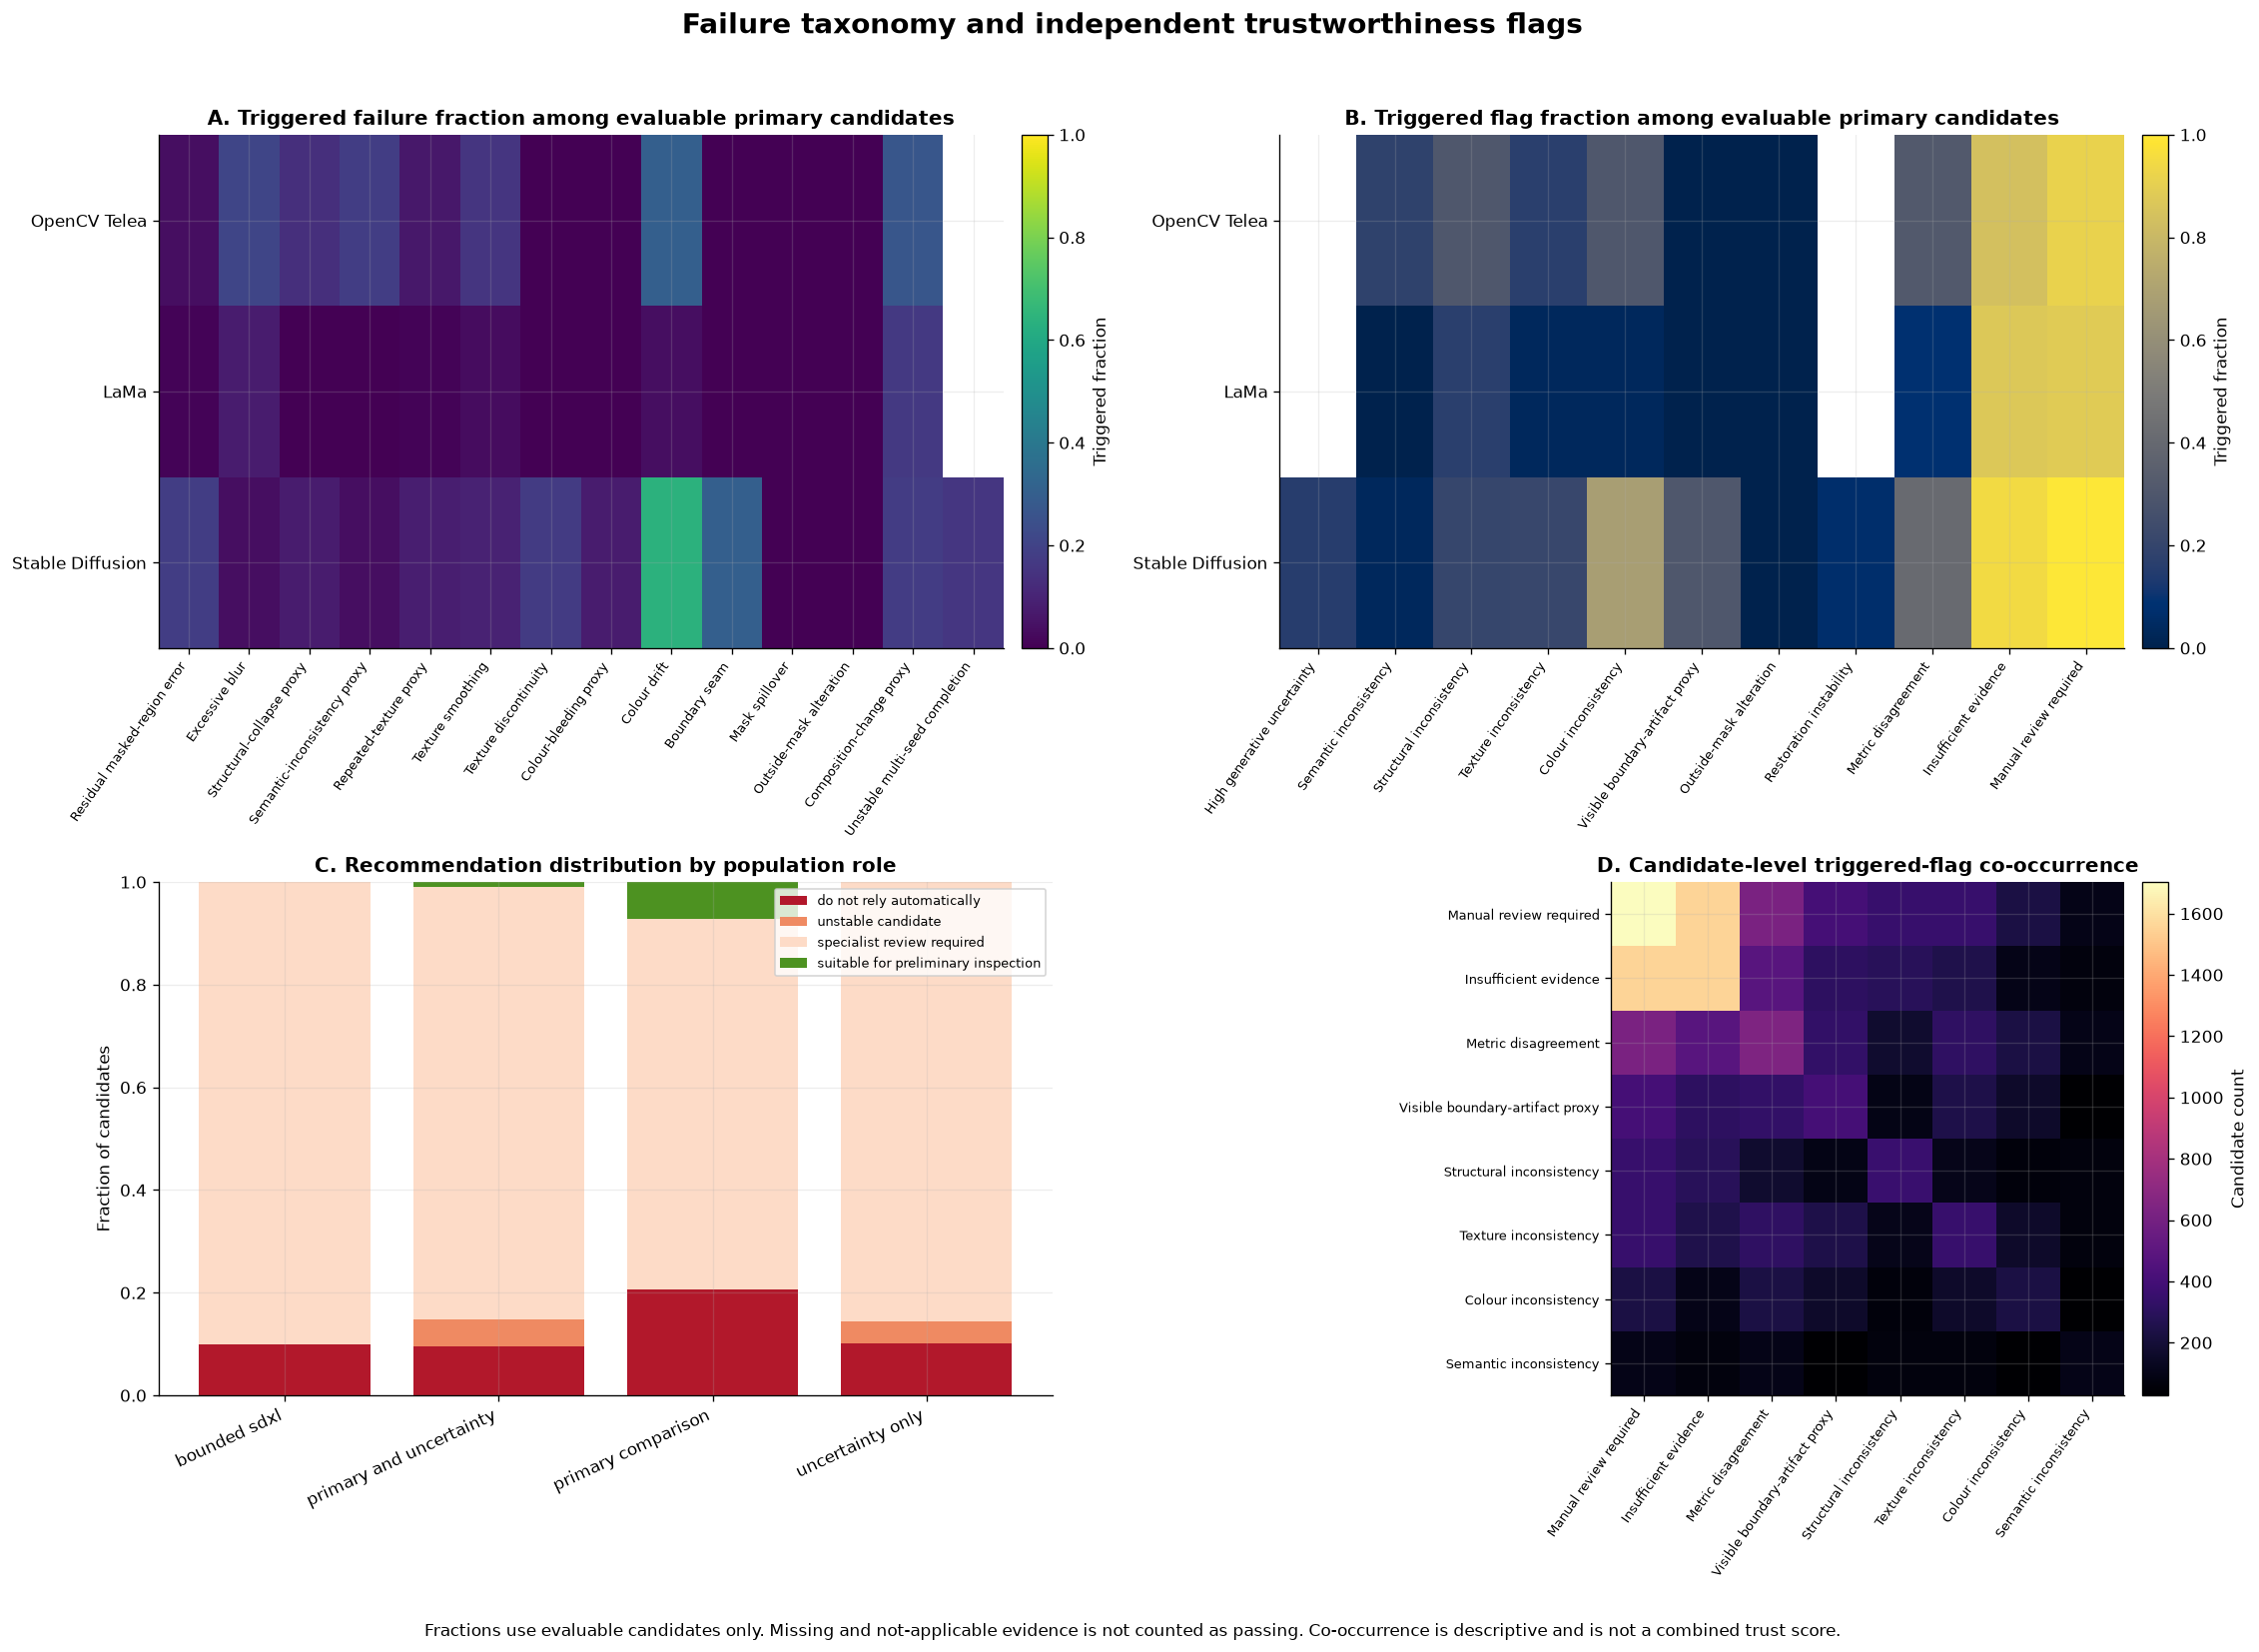

Canonical failure-taxonomy figure generated.
{'format': 'PNG', 'mode': 'RGBA', 'width': 3385, 'height': 2481, 'size_bytes': 483678, 'sha256': 'e5d57203a2ca789aaa0f16c691b71a204820d5b04ed2f3237c3e3b79c3d89fd1'}


In [38]:
model_display_names = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
}

model_order = [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
]

category_order = (
    RELOADED_FAILURE_TAXONOMY[
        "category_id"
    ].astype(str).tolist()
)

category_name_lookup = dict(
    zip(
        RELOADED_FAILURE_TAXONOMY[
            "category_id"
        ].astype(str),
        RELOADED_FAILURE_TAXONOMY[
            "display_name"
        ].astype(str),
    )
)

flag_order = [
    str(definition["flag_id"])
    for definition
    in SETTINGS["trust_flags"]
]

flag_name_lookup = {
    str(definition["flag_id"]): str(
        definition["display_name"]
    )
    for definition
    in SETTINGS["trust_flags"]
}

category_heatmap = (
    CATEGORY_MODEL_PREVALENCE.pivot(
        index="model_id",
        columns="category_id",
        values=(
            "triggered_fraction_among_evaluable"
        ),
    )
    .reindex(
        index=model_order,
        columns=category_order,
    )
)

flag_heatmap = (
    FLAG_MODEL_PREVALENCE.pivot(
        index="model_id",
        columns="flag_id",
        values=(
            "triggered_fraction_among_evaluable"
        ),
    )
    .reindex(
        index=model_order,
        columns=flag_order,
    )
)

recommendation_order = list(
    RECOMMENDATIONS
)

recommendation_role_matrix = (
    RECOMMENDATION_ROLE_SUMMARY.groupby(
        [
            "population_role",
            "recommendation_category",
        ],
        dropna=False,
    )[
        "candidates"
    ]
    .sum()
    .unstack(
        fill_value=0,
    )
    .reindex(
        columns=recommendation_order,
        fill_value=0,
    )
)

recommendation_role_fraction = (
    recommendation_role_matrix.div(
        recommendation_role_matrix.sum(
            axis=1
        ),
        axis=0,
    )
)

top_cooccurrence_flags = (
    FLAG_TRIGGER_MATRIX.sum()
    .sort_values(
        ascending=False
    )
    .head(8)
    .index.tolist()
)

cooccurrence_display = (
    FLAG_COOCCURRENCE_COUNTS.loc[
        top_cooccurrence_flags,
        top_cooccurrence_flags,
    ]
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(19, 14),
)

category_image = axes[0, 0].imshow(
    category_heatmap.to_numpy(
        dtype=float
    ),
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axes[0, 0].set_title(
    "A. Triggered failure fraction among evaluable primary candidates",
    fontweight="bold",
)

axes[0, 0].set_yticks(
    range(
        len(
            category_heatmap.index
        )
    )
)

axes[0, 0].set_yticklabels(
    [
        model_display_names.get(
            model_id,
            model_id,
        )
        for model_id
        in category_heatmap.index
    ]
)

axes[0, 0].set_xticks(
    range(
        len(
            category_heatmap.columns
        )
    )
)

axes[0, 0].set_xticklabels(
    [
        category_name_lookup[
            category_id
        ]
        for category_id
        in category_heatmap.columns
    ],
    rotation=55,
    ha="right",
    fontsize=8,
)

figure.colorbar(
    category_image,
    ax=axes[0, 0],
    fraction=0.035,
    pad=0.02,
    label="Triggered fraction",
)

flag_image = axes[0, 1].imshow(
    flag_heatmap.to_numpy(
        dtype=float
    ),
    aspect="auto",
    cmap="cividis",
    vmin=0.0,
    vmax=1.0,
)

axes[0, 1].set_title(
    "B. Triggered flag fraction among evaluable primary candidates",
    fontweight="bold",
)

axes[0, 1].set_yticks(
    range(
        len(
            flag_heatmap.index
        )
    )
)

axes[0, 1].set_yticklabels(
    [
        model_display_names.get(
            model_id,
            model_id,
        )
        for model_id
        in flag_heatmap.index
    ]
)

axes[0, 1].set_xticks(
    range(
        len(
            flag_heatmap.columns
        )
    )
)

axes[0, 1].set_xticklabels(
    [
        flag_name_lookup[
            flag_id
        ]
        for flag_id
        in flag_heatmap.columns
    ],
    rotation=55,
    ha="right",
    fontsize=8,
)

figure.colorbar(
    flag_image,
    ax=axes[0, 1],
    fraction=0.035,
    pad=0.02,
    label="Triggered fraction",
)

bottom = np.zeros(
    len(
        recommendation_role_fraction
    )
)

recommendation_colours = {
    "do_not_rely_automatically": (
        "#b2182b"
    ),
    "unstable_candidate": (
        "#ef8a62"
    ),
    "specialist_review_required": (
        "#fddbc7"
    ),
    "suitable_for_preliminary_inspection": (
        "#4d9221"
    ),
}

for recommendation in (
    recommendation_order
):
    values = (
        recommendation_role_fraction[
            recommendation
        ].to_numpy(
            dtype=float
        )
    )

    axes[1, 0].bar(
        range(
            len(values)
        ),
        values,
        bottom=bottom,
        label=(
            recommendation.replace(
                "_",
                " ",
            )
        ),
        color=(
            recommendation_colours[
                recommendation
            ]
        ),
    )

    bottom += values

axes[1, 0].set_title(
    "C. Recommendation distribution by population role",
    fontweight="bold",
)

axes[1, 0].set_xticks(
    range(
        len(
            recommendation_role_fraction.index
        )
    )
)

axes[1, 0].set_xticklabels(
    [
        role.replace(
            "_",
            " ",
        )
        for role
        in recommendation_role_fraction.index
    ],
    rotation=25,
    ha="right",
)

axes[1, 0].set_ylim(
    0.0,
    1.0,
)

axes[1, 0].set_ylabel(
    "Fraction of candidates"
)

axes[1, 0].legend(
    fontsize=8,
    loc="upper right",
)

cooccurrence_image = axes[1, 1].imshow(
    cooccurrence_display.to_numpy(
        dtype=float
    ),
    cmap="magma",
    aspect="equal",
)

axes[1, 1].set_title(
    "D. Candidate-level triggered-flag co-occurrence",
    fontweight="bold",
)

axes[1, 1].set_xticks(
    range(
        len(
            cooccurrence_display.columns
        )
    )
)

axes[1, 1].set_yticks(
    range(
        len(
            cooccurrence_display.index
        )
    )
)

axes[1, 1].set_xticklabels(
    [
        flag_name_lookup.get(
            flag_id,
            flag_id,
        )
        for flag_id
        in cooccurrence_display.columns
    ],
    rotation=55,
    ha="right",
    fontsize=8,
)

axes[1, 1].set_yticklabels(
    [
        flag_name_lookup.get(
            flag_id,
            flag_id,
        )
        for flag_id
        in cooccurrence_display.index
    ],
    fontsize=8,
)

figure.colorbar(
    cooccurrence_image,
    ax=axes[1, 1],
    fraction=0.035,
    pad=0.02,
    label="Candidate count",
)

figure.suptitle(
    (
        "Failure taxonomy and independent "
        "trustworthiness flags"
    ),
    fontsize=17,
    fontweight="bold",
)

figure.text(
    0.5,
    0.012,
    (
        "Fractions use evaluable candidates only. "
        "Missing and not-applicable evidence is not "
        "counted as passing. Co-occurrence is descriptive "
        "and is not a combined trust score."
    ),
    ha="center",
    fontsize=10,
)

figure.tight_layout(
    rect=(
        0,
        0.035,
        1,
        0.96,
    )
)

figure.savefig(
    OUTPUT_PATHS[
        "failure_taxonomy_figure"
    ],
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

with Image.open(
    OUTPUT_PATHS[
        "failure_taxonomy_figure"
    ]
) as saved_figure:
    saved_figure.load()

    CANONICAL_FIGURE_METADATA = {
        "format": saved_figure.format,
        "mode": saved_figure.mode,
        "width": int(
            saved_figure.width
        ),
        "height": int(
            saved_figure.height
        ),
        "size_bytes": int(
            OUTPUT_PATHS[
                "failure_taxonomy_figure"
            ].stat().st_size
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "failure_taxonomy_figure"
            ]
        ),
    }

print("Canonical failure-taxonomy figure generated.")
print(CANONICAL_FIGURE_METADATA)

In [39]:
BATCH_8A_STAGE = (
    "batch_8a_analysis_and_figure"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8A_STAGE,
)

primary_candidate_counts = {
    str(key): int(value)
    for key, value
    in (
        PRIMARY_REPORT_ASSIGNMENTS[
            [
                "candidate_id",
                "model_id",
            ]
        ]
        .drop_duplicates()
        [
            "model_id"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

uncertainty_group_consistency = bool(
    UNCERTAINTY_GROUP_FLAG_LEDGER[
        "member_candidates"
    ].eq(4).all()
    and UNCERTAINTY_GROUP_FLAG_LEDGER[
        "status_variants"
    ].eq(1).all()
    and UNCERTAINTY_GROUP_FLAG_LEDGER[
        "severity_variants"
    ].eq(1).all()
)

selection_paths = [
    str(path)
    for column
    in [
        "input_image_path",
        "clean_image_path",
        "mask_or_effect_path",
        "restored_path",
    ]
    for path
    in REPORT_CASE_SELECTIONS[
        column
    ]
]

selection_paths_valid = all(
    (
        PROJECT_ROOT
        / path
    ).resolve().is_file()
    and (
        PROJECT_ROOT
        / path
    ).resolve().is_relative_to(
        PROJECT_ROOT
    )
    for path
    in selection_paths
)

canonical_figure_valid = bool(
    CANONICAL_FIGURE_METADATA[
        "format"
    ]
    == "PNG"
    and CANONICAL_FIGURE_METADATA[
        "width"
    ]
    >= 1800
    and CANONICAL_FIGURE_METADATA[
        "height"
    ]
    >= 1200
    and CANONICAL_FIGURE_METADATA[
        "size_bytes"
    ]
    > 0
)

add_check(
    stage=BATCH_8A_STAGE,
    check_id="primary_comparison_scope",
    description=(
        "Primary descriptive comparison contains "
        "exactly 410 candidates for each core model."
    ),
    expected={
        "lama": 410,
        "opencv_telea": 410,
        "stable_diffusion_inpainting": 410,
    },
    observed=(
        primary_candidate_counts
    ),
    passed=(
        primary_candidate_counts
        == {
            "lama": 410,
            "opencv_telea": 410,
            "stable_diffusion_inpainting": 410,
        }
    ),
)

add_check(
    stage=BATCH_8A_STAGE,
    check_id="uncertainty_group_scope",
    description=(
        "Uncertainty summaries use 165 complete "
        "four-seed groups and preserve one flag "
        "state per group."
    ),
    expected={
        "groups": 165,
        "members": 660,
        "members_per_group": 4,
        "status_variants": 1,
    },
    observed={
        "groups": (
            SUPPORTED_GROUP_MEMBERS[
                "uncertainty_group_id"
            ].nunique()
        ),
        "members": (
            SUPPORTED_GROUP_MEMBERS[
                "candidate_id"
            ].nunique()
        ),
        "minimum_members": int(
            UNCERTAINTY_GROUP_FLAG_LEDGER[
                "member_candidates"
            ].min()
        ),
        "maximum_members": int(
            UNCERTAINTY_GROUP_FLAG_LEDGER[
                "member_candidates"
            ].max()
        ),
        "maximum_status_variants": int(
            UNCERTAINTY_GROUP_FLAG_LEDGER[
                "status_variants"
            ].max()
        ),
    },
    passed=(
        SUPPORTED_GROUP_MEMBERS[
            "uncertainty_group_id"
        ].nunique()
        == 165
        and SUPPORTED_GROUP_MEMBERS[
            "candidate_id"
        ].nunique()
        == 660
        and uncertainty_group_consistency
    ),
)

add_check(
    stage=BATCH_8A_STAGE,
    check_id="diagnostic_selection_exact",
    description=(
        "Seven distinct candidates represent all "
        "approved diagnostic-panel roles."
    ),
    expected={
        "panels": 7,
        "unique_candidates": 7,
    },
    observed={
        "panels": len(
            REPORT_CASE_SELECTIONS
        ),
        "unique_candidates": (
            REPORT_CASE_SELECTIONS[
                "candidate_id"
            ].nunique()
        ),
    },
    passed=(
        len(
            REPORT_CASE_SELECTIONS
        )
        == 7
        and REPORT_CASE_SELECTIONS[
            "candidate_id"
        ].nunique()
        == 7
        and REPORT_CASE_SELECTIONS[
            "panel_id"
        ].is_unique
    ),
)

add_check(
    stage=BATCH_8A_STAGE,
    check_id="diagnostic_selection_paths",
    description=(
        "Every selected clean, damaged, mask, and "
        "restored image exists inside the repository."
    ),
    expected=28,
    observed=sum(
        (
            PROJECT_ROOT
            / path
        ).resolve().is_file()
        for path
        in selection_paths
    ),
    passed=(
        len(
            selection_paths
        )
        == 28
        and selection_paths_valid
    ),
)

add_check(
    stage=BATCH_8A_STAGE,
    check_id="canonical_figure_readable",
    description=(
        "The canonical figure is a readable, "
        "non-empty report-ready PNG."
    ),
    expected={
        "format": "PNG",
        "minimum_width": 1800,
        "minimum_height": 1200,
    },
    observed=(
        CANONICAL_FIGURE_METADATA
    ),
    passed=(
        canonical_figure_valid
    ),
)

expected_batch_8a_paths = {
    OUTPUT_PATHS[
        "failure_taxonomy"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_assignments"
    ].resolve(),
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_taxonomy_figure"
    ].resolve(),
}

observed_batch_8a_paths = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

add_check(
    stage=BATCH_8A_STAGE,
    check_id="batch_8a_artifact_scope",
    description=(
        "Batch 8A adds only the declared canonical "
        "figure to the three persisted CSV files."
    ),
    expected=4,
    observed=len(
        observed_batch_8a_paths
    ),
    passed=(
        observed_batch_8a_paths
        == expected_batch_8a_paths
    ),
)

BATCH_8A_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_8A_VALIDATION.loc[
        BATCH_8A_VALIDATION[
            "validation_stage"
        ].eq(BATCH_8A_STAGE)
    ]
)

BATCH_8A_SUMMARY = VALIDATION.summary()

print("Batch 8A analysis and figure complete.")
print(
    "Selected diagnostic panels: "
    f"{len(REPORT_CASE_SELECTIONS):,}"
)
print(
    "Canonical figure files: 1"
)
print(
    "Total validation checks: "
    f"{BATCH_8A_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_8A_SUMMARY['blocking_failure_count']:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
117,batch_8a_analysis_and_figure,primary_comparison_scope,Primary descriptive comparison contains exactly 410 candidates for each core model.,blocking,"{""lama"": 410, ""opencv_telea"": 410, ""stable_diffusion_inpainting"": 410}","{""lama"": 410, ""opencv_telea"": 410, ""stable_diffusion_inpainting"": 410}",True,
118,batch_8a_analysis_and_figure,uncertainty_group_scope,Uncertainty summaries use 165 complete four-seed groups and preserve one flag state per group.,blocking,"{""groups"": 165, ""members"": 660, ""members_per_group"": 4, ""status_variants"": 1}","{""groups"": 165, ""maximum_members"": 4, ""maximum_status_variants"": 1, ""members"": 660, ""minimum_members"": 4}",True,
119,batch_8a_analysis_and_figure,diagnostic_selection_exact,Seven distinct candidates represent all approved diagnostic-panel roles.,blocking,"{""panels"": 7, ""unique_candidates"": 7}","{""panels"": 7, ""unique_candidates"": 7}",True,
120,batch_8a_analysis_and_figure,diagnostic_selection_paths,"Every selected clean, damaged, mask, and restored image exists inside the repository.",blocking,28,28,True,
121,batch_8a_analysis_and_figure,canonical_figure_readable,"The canonical figure is a readable, non-empty report-ready PNG.",blocking,"{""format"": ""PNG"", ""minimum_height"": 1200, ""minimum_width"": 1800}","{""format"": ""PNG"", ""height"": 2481, ""mode"": ""RGBA"", ""sha256"": ""e5d57203a2ca789aaa0f16c691b71a204820d5b04ed2f3237c3e3b79c3d89fd1"", ""size_bytes"": 483678, ""width"": 3385}",True,
122,batch_8a_analysis_and_figure,batch_8a_artifact_scope,Batch 8A adds only the declared canonical figure to the three persisted CSV files.,blocking,4,4,True,


Batch 8A analysis and figure complete.
Selected diagnostic panels: 7
Canonical figure files: 1
Total validation checks: 123
Blocking failures: 0


### Batch 8B — Self-contained report assembly and validation

Build the approved fifteen-section report using canonical analytical tables, seven embedded analytical views, and seven deterministic diagnostic panels.

The report embeds every required image directly. It does not retain a combined trust score, calibrated confidence claim, conservation approval, or unsupported SDXL model ranking.

In [40]:
import base64
import re
from html import escape as html_escape
from io import BytesIO


REPORT_POLICY = SETTINGS["report"]

REPORT_ANALYTICAL_VIEWS = []


def bytes_to_data_uri(
    payload: bytes,
    *,
    mime_type: str,
) -> str:
    """Encode binary image content as a self-contained data URI."""
    encoded = base64.b64encode(
        payload
    ).decode("ascii")

    return (
        f"data:{mime_type};"
        f"base64,{encoded}"
    )


def file_to_data_uri(
    path: Path,
    *,
    mime_type: str,
) -> str:
    """Encode one existing repository image."""
    return bytes_to_data_uri(
        path.read_bytes(),
        mime_type=mime_type,
    )


def register_report_figure(
    figure,
    *,
    view_id: str,
    title: str,
    section_id: str,
    caption: str,
) -> None:
    """Encode an in-memory analytical figure and register its role."""
    buffer = BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(figure)

    REPORT_ANALYTICAL_VIEWS.append(
        {
            "view_id": view_id,
            "title": title,
            "section_id": section_id,
            "caption": caption,
            "image_uri": bytes_to_data_uri(
                buffer.getvalue(),
                mime_type="image/png",
            ),
            "source": (
                "Notebook 27 in-memory "
                "canonical analysis"
            ),
        }
    )


REPORT_ANALYTICAL_VIEWS.append(
    {
        "view_id": "canonical_overview",
        "title": (
            "Canonical failure-taxonomy overview"
        ),
        "section_id": "executive_summary",
        "caption": (
            "Primary-model failure fractions, "
            "independent flag prevalence, "
            "recommendation distributions, and "
            "candidate-level flag co-occurrence."
        ),
        "image_uri": file_to_data_uri(
            OUTPUT_PATHS[
                "failure_taxonomy_figure"
            ],
            mime_type="image/png",
        ),
        "source": (
            OUTPUT_PATHS[
                "failure_taxonomy_figure"
            ]
            .relative_to(PROJECT_ROOT)
            .as_posix()
        ),
    }
)

figure, axis = plt.subplots(
    figsize=(15, 5.8)
)

category_plot_image = axis.imshow(
    category_heatmap.to_numpy(
        dtype=float
    ),
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axis.set_title(
    "Triggered failure-category fraction by primary model",
    fontweight="bold",
)

axis.set_yticks(
    range(len(category_heatmap.index))
)

axis.set_yticklabels(
    [
        model_display_names.get(
            model_id,
            model_id,
        )
        for model_id
        in category_heatmap.index
    ]
)

axis.set_xticks(
    range(len(category_heatmap.columns))
)

axis.set_xticklabels(
    [
        category_name_lookup[
            category_id
        ]
        for category_id
        in category_heatmap.columns
    ],
    rotation=50,
    ha="right",
    fontsize=8,
)

figure.colorbar(
    category_plot_image,
    ax=axis,
    fraction=0.025,
    pad=0.02,
    label=(
        "Triggered fraction among "
        "evaluable candidates"
    ),
)

figure.tight_layout()

register_report_figure(
    figure,
    view_id="category_prevalence",
    title="Failure-category prevalence",
    section_id="taxonomy_overview",
    caption=(
        "Fractions use only candidates with "
        "evaluable evidence for the category. "
        "Insufficient evidence is not counted "
        "as passing."
    ),
)

figure, axis = plt.subplots(
    figsize=(14, 5.8)
)

flag_plot_image = axis.imshow(
    flag_heatmap.to_numpy(
        dtype=float
    ),
    aspect="auto",
    cmap="cividis",
    vmin=0.0,
    vmax=1.0,
)

axis.set_title(
    "Triggered independent-flag fraction by primary model",
    fontweight="bold",
)

axis.set_yticks(
    range(len(flag_heatmap.index))
)

axis.set_yticklabels(
    [
        model_display_names.get(
            model_id,
            model_id,
        )
        for model_id
        in flag_heatmap.index
    ]
)

axis.set_xticks(
    range(len(flag_heatmap.columns))
)

axis.set_xticklabels(
    [
        flag_name_lookup[
            flag_id
        ]
        for flag_id
        in flag_heatmap.columns
    ],
    rotation=50,
    ha="right",
    fontsize=8,
)

figure.colorbar(
    flag_plot_image,
    ax=axis,
    fraction=0.025,
    pad=0.02,
    label=(
        "Triggered fraction among "
        "evaluable candidates"
    ),
)

figure.tight_layout()

register_report_figure(
    figure,
    view_id="flag_prevalence",
    title="Independent trustworthiness flags",
    section_id="trustworthiness_flags",
    caption=(
        "Each flag remains independently "
        "interpretable. The figure is not a "
        "combined trust score."
    ),
)

report_model_names = {
    **model_display_names,
    "sdxl_inpainting": "SDXL",
}

recommendation_model_matrix = (
    REPORT_RECOMMENDATIONS.groupby(
        [
            "model_id",
            "recommendation_category",
        ],
        dropna=False,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=recommendation_order,
        fill_value=0,
    )
)

recommendation_model_fraction = (
    recommendation_model_matrix.div(
        recommendation_model_matrix.sum(
            axis=1
        ),
        axis=0,
    )
)

figure, axis = plt.subplots(
    figsize=(11.5, 6.2)
)

bottom = np.zeros(
    len(recommendation_model_fraction)
)

for recommendation in recommendation_order:
    values = (
        recommendation_model_fraction[
            recommendation
        ].to_numpy(dtype=float)
    )

    axis.bar(
        range(len(values)),
        values,
        bottom=bottom,
        label=(
            recommendation.replace(
                "_",
                " ",
            )
        ),
        color=(
            recommendation_colours[
                recommendation
            ]
        ),
    )

    bottom += values

axis.set_title(
    "Candidate recommendation distribution by model",
    fontweight="bold",
)

axis.set_ylabel("Fraction of candidates")
axis.set_ylim(0.0, 1.0)

axis.set_xticks(
    range(
        len(
            recommendation_model_fraction.index
        )
    )
)

axis.set_xticklabels(
    [
        report_model_names.get(
            model_id,
            model_id,
        )
        for model_id
        in recommendation_model_fraction.index
    ],
    rotation=20,
    ha="right",
)

axis.legend(
    fontsize=8,
    loc="upper right",
)

figure.tight_layout()

register_report_figure(
    figure,
    view_id="recommendations_by_model",
    title="Recommendations by model",
    section_id="candidate_recommendations",
    caption=(
        "Recommendations are operational "
        "decision support. They do not constitute "
        "conservation approval."
    ),
)

uncertainty_status_matrix = (
    UNCERTAINTY_GROUP_SUMMARY.groupby(
        [
            "flag_name",
            "flag_status",
        ],
        dropna=False,
    )[
        "groups"
    ]
    .sum()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "triggered",
            "not_triggered",
            "insufficient_evidence",
            "not_applicable",
        ],
        fill_value=0,
    )
)

figure, axis = plt.subplots(
    figsize=(11.5, 5.8)
)

uncertainty_status_colours = {
    "triggered": "#b2182b",
    "not_triggered": "#4d9221",
    "insufficient_evidence": "#fdae61",
    "not_applicable": "#bdbdbd",
}

bottom = np.zeros(
    len(uncertainty_status_matrix)
)

for status in uncertainty_status_matrix.columns:
    values = (
        uncertainty_status_matrix[
            status
        ].to_numpy(dtype=float)
    )

    axis.bar(
        range(len(values)),
        values,
        bottom=bottom,
        label=status.replace("_", " "),
        color=uncertainty_status_colours[
            status
        ],
    )

    bottom += values

axis.set_title(
    "Supported repeated-seed groups by uncertainty flag",
    fontweight="bold",
)

axis.set_ylabel("Uncertainty groups")

axis.set_xticks(
    range(len(uncertainty_status_matrix))
)

axis.set_xticklabels(
    uncertainty_status_matrix.index,
    rotation=15,
    ha="right",
)

axis.legend(
    fontsize=8,
    loc="upper right",
)

figure.tight_layout()

register_report_figure(
    figure,
    view_id="uncertainty_group_status",
    title="Repeated-seed uncertainty evidence",
    section_id="uncertainty_and_instability",
    caption=(
        "The analysis uses 165 supported four-seed "
        "groups. Telea and LaMa are deterministic, "
        "and bounded SDXL has insufficient seed "
        "coverage."
    ),
)

coverage_plot_table = (
    RELOADED_FAILURE_ASSIGNMENTS.groupby(
        [
            "category_name",
            "assignment_status",
        ],
        dropna=False,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "triggered",
            "not_triggered",
            "insufficient_evidence",
            "not_applicable",
        ],
        fill_value=0,
    )
)

coverage_plot_fraction = (
    coverage_plot_table.div(
        coverage_plot_table.sum(axis=1),
        axis=0,
    )
)

figure, axis = plt.subplots(
    figsize=(13, 7.2)
)

bottom = np.zeros(
    len(coverage_plot_fraction)
)

for status in coverage_plot_fraction.columns:
    values = (
        coverage_plot_fraction[
            status
        ].to_numpy(dtype=float)
    )

    axis.barh(
        range(len(values)),
        values,
        left=bottom,
        label=status.replace("_", " "),
        color=uncertainty_status_colours[
            status
        ],
    )

    bottom += values

axis.set_title(
    "Failure-category evidence and decision states",
    fontweight="bold",
)

axis.set_xlabel("Fraction of the 1,785-candidate union")

axis.set_yticks(
    range(len(coverage_plot_fraction))
)

axis.set_yticklabels(
    coverage_plot_fraction.index,
    fontsize=8,
)

axis.set_xlim(0.0, 1.0)

axis.legend(
    fontsize=8,
    loc="lower right",
)

figure.tight_layout()

register_report_figure(
    figure,
    view_id="evidence_coverage",
    title="Evidence coverage and missingness",
    section_id=(
        "evidence_coverage_and_missingness"
    ),
    caption=(
        "Insufficient and not-applicable states "
        "remain visible instead of being treated "
        "as successful outcomes."
    ),
)

figure, axis = plt.subplots(
    figsize=(9.5, 8.2)
)

cooccurrence_plot_image = axis.imshow(
    cooccurrence_display.to_numpy(
        dtype=float
    ),
    cmap="magma",
    aspect="equal",
)

axis.set_title(
    "Triggered-flag co-occurrence",
    fontweight="bold",
)

axis.set_xticks(
    range(len(cooccurrence_display.columns))
)

axis.set_yticks(
    range(len(cooccurrence_display.index))
)

axis.set_xticklabels(
    [
        flag_name_lookup.get(
            flag_id,
            flag_id,
        )
        for flag_id
        in cooccurrence_display.columns
    ],
    rotation=50,
    ha="right",
    fontsize=8,
)

axis.set_yticklabels(
    [
        flag_name_lookup.get(
            flag_id,
            flag_id,
        )
        for flag_id
        in cooccurrence_display.index
    ],
    fontsize=8,
)

figure.colorbar(
    cooccurrence_plot_image,
    ax=axis,
    fraction=0.04,
    pad=0.03,
    label="Candidate count",
)

figure.tight_layout()

register_report_figure(
    figure,
    view_id="flag_cooccurrence",
    title="Metric disagreement and flag co-occurrence",
    section_id=(
        "metric_disagreement_and_cooccurrence"
    ),
    caption=(
        "Co-occurrence identifies candidates "
        "requiring multi-domain review. It is "
        "descriptive and is not an aggregate score."
    ),
)

display(
    pd.DataFrame(
        REPORT_ANALYTICAL_VIEWS
    )[
        [
            "view_id",
            "title",
            "section_id",
            "source",
        ]
    ]
)

print("Embedded analytical views prepared.")
print(
    "Analytical views: "
    f"{len(REPORT_ANALYTICAL_VIEWS):,}"
)
print(
    "Persisted additional figure files: 0"
)

,view_id,title,section_id,source
0,canonical_overview,Canonical failure-taxonomy overview,executive_summary,outputs/27_failure_taxonomy_and_trustworthiness_flags/figures/failure_taxonomy.png
1,category_prevalence,Failure-category prevalence,taxonomy_overview,Notebook 27 in-memory canonical analysis
2,flag_prevalence,Independent trustworthiness flags,trustworthiness_flags,Notebook 27 in-memory canonical analysis
3,recommendations_by_model,Recommendations by model,candidate_recommendations,Notebook 27 in-memory canonical analysis
4,uncertainty_group_status,Repeated-seed uncertainty evidence,uncertainty_and_instability,Notebook 27 in-memory canonical analysis
5,evidence_coverage,Evidence coverage and missingness,evidence_coverage_and_missingness,Notebook 27 in-memory canonical analysis
6,flag_cooccurrence,Metric disagreement and flag co-occurrence,metric_disagreement_and_cooccurrence,Notebook 27 in-memory canonical analysis


Embedded analytical views prepared.
Analytical views: 7
Persisted additional figure files: 0


In [41]:
REPORT_DIAGNOSTIC_PANELS = []
REPORT_SOURCE_DEPENDENCIES = []

REPORT_IMAGE_MAX_DIMENSION = int(
    REPORT_POLICY[
        "image_max_dimension_pixels"
    ]
)

REPORT_JPEG_QUALITY = int(
    REPORT_POLICY[
        "photographic_quality"
    ]
)


def pil_image_to_data_uri(
    image: Image.Image,
    *,
    image_format: str,
) -> str:
    """Resize and encode one report tile."""
    prepared = image.copy()

    prepared.thumbnail(
        (
            REPORT_IMAGE_MAX_DIMENSION,
            REPORT_IMAGE_MAX_DIMENSION,
        ),
        Image.Resampling.LANCZOS,
    )

    buffer = BytesIO()

    if image_format == "JPEG":
        prepared = prepared.convert("RGB")

        prepared.save(
            buffer,
            format="JPEG",
            quality=REPORT_JPEG_QUALITY,
            optimize=True,
        )

        mime_type = "image/jpeg"
    else:
        prepared.save(
            buffer,
            format="PNG",
            optimize=True,
        )

        mime_type = "image/png"

    return bytes_to_data_uri(
        buffer.getvalue(),
        mime_type=mime_type,
    )


def normalized_mask_bbox(
    mask: Image.Image,
) -> tuple[float, float, float, float]:
    """Return a padded mask bounding box in normalized coordinates."""
    mask_array = np.asarray(
        mask.convert("L")
    )

    rows, columns = np.where(
        mask_array > 0
    )

    if not len(rows) or not len(columns):
        raise ValueError(
            "A selected report mask contains "
            "no positive pixels."
        )

    left = int(columns.min())
    top = int(rows.min())
    right = int(columns.max()) + 1
    bottom = int(rows.max()) + 1

    width = mask_array.shape[1]
    height = mask_array.shape[0]

    horizontal_padding = max(
        8,
        int((right - left) * 0.18),
    )

    vertical_padding = max(
        8,
        int((bottom - top) * 0.18),
    )

    left = max(0, left - horizontal_padding)
    top = max(0, top - vertical_padding)
    right = min(
        width,
        right + horizontal_padding,
    )
    bottom = min(
        height,
        bottom + vertical_padding,
    )

    return (
        left / width,
        top / height,
        right / width,
        bottom / height,
    )


def crop_with_normalized_bbox(
    image: Image.Image,
    bbox: tuple[float, float, float, float],
) -> Image.Image:
    """Apply a normalized crop consistently across related images."""
    left, top, right, bottom = bbox

    pixel_bbox = (
        max(0, int(round(left * image.width))),
        max(0, int(round(top * image.height))),
        min(
            image.width,
            int(round(right * image.width)),
        ),
        min(
            image.height,
            int(round(bottom * image.height)),
        ),
    )

    if (
        pixel_bbox[2] <= pixel_bbox[0]
        or pixel_bbox[3] <= pixel_bbox[1]
    ):
        raise ValueError(
            "Computed report crop is empty."
        )

    return image.crop(pixel_bbox)


for report_row in (
    REPORT_CASE_SELECTIONS.itertuples(
        index=False
    )
):
    source_paths = {
        "clean": (
            PROJECT_ROOT
            / str(
                report_row.clean_image_path
            )
        ).resolve(),
        "input": (
            PROJECT_ROOT
            / str(
                report_row.input_image_path
            )
        ).resolve(),
        "mask": (
            PROJECT_ROOT
            / str(
                report_row.mask_or_effect_path
            )
        ).resolve(),
        "restored": (
            PROJECT_ROOT
            / str(
                report_row.restored_path
            )
        ).resolve(),
    }

    for source_role, source_path in (
        source_paths.items()
    ):
        REPORT_SOURCE_DEPENDENCIES.append(
            {
                "panel_id": (
                    report_row.panel_id
                ),
                "candidate_id": (
                    report_row.candidate_id
                ),
                "source_role": source_role,
                "relative_path": (
                    source_path
                    .relative_to(PROJECT_ROOT)
                    .as_posix()
                ),
                "exists": (
                    source_path.is_file()
                ),
            }
        )

    with Image.open(
        source_paths["clean"]
    ) as source:
        clean_image = source.convert(
            "RGB"
        ).copy()

    with Image.open(
        source_paths["input"]
    ) as source:
        input_image = source.convert(
            "RGB"
        ).copy()

    with Image.open(
        source_paths["mask"]
    ) as source:
        mask_image = source.convert(
            "L"
        ).copy()

    with Image.open(
        source_paths["restored"]
    ) as source:
        restored_image = source.convert(
            "RGB"
        ).copy()

    report_bbox = normalized_mask_bbox(
        mask_image
    )

    clean_crop = crop_with_normalized_bbox(
        clean_image,
        report_bbox,
    )

    input_crop = crop_with_normalized_bbox(
        input_image,
        report_bbox,
    )

    restored_crop = crop_with_normalized_bbox(
        restored_image,
        report_bbox,
    )

    tile_specs = [
        (
            "clean_full",
            "Clean reference",
            clean_image,
            "JPEG",
        ),
        (
            "input_full",
            "Damaged input",
            input_image,
            "JPEG",
        ),
        (
            "mask_full",
            "Damage or effect mask",
            mask_image,
            "PNG",
        ),
        (
            "restored_full",
            "Restored candidate",
            restored_image,
            "JPEG",
        ),
        (
            "clean_crop",
            "Reference repair crop",
            clean_crop,
            "JPEG",
        ),
        (
            "input_crop",
            "Damaged repair crop",
            input_crop,
            "JPEG",
        ),
        (
            "restored_crop",
            "Restored repair crop",
            restored_crop,
            "JPEG",
        ),
    ]

    report_tiles = [
        {
            "tile_id": tile_id,
            "label": label,
            "image_uri": (
                pil_image_to_data_uri(
                    image,
                    image_format=image_format,
                )
            ),
        }
        for (
            tile_id,
            label,
            image,
            image_format,
        )
        in tile_specs
    ]

    triggered_category_names = (
        RELOADED_FAILURE_ASSIGNMENTS.loc[
            RELOADED_FAILURE_ASSIGNMENTS[
                "candidate_id"
            ].eq(report_row.candidate_id)
            & RELOADED_FAILURE_ASSIGNMENTS[
                "assignment_status"
            ].eq("triggered"),
            "category_name",
        ]
        .astype(str)
        .tolist()
    )

    triggered_flag_names = (
        RELOADED_TRUSTWORTHINESS_FLAGS.loc[
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "candidate_id"
            ].eq(report_row.candidate_id)
            & RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_status"
            ].eq("triggered"),
            "flag_name",
        ]
        .astype(str)
        .tolist()
    )

    REPORT_DIAGNOSTIC_PANELS.append(
        {
            "panel_id": (
                report_row.panel_id
            ),
            "panel_title": (
                report_row.panel_title
            ),
            "candidate_id": (
                report_row.candidate_id
            ),
            "case_id": (
                report_row.case_id
            ),
            "painting_id": (
                report_row.painting_id
            ),
            "model_id": (
                report_row.model_id
            ),
            "experiment_id": (
                report_row.experiment_id
            ),
            "population_role": (
                report_row.population_role
            ),
            "recommendation_category": (
                report_row
                .recommendation_category
            ),
            "selection_rule": (
                report_row.selection_rule
            ),
            "interpretation_role": (
                report_row
                .interpretation_role
            ),
            "triggered_category_names": (
                triggered_category_names
            ),
            "triggered_flag_names": (
                triggered_flag_names
            ),
            "tiles": report_tiles,
        }
    )


REPORT_TILE_COUNT = sum(
    len(panel["tiles"])
    for panel
    in REPORT_DIAGNOSTIC_PANELS
)

REPORT_SOURCE_DEPENDENCIES = (
    pd.DataFrame(
        REPORT_SOURCE_DEPENDENCIES
    )
)

diagnostic_panel_summary = pd.DataFrame(
    [
        {
            "panel_id": panel["panel_id"],
            "candidate_id": (
                panel["candidate_id"]
            ),
            "case_id": panel["case_id"],
            "painting_id": (
                panel["painting_id"]
            ),
            "model_id": panel["model_id"],
            "recommendation": (
                panel[
                    "recommendation_category"
                ]
            ),
            "triggered_categories": len(
                panel[
                    "triggered_category_names"
                ]
            ),
            "triggered_flags": len(
                panel[
                    "triggered_flag_names"
                ]
            ),
            "embedded_tiles": len(
                panel["tiles"]
            ),
        }
        for panel
        in REPORT_DIAGNOSTIC_PANELS
    ]
)

display(diagnostic_panel_summary)

print("Diagnostic panels encoded.")
print(
    "Diagnostic panels: "
    f"{len(REPORT_DIAGNOSTIC_PANELS):,}"
)
print(
    "Embedded diagnostic tiles: "
    f"{REPORT_TILE_COUNT:,}"
)
print(
    "Available source dependencies: "
    f"{int(REPORT_SOURCE_DEPENDENCIES['exists'].sum()):,}/"
    f"{len(REPORT_SOURCE_DEPENDENCIES):,}"
)

,panel_id,candidate_id,case_id,painting_id,model_id,recommendation,triggered_categories,triggered_flags,embedded_tiles
0,critical_blocker_case,sd15__p00__s2029__726922736f1b,canonical__p011__loss_large,p011,stable_diffusion_inpainting,do_not_rely_automatically,11,10,7
1,unstable_seed_case,sd15__p05__s2028__7dc5f761377d,canonical__p002__scratch_thin,p002,stable_diffusion_inpainting,unstable_candidate,7,7,7
2,metric_disagreement_case,sd15__p00__s2029__8b3acffa89b3,canonical__p044__loss_large,p044,stable_diffusion_inpainting,do_not_rely_automatically,6,7,7
3,boundary_case,sd15__p05__s2026__95811f541d1b,canonical__p036__scratch_thin,p036,stable_diffusion_inpainting,do_not_rely_automatically,10,9,7
4,colour_case,sd15__p00__s2026__7e691dcbc37d,mask_robustness__p001__scratch_thin__target_02pct__variant_02,p001,stable_diffusion_inpainting,do_not_rely_automatically,10,7,7
5,preliminary_case,candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00,synthetic_degradation__p001__dirt_dust__mild,p001,lama,suitable_for_preliminary_inspection,0,0,7
6,bounded_sdxl_case,sdxl__c2cd75943649__p00_generic__seed2026,synthetic_degradation__p018__dirt_dust__severe,p018,sdxl_inpainting,specialist_review_required,7,6,7


Diagnostic panels encoded.
Diagnostic panels: 7
Embedded diagnostic tiles: 49
Available source dependencies: 28/28


In [42]:
REPORT_REQUIRED_SECTIONS = list(
    REPORT_POLICY[
        "required_section_ids"
    ]
)

section_titles = {
    "executive_summary": "Executive summary",
    "evaluation_population": "Evaluation population",
    "rule_interpretation": "How to interpret the rules",
    "threshold_calibration": "Threshold calibration",
    "taxonomy_overview": "Failure taxonomy overview",
    "visual_failure_atlas": "Visual failure atlas",
    "trustworthiness_flags": "Trustworthiness flags",
    "model_and_experiment_patterns": "Model and experiment patterns",
    "uncertainty_and_instability": "Uncertainty and instability",
    "metric_disagreement_and_cooccurrence": (
        "Metric disagreement and co-occurrence"
    ),
    "evidence_coverage_and_missingness": (
        "Evidence coverage and missingness"
    ),
    "candidate_recommendations": "Candidate recommendations",
    "internal_consistency": "Internal consistency",
    "thesis_conclusions": "Thesis conclusions",
    "limitations_and_provenance": (
        "Limitations and provenance"
    ),
}

traceability_rows = [
    {
        "mock_element_id": (
            f"section_{section_id}"
        ),
        "approved_role": (
            section_titles[section_id]
        ),
        "final_section": section_id,
        "canonical_evidence_source": (
            "Notebook 27 canonical tables "
            "and validated upstream evidence"
        ),
        "implementation_status": (
            "preserved_and_upgraded"
        ),
        "deviation_reason": "",
    }
    for section_id
    in REPORT_REQUIRED_SECTIONS
]

traceability_rows.extend(
    [
        {
            "mock_element_id": (
                f"view_{view['view_id']}"
            ),
            "approved_role": view["title"],
            "final_section": (
                view["section_id"]
            ),
            "canonical_evidence_source": (
                view["source"]
            ),
            "implementation_status": (
                "preserved_and_upgraded"
            ),
            "deviation_reason": "",
        }
        for view
        in REPORT_ANALYTICAL_VIEWS
    ]
)

traceability_rows.extend(
    [
        {
            "mock_element_id": (
                f"panel_{panel['panel_id']}"
            ),
            "approved_role": (
                panel["panel_title"]
            ),
            "final_section": (
                "visual_failure_atlas"
            ),
            "canonical_evidence_source": (
                panel["candidate_id"]
            ),
            "implementation_status": (
                "preserved_and_upgraded"
            ),
            "deviation_reason": "",
        }
        for panel
        in REPORT_DIAGNOSTIC_PANELS
    ]
)

MOCK_TO_FINAL_TRACEABILITY = (
    pd.DataFrame(traceability_rows)
)

REPORT_POPULATION_TABLE = (
    CANDIDATE_POPULATION.groupby(
        [
            "population_role",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        experiments=(
            "experiment_id",
            "nunique",
        ),
    )
    .reset_index()
)

REPORT_MODEL_BURDEN = (
    CATEGORY_MODEL_PREVALENCE.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        mean_triggered_fraction=(
            "triggered_fraction_among_evaluable",
            "mean",
        ),
        triggered_assignments=(
            "triggered_candidates",
            "sum",
        ),
        evaluable_assignments=(
            "evaluable_candidates",
            "sum",
        ),
    )
    .reset_index()
)

REPORT_MODEL_BURDEN[
    "triggered_assignment_fraction"
] = (
    REPORT_MODEL_BURDEN[
        "triggered_assignments"
    ]
    / REPORT_MODEL_BURDEN[
        "evaluable_assignments"
    ]
)

REPORT_MODEL_BURDEN[
    "model"
] = (
    REPORT_MODEL_BURDEN[
        "model_id"
    ].map(report_model_names)
    .fillna(
        REPORT_MODEL_BURDEN[
            "model_id"
        ]
    )
)

REPORT_MODEL_BURDEN = (
    REPORT_MODEL_BURDEN.sort_values(
        [
            "mean_triggered_fraction",
            "model_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

REPORT_EXPERIMENT_PATTERNS = (
    PRIMARY_REPORT_ASSIGNMENTS.groupby(
        [
            "experiment_id",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        evaluable_assignments=(
            "assignment_status",
            lambda values: int(
                values.isin(
                    [
                        "triggered",
                        "not_triggered",
                    ]
                ).sum()
            ),
        ),
        triggered_assignments=(
            "assignment_status",
            lambda values: int(
                values.eq("triggered").sum()
            ),
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .reset_index()
)

REPORT_EXPERIMENT_PATTERNS[
    "triggered_fraction"
] = np.where(
    REPORT_EXPERIMENT_PATTERNS[
        "evaluable_assignments"
    ].gt(0),
    REPORT_EXPERIMENT_PATTERNS[
        "triggered_assignments"
    ]
    / REPORT_EXPERIMENT_PATTERNS[
        "evaluable_assignments"
    ],
    np.nan,
)

REPORT_EXPERIMENT_PATTERNS[
    "model"
] = (
    REPORT_EXPERIMENT_PATTERNS[
        "model_id"
    ].map(report_model_names)
    .fillna(
        REPORT_EXPERIMENT_PATTERNS[
            "model_id"
        ]
    )
)

REPORT_RECOMMENDATION_COUNTS = (
    REPORT_RECOMMENDATIONS.groupby(
        "recommendation_category",
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .reindex(
        recommendation_order,
        fill_value=0,
    )
    .reset_index()
)

REPORT_RECOMMENDATION_COUNTS[
    "fraction"
] = (
    REPORT_RECOMMENDATION_COUNTS[
        "candidates"
    ]
    / REPORT_RECOMMENDATIONS[
        "candidate_id"
    ].nunique()
)

REPORT_ASSIGNMENT_STATUS_TOTALS = (
    RELOADED_FAILURE_ASSIGNMENTS[
        "assignment_status"
    ]
    .value_counts()
    .rename_axis("assignment_status")
    .reset_index(name="rows")
)

REPORT_FLAG_STATUS_TOTALS = (
    RELOADED_TRUSTWORTHINESS_FLAGS[
        "flag_status"
    ]
    .value_counts()
    .rename_axis("flag_status")
    .reset_index(name="rows")
)

REPORT_THRESHOLD_EXAMPLES = (
    OPERATIONAL_THRESHOLDS.loc[
        OPERATIONAL_THRESHOLDS[
            "status"
        ].eq("ok")
        if OPERATIONAL_THRESHOLDS[
            "status"
        ].eq("ok").any()
        else pd.Series(
            True,
            index=OPERATIONAL_THRESHOLDS.index,
        )
    ]
    [
        [
            "indicator_id",
            "experiment_id",
            "region_id",
            "direction",
            "threshold_mode",
            "n_fitting_candidates",
            "favourable_threshold",
            "warning_threshold",
            "critical_threshold",
        ]
    ]
    .sort_values(
        [
            "indicator_id",
            "experiment_id",
            "region_id",
        ],
        kind="stable",
    )
    .head(18)
    .reset_index(drop=True)
)

REPORT_FLAG_DEFINITIONS = pd.DataFrame(
    [
        {
            "flag_id": definition[
                "flag_id"
            ],
            "display_name": definition[
                "display_name"
            ],
            "derivation": (
                definition.get(
                    "derivation"
                )
                or ", ".join(
                    definition.get(
                        "source_categories",
                        [],
                    )
                )
            ),
        }
        for definition
        in SETTINGS["trust_flags"]
    ]
)

off_diagonal_cooccurrence = []

for left_index, left_flag in enumerate(
    FLAG_COOCCURRENCE_COUNTS.index
):
    for right_index, right_flag in enumerate(
        FLAG_COOCCURRENCE_COUNTS.columns
    ):
        if right_index <= left_index:
            continue

        off_diagonal_cooccurrence.append(
            {
                "flag_a": (
                    flag_name_lookup.get(
                        left_flag,
                        left_flag,
                    )
                ),
                "flag_b": (
                    flag_name_lookup.get(
                        right_flag,
                        right_flag,
                    )
                ),
                "candidates": int(
                    FLAG_COOCCURRENCE_COUNTS.loc[
                        left_flag,
                        right_flag,
                    ]
                ),
            }
        )

REPORT_TOP_COOCCURRENCES = (
    pd.DataFrame(
        off_diagonal_cooccurrence
    )
    .sort_values(
        [
            "candidates",
            "flag_a",
            "flag_b",
        ],
        ascending=[
            False,
            True,
            True,
        ],
        kind="stable",
    )
    .head(12)
    .reset_index(drop=True)
)

REPORT_COVERAGE_TABLE = (
    RELOADED_FAILURE_ASSIGNMENTS.groupby(
        [
            "category_name",
            "assignment_status",
        ],
        dropna=False,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "triggered",
            "not_triggered",
            "insufficient_evidence",
            "not_applicable",
        ],
        fill_value=0,
    )
    .reset_index()
)

lowest_burden_record = (
    REPORT_MODEL_BURDEN.iloc[0]
)

highest_burden_record = (
    REPORT_MODEL_BURDEN.iloc[-1]
)

REPORT_FACTS = {
    "union_candidates": int(
        CANDIDATE_POPULATION[
            "candidate_id"
        ].nunique()
    ),
    "primary_candidates": int(
        PRIMARY_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "primary_core_candidates": int(
        PRIMARY_REPORT_ASSIGNMENTS[
            "candidate_id"
        ].nunique()
    ),
    "repeated_seed_candidates": int(
        REPEATED_SEED_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "uncertainty_groups": int(
        SUPPORTED_GROUP_MEMBERS[
            "uncertainty_group_id"
        ].nunique()
    ),
    "sdxl_candidates": int(
        BOUNDED_SDXL_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "failure_categories": int(
        RELOADED_FAILURE_TAXONOMY[
            "category_id"
        ].nunique()
    ),
    "trust_flags": int(
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "flag_id"
        ].nunique()
    ),
    "triggered_assignments": int(
        RELOADED_FAILURE_ASSIGNMENTS[
            "assignment_status"
        ].eq("triggered").sum()
    ),
    "insufficient_assignments": int(
        RELOADED_FAILURE_ASSIGNMENTS[
            "assignment_status"
        ].eq(
            "insufficient_evidence"
        ).sum()
    ),
    "triggered_flags": int(
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "flag_status"
        ].eq("triggered").sum()
    ),
    "metric_disagreement_candidates": int(
        RELOADED_TRUSTWORTHINESS_FLAGS.loc[
            RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_id"
            ].eq("metric_disagreement")
            & RELOADED_TRUSTWORTHINESS_FLAGS[
                "flag_status"
            ].eq("triggered"),
            "candidate_id",
        ].nunique()
    ),
    "lowest_burden_model": str(
        lowest_burden_record["model"]
    ),
    "lowest_burden_fraction": float(
        lowest_burden_record[
            "mean_triggered_fraction"
        ]
    ),
    "highest_burden_model": str(
        highest_burden_record["model"]
    ),
    "highest_burden_fraction": float(
        highest_burden_record[
            "mean_triggered_fraction"
        ]
    ),
}

display(
    MOCK_TO_FINAL_TRACEABILITY
)

display(
    REPORT_MODEL_BURDEN[
        [
            "model",
            "mean_triggered_fraction",
            "triggered_assignment_fraction",
            "triggered_assignments",
            "evaluable_assignments",
        ]
    ]
)

print("Report evidence tables prepared.")
print(
    "Mock-to-final traceability rows: "
    f"{len(MOCK_TO_FINAL_TRACEABILITY):,}"
)
print(
    "Required report sections represented: "
    f"{MOCK_TO_FINAL_TRACEABILITY['final_section'].nunique():,}"
)

,mock_element_id,approved_role,final_section,canonical_evidence_source,implementation_status,deviation_reason
0,section_executive_summary,Executive summary,executive_summary,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
1,section_evaluation_population,Evaluation population,evaluation_population,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
2,section_rule_interpretation,How to interpret the rules,rule_interpretation,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
3,section_threshold_calibration,Threshold calibration,threshold_calibration,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
4,section_taxonomy_overview,Failure taxonomy overview,taxonomy_overview,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
5,section_visual_failure_atlas,Visual failure atlas,visual_failure_atlas,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
6,section_trustworthiness_flags,Trustworthiness flags,trustworthiness_flags,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
7,section_model_and_experiment_patterns,Model and experiment patterns,model_and_experiment_patterns,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
8,section_uncertainty_and_instability,Uncertainty and instability,uncertainty_and_instability,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,
9,section_metric_disagreement_and_cooccurrence,Metric disagreement and co-occurrence,metric_disagreement_and_cooccurrence,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,


,model,mean_triggered_fraction,triggered_assignment_fraction,triggered_assignments,evaluable_assignments
0,LaMa,0.025546,0.025652,116,4522
1,OpenCV Telea,0.104267,0.092372,419,4536
2,Stable Diffusion,0.145878,0.115877,543,4686


Report evidence tables prepared.
Mock-to-final traceability rows: 29
Required report sections represented: 15


In [43]:
def report_table(
    frame: pd.DataFrame,
    *,
    columns: list[str] | None = None,
    rename: dict[str, str] | None = None,
    float_format: str = "{:.3f}",
) -> str:
    """Render one compact, escaped report table."""
    prepared = frame.copy()

    if columns is not None:
        prepared = prepared[
            [
                column
                for column in columns
                if column in prepared.columns
            ]
        ]

    if rename:
        prepared = prepared.rename(
            columns=rename
        )

    for column in prepared.columns:
        if pd.api.types.is_float_dtype(
            prepared[column]
        ):
            prepared[column] = prepared[
                column
            ].map(
                lambda value: (
                    ""
                    if pd.isna(value)
                    else float_format.format(
                        value
                    )
                )
            )

    return prepared.to_html(
        index=False,
        escape=True,
        border=0,
        classes="data-table",
    )


def analytical_view_html(
    view_id: str,
) -> str:
    """Render one registered analytical view."""
    view = next(
        item
        for item
        in REPORT_ANALYTICAL_VIEWS
        if item["view_id"] == view_id
    )

    return f"""
    <figure class="analytical-view">
      <img
        src="{view['image_uri']}"
        alt="{html_escape(view['title'])}"
      />
      <figcaption>
        <strong>{html_escape(view['title'])}.</strong>
        {html_escape(view['caption'])}
      </figcaption>
    </figure>
    """


def diagnostic_panels_html() -> str:
    """Render every deterministic diagnostic panel."""
    rendered_panels = []

    for panel in REPORT_DIAGNOSTIC_PANELS:
        tile_html = "".join(
            f"""
            <figure class="tile">
              <img
                src="{tile['image_uri']}"
                alt="{html_escape(panel['panel_title'])}: {html_escape(tile['label'])}"
              />
              <figcaption>
                {html_escape(tile['label'])}
              </figcaption>
            </figure>
            """
            for tile
            in panel["tiles"]
        )

        category_text = (
            ", ".join(
                panel[
                    "triggered_category_names"
                ]
            )
            or "None triggered"
        )

        flag_text = (
            ", ".join(
                panel[
                    "triggered_flag_names"
                ]
            )
            or "None triggered"
        )

        rendered_panels.append(
            f"""
            <article class="diagnostic-panel">
              <h3>
                {html_escape(panel['panel_title'])}
              </h3>

              <div class="panel-metadata">
                <span>
                  <strong>Candidate:</strong>
                  {html_escape(str(panel['candidate_id']))}
                </span>
                <span>
                  <strong>Case:</strong>
                  {html_escape(str(panel['case_id']))}
                </span>
                <span>
                  <strong>Painting:</strong>
                  {html_escape(str(panel['painting_id']))}
                </span>
                <span>
                  <strong>Model:</strong>
                  {html_escape(report_model_names.get(panel['model_id'], panel['model_id']))}
                </span>
                <span>
                  <strong>Recommendation:</strong>
                  {html_escape(str(panel['recommendation_category']).replace('_', ' '))}
                </span>
              </div>

              <div class="tile-grid">
                {tile_html}
              </div>

              <div class="evidence-pair">
                <p>
                  <strong>Observed evidence:</strong>
                  {html_escape(category_text)}.
                  Triggered flags:
                  {html_escape(flag_text)}.
                </p>
                <p>
                  <strong>What it means:</strong>
                  {html_escape(panel['interpretation_role'])}
                </p>
              </div>

              <p class="selection-note">
                <strong>Selection rule:</strong>
                {html_escape(panel['selection_rule'])}
              </p>
            </article>
            """
        )

    return "\n".join(
        rendered_panels
    )


population_table_html = report_table(
    REPORT_POPULATION_TABLE,
    rename={
        "population_role": "Population role",
        "model_id": "Model",
        "candidates": "Candidates",
        "cases": "Cases",
        "paintings": "Paintings",
        "experiments": "Experiments",
    },
)

taxonomy_table_html = report_table(
    RELOADED_FAILURE_TAXONOMY,
    columns=[
        "display_name",
        "definition",
        "is_proxy",
        "trigger_rule",
        "recommended_action",
    ],
    rename={
        "display_name": "Failure category",
        "definition": "Operational definition",
        "is_proxy": "Proxy",
        "trigger_rule": "Trigger rule",
        "recommended_action": "Required response",
    },
)

threshold_table_html = report_table(
    REPORT_THRESHOLD_EXAMPLES,
    rename={
        "indicator_id": "Indicator",
        "experiment_id": "Experiment",
        "region_id": "Region",
        "direction": "Direction",
        "threshold_mode": "Mode",
        "n_fitting_candidates": "Fitting cases",
        "favourable_threshold": "Favourable",
        "warning_threshold": "Warning",
        "critical_threshold": "Critical",
    },
    float_format="{:.5f}",
)

flag_definition_table_html = report_table(
    REPORT_FLAG_DEFINITIONS,
    rename={
        "flag_id": "Flag ID",
        "display_name": "Flag",
        "derivation": "Transparent derivation",
    },
)

model_burden_table_html = report_table(
    REPORT_MODEL_BURDEN,
    columns=[
        "model",
        "triggered_assignments",
        "evaluable_assignments",
        "triggered_assignment_fraction",
        "mean_triggered_fraction",
    ],
    rename={
        "model": "Model",
        "triggered_assignments": "Triggered decisions",
        "evaluable_assignments": "Evaluable decisions",
        "triggered_assignment_fraction": "Triggered fraction",
        "mean_triggered_fraction": "Mean category fraction",
    },
)

experiment_pattern_table_html = report_table(
    REPORT_EXPERIMENT_PATTERNS.sort_values(
        [
            "triggered_fraction",
            "experiment_id",
            "model_id",
        ],
        ascending=[
            False,
            True,
            True,
        ],
        kind="stable",
    ).head(18),
    columns=[
        "experiment_id",
        "model",
        "candidates",
        "triggered_assignments",
        "evaluable_assignments",
        "triggered_fraction",
    ],
    rename={
        "experiment_id": "Experiment",
        "model": "Model",
        "candidates": "Candidates",
        "triggered_assignments": "Triggered",
        "evaluable_assignments": "Evaluable",
        "triggered_fraction": "Triggered fraction",
    },
)

uncertainty_table_html = report_table(
    UNCERTAINTY_GROUP_SUMMARY,
    columns=[
        "experiment_id",
        "prompt_variant_id",
        "flag_name",
        "flag_status",
        "groups",
    ],
    rename={
        "experiment_id": "Experiment",
        "prompt_variant_id": "Prompt arm",
        "flag_name": "Flag",
        "flag_status": "Status",
        "groups": "Groups",
    },
)

cooccurrence_table_html = report_table(
    REPORT_TOP_COOCCURRENCES,
    rename={
        "flag_a": "Flag A",
        "flag_b": "Flag B",
        "candidates": "Co-occurring candidates",
    },
)

coverage_table_html = report_table(
    REPORT_COVERAGE_TABLE,
    rename={
        "category_name": "Failure category",
        "triggered": "Triggered",
        "not_triggered": "Not triggered",
        "insufficient_evidence": "Insufficient evidence",
        "not_applicable": "Not applicable",
    },
)

recommendation_table_html = report_table(
    REPORT_RECOMMENDATION_COUNTS,
    rename={
        "recommendation_category": "Recommendation",
        "candidates": "Candidates",
        "fraction": "Population fraction",
    },
)

assignment_status_table_html = report_table(
    REPORT_ASSIGNMENT_STATUS_TOTALS,
    rename={
        "assignment_status": "Assignment status",
        "rows": "Rows",
    },
)

flag_status_table_html = report_table(
    REPORT_FLAG_STATUS_TOTALS,
    rename={
        "flag_status": "Flag status",
        "rows": "Rows",
    },
)

traceability_table_html = report_table(
    MOCK_TO_FINAL_TRACEABILITY,
    columns=[
        "mock_element_id",
        "approved_role",
        "final_section",
        "implementation_status",
    ],
    rename={
        "mock_element_id": "Approved element",
        "approved_role": "Role",
        "final_section": "Final section",
        "implementation_status": "Status",
    },
)

limitations_html = "".join(
    f"<li>{html_escape(str(item))}</li>"
    for item
    in SETTINGS["known_limitations"]
)

diagnostic_html = (
    diagnostic_panels_html()
)

generated_at = utc_now_iso()

REPORT_HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8" />
<meta
  name="viewport"
  content="width=device-width, initial-scale=1"
/>
<title>
  {html_escape(REPORT_POLICY['title'])} -
  {html_escape(REPORT_POLICY['subtitle'])}
</title>
<style>
  :root {{
    color-scheme: light;
    --ink: #17212b;
    --muted: #52606d;
    --line: #d9e2ec;
    --paper: #ffffff;
    --soft: #f5f7fa;
    --accent: #315d73;
    --accent-soft: #e8f1f5;
    --good: #2f6b3b;
    --warn: #9a5c12;
    --danger: #9f2d32;
  }}

  * {{
    box-sizing: border-box;
  }}

  body {{
    margin: 0;
    background: #edf1f4;
    color: var(--ink);
    font-family:
      Inter, "Segoe UI", Arial, sans-serif;
    line-height: 1.55;
  }}

  main {{
    width: min(1500px, calc(100% - 32px));
    margin: 24px auto;
    padding: clamp(22px, 4vw, 64px);
    background: var(--paper);
    box-shadow: 0 8px 30px rgba(20, 35, 50, 0.10);
  }}

  header {{
    padding-bottom: 24px;
    border-bottom: 3px solid var(--accent);
  }}

  h1 {{
    margin: 0 0 8px;
    font-size: clamp(2rem, 4vw, 3.2rem);
    line-height: 1.1;
  }}

  h2 {{
    margin-top: 46px;
    padding-bottom: 8px;
    border-bottom: 1px solid var(--line);
    color: #244b5f;
  }}

  h3 {{
    margin-top: 26px;
    color: #294f63;
  }}

  p {{
    max-width: 1050px;
  }}

  .subtitle {{
    font-size: 1.3rem;
    color: var(--muted);
  }}

  .scope-note,
  .conclusion,
  .evidence-pair {{
    margin: 18px 0;
    padding: 14px 18px;
    border-left: 5px solid var(--accent);
    background: var(--accent-soft);
  }}

  .conclusion {{
    border-left-color: var(--good);
    background: #edf7ef;
  }}

  .warning {{
    border-left-color: var(--warn);
    background: #fff6e9;
  }}

  .metric-grid {{
    display: grid;
    grid-template-columns:
      repeat(auto-fit, minmax(180px, 1fr));
    gap: 14px;
    margin: 22px 0;
  }}

  .metric-card {{
    padding: 16px;
    border: 1px solid var(--line);
    border-radius: 8px;
    background: var(--soft);
  }}

  .metric-card strong {{
    display: block;
    font-size: 1.7rem;
    color: var(--accent);
  }}

  .data-table {{
    width: 100%;
    margin: 18px 0 28px;
    border-collapse: collapse;
    font-size: 0.88rem;
  }}

  .data-table th,
  .data-table td {{
    padding: 8px 10px;
    border: 1px solid var(--line);
    text-align: left;
    vertical-align: top;
  }}

  .data-table th {{
    background: #e8eef2;
    position: sticky;
    top: 0;
  }}

  .data-table tr:nth-child(even) {{
    background: #f8fafc;
  }}

  .analytical-view {{
    margin: 24px 0 34px;
  }}

  .analytical-view img {{
    display: block;
    width: min(100%, 1250px);
    max-height: 900px;
    object-fit: contain;
    margin: auto;
    border: 1px solid var(--line);
    background: white;
  }}

  figcaption {{
    margin-top: 8px;
    color: var(--muted);
    font-size: 0.9rem;
  }}

  .diagnostic-panel {{
    margin: 34px 0;
    padding: 20px;
    border: 1px solid var(--line);
    border-radius: 10px;
    background: #fbfcfd;
  }}

  .panel-metadata {{
    display: flex;
    flex-wrap: wrap;
    gap: 8px 18px;
    margin-bottom: 16px;
    color: var(--muted);
    font-size: 0.9rem;
  }}

  .tile-grid {{
    display: grid;
    grid-template-columns:
      repeat(auto-fit, minmax(210px, 1fr));
    gap: 14px;
  }}

  .tile {{
    margin: 0;
    padding: 8px;
    border: 1px solid var(--line);
    background: white;
  }}

  .tile img {{
    display: block;
    width: 100%;
    aspect-ratio: 1 / 1;
    object-fit: contain;
    background: #f0f2f4;
  }}

  .selection-note {{
    color: var(--muted);
    font-size: 0.86rem;
  }}

  code {{
    overflow-wrap: anywhere;
  }}

  details {{
    margin: 18px 0;
    padding: 12px;
    border: 1px solid var(--line);
    background: #fafbfc;
  }}

  @media print {{
    body {{
      background: white;
    }}

    main {{
      width: 100%;
      margin: 0;
      box-shadow: none;
    }}

    .data-table th {{
      position: static;
    }}
  }}
</style>
</head>
<body>
<main>
<header>
  <h1>{html_escape(REPORT_POLICY['title'])}</h1>
  <div class="subtitle">
    {html_escape(REPORT_POLICY['subtitle'])}
  </div>
  <p>
    Transparent operational screening across validated
    reference, perceptual, feature, spatial, local,
    semantic, uncertainty, and statistical evidence.
  </p>
  <p>
    Generated: {html_escape(generated_at)}
  </p>
</header>

<section id="executive_summary">
  <h2>1. Executive summary</h2>

  <div class="metric-grid">
    <div class="metric-card">
      <strong>{REPORT_FACTS['union_candidates']:,}</strong>
      Union candidates
    </div>
    <div class="metric-card">
      <strong>{REPORT_FACTS['failure_categories']}</strong>
      Transparent failure categories
    </div>
    <div class="metric-card">
      <strong>{REPORT_FACTS['trust_flags']}</strong>
      Independent flags
    </div>
    <div class="metric-card">
      <strong>{REPORT_FACTS['uncertainty_groups']}</strong>
      Supported four-seed groups
    </div>
    <div class="metric-card">
      <strong>{REPORT_FACTS['triggered_assignments']:,}</strong>
      Triggered category assignments
    </div>
    <div class="metric-card">
      <strong>{REPORT_FACTS['triggered_flags']:,}</strong>
      Triggered flag assignments
    </div>
  </div>

  <p>
    This report converts the validated metric evidence
    into explicit failure categories, independent
    trustworthiness flags, and candidate-level review
    recommendations. The rules expose why a candidate
    needs review instead of hiding evidence inside one
    aggregate value.
  </p>

  <ul>
    <li>
      <strong>RQ1:</strong> model comparison is reported
      only for the matched primary comparison population.
    </li>
    <li>
      <strong>RQ2:</strong> metric agreement and
      disagreement remain visible across evidence
      families and repair regions.
    </li>
    <li>
      <strong>RQ3:</strong> repeated-seed uncertainty is
      reported only where four supported diffusion
      candidates exist.
    </li>
  </ul>

  <div class="scope-note warning">
    <strong>Scope:</strong>
    The combined trust score is not used. Uncertainty is
    not calibrated confidence. These outputs provide
    decision support and do not constitute conservation
    approval.
  </div>

  {analytical_view_html('canonical_overview')}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    The evidence supports candidate screening and
    targeted manual review. It does not support automatic
    acceptance, historical-authenticity claims, or a
    universal model ranking.
  </div>
</section>

<section id="evaluation_population">
  <h2>2. Evaluation population</h2>

  <p>
    The union contains 1,785 unique candidates.
    The matched primary comparison contains
    {REPORT_FACTS['primary_core_candidates']:,}
    candidates: 410 each for OpenCV Telea, LaMa, and
    Stable Diffusion. The repeated-seed population
    contains {REPORT_FACTS['repeated_seed_candidates']:,}
    Stable Diffusion candidates in
    {REPORT_FACTS['uncertainty_groups']} complete groups.
  </p>

  {population_table_html}

  <ul>
    <li>
      Primary roles are used for ordinary model
      comparison.
    </li>
    <li>
      Uncertainty-only candidates support variability
      analysis but are not added to primary model counts.
    </li>
    <li>
      The {REPORT_FACTS['sdxl_candidates']} SDXL
      candidates form bounded feasibility evidence only.
    </li>
  </ul>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Population roles prevent extra diffusion seeds and
    bounded SDXL cases from inflating or distorting the
    matched model comparison.
  </div>
</section>

<section id="rule_interpretation">
  <h2>3. How to interpret the rules</h2>

  <p>
    Each candidate-category pair has one of four states:
    triggered, not triggered, insufficient evidence, or
    not applicable. Triggered means that the documented
    operational rule was met. It is not a human-labelled
    conservation diagnosis.
  </p>

  {assignment_status_table_html}

  <ul>
    <li>
      A warning identifies adverse evidence under the
      documented rule.
    </li>
    <li>
      A critical state increases review priority; it
      does not measure physical conservation severity.
    </li>
    <li>
      Insufficient evidence never counts as a pass.
    </li>
    <li>
      Not applicable is used when a concept does not
      apply, such as stochastic uncertainty for
      deterministic methods.
    </li>
  </ul>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    The rules are auditable screening decisions.
    They narrow the candidates requiring attention but
    cannot replace visual or specialist assessment.
  </div>
</section>

<section id="threshold_calibration">
  <h2>4. Threshold calibration</h2>

  <p>
    Quantile thresholds are fitted from eligible primary
    evidence within the configured experiment and
    indicator strata. Zero controls, bounded SDXL
    candidates, and unsupported candidates are excluded
    from fitting.
  </p>

  {threshold_table_html}

  <ul>
    <li>
      Higher-is-worse and lower-is-worse indicators use
      direction-aware thresholds.
    </li>
    <li>
      Values tied exactly at quantile boundaries are not
      marked adverse solely because of that tie.
    </li>
    <li>
      Absolute outside-mask tolerances remain inclusive
      because they encode explicit numerical limits.
    </li>
  </ul>

  <div class="scope-note warning">
    Percentile thresholds identify relative outliers.
    They are not calibrated probabilities, clinical
    cut-offs, or conservation standards.
  </div>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Calibration makes the screening reproducible within
    this experiment. It does not establish a universal
    threshold for painting restoration quality.
  </div>
</section>

<section id="taxonomy_overview">
  <h2>5. Failure taxonomy overview</h2>

  <p>
    Fourteen categories cover reference error, semantic
    and structural inconsistency, texture and colour
    behaviour, seam evidence, outside-mask alteration,
    composition proxies, and repeated-seed instability.
  </p>

  {analytical_view_html('category_prevalence')}

  {taxonomy_table_html}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Category-level reporting makes the reason for a
    failure decision visible. A candidate can perform
    well in one domain and still require review in
    another.
  </div>
</section>

<section id="visual_failure_atlas">
  <h2>6. Visual failure atlas</h2>

  <p>
    Seven cases were selected using explicit flag and
    recommendation rules. Candidate ID is the final
    deterministic tie-break. No candidate was selected
    by visually searching for a more dramatic example.
  </p>

  <p>
    Each panel contains the clean reference, damaged
    input, mask, restored candidate, and aligned repair
    crops. These 49 embedded tiles remain visible if this
    HTML file is downloaded without the repository.
  </p>

  {diagnostic_html}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    The atlas shows why scalar evidence must be checked
    against the repaired region, its boundary, and the
    surrounding painting before a candidate is used.
  </div>
</section>

<section id="trustworthiness_flags">
  <h2>7. Trustworthiness flags</h2>

  <p>
    Eleven independent flags translate category and
    evidence states into review-oriented descriptions.
    They remain separate so that uncertainty, semantic
    change, texture, colour, seams, spillover, and
    missing evidence can be inspected individually.
  </p>

  {analytical_view_html('flag_prevalence')}

  {flag_definition_table_html}

  {flag_status_table_html}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Independent flags preserve the cause of concern.
    Combining them would hide whether a candidate failed
    because of image quality, instability, disagreement,
    or incomplete evidence.
  </div>
</section>

<section id="model_and_experiment_patterns">
  <h2>8. Model and experiment patterns</h2>

  <p>
    Across the matched primary population,
    <strong>{html_escape(REPORT_FACTS['lowest_burden_model'])}</strong>
    has the lowest mean triggered-category fraction
    ({REPORT_FACTS['lowest_burden_fraction']:.3f}), while
    <strong>{html_escape(REPORT_FACTS['highest_burden_model'])}</strong>
    has the highest
    ({REPORT_FACTS['highest_burden_fraction']:.3f}).
  </p>

  <p>
    <strong>What this means:</strong>
    The lower-burden model is flagged less often by this
    operational taxonomy on the matched cases. This is a
    better screening result under the measured evidence,
    but it is not proof that the model is universally
    superior or conservation suitable.
  </p>

  {model_burden_table_html}

  {experiment_pattern_table_html}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Model differences depend on the experiment and
    failure domain. The matched design supports direct
    comparisons, while the bounded SDXL set does not
    support a general ranking.
  </div>
</section>

<section id="uncertainty_and_instability">
  <h2>9. Uncertainty and instability</h2>

  <p>
    Repeated-seed uncertainty is evaluated for 165
    complete Stable Diffusion groups. Generic and
    scratch-aware prompt arms remain separate.
    Damage-size groups from Notebook 22 are included.
  </p>

  {analytical_view_html('uncertainty_group_status')}

  {uncertainty_table_html}

  <ul>
    <li>
      Low variability means the generated candidates are
      similar to one another, not necessarily correct.
    </li>
    <li>
      High variability means that candidate selection is
      seed-sensitive and should not rely on one output.
    </li>
    <li>
      Telea and LaMa are deterministic, so stochastic
      uncertainty is not applicable rather than zero.
    </li>
    <li>
      SDXL has one seed per bounded case, so uncertainty
      evidence is insufficient.
    </li>
  </ul>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Repeated-seed instability is a useful risk signal for
    diffusion restoration. It is not calibrated
    confidence and cannot determine whether a stable
    restoration is correct.
  </div>
</section>

<section id="metric_disagreement_and_cooccurrence">
  <h2>10. Metric disagreement and co-occurrence</h2>

  <p>
    {REPORT_FACTS['metric_disagreement_candidates']:,}
    candidates trigger the metric-disagreement flag.
    These candidates have adverse evidence in at least
    two independent families while other families remain
    favourable.
  </p>

  <p>
    <strong>What this means:</strong>
    A favourable similarity score cannot cancel a seam,
    semantic, texture, colour, or uncertainty concern.
    These cases require inspection across the conflicting
    evidence families.
  </p>

  {analytical_view_html('flag_cooccurrence')}

  {cooccurrence_table_html}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Disagreement is evidence, not noise to average away.
    Co-occurring flags identify where review must cover
    several failure domains.
  </div>
</section>

<section id="evidence_coverage_and_missingness">
  <h2>11. Evidence coverage and missingness</h2>

  <p>
    The assignment grid preserves
    {REPORT_FACTS['insufficient_assignments']:,}
    insufficient-evidence rows. Missing evidence is
    recorded explicitly and never converted into a
    successful result.
  </p>

  {analytical_view_html('evidence_coverage')}

  {coverage_table_html}

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Visible missingness prevents unsupported candidates
    from appearing safer merely because fewer metrics
    were available.
  </div>
</section>

<section id="candidate_recommendations">
  <h2>12. Candidate recommendations</h2>

  <p>
    Every candidate receives exactly one recommendation:
    do not rely automatically, unstable candidate,
    specialist review required, or suitable for
    preliminary inspection.
  </p>

  {analytical_view_html('recommendations_by_model')}

  {recommendation_table_html}

  <ul>
    <li>
      <strong>Do not rely automatically:</strong>
      critical blocker evidence is present.
    </li>
    <li>
      <strong>Unstable candidate:</strong>
      supported repeated-seed evidence shows material
      instability.
    </li>
    <li>
      <strong>Specialist review required:</strong>
      adverse, critical, or consequentially incomplete
      evidence needs expert inspection.
    </li>
    <li>
      <strong>Suitable for preliminary inspection:</strong>
      no current rule requires a stronger restriction,
      but the result remains preliminary.
    </li>
  </ul>

  <div class="scope-note warning">
    These recommendations are decision support only.
    Even the most favourable category is not conservation
    approval.
  </div>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    Recommendations define the next review action.
    They do not certify authenticity, historical
    plausibility, material safety, or museum readiness.
  </div>
</section>

<section id="internal_consistency">
  <h2>13. Internal consistency</h2>

  <p>
    The persisted ledgers contain one row for every
    candidate-category and candidate-flag pair:
    24,990 failure assignments and 19,635 flag
    assignments.
  </p>

  <ul>
    <li>
      Candidate, case, model, prompt, and population
      identities remain unchanged after CSV reload.
    </li>
    <li>
      Flag definitions match the controlled
      configuration.
    </li>
    <li>
      Supporting assignment and evidence identifiers
      resolve to known records.
    </li>
    <li>
      Recommendation values remain identical across all
      eleven flag rows for each candidate.
    </li>
    <li>
      Quantile ties and zero-threshold saturation were
      checked explicitly.
    </li>
  </ul>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    The taxonomy is reproducible from its persisted
    evidence and transparent rules. Internal consistency
    does not by itself validate the rules against human
    conservator judgement.
  </div>
</section>

<section id="thesis_conclusions">
  <h2>14. Thesis conclusions</h2>

  <h3>RQ1 - How do restoration methods compare?</h3>
  <p>
    The matched 410-case-per-model population shows
    clear differences in triggered failure burden.
    The model with the lowest burden is better under
    these measured screening rules, while no result
    establishes universal superiority.
  </p>

  <h3>RQ2 - What do the evaluation metrics reveal?</h3>
  <p>
    Reference, perceptual, feature, spatial, texture,
    colour, seam, semantic, and statistical evidence
    expose different restoration weaknesses. Metric
    disagreement demonstrates that one strong score is
    not enough to accept a restoration.
  </p>

  <h3>RQ3 - What does generative uncertainty add?</h3>
  <p>
    Four-seed groups reveal when Stable Diffusion
    restoration is sensitive to random generation.
    This supports seed-aware review, but uncertainty is
    not calibrated confidence and stability is not
    correctness.
  </p>

  <ul>
    <li>
      Transparent failure categories are more useful for
      review than one opaque score.
    </li>
    <li>
      Visual repair-region inspection remains necessary.
    </li>
    <li>
      Missing evidence must remain visible.
    </li>
    <li>
      Bounded SDXL evidence should remain descriptive.
    </li>
  </ul>

  <div class="conclusion">
    <strong>Overall conclusion:</strong>
    AI-assisted painting restoration can be evaluated
    more trustworthily when model comparisons,
    region-aware metrics, uncertainty, disagreement,
    missingness, and visual evidence remain separate and
    traceable.
  </div>
</section>

<section id="limitations_and_provenance">
  <h2>15. Limitations and provenance</h2>

  <ul>
    {limitations_html}
  </ul>

  <p>
    The categories named semantic inconsistency,
    structural collapse, composition change, repeated
    texture, colour bleeding, and visible boundary are
    computational proxy signals. They do not verify
    object identity, face anatomy, historical intent,
    material compatibility, or authenticity.
  </p>

  <details>
    <summary>
      Approved structure-to-final traceability
    </summary>
    {traceability_table_html}
  </details>

  <p>
    Canonical evidence is retained in the Notebook 27
    CSV outputs. The report embeds its analytical and
    diagnostic images directly and does not require
    external image links.
  </p>

  <div class="conclusion">
    <strong>Conclusion:</strong>
    The report is a reproducible evaluation artifact and
    a review aid. It is not conservation approval and
    should be interpreted with the original images,
    metric definitions, provenance, and specialist
    judgement.
  </div>
</section>

</main>
</body>
</html>
"""

OUTPUT_PATHS[
    "flag_definitions_report"
].write_text(
    REPORT_HTML,
    encoding="utf-8",
)

REPORT_HTML_RELOADED = (
    OUTPUT_PATHS[
        "flag_definitions_report"
    ].read_text(
        encoding="utf-8"
    )
)

REPORT_SIZE_BYTES = int(
    OUTPUT_PATHS[
        "flag_definitions_report"
    ].stat().st_size
)

REPORT_SHA256 = sha256_file(
    OUTPUT_PATHS[
        "flag_definitions_report"
    ]
)

display(
    HTML(
        f"""
        <div style="
          padding:16px;
          border:1px solid #b8c7d1;
          border-left:6px solid #315d73;
          background:#f5f8fa;
        ">
          <h3 style="margin-top:0;">
            Notebook 27 report generated
          </h3>
          <p>
            Fifteen sections, seven analytical views,
            seven diagnostic panels, and
            {REPORT_TILE_COUNT} diagnostic tiles were
            embedded in one self-contained HTML file.
          </p>
          <p>
            <strong>Size:</strong>
            {REPORT_SIZE_BYTES / (1024 ** 2):.2f} MiB
          </p>
        </div>
        """
    )
)

print("Self-contained report written.")
print(
    "Path: "
    f"{OUTPUT_PATHS['flag_definitions_report']}"
)
print(
    "SHA-256: "
    f"{REPORT_SHA256}"
)

Self-contained report written.
Path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\27_failure_taxonomy_and_trustworthiness_flags\reports\flag_definitions.html
SHA-256: 32b8f507c9ca6c37c3b7d4c6c058069c59944542862f2f104c7ce0d7fd7c3f39


In [45]:
BATCH_8B_STAGE = (
    "batch_8b_self_contained_report"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8B_STAGE,
)

REPORT_HELPER_VALIDATION = (
    validate_flag_report_html(
        REPORT_HTML_RELOADED,
        config=ANALYSIS_CONFIG,
    )
)

for validation_row in (
    REPORT_HELPER_VALIDATION.itertuples(
        index=False
    )
):
    add_check(
        stage=BATCH_8B_STAGE,
        check_id=(
            "helper_"
            f"{validation_row.check_id}"
        ),
        description=str(
            validation_row.detail
        ),
        expected=True,
        observed=bool(
            validation_row.passed
        ),
        passed=bool(
            validation_row.passed
        ),
    )

observed_report_sections = re.findall(
    r'<section\s+id="([^"]+)"',
    REPORT_HTML_RELOADED,
    flags=re.IGNORECASE,
)

report_image_sources = re.findall(
    r'<img\b[^>]*\bsrc=["\']([^"\']+)["\']',
    REPORT_HTML_RELOADED,
    flags=re.IGNORECASE,
)

embedded_report_image_count = sum(
    source.startswith("data:image/")
    for source
    in report_image_sources
)

non_embedded_report_sources = [
    source
    for source
    in report_image_sources
    if not source.startswith(
        "data:image/"
    )
]

traceability_section_coverage = set(
    MOCK_TO_FINAL_TRACEABILITY.loc[
        MOCK_TO_FINAL_TRACEABILITY[
            "mock_element_id"
        ].str.startswith("section_"),
        "final_section",
    ]
)

traceability_status_valid = bool(
    MOCK_TO_FINAL_TRACEABILITY[
        "implementation_status"
    ].isin(
        {
            "preserved",
            "preserved_and_upgraded",
            "upgraded_additively",
        }
    ).all()
)

report_placeholder_terms = [
    "lorem ipsum",
    "planning mock",
    "made-up metric",
    "fictional result",
]

report_contains_placeholder = any(
    phrase in REPORT_HTML_RELOADED.lower()
    for phrase
    in report_placeholder_terms
)

expected_batch_8b_paths = {
    OUTPUT_PATHS[
        "failure_taxonomy"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_assignments"
    ].resolve(),
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_taxonomy_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "flag_definitions_report"
    ].resolve(),
}

observed_batch_8b_paths = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

temporary_report_files = [
    path
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
    and (
        path.name.endswith(".tmp")
        or path.name.endswith(".temp")
        or path.name.startswith("tmp")
    )
]

add_check(
    stage=BATCH_8B_STAGE,
    check_id="required_section_order",
    description=(
        "The final report preserves the approved "
        "fifteen-section order exactly."
    ),
    expected=REPORT_REQUIRED_SECTIONS,
    observed=observed_report_sections,
    passed=(
        observed_report_sections
        == REPORT_REQUIRED_SECTIONS
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="analytical_view_density",
    description=(
        "The report contains all seven approved "
        "embedded analytical views."
    ),
    expected=7,
    observed=len(
        REPORT_ANALYTICAL_VIEWS
    ),
    passed=(
        len(
            REPORT_ANALYTICAL_VIEWS
        )
        >= int(
            REPORT_POLICY[
                "minimum_embedded_analytical_views"
            ]
        )
        and len(
            {
                view["view_id"]
                for view
                in REPORT_ANALYTICAL_VIEWS
            }
        )
        == len(
            REPORT_ANALYTICAL_VIEWS
        )
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="diagnostic_panel_density",
    description=(
        "Seven distinct deterministic diagnostic "
        "panels exceed the approved minimum."
    ),
    expected={
        "panels": 7,
        "unique_candidates": 7,
        "unique_cases": 7,
    },
    observed={
        "panels": len(
            REPORT_DIAGNOSTIC_PANELS
        ),
        "unique_candidates": len(
            {
                panel["candidate_id"]
                for panel
                in REPORT_DIAGNOSTIC_PANELS
            }
        ),
        "unique_cases": len(
            {
                panel["case_id"]
                for panel
                in REPORT_DIAGNOSTIC_PANELS
            }
        ),
    },
    passed=(
        len(
            REPORT_DIAGNOSTIC_PANELS
        )
        == 7
        and len(
            {
                panel["candidate_id"]
                for panel
                in REPORT_DIAGNOSTIC_PANELS
            }
        )
        == 7
        and len(
            {
                panel["case_id"]
                for panel
                in REPORT_DIAGNOSTIC_PANELS
            }
        )
        == 7
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="diagnostic_tile_target",
    description=(
        "The seven diagnostic panels contain "
        "exactly seven embedded tiles each."
    ),
    expected=(
        REPORT_POLICY[
            "target_embedded_tile_count"
        ]
    ),
    observed=REPORT_TILE_COUNT,
    passed=(
        REPORT_TILE_COUNT
        == int(
            REPORT_POLICY[
                "target_embedded_tile_count"
            ]
        )
        and all(
            len(panel["tiles"]) == 7
            for panel
            in REPORT_DIAGNOSTIC_PANELS
        )
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="all_report_images_embedded",
    description=(
        "Every analytical and diagnostic image "
        "is embedded directly in the HTML."
    ),
    expected={
        "minimum_images": (
            REPORT_POLICY[
                "minimum_embedded_images"
            ]
        ),
        "non_embedded_sources": 0,
    },
    observed={
        "images": len(
            report_image_sources
        ),
        "embedded_images": (
            embedded_report_image_count
        ),
        "non_embedded_sources": len(
            non_embedded_report_sources
        ),
    },
    passed=(
        len(
            report_image_sources
        )
        == embedded_report_image_count
        and not non_embedded_report_sources
        and embedded_report_image_count
        >= int(
            REPORT_POLICY[
                "minimum_embedded_images"
            ]
        )
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="diagnostic_source_dependencies",
    description=(
        "Every clean, damaged, mask, and restored "
        "source used by the report exists."
    ),
    expected=28,
    observed=int(
        REPORT_SOURCE_DEPENDENCIES[
            "exists"
        ].sum()
    ),
    passed=(
        len(
            REPORT_SOURCE_DEPENDENCIES
        )
        == 28
        and REPORT_SOURCE_DEPENDENCIES[
            "exists"
        ].all()
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="mock_to_final_traceability",
    description=(
        "Every approved section, analytical view, "
        "and diagnostic panel has explicit final "
        "report traceability."
    ),
    expected={
        "sections": (
            REPORT_REQUIRED_SECTIONS
        ),
        "analytical_views": 7,
        "diagnostic_panels": 7,
    },
    observed={
        "sections": sorted(
            traceability_section_coverage
        ),
        "analytical_views": int(
            MOCK_TO_FINAL_TRACEABILITY[
                "mock_element_id"
            ].str.startswith(
                "view_"
            ).sum()
        ),
        "diagnostic_panels": int(
            MOCK_TO_FINAL_TRACEABILITY[
                "mock_element_id"
            ].str.startswith(
                "panel_"
            ).sum()
        ),
    },
    passed=(
        traceability_section_coverage
        == set(
            REPORT_REQUIRED_SECTIONS
        )
        and MOCK_TO_FINAL_TRACEABILITY[
            "mock_element_id"
        ].is_unique
        and traceability_status_valid
        and MOCK_TO_FINAL_TRACEABILITY[
            "mock_element_id"
        ].str.startswith(
            "view_"
        ).sum()
        == 7
        and MOCK_TO_FINAL_TRACEABILITY[
            "mock_element_id"
        ].str.startswith(
            "panel_"
        ).sum()
        == 7
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="report_reload_identity",
    description=(
        "The UTF-8 HTML reload is identical to "
        "the report assembled in memory."
    ),
    expected=True,
    observed=(
        REPORT_HTML_RELOADED
        == REPORT_HTML
    ),
    passed=(
        REPORT_HTML_RELOADED
        == REPORT_HTML
        and REPORT_SIZE_BYTES > 0
        and len(REPORT_SHA256) == 64
    ),
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="report_contains_no_placeholders",
    description=(
        "The final report contains derived evidence "
        "and no planning-mock placeholder language."
    ),
    expected=False,
    observed=report_contains_placeholder,
    passed=not report_contains_placeholder,
)

soft_report_limit_bytes = int(
    REPORT_POLICY[
        "soft_report_size_warning_mib"
    ]
) * 1024 * 1024

add_check(
    stage=BATCH_8B_STAGE,
    check_id="report_size_soft_limit",
    description=(
        "The self-contained HTML remains below "
        "the configured soft size warning."
    ),
    expected={
        "maximum_bytes": (
            soft_report_limit_bytes
        )
    },
    observed={
        "size_bytes": REPORT_SIZE_BYTES,
        "size_mib": round(
            REPORT_SIZE_BYTES
            / (1024 ** 2),
            3,
        ),
    },
    passed=(
        REPORT_SIZE_BYTES
        <= soft_report_limit_bytes
    ),
    severity="warning",
)

add_check(
    stage=BATCH_8B_STAGE,
    check_id="batch_8b_artifact_scope",
    description=(
        "Batch 8B adds only the declared HTML "
        "report and leaves no temporary files."
    ),
    expected={
        "canonical_files_present": 5,
        "temporary_files": 0,
    },
    observed={
        "canonical_files_present": len(
            observed_batch_8b_paths
        ),
        "temporary_files": len(
            temporary_report_files
        ),
    },
    passed=(
        observed_batch_8b_paths
        == expected_batch_8b_paths
        and not temporary_report_files
    ),
)

BATCH_8B_VALIDATION = (
    VALIDATION.to_dataframe()
)

display(
    BATCH_8B_VALIDATION.loc[
        BATCH_8B_VALIDATION[
            "validation_stage"
        ].eq(BATCH_8B_STAGE)
    ]
)

BATCH_8B_SUMMARY = VALIDATION.summary()

print("Batch 8B self-contained report complete.")
print(
    "Report sections: "
    f"{len(observed_report_sections):,}"
)
print(
    "Analytical views: "
    f"{len(REPORT_ANALYTICAL_VIEWS):,}"
)
print(
    "Diagnostic panels: "
    f"{len(REPORT_DIAGNOSTIC_PANELS):,}"
)
print(
    "Embedded images: "
    f"{embedded_report_image_count:,}"
)
print(
    "Report size: "
    f"{REPORT_SIZE_BYTES / (1024 ** 2):.2f} MiB"
)
print(
    "Total validation checks: "
    f"{BATCH_8B_SUMMARY['check_count']:,}"
)
print(
    "Blocking failures: "
    f"{BATCH_8B_SUMMARY['blocking_failure_count']:,}"
)
BATCH_8B_WARNING_FAILURE_COUNT = int(
    (
        BATCH_8B_VALIDATION[
            "severity"
        ].eq("warning")
        & ~BATCH_8B_VALIDATION[
            "passed"
        ].astype(bool)
    ).sum()
)

print(
    "Warning failures: "
    f"{BATCH_8B_WARNING_FAILURE_COUNT:,}"
)

VALIDATION.raise_for_blocking()

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
123,batch_8b_self_contained_report,helper_report_section_executive_summary,Section executive_summary is present,blocking,True,True,True,
124,batch_8b_self_contained_report,helper_report_section_evaluation_population,Section evaluation_population is present,blocking,True,True,True,
125,batch_8b_self_contained_report,helper_report_section_rule_interpretation,Section rule_interpretation is present,blocking,True,True,True,
126,batch_8b_self_contained_report,helper_report_section_threshold_calibration,Section threshold_calibration is present,blocking,True,True,True,
127,batch_8b_self_contained_report,helper_report_section_taxonomy_overview,Section taxonomy_overview is present,blocking,True,True,True,
128,batch_8b_self_contained_report,helper_report_section_visual_failure_atlas,Section visual_failure_atlas is present,blocking,True,True,True,
129,batch_8b_self_contained_report,helper_report_section_trustworthiness_flags,Section trustworthiness_flags is present,blocking,True,True,True,
130,batch_8b_self_contained_report,helper_report_section_model_and_experiment_patterns,Section model_and_experiment_patterns is present,blocking,True,True,True,
131,batch_8b_self_contained_report,helper_report_section_uncertainty_and_instability,Section uncertainty_and_instability is present,blocking,True,True,True,
132,batch_8b_self_contained_report,helper_report_section_metric_disagreement_and_cooccurrence,Section metric_disagreement_and_cooccurrence is present,blocking,True,True,True,


Batch 8B self-contained report complete.
Report sections: 15
Analytical views: 7
Diagnostic panels: 7
Embedded images: 56
Report size: 4.17 MiB
Total validation checks: 159
Blocking failures: 0
Warning failures: 0


## Batch 9 — Final manifests, roadmap traceability, and completion gate

Validate every Notebook 27 responsibility, persist the final validation ledger and manifests, update the canonical project-path registry, and perform a complete eight-file closure audit.

In [48]:
import time

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


def run_with_permission_retry(
    function,
    *args,
    maximum_attempts: int = 5,
    delay_seconds: float = 0.4,
    **kwargs,
):
    """Retry short-lived Windows file-lock failures."""
    for attempt in range(
        1,
        maximum_attempts + 1,
    ):
        try:
            result = function(
                *args,
                **kwargs,
            )

            return {
                "result": result,
                "attempts": attempt,
            }

        except PermissionError:
            if attempt >= maximum_attempts:
                raise

            time.sleep(
                delay_seconds * attempt
            )


FINAL_REPORT_HTML = (
    OUTPUT_PATHS[
        "flag_definitions_report"
    ].read_text(
        encoding="utf-8"
    )
)

FINAL_REPORT_SOURCES = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    FINAL_REPORT_HTML,
    flags=re.IGNORECASE,
)

FINAL_EMBEDDED_SOURCES = [
    source
    for source
    in FINAL_REPORT_SOURCES
    if source.startswith(
        "data:image/"
    )
]

FINAL_EXTERNAL_SOURCES = [
    source
    for source
    in FINAL_REPORT_SOURCES
    if not source.startswith(
        "data:image/"
    )
]

REPORT_IMAGE_DECODE_FAILURES = []

for image_number, source in enumerate(
    FINAL_EMBEDDED_SOURCES,
    start=1,
):
    try:
        _, encoded_payload = (
            source.split(",", 1)
        )

        decoded_payload = (
            base64.b64decode(
                encoded_payload,
                validate=True,
            )
        )

        with Image.open(
            BytesIO(decoded_payload)
        ) as embedded_image:
            embedded_image.verify()

    except Exception as error:
        REPORT_IMAGE_DECODE_FAILURES.append(
            {
                "image_number": image_number,
                "error": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )


MOCK_TO_FINAL_TRACEABILITY[
    "passed"
] = (
    MOCK_TO_FINAL_TRACEABILITY[
        "final_section"
    ].astype(str).isin(
        REPORT_REQUIRED_SECTIONS
    )
    & MOCK_TO_FINAL_TRACEABILITY[
        "implementation_status"
    ].astype(str).isin(
        {
            "preserved",
            "preserved_and_upgraded",
            "upgraded_additively",
            "approved_deviation",
        }
    )
    & MOCK_TO_FINAL_TRACEABILITY[
        "deviation_reason"
    ].astype(str).str.strip().eq("")
)

mock_traceability_failures = (
    MOCK_TO_FINAL_TRACEABILITY.loc[
        ~MOCK_TO_FINAL_TRACEABILITY[
            "passed"
        ]
    ]
)

configured_category_ids = set(
    RELOADED_FAILURE_TAXONOMY[
        "category_id"
    ].astype(str)
)

configured_flag_ids = {
    str(definition["flag_id"])
    for definition
    in SETTINGS["trust_flags"]
}

observed_flag_ids = set(
    RELOADED_TRUSTWORTHINESS_FLAGS[
        "flag_id"
    ].astype(str)
)

observed_recommendations = set(
    REPORT_RECOMMENDATIONS[
        "recommendation_category"
    ].astype(str)
)

expected_recommendations = set(
    RECOMMENDATIONS
)

ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        {
            "requirement_id": "N27-R01",
            "responsibility": (
                "Preserve the exact 1,785-candidate "
                "union and explicit population roles."
            ),
            "completion_evidence": (
                "1,240 primary candidates, 660 "
                "repeated-seed candidates, 545 "
                "uncertainty-only candidates, and "
                "1,785 unique candidates are retained."
            ),
            "passed": bool(
                len(CANDIDATE_POPULATION)
                == 1785
                and len(PRIMARY_CANDIDATES)
                == 1240
                and len(REPEATED_SEED_CANDIDATES)
                == 660
                and len(
                    UNCERTAINTY_ONLY_CANDIDATES
                )
                == 545
            ),
        },
        {
            "requirement_id": "N27-R02",
            "responsibility": (
                "Define all fourteen approved failure "
                "categories and their evidence rules."
            ),
            "completion_evidence": (
                "The canonical taxonomy contains "
                "fourteen unique versioned categories "
                "with definitions, rules, regions, "
                "limitations, and actions."
            ),
            "passed": bool(
                len(
                    RELOADED_FAILURE_TAXONOMY
                )
                == 14
                and RELOADED_FAILURE_TAXONOMY[
                    "category_id"
                ].is_unique
                and RELOADED_FAILURE_TAXONOMY[
                    [
                        "definition",
                        "trigger_rule",
                        "recommended_action",
                        "limitations",
                    ]
                ].notna().all().all()
            ),
        },
        {
            "requirement_id": "N27-R03",
            "responsibility": (
                "Generate eleven independent "
                "trustworthiness flags."
            ),
            "completion_evidence": (
                "The complete candidate-by-flag grid "
                "contains exactly the eleven configured "
                "flags and no combined trust score."
            ),
            "passed": bool(
                configured_flag_ids
                == observed_flag_ids
                and not RELOADED_TRUSTWORTHINESS_FLAGS[
                    "is_combined_score"
                ].astype(bool).any()
                and not any(
                    "trust_score"
                    in column.lower()
                    for column
                    in RELOADED_TRUSTWORTHINESS_FLAGS.columns
                )
            ),
        },
        {
            "requirement_id": "N27-R04",
            "responsibility": (
                "Persist complete candidate-by-category "
                "and candidate-by-flag grids."
            ),
            "completion_evidence": (
                "24,990 unique candidate-category rows "
                "and 19,635 unique candidate-flag rows "
                "are persisted."
            ),
            "passed": bool(
                len(
                    RELOADED_FAILURE_ASSIGNMENTS
                )
                == 24990
                and not RELOADED_FAILURE_ASSIGNMENTS[
                    [
                        "candidate_id",
                        "category_id",
                    ]
                ].duplicated().any()
                and len(
                    RELOADED_TRUSTWORTHINESS_FLAGS
                )
                == 19635
                and not RELOADED_TRUSTWORTHINESS_FLAGS[
                    [
                        "candidate_id",
                        "flag_id",
                    ]
                ].duplicated().any()
            ),
        },
        {
            "requirement_id": "N27-R05",
            "responsibility": (
                "Use transparent warning and critical "
                "thresholds with strict adverse "
                "quantile comparisons."
            ),
            "completion_evidence": (
                "Thresholds exclude zero controls and "
                "bounded SDXL from fitting, preserve "
                "strata and prompt arms, and apply the "
                "strict-adverse tie policy."
            ),
            "passed": bool(
                SETTINGS[
                    "threshold_policy"
                ][
                    "quantile_tie_policy"
                ]
                == "strict_adverse"
                and SETTINGS[
                    "population"
                ][
                    "zero_controls_excluded_from_threshold_fitting"
                ]
                and SETTINGS[
                    "population"
                ][
                    "bounded_sdxl_excluded_from_threshold_fitting"
                ]
                and THRESHOLD_FIT_AUDIT[
                    "candidate_count_matches"
                ].astype(bool).all()
                and THRESHOLD_FIT_AUDIT[
                    "group_count_matches"
                ].astype(bool).all()
            ),
        },
        {
            "requirement_id": "N27-R06",
            "responsibility": (
                "Keep insufficient evidence distinct "
                "from not-triggered and not-applicable "
                "evidence."
            ),
            "completion_evidence": (
                "All four states remain present and "
                "missing evidence is never converted "
                "into a passing assignment."
            ),
            "passed": bool(
                {
                    "triggered",
                    "not_triggered",
                    "insufficient_evidence",
                    "not_applicable",
                }
                <= set(
                    RELOADED_FAILURE_ASSIGNMENTS[
                        "assignment_status"
                    ].astype(str)
                )
                and not RELOADED_FAILURE_ASSIGNMENTS.loc[
                    RELOADED_FAILURE_ASSIGNMENTS[
                        "available_evidence_count"
                    ].lt(
                        RELOADED_FAILURE_ASSIGNMENTS[
                            "required_evidence_count"
                        ]
                    ),
                    "assignment_status",
                ].eq("not_triggered").any()
            ),
        },
        {
            "requirement_id": "N27-R07",
            "responsibility": (
                "Use uncertainty only for complete "
                "supported repeated-seed groups."
            ),
            "completion_evidence": (
                "The analysis retains 165 complete "
                "four-seed groups; deterministic models "
                "are not applicable and bounded SDXL "
                "has insufficient evidence."
            ),
            "passed": bool(
                SUPPORTED_GROUP_MEMBERS[
                    "uncertainty_group_id"
                ].nunique()
                == 165
                and UNCERTAINTY_GROUP_FLAG_LEDGER[
                    "member_candidates"
                ].eq(4).all()
                and UNCERTAINTY_GROUP_FLAG_LEDGER[
                    "status_variants"
                ].eq(1).all()
            ),
        },
        {
            "requirement_id": "N27-R08",
            "responsibility": (
                "Analyze metric disagreement and flag "
                "co-occurrence without aggregation."
            ),
            "completion_evidence": (
                "Candidate-level disagreement and "
                "co-occurrence are retained as separate "
                "transparent evidence."
            ),
            "passed": bool(
                "metric_disagreement"
                in observed_flag_ids
                and FLAG_TRIGGER_MATRIX.shape[
                    0
                ]
                == 1785
                and FLAG_COOCCURRENCE_COUNTS.shape
                == (
                    len(configured_flag_ids),
                    len(configured_flag_ids),
                )
            ),
        },
        {
            "requirement_id": "N27-R09",
            "responsibility": (
                "Generate one transparent recommendation "
                "for every candidate."
            ),
            "completion_evidence": (
                "All 1,785 candidates receive exactly "
                "one of the four approved decision-support "
                "recommendations."
            ),
            "passed": bool(
                REPORT_RECOMMENDATIONS[
                    "candidate_id"
                ].nunique()
                == 1785
                and not REPORT_RECOMMENDATIONS[
                    "candidate_id"
                ].duplicated().any()
                and observed_recommendations
                == expected_recommendations
            ),
        },
        {
            "requirement_id": "N27-R10",
            "responsibility": (
                "Generate the approved self-contained "
                "fifteen-section report and visual atlas."
            ),
            "completion_evidence": (
                "The report contains fifteen ordered "
                "sections, seven analytical views, seven "
                "diagnostic panels, 49 diagnostic tiles, "
                "and 56 embedded images."
            ),
            "passed": bool(
                observed_report_sections
                == REPORT_REQUIRED_SECTIONS
                and len(
                    REPORT_ANALYTICAL_VIEWS
                )
                == 7
                and len(
                    REPORT_DIAGNOSTIC_PANELS
                )
                == 7
                and REPORT_TILE_COUNT
                == 49
                and len(
                    FINAL_EMBEDDED_SOURCES
                )
                == 56
                and not FINAL_EXTERNAL_SOURCES
                and not REPORT_IMAGE_DECODE_FAILURES
            ),
        },
        {
            "requirement_id": "N27-R11",
            "responsibility": (
                "Preserve schemas, provenance, affected "
                "regions, explanations, and actions."
            ),
            "completion_evidence": (
                "All three canonical tables pass their "
                "versioned schemas and retain evidence "
                "and source provenance fields."
            ),
            "passed": bool(
                validate_failure_taxonomy(
                    RELOADED_FAILURE_TAXONOMY,
                    config=ANALYSIS_CONFIG,
                )[
                    "passed"
                ].astype(bool).all()
                and validate_failure_assignments(
                    RELOADED_FAILURE_ASSIGNMENTS,
                    CANDIDATE_POPULATION,
                    config=ANALYSIS_CONFIG,
                )[
                    "passed"
                ].astype(bool).all()
                and validate_trustworthiness_flags(
                    RELOADED_TRUSTWORTHINESS_FLAGS,
                    CANDIDATE_POPULATION,
                    config=ANALYSIS_CONFIG,
                )[
                    "passed"
                ].astype(bool).all()
            ),
        },
        {
            "requirement_id": "N27-R12",
            "responsibility": (
                "Prohibit calibrated confidence, "
                "authenticity, universal ranking, and "
                "conservation-approval claims."
            ),
            "completion_evidence": (
                "Configuration, tables, and report retain "
                "the approved decision-support and proxy "
                "limitations."
            ),
            "passed": bool(
                not SETTINGS[
                    "evidence_policy"
                ][
                    "combined_trust_score_retained"
                ]
                and not SETTINGS[
                    "evidence_policy"
                ][
                    "calibrated_confidence_claim_permitted"
                ]
                and not SETTINGS[
                    "evidence_policy"
                ][
                    "historical_authenticity_claim_permitted"
                ]
                and not SETTINGS[
                    "evidence_policy"
                ][
                    "conservation_approval_claim_permitted"
                ]
                and validate_flag_report_html(
                    FINAL_REPORT_HTML,
                    config=ANALYSIS_CONFIG,
                ).loc[
                    lambda frame: frame[
                        "check_id"
                    ].isin(
                        {
                            "report_no_trust_score",
                            "report_uncertainty_limit",
                            "report_decision_support",
                            "report_no_approval_claim",
                            "report_proxy_language",
                        }
                    ),
                    "passed",
                ].astype(bool).all()
            ),
        },
    ]
)

roadmap_traceability_failures = (
    ROADMAP_TRACEABILITY.loc[
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ]
)

FINAL_VALIDATION_STAGE = (
    "batch_9_final_completion"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    FINAL_VALIDATION_STAGE,
)

prior_blocking_failures = [
    check
    for check
    in VALIDATION.blocking_failures
    if check.validation_stage
    != FINAL_VALIDATION_STAGE
]

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="prior_batches_passed",
    description=(
        "Batches 1 through 8 contain no unresolved "
        "blocking failures."
    ),
    expected=0,
    observed=len(
        prior_blocking_failures
    ),
    passed=not prior_blocking_failures,
)

final_table_contracts = {
    "failure_taxonomy": bool(
        validate_failure_taxonomy(
            RELOADED_FAILURE_TAXONOMY,
            config=ANALYSIS_CONFIG,
        )[
            "passed"
        ].astype(bool).all()
    ),
    "failure_assignments": bool(
        validate_failure_assignments(
            RELOADED_FAILURE_ASSIGNMENTS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )[
            "passed"
        ].astype(bool).all()
    ),
    "trustworthiness_flags": bool(
        validate_trustworthiness_flags(
            RELOADED_TRUSTWORTHINESS_FLAGS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )[
            "passed"
        ].astype(bool).all()
    ),
}

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="canonical_table_contracts",
    description=(
        "All three reloaded canonical tables pass "
        "their versioned contracts."
    ),
    expected={
        key: True
        for key
        in final_table_contracts
    },
    observed=final_table_contracts,
    passed=all(
        final_table_contracts.values()
    ),
)

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="canonical_row_counts",
    description=(
        "Canonical tables retain their exact "
        "approved row and identity counts."
    ),
    expected={
        "taxonomy": 14,
        "assignments": 24990,
        "flags": 19635,
    },
    observed={
        "taxonomy": len(
            RELOADED_FAILURE_TAXONOMY
        ),
        "assignments": len(
            RELOADED_FAILURE_ASSIGNMENTS
        ),
        "flags": len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        ),
    },
    passed=(
        len(
            RELOADED_FAILURE_TAXONOMY
        )
        == 14
        and len(
            RELOADED_FAILURE_ASSIGNMENTS
        )
        == 24990
        and len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        )
        == 19635
    ),
)

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="mock_to_final_fidelity",
    description=(
        "Every approved report section, analytical "
        "view, and diagnostic panel retains explicit "
        "mock-to-final traceability."
    ),
    expected={
        "traceability_rows": 29,
        "failures": 0,
    },
    observed={
        "traceability_rows": len(
            MOCK_TO_FINAL_TRACEABILITY
        ),
        "failures": len(
            mock_traceability_failures
        ),
    },
    passed=(
        len(
            MOCK_TO_FINAL_TRACEABILITY
        )
        == 29
        and mock_traceability_failures.empty
        and set(
            MOCK_TO_FINAL_TRACEABILITY[
                "final_section"
            ]
        )
        == set(
            REPORT_REQUIRED_SECTIONS
        )
    ),
)

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="roadmap_traceability",
    description=(
        "Every Notebook 27 roadmap responsibility "
        "has concrete passing evidence."
    ),
    expected={
        "responsibilities": 12,
        "failures": 0,
    },
    observed={
        "responsibilities": len(
            ROADMAP_TRACEABILITY
        ),
        "failures": len(
            roadmap_traceability_failures
        ),
    },
    passed=(
        len(
            ROADMAP_TRACEABILITY
        )
        == 12
        and roadmap_traceability_failures.empty
    ),
)

final_report_contract = (
    validate_flag_report_html(
        FINAL_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="standalone_report_contract",
    description=(
        "The report remains self-contained, "
        "mock-aligned, scoped, and visually dense."
    ),
    expected={
        "sections": 15,
        "embedded_images": 56,
        "external_images": 0,
        "decode_failures": 0,
    },
    observed={
        "sections": len(
            observed_report_sections
        ),
        "embedded_images": len(
            FINAL_EMBEDDED_SOURCES
        ),
        "external_images": len(
            FINAL_EXTERNAL_SOURCES
        ),
        "decode_failures": len(
            REPORT_IMAGE_DECODE_FAILURES
        ),
    },
    passed=(
        final_report_contract[
            "passed"
        ].astype(bool).all()
        and observed_report_sections
        == REPORT_REQUIRED_SECTIONS
        and len(
            FINAL_EMBEDDED_SOURCES
        )
        == 56
        and not FINAL_EXTERNAL_SOURCES
        and not REPORT_IMAGE_DECODE_FAILURES
    ),
)

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="visual_qa_completed",
    description=(
        "The canonical figure and rule-selected "
        "diagnostic source images were inspected "
        "for readable and role-consistent content."
    ),
    expected="completed",
    observed={
        "canonical_figure": (
            "readable four-panel layout"
        ),
        "critical_blocker": (
            "visible severe generated insertion"
        ),
        "preliminary_case": (
            "visually plausible LaMa restoration"
        ),
        "embedded_images_decoded": len(
            FINAL_EMBEDDED_SOURCES
        ),
    },
    passed=(
        CANONICAL_FIGURE_METADATA[
            "size_bytes"
        ]
        > 0
        and not REPORT_IMAGE_DECODE_FAILURES
    ),
)

expected_analysis_files = {
    OUTPUT_PATHS[
        "failure_taxonomy"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_assignments"
    ].resolve(),
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ].resolve(),
    OUTPUT_PATHS[
        "failure_taxonomy_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "flag_definitions_report"
    ].resolve(),
}

allowed_output_files = {
    path.resolve()
    for path
    in OUTPUT_PATHS.values()
}

observed_pre_manifest_files = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

temporary_pre_manifest_files = [
    path
    for path
    in observed_pre_manifest_files
    if (
        ".tmp" in path.name
        or ".building" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

add_check(
    stage=FINAL_VALIDATION_STAGE,
    check_id="pre_manifest_output_scope",
    description=(
        "All five analytical outputs exist and "
        "no undeclared or temporary output remains."
    ),
    expected={
        "analysis_files": 5,
        "unexpected_files": 0,
        "temporary_files": 0,
    },
    observed={
        "analysis_files": len(
            expected_analysis_files
            & observed_pre_manifest_files
        ),
        "unexpected_files": len(
            observed_pre_manifest_files
            - allowed_output_files
        ),
        "temporary_files": len(
            temporary_pre_manifest_files
        ),
    },
    passed=(
        expected_analysis_files
        <= observed_pre_manifest_files
        and not (
            observed_pre_manifest_files
            - allowed_output_files
        )
        and not temporary_pre_manifest_files
    ),
)

FINAL_STAGE_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            FINAL_VALIDATION_STAGE
        )
    ]
    .reset_index(drop=True)
)

display(
    MOCK_TO_FINAL_TRACEABILITY
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_STAGE_CHECKS
)

VALIDATION.raise_for_blocking()

validation_write_result = (
    run_with_permission_retry(
        VALIDATION.write_csv,
        OUTPUT_PATHS[
            "validation"
        ],
    )
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS[
        "validation"
    ],
    keep_default_na=False,
)

persisted_passed_values = (
    PERSISTED_VALIDATION[
        "passed"
    ].astype(str).str.strip().str.lower().eq(
        "true"
    )
)

persisted_blocking_failures = int(
    (
        ~persisted_passed_values
        & PERSISTED_VALIDATION[
            "severity"
        ].astype(str).eq(
            "blocking"
        )
    ).sum()
)

persisted_warning_failures = int(
    (
        ~persisted_passed_values
        & PERSISTED_VALIDATION[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)

print("Final scientific validation passed.")
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Mock traceability rows passed: "
    f"{int(MOCK_TO_FINAL_TRACEABILITY['passed'].sum())}/"
    f"{len(MOCK_TO_FINAL_TRACEABILITY)}"
)
print(
    "Validation rows: "
    f"{len(PERSISTED_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{persisted_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{persisted_warning_failures:,}"
)
print(
    "Validation write attempts: "
    f"{validation_write_result['attempts']}"
)

,mock_element_id,approved_role,final_section,canonical_evidence_source,implementation_status,deviation_reason,passed
0,section_executive_summary,Executive summary,executive_summary,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
1,section_evaluation_population,Evaluation population,evaluation_population,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
2,section_rule_interpretation,How to interpret the rules,rule_interpretation,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
3,section_threshold_calibration,Threshold calibration,threshold_calibration,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
4,section_taxonomy_overview,Failure taxonomy overview,taxonomy_overview,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
5,section_visual_failure_atlas,Visual failure atlas,visual_failure_atlas,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
6,section_trustworthiness_flags,Trustworthiness flags,trustworthiness_flags,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
7,section_model_and_experiment_patterns,Model and experiment patterns,model_and_experiment_patterns,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
8,section_uncertainty_and_instability,Uncertainty and instability,uncertainty_and_instability,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True
9,section_metric_disagreement_and_cooccurrence,Metric disagreement and co-occurrence,metric_disagreement_and_cooccurrence,Notebook 27 canonical tables and validated upstream evidence,preserved_and_upgraded,,True


,requirement_id,responsibility,completion_evidence,passed
0,N27-R01,"Preserve the exact 1,785-candidate union and explicit population roles.","1,240 primary candidates, 660 repeated-seed candidates, 545 uncertainty-only candidates, and 1,785 unique candidates are retained.",True
1,N27-R02,Define all fourteen approved failure categories and their evidence rules.,"The canonical taxonomy contains fourteen unique versioned categories with definitions, rules, regions, limitations, and actions.",True
2,N27-R03,Generate eleven independent trustworthiness flags.,The complete candidate-by-flag grid contains exactly the eleven configured flags and no combined trust score.,True
3,N27-R04,Persist complete candidate-by-category and candidate-by-flag grids.,"24,990 unique candidate-category rows and 19,635 unique candidate-flag rows are persisted.",True
4,N27-R05,Use transparent warning and critical thresholds with strict adverse quantile comparisons.,"Thresholds exclude zero controls and bounded SDXL from fitting, preserve strata and prompt arms, and apply the strict-adverse tie policy.",True
5,N27-R06,Keep insufficient evidence distinct from not-triggered and not-applicable evidence.,All four states remain present and missing evidence is never converted into a passing assignment.,True
6,N27-R07,Use uncertainty only for complete supported repeated-seed groups.,The analysis retains 165 complete four-seed groups; deterministic models are not applicable and bounded SDXL has insufficient evidence.,True
7,N27-R08,Analyze metric disagreement and flag co-occurrence without aggregation.,Candidate-level disagreement and co-occurrence are retained as separate transparent evidence.,True
8,N27-R09,Generate one transparent recommendation for every candidate.,"All 1,785 candidates receive exactly one of the four approved decision-support recommendations.",True
9,N27-R10,Generate the approved self-contained fifteen-section report and visual atlas.,"The report contains fifteen ordered sections, seven analytical views, seven diagnostic panels, 49 diagnostic tiles, and 56 embedded images.",True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_final_completion,prior_batches_passed,Batches 1 through 8 contain no unresolved blocking failures.,blocking,0,0,True,
1,batch_9_final_completion,canonical_table_contracts,All three reloaded canonical tables pass their versioned contracts.,blocking,"{""failure_assignments"": true, ""failure_taxonomy"": true, ""trustworthiness_flags"": true}","{""failure_assignments"": true, ""failure_taxonomy"": true, ""trustworthiness_flags"": true}",True,
2,batch_9_final_completion,canonical_row_counts,Canonical tables retain their exact approved row and identity counts.,blocking,"{""assignments"": 24990, ""flags"": 19635, ""taxonomy"": 14}","{""assignments"": 24990, ""flags"": 19635, ""taxonomy"": 14}",True,
3,batch_9_final_completion,mock_to_final_fidelity,"Every approved report section, analytical view, and diagnostic panel retains explicit mock-to-final traceability.",blocking,"{""failures"": 0, ""traceability_rows"": 29}","{""failures"": 0, ""traceability_rows"": 29}",True,
4,batch_9_final_completion,roadmap_traceability,Every Notebook 27 roadmap responsibility has concrete passing evidence.,blocking,"{""failures"": 0, ""responsibilities"": 12}","{""failures"": 0, ""responsibilities"": 12}",True,
5,batch_9_final_completion,standalone_report_contract,"The report remains self-contained, mock-aligned, scoped, and visually dense.",blocking,"{""decode_failures"": 0, ""embedded_images"": 56, ""external_images"": 0, ""sections"": 15}","{""decode_failures"": 0, ""embedded_images"": 56, ""external_images"": 0, ""sections"": 15}",True,
6,batch_9_final_completion,visual_qa_completed,The canonical figure and rule-selected diagnostic source images were inspected for readable and role-consistent content.,blocking,completed,"{""canonical_figure"": ""readable four-panel layout"", ""critical_blocker"": ""visible severe generated insertion"", ""embedded_images_decoded"": 56, ""preliminary_case"": ""visually plausi...",True,
7,batch_9_final_completion,pre_manifest_output_scope,All five analytical outputs exist and no undeclared or temporary output remains.,blocking,"{""analysis_files"": 5, ""temporary_files"": 0, ""unexpected_files"": 0}","{""analysis_files"": 5, ""temporary_files"": 0, ""unexpected_files"": 0}",True,


Final scientific validation passed.
Roadmap responsibilities passed: 12/12
Mock traceability rows passed: 29/29
Validation rows: 167
Blocking failures: 0
Warning failures: 0
Validation write attempts: 1


In [49]:
artifact_specifications = [
    {
        "artifact_key": (
            "failure_taxonomy.taxonomy"
        ),
        "path": OUTPUT_PATHS[
            "failure_taxonomy"
        ],
        "artifact_type": (
            "normalized_taxonomy_table"
        ),
        "artifact_role": (
            "transparent_failure_category_definitions"
        ),
        "schema_version": (
            TAXONOMY_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_FAILURE_TAXONOMY
        ),
    },
    {
        "artifact_key": (
            "failure_taxonomy.assignments"
        ),
        "path": OUTPUT_PATHS[
            "failure_assignments"
        ],
        "artifact_type": (
            "normalized_assignment_table"
        ),
        "artifact_role": (
            "candidate_failure_category_evidence"
        ),
        "schema_version": (
            ASSIGNMENT_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_FAILURE_ASSIGNMENTS
        ),
    },
    {
        "artifact_key": (
            "failure_taxonomy.flags"
        ),
        "path": OUTPUT_PATHS[
            "trustworthiness_flags"
        ],
        "artifact_type": (
            "normalized_flag_table"
        ),
        "artifact_role": (
            "independent_candidate_trustworthiness_flags"
        ),
        "schema_version": (
            FLAG_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        ),
    },
    {
        "artifact_key": (
            "failure_taxonomy.figure"
        ),
        "path": OUTPUT_PATHS[
            "failure_taxonomy_figure"
        ],
        "artifact_type": (
            "analytical_figure"
        ),
        "artifact_role": (
            "failure_flag_and_recommendation_overview"
        ),
        "schema_version": (
            "failure_taxonomy_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "failure_taxonomy.report"
        ),
        "path": OUTPUT_PATHS[
            "flag_definitions_report"
        ],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_failure_and_flag_report"
        ),
        "schema_version": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "27_failure_taxonomy_and_"
            "trustworthiness_flags"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]

FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification[
            "path"
        ],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope="controlled_50",
        experiment_id=(
            "cross_experiment_failure_screening"
        ),
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(FINAL_ARTIFACTS) != int(
    SETTINGS[
        "expected_counts"
    ][
        "artifact_records"
    ]
):
    raise RuntimeError(
        "Notebook 27 must register exactly six "
        "non-self-referential artifacts."
    )

artifact_manifest_write_result = (
    run_with_permission_retry(
        write_artifact_manifest,
        OUTPUT_PATHS[
            "artifacts"
        ],
        FINAL_ARTIFACT_RECORDS,
    )
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)


def infer_input_producer(
    path: Path,
) -> str:
    """Infer a concise producer label from a repository path."""
    relative_path = to_repo_relative(
        path,
        PROJECT_ROOT,
    )

    path_parts = relative_path.split(
        "/"
    )

    if relative_path.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(path_parts) >= 2
        and path_parts[0] == "outputs"
        and path_parts[1][:2].isdigit()
    ):
        return path_parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(
            input_key
        ),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path
    in INPUT_PATHS.items()
]

output_artifact_types = {
    "failure_taxonomy": "csv",
    "failure_assignments": "csv",
    "trustworthiness_flags": "csv",
    "failure_taxonomy_figure": "png",
    "flag_definitions_report": (
        "self_contained_html"
    ),
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": output_key,
        "relative_path": to_repo_relative(
            output_path,
            PROJECT_ROOT,
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path
    in OUTPUT_PATHS.items()
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest
    in UPSTREAM_MANIFESTS.items()
}

configuration_paths = [
    CONFIG_PATH,
    INPUT_PATHS[
        "grouped_analysis_config_path"
    ],
    INPUT_PATHS[
        "evidence_coverage_path"
    ],
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

observed_counts = {
    "union_candidates": int(
        CANDIDATE_POPULATION[
            "candidate_id"
        ].nunique()
    ),
    "primary_candidates": int(
        PRIMARY_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "primary_core_candidates": int(
        PRIMARY_REPORT_ASSIGNMENTS[
            "candidate_id"
        ].nunique()
    ),
    "repeated_seed_candidates": int(
        REPEATED_SEED_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "uncertainty_only_candidates": int(
        UNCERTAINTY_ONLY_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "bounded_sdxl_candidates": int(
        BOUNDED_SDXL_CANDIDATES[
            "candidate_id"
        ].nunique()
    ),
    "supported_uncertainty_groups": int(
        SUPPORTED_GROUP_MEMBERS[
            "uncertainty_group_id"
        ].nunique()
    ),
    "failure_categories": int(
        len(
            RELOADED_FAILURE_TAXONOMY
        )
    ),
    "failure_assignment_rows": int(
        len(
            RELOADED_FAILURE_ASSIGNMENTS
        )
    ),
    "trust_flags": int(
        RELOADED_TRUSTWORTHINESS_FLAGS[
            "flag_id"
        ].nunique()
    ),
    "trustworthiness_flag_rows": int(
        len(
            RELOADED_TRUSTWORTHINESS_FLAGS
        )
    ),
    "analytical_report_views": int(
        len(
            REPORT_ANALYTICAL_VIEWS
        )
    ),
    "diagnostic_report_panels": int(
        len(
            REPORT_DIAGNOSTIC_PANELS
        )
    ),
    "report_embedded_images": int(
        len(
            FINAL_EMBEDDED_SOURCES
        )
    ),
    "report_external_images": int(
        len(
            FINAL_EXTERNAL_SOURCES
        )
    ),
    "report_tile_count": int(
        REPORT_TILE_COUNT
    ),
    "report_size_bytes": int(
        OUTPUT_PATHS[
            "flag_definitions_report"
        ].stat().st_size
    ),
    "artifact_record_count": int(
        len(
            PERSISTED_ARTIFACTS
        )
    ),
    "validation_row_count": int(
        len(
            PERSISTED_VALIDATION
        )
    ),
    "canonical_file_count": int(
        SETTINGS[
            "expected_counts"
        ][
            "canonical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = (
    build_run_manifest(
        notebook_id=SETTINGS[
            "notebook_id"
        ],
        notebook_name=SETTINGS[
            "notebook_stem"
        ],
        origin=SETTINGS[
            "origin"
        ],
        run_status="completed",
        started_at_utc=(
            RUN_STARTED_AT_UTC
        ),
        completed_at_utc=(
            RUN_COMPLETED_AT_UTC
        ),
        inventory_run_id=str(
            INVENTORY_RUN[
                "inventory_run_id"
            ]
        ),
        dataset_versions={
            "analysis_config_version": (
                ANALYSIS_CONFIG[
                    "config_version"
                ]
            ),
            "taxonomy_schema_version": (
                TAXONOMY_SCHEMA_VERSION
            ),
            "assignment_schema_version": (
                ASSIGNMENT_SCHEMA_VERSION
            ),
            "flag_schema_version": (
                FLAG_SCHEMA_VERSION
            ),
            "upstream_run_ids": (
                upstream_run_ids
            ),
        },
        configuration_paths=[
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in configuration_paths
        ],
        configuration_checksums_by_path=(
            configuration_checksums_by_path
        ),
        helper_versions={
            "failure_taxonomy": (
                MODULE_VERSION
            ),
            "manifests": (
                MANIFESTS_MODULE_VERSION
            ),
            "paths": (
                PATHS_MODULE_VERSION
            ),
            "validation": (
                VALIDATION_MODULE_VERSION
            ),
        },
        inputs=manifest_input_records,
        outputs=manifest_output_records,
        expected_counts=dict(
            SETTINGS[
                "expected_counts"
            ]
        ),
        observed_counts=observed_counts,
        validation_summary=(
            VALIDATION.summary()
        ),
        known_limitations=list(
            SETTINGS[
                "known_limitations"
            ]
        ),
        project_root=PROJECT_ROOT,
        package_names=(
            "numpy",
            "pandas",
            "Pillow",
            "matplotlib",
            "PyYAML",
        ),
        hardware={
            "analysis_mode": (
                "tabular_visual_and_self_"
                "contained_failure_report"
            ),
            "restoration_inference_performed": (
                False
            ),
            "candidate_selection_for_visuals": (
                "deterministic_rule_based"
            ),
        },
    )
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "threshold_policy_id": (
            SETTINGS[
                "threshold_policy_id"
            ]
        ),
        "recommendation_policy_id": (
            SETTINGS[
                "recommendation_policy_id"
            ]
        ),
        "report_policy_id": (
            SETTINGS[
                "report_policy_id"
            ]
        ),
        "supported_uncertainty_groups": 165,
        "prompt_arms_pooled": False,
        "uncertainty_is_calibrated_confidence": (
            False
        ),
        "combined_trust_score_retained": (
            False
        ),
        "missing_evidence_counts_as_pass": (
            False
        ),
        "historical_authenticity_established": (
            False
        ),
        "conservation_approval_established": (
            False
        ),
        "sdxl_full_comparison_completed": (
            False
        ),
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record
            in FINAL_ARTIFACT_RECORDS
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "report_visual_contract": {
            "required_sections": len(
                REPORT_REQUIRED_SECTIONS
            ),
            "analytical_views": len(
                REPORT_ANALYTICAL_VIEWS
            ),
            "diagnostic_panels": len(
                REPORT_DIAGNOSTIC_PANELS
            ),
            "diagnostic_tiles": int(
                REPORT_TILE_COUNT
            ),
            "embedded_images": len(
                FINAL_EMBEDDED_SOURCES
            ),
            "external_images": len(
                FINAL_EXTERNAL_SOURCES
            ),
            "image_decode_failures": len(
                REPORT_IMAGE_DECODE_FAILURES
            ),
            "report_size_bytes": int(
                OUTPUT_PATHS[
                    "flag_definitions_report"
                ].stat().st_size
            ),
        },
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": len(
            roadmap_traceability_failures
        ),
        "mock_element_count": len(
            MOCK_TO_FINAL_TRACEABILITY
        ),
        "mock_traceability_failures": len(
            mock_traceability_failures
        ),
    }
)

run_manifest_write_result = (
    run_with_permission_retry(
        write_run_manifest,
        OUTPUT_PATHS[
            "run_manifest"
        ],
        FINAL_RUN_MANIFEST,
    )
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(
            project_paths_errors
        )
    )

registry_write_result = (
    run_with_permission_retry(
        write_project_paths_registry,
        updated_project_paths,
        PROJECT_ROOT,
    )
)

(
    registry_json_path,
    registry_markdown_path,
) = registry_write_result[
    "result"
]

display(
    PERSISTED_ARTIFACTS
)

print("Final manifests and project paths persisted.")
print(
    "Artifact records: "
    f"{len(PERSISTED_ARTIFACTS):,}"
)
print(
    "Artifact-manifest write attempts: "
    f"{artifact_manifest_write_result['attempts']}"
)
print(
    "Run-manifest write attempts: "
    f"{run_manifest_write_result['attempts']}"
)
print(
    "Run status: "
    f"{FINAL_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate recorded: "
    f"{FINAL_RUN_MANIFEST['completion_gate_passed']}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_42a989f7c2157f69bea2,failure_taxonomy.taxonomy,27_failure_taxonomy_and_trustworthiness_flags,normalized_taxonomy_table,transparent_failure_category_definitions,outputs/27_failure_taxonomy_and_trustworthiness_flags/data/failure_taxonomy.csv,csv,controlled_50,cross_experiment_failure_screening,failure_taxonomy.v1,14,1,13025,3c09f1e425757279510ebd8d548bba7fd62fb7ae280536652d81cbc9f6c833a9,passed
1,artifact_2af5b305db2a6459ecc2,failure_taxonomy.assignments,27_failure_taxonomy_and_trustworthiness_flags,normalized_assignment_table,candidate_failure_category_evidence,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/failure_assignments.csv,csv,controlled_50,cross_experiment_failure_screening,failure_assignments.v1,24990,1,28778202,3ed75de17102fce62062c46febd26aca41a7d4f9e3f8beb0a0e8a107bb1c6bb2,passed
2,artifact_d222ea5b6054eac216db,failure_taxonomy.flags,27_failure_taxonomy_and_trustworthiness_flags,normalized_flag_table,independent_candidate_trustworthiness_flags,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/trustworthiness_flags.csv,csv,controlled_50,cross_experiment_failure_screening,trustworthiness_flags.v1,19635,1,15550425,c3f48e8690c34eba622f102012e57156050f483593ff324418f62d1a28502ac8,passed
3,artifact_e9b7447bd0d81abaa914,failure_taxonomy.figure,27_failure_taxonomy_and_trustworthiness_flags,analytical_figure,failure_flag_and_recommendation_overview,outputs/27_failure_taxonomy_and_trustworthiness_flags/figures/failure_taxonomy.png,png,controlled_50,cross_experiment_failure_screening,failure_taxonomy_figure.v1,,1,483678,e5d57203a2ca789aaa0f16c691b71a204820d5b04ed2f3237c3e3b79c3d89fd1,passed
4,artifact_6e3559aeb966e9f381d7,failure_taxonomy.report,27_failure_taxonomy_and_trustworthiness_flags,self_contained_html_report,thesis_aligned_failure_and_flag_report,outputs/27_failure_taxonomy_and_trustworthiness_flags/reports/flag_definitions.html,html,controlled_50,cross_experiment_failure_screening,approved_mock_aligned_self_contained_flag_report.v1,,1,4368857,32b8f507c9ca6c37c3b7d4c6c058069c59944542862f2f104c7ce0d7fd7c3f39,passed
5,artifact_efc448500d10cbbbb9d6,validation.27_failure_taxonomy_and_trustworthiness_flags,27_failure_taxonomy_and_trustworthiness_flags,validation_table,validation_evidence,outputs/27_failure_taxonomy_and_trustworthiness_flags/validation/checks.csv,csv,controlled_50,cross_experiment_failure_screening,validation_checks.v1,167,1,45897,e349b2c49031d9dc7a773c1141ce45b2819a80bf376ee95f8fb8a9a1987d8c92,passed


Final manifests and project paths persisted.
Artifact records: 6
Artifact-manifest write attempts: 1
Run-manifest write attempts: 1
Run status: completed
Completion gate recorded: True
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [50]:
FINAL_FAILURE_TAXONOMY = pd.read_csv(
    OUTPUT_PATHS[
        "failure_taxonomy"
    ],
    low_memory=False,
)

FINAL_FAILURE_ASSIGNMENTS = pd.read_csv(
    OUTPUT_PATHS[
        "failure_assignments"
    ],
    low_memory=False,
)

FINAL_TRUSTWORTHINESS_FLAGS = pd.read_csv(
    OUTPUT_PATHS[
        "trustworthiness_flags"
    ],
    low_memory=False,
)

FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS[
        "validation"
    ],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts"
    ],
    keep_default_na=False,
)

FINAL_REPORT_HTML = (
    OUTPUT_PATHS[
        "flag_definitions_report"
    ].read_text(
        encoding="utf-8"
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_PROJECT_PATHS = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_table_contracts = {
    "failure_taxonomy": bool(
        validate_failure_taxonomy(
            FINAL_FAILURE_TAXONOMY,
            config=ANALYSIS_CONFIG,
        )[
            "passed"
        ].astype(bool).all()
    ),
    "failure_assignments": bool(
        validate_failure_assignments(
            FINAL_FAILURE_ASSIGNMENTS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )[
            "passed"
        ].astype(bool).all()
    ),
    "trustworthiness_flags": bool(
        validate_trustworthiness_flags(
            FINAL_TRUSTWORTHINESS_FLAGS,
            CANDIDATE_POPULATION,
            config=ANALYSIS_CONFIG,
        )[
            "passed"
        ].astype(bool).all()
    ),
}

final_report_contract = (
    validate_flag_report_html(
        FINAL_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

final_report_sources = re.findall(
    r"""<img\b[^>]*\bsrc=["']([^"']+)["']""",
    FINAL_REPORT_HTML,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source
    in final_report_sources
    if source.startswith(
        "data:image/"
    )
]

final_external_sources = [
    source
    for source
    in final_report_sources
    if not source.startswith(
        "data:image/"
    )
]

final_passed_values = (
    FINAL_VALIDATION[
        "passed"
    ].astype(str).str.strip().str.lower().eq(
        "true"
    )
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ].astype(str).eq(
            "blocking"
        )
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION[
            "severity"
        ].astype(str).eq(
            "warning"
        )
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path
    in OUTPUT_PATHS.values()
}

observed_final_files = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = [
    path
    for path
    in observed_final_files
    if (
        ".tmp" in path.name
        or ".building" in path.name
        or path.suffix.lower()
        in {
            ".part",
            ".partial",
        }
    )
]

registry_records = {
    str(
        record[
            "artifact_key"
        ]
    ): record
    for record
    in FINAL_PROJECT_PATHS[
        "artifacts"
    ]
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for artifact_number, record in enumerate(
    FINAL_ARTIFACT_MANIFEST.to_dict(
        "records"
    ),
    start=1,
):
    artifact_key = str(
        record[
            "artifact_key"
        ]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        record[
            "checksum"
        ]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = (
        registry_records.get(
            artifact_key
        )
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(
            record[
                "relative_path"
            ]
        )
        or str(
            registry_record[
                "checksum"
            ]
        )
        != str(
            record[
                "checksum"
            ]
        )
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
        != str(
            record[
                "checksum"
            ]
        )
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

    print(
        "Audited artifact "
        f"{artifact_number}/"
        f"{len(FINAL_ARTIFACT_MANIFEST)}."
    )

final_failures = []

if not all(
    final_table_contracts.values()
):
    final_failures.append(
        "canonical table schemas"
    )

if not final_report_contract[
    "passed"
].astype(bool).all():
    final_failures.append(
        "standalone report contract"
    )

if (
    len(FINAL_FAILURE_TAXONOMY)
    != 14
    or FINAL_FAILURE_TAXONOMY[
        "category_id"
    ].nunique()
    != 14
):
    final_failures.append(
        "taxonomy row contract"
    )

if (
    len(FINAL_FAILURE_ASSIGNMENTS)
    != 24990
    or FINAL_FAILURE_ASSIGNMENTS[
        "assignment_id"
    ].nunique()
    != 24990
):
    final_failures.append(
        "assignment row contract"
    )

if (
    len(FINAL_TRUSTWORTHINESS_FLAGS)
    != 19635
    or FINAL_TRUSTWORTHINESS_FLAGS[
        "flag_assignment_id"
    ].nunique()
    != 19635
):
    final_failures.append(
        "flag row contract"
    )

if (
    len(FINAL_ARTIFACT_MANIFEST)
    != int(
        SETTINGS[
            "expected_counts"
        ][
            "artifact_records"
        ]
    )
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(observed_final_files)
    != int(
        SETTINGS[
            "expected_counts"
        ][
            "canonical_output_files"
        ]
    )
):
    final_failures.append(
        "canonical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(
        FINAL_VALIDATION
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    len(
        FINAL_RELOADED_RUN_MANIFEST[
            "outputs"
        ]
    )
    != int(
        SETTINGS[
            "expected_counts"
        ][
            "canonical_output_files"
        ]
    )
):
    final_failures.append(
        "run-manifest output count"
    )

if (
    len(final_embedded_sources)
    != 56
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if not MOCK_TO_FINAL_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "mock-to-final traceability"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 27 final completion assertion "
        "failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(
    final_stage_summary
)

display(
    FINAL_ARTIFACT_MANIFEST
)

display(
    ROADMAP_TRACEABILITY
)

print("Notebook 27 completion gate passed.")
print(
    "Taxonomy rows: "
    f"{len(FINAL_FAILURE_TAXONOMY):,}"
)
print(
    "Failure-assignment rows: "
    f"{len(FINAL_FAILURE_ASSIGNMENTS):,}"
)
print(
    "Trustworthiness-flag rows: "
    f"{len(FINAL_TRUSTWORTHINESS_FLAGS):,}"
)
print(
    "Embedded report images: "
    f"{len(final_embedded_sources):,}"
)
print(
    "External report images: "
    f"{len(final_external_sources):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Canonical files: "
    f"{len(observed_final_files):,}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}"
)
print(
    "Artifact checksum failures: "
    f"{artifact_checksum_failures}"
)
print(
    "Registry failures: "
    f"{registry_failures}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Validation status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['validation_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 27 is complete.")

Audited artifact 1/6.
Audited artifact 2/6.
Audited artifact 3/6.
Audited artifact 4/6.
Audited artifact 5/6.
Audited artifact 6/6.


,validation_stage,checks,passed
0,batch_1_preflight,23,23
1,batch_2_population_loading,12,12
2,batch_3_evidence_smoke_test,11,11
3,batch_4_full_evidence_and_thresholds,16,16
4,batch_5_failure_assignments,18,18
5,batch_6_trustworthiness_flags,20,20
6,batch_7_persistence_and_validation,17,17
7,batch_8a_analysis_and_figure,6,6
8,batch_8b_self_contained_report,36,36
9,batch_9_final_completion,8,8


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_42a989f7c2157f69bea2,failure_taxonomy.taxonomy,27_failure_taxonomy_and_trustworthiness_flags,normalized_taxonomy_table,transparent_failure_category_definitions,outputs/27_failure_taxonomy_and_trustworthiness_flags/data/failure_taxonomy.csv,csv,controlled_50,cross_experiment_failure_screening,failure_taxonomy.v1,14,1,13025,3c09f1e425757279510ebd8d548bba7fd62fb7ae280536652d81cbc9f6c833a9,passed
1,artifact_2af5b305db2a6459ecc2,failure_taxonomy.assignments,27_failure_taxonomy_and_trustworthiness_flags,normalized_assignment_table,candidate_failure_category_evidence,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/failure_assignments.csv,csv,controlled_50,cross_experiment_failure_screening,failure_assignments.v1,24990,1,28778202,3ed75de17102fce62062c46febd26aca41a7d4f9e3f8beb0a0e8a107bb1c6bb2,passed
2,artifact_d222ea5b6054eac216db,failure_taxonomy.flags,27_failure_taxonomy_and_trustworthiness_flags,normalized_flag_table,independent_candidate_trustworthiness_flags,outputs/27_failure_taxonomy_and_trustworthiness_flags/metrics/trustworthiness_flags.csv,csv,controlled_50,cross_experiment_failure_screening,trustworthiness_flags.v1,19635,1,15550425,c3f48e8690c34eba622f102012e57156050f483593ff324418f62d1a28502ac8,passed
3,artifact_e9b7447bd0d81abaa914,failure_taxonomy.figure,27_failure_taxonomy_and_trustworthiness_flags,analytical_figure,failure_flag_and_recommendation_overview,outputs/27_failure_taxonomy_and_trustworthiness_flags/figures/failure_taxonomy.png,png,controlled_50,cross_experiment_failure_screening,failure_taxonomy_figure.v1,,1,483678,e5d57203a2ca789aaa0f16c691b71a204820d5b04ed2f3237c3e3b79c3d89fd1,passed
4,artifact_6e3559aeb966e9f381d7,failure_taxonomy.report,27_failure_taxonomy_and_trustworthiness_flags,self_contained_html_report,thesis_aligned_failure_and_flag_report,outputs/27_failure_taxonomy_and_trustworthiness_flags/reports/flag_definitions.html,html,controlled_50,cross_experiment_failure_screening,approved_mock_aligned_self_contained_flag_report.v1,,1,4368857,32b8f507c9ca6c37c3b7d4c6c058069c59944542862f2f104c7ce0d7fd7c3f39,passed
5,artifact_efc448500d10cbbbb9d6,validation.27_failure_taxonomy_and_trustworthiness_flags,27_failure_taxonomy_and_trustworthiness_flags,validation_table,validation_evidence,outputs/27_failure_taxonomy_and_trustworthiness_flags/validation/checks.csv,csv,controlled_50,cross_experiment_failure_screening,validation_checks.v1,167,1,45897,e349b2c49031d9dc7a773c1141ce45b2819a80bf376ee95f8fb8a9a1987d8c92,passed


,requirement_id,responsibility,completion_evidence,passed
0,N27-R01,"Preserve the exact 1,785-candidate union and explicit population roles.","1,240 primary candidates, 660 repeated-seed candidates, 545 uncertainty-only candidates, and 1,785 unique candidates are retained.",True
1,N27-R02,Define all fourteen approved failure categories and their evidence rules.,"The canonical taxonomy contains fourteen unique versioned categories with definitions, rules, regions, limitations, and actions.",True
2,N27-R03,Generate eleven independent trustworthiness flags.,The complete candidate-by-flag grid contains exactly the eleven configured flags and no combined trust score.,True
3,N27-R04,Persist complete candidate-by-category and candidate-by-flag grids.,"24,990 unique candidate-category rows and 19,635 unique candidate-flag rows are persisted.",True
4,N27-R05,Use transparent warning and critical thresholds with strict adverse quantile comparisons.,"Thresholds exclude zero controls and bounded SDXL from fitting, preserve strata and prompt arms, and apply the strict-adverse tie policy.",True
5,N27-R06,Keep insufficient evidence distinct from not-triggered and not-applicable evidence.,All four states remain present and missing evidence is never converted into a passing assignment.,True
6,N27-R07,Use uncertainty only for complete supported repeated-seed groups.,The analysis retains 165 complete four-seed groups; deterministic models are not applicable and bounded SDXL has insufficient evidence.,True
7,N27-R08,Analyze metric disagreement and flag co-occurrence without aggregation.,Candidate-level disagreement and co-occurrence are retained as separate transparent evidence.,True
8,N27-R09,Generate one transparent recommendation for every candidate.,"All 1,785 candidates receive exactly one of the four approved decision-support recommendations.",True
9,N27-R10,Generate the approved self-contained fifteen-section report and visual atlas.,"The report contains fifteen ordered sections, seven analytical views, seven diagnostic panels, 49 diagnostic tiles, and 56 embedded images.",True


Notebook 27 completion gate passed.
Taxonomy rows: 14
Failure-assignment rows: 24,990
Trustworthiness-flag rows: 19,635
Embedded report images: 56
External report images: 0
Validation rows: 167
Blocking failures: 0
Warning failures: 0
Canonical files: 8
Artifact records: 6
Artifact checksum failures: []
Registry failures: []
Roadmap responsibilities passed: 12/12
Run status: completed
Validation status: passed
Completion gate: True
Notebook 27 is complete.
